# CBAM-EfficientNet-B3 **v26** - Cross-Domain Vegetable Leaf Disease Detection
## Premier University, Chattogram · Partha Nath · Tahmid Jamal · Taofiq Omar Raju

> **v26 is a correctness + reframing pass over v25.** No cell from v25 was edited.
> All corrections are **additive override cells**; Python takes the last definition.

### What changed and why

| New block | Fixes |
|---|---|
| **1.6** Correctness overrides | binary-AUC branch (`except: auc=0.0` printed failures as measurements) · macro-F1/BalAcc/MCC · degenerate-prediction guard · McNemar `b+c==0` no longer returns `chi2=inf, p=0.0000 ***` · CPU benchmark warmup · `strip_se=True` |
| **6.1 / 6.2** Leakage audit | Block 6 falls back to a stratified split every run (`24 groups ~ 20 classes`); provenance was destroyed by flattening, so groups are rebuilt from perceptual hashes |
| **7.1** Attention audit | EfficientNet-B3 ships **26 built-in SE modules** — the "Baseline" was never attention-free |
| **12.7** Zero-shot | **Headline.** PlantDoc + CCMT (28,248 images downloaded and never used) as genuine unseen domains |
| **12.8** Exp D evaluation | Exp D was reported from *training val* accuracy with no test set |
| **21.6** Derived summary | every number computed from saved artifacts |

### The correction that reframes the thesis
`torchvision`'s `MBConv` instantiates `SqueezeExcitation(expanded_channels, max(1, input_channels // 4))`.
B3 therefore contains **26 SE modules before you add anything**. The "SE" arm stacked 5 more on top of 26 —
which is why Baseline (84.226%) and SE (84.228%) differ by **0.002 pp** across 5 seeds.
The ablation could not have shown an attention effect. Block 7.1 measures this; `strip_se=True` gives the real control.

### Run order
Block 1 → **1.6** → 2…6 → **6.1** → (**6.2** only if leakage) → 7 → **7.1** → 8…12.6 → **12.7** → **12.8** → 13…21 → **21.6**


## Block 1 — Session Recovery, Config & All Class Definitions

In [1]:
# ============================================================
# BLOCK 1: SESSION RECOVERY + CONFIG + ALL DEFINITIONS (v15)
# ============================================================
import os, sys, json, shutil, random, warnings, time, hashlib, zipfile, io, base64, gc
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')
import os as _os
_os.environ['PYTHONWARNINGS'] = 'ignore'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, ConcatDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torchvision
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights, efficientnet_b3, EfficientNet_B3_Weights
from PIL import Image, ImageOps, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score, roc_curve)
from sklearn.manifold import TSNE
from statsmodels.stats.contingency_tables import mcnemar
from tqdm.std import tqdm  # v23: text-mode bars, no Jupyter widgets
try:
    import captum.attr as captum_attr
    CAPTUM = True
except: CAPTUM = False
try:
    from lime import lime_image
    LIME = True
except: LIME = False

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Sans SC']
plt.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

SESSION_START = time.time()
SESSION_LIMIT_HR = 12
def session_status():
    elapsed = (time.time()-SESSION_START)/3600
    print(f'Session: {elapsed:.1f}h elapsed / {SESSION_LIMIT_HR-elapsed:.1f}h remaining')
    if SESSION_LIMIT_HR-elapsed < 2: print('⚠️  <2hr left — DOWNLOAD CHECKPOINTS NOW!')

class Config:
    IMG_SIZE = 300  # B3 optimal resolution (was 224)
    BATCH_SIZE = 32
    NUM_WORKERS = 4  # v16 FIX: was 0. Modern Kaggle images handle worker processes fine;
                     # single-threaded loading was the biggest hidden bottleneck given the
                     # 10-op augmentation pipeline. Revert to 0 if you ever see a DataLoader
                     # worker crash on your specific Kaggle image.
    CBAM_REDUCTION = 8  # FIX: was 4 (caused 2.33% std)
    SE_REDUCTION = 8
    BACKBONE = 'b3'  # v16 NEW: single source of truth. build_efficientnet() already
                     # defaulted to 'b3' but ~5 print statements elsewhere hardcoded the
                     # string "B0" (stale from an earlier version) - those now read
                     # CFG.BACKBONE.upper() instead of a separately-hardcoded literal.
    FIELD_EPOCHS = 150
    LAB_EPOCHS = 150
    FINETUNE_EPOCHS = 150
    BINARY_EPOCHS = 15    # v22: binary hits 100% by epoch 2; 150 was pure waste. Only affects Block 11.
    PATIENCE = 999   # early stopping OFF (user preference) - runs full epochs, best.pth kept  # Disabled — run all 150 epochs (user request)
                   # from train_model() entirely (see below) — patience never did anything
                   # regardless of this value. Both are fixed now: this reclaims a large
                   # fraction of your compute budget on runs that plateau before epoch 150.
    WARMUP_EPOCHS = 3
    LR_HEAD = 1e-3
    LR_BACKBONE = 1e-4  # FIX: was 1e-5
    LR_ATTENTION = 5e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTHING = 0.1
    MIXUP_ALPHA = 0  # DISABLED — was causing 0% train accuracy
    GRAD_CLIP = 1.0
    SEEDS = [42, 123, 456, 789, 2024]  # FIX: was 3 seeds
    FOCAL_GAMMA = 1.0  # Lowered from 2.0
    FOCAL_ALPHA = 0.25
    USE_FOCAL_LOSS = True
    USE_CORAL = False
    CORAL_LAMBDA = 1.0
    USE_SWA = True
    SWA_START = 40
    USE_TTA = True
    CKPT_DIR = '/kaggle/working/checkpoints'
    DATA_DIR = '/kaggle/working/datasets'
    OUTPUT_DIR = '/kaggle/working'
    os.makedirs(CKPT_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)
    NUM_CLASSES = 20
    CLASS_COUNTS = None

CFG = Config()

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# ---- CBAM, SE, Models ----
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        r = max(channels//reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, r, 1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(r, channels, 1, bias=True))  # bias=True for identity init
        self.sigmoid = nn.Sigmoid()
        # IDENTITY INIT: zeros + large bias → sigmoid(10)≈1.0 → x*1.0=x (identity)
        # This preserves pretrained features at start; attention learns gradually
        nn.init.zeros_(self.fc[2].weight)
        nn.init.constant_(self.fc[2].bias, 10.0)
    def forward(self, x):
        return x * self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=True)  # bias=True
        self.sigmoid = nn.Sigmoid()
        # IDENTITY INIT: zeros + large bias → sigmoid(10)≈1.0 → x*1.0=x (identity)
        nn.init.zeros_(self.conv.weight)
        nn.init.constant_(self.conv.bias, 10.0)
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        r = max(channels//reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, r, bias=False), nn.ReLU(inplace=True),
            nn.Linear(r, channels, bias=True))  # bias=True for identity init
        self.sigmoid = nn.Sigmoid()
        # IDENTITY INIT: zeros + large bias → sigmoid(10)≈1.0 → identity
        nn.init.zeros_(self.fc[2].weight)
        nn.init.constant_(self.fc[2].bias, 10.0)
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * y.expand_as(x)

# EfficientNet stage output channels for CBAM/SE insertion
# B0: [24, 40, 80, 112, 192] at stages [2,3,4,5,6]
# B3: [32, 48, 96, 136, 232] at stages [2,3,4,5,6]
EFFICIENTNET_CHANNELS = {
    'b0': [24, 40, 80, 112, 192],
    'b3': [32, 48, 96, 136, 232],
}

def build_efficientnet(num_classes, attention='none', reduction=8, backbone='b3'):
    """Build EfficientNet with optional CBAM or SE attention.
    backbone: 'b0' or 'b3' (default b3 for 95%+ accuracy)"""
    if backbone == 'b3':
        weights = EfficientNet_B3_Weights.IMAGENET1K_V1
        model = efficientnet_b3(weights=weights)
        channels = EFFICIENTNET_CHANNELS['b3']
    else:
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        model = efficientnet_b0(weights=weights)
        channels = EFFICIENTNET_CHANNELS['b0']
    features = model.features
    if attention == 'cbam':
        for idx, ch in zip([2,3,4,5,6], channels):
            features[idx].add_module('cbam', CBAM(ch, reduction))
    elif attention == 'se':
        for idx, ch in zip([2,3,4,5,6], channels):
            features[idx].add_module('se', SEBlock(ch, reduction))
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_features, 512),
        nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(512, num_classes))
    return model

# ---- Loss Functions (Focal Loss NEW) ----
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=1.0, label_smoothing=0.1, class_weights=None):  # alpha=1.0 (was 0.25)
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
        self.label_smoothing = label_smoothing; self.class_weights = class_weights
    def forward(self, logits, targets):
        # v18 FIX: p_t must be the TRUE softmax prob. The old code put label_smoothing INTO the
        # CE and set pt=exp(-ce); with smoothing CE has a floor>0 so exp(-ce) != p_t and the
        # (1-pt)**gamma modulator barely engaged. Compute ce=-log p_true (no smoothing) so
        # gamma works; add any label smoothing as a separate, decoupled term.
        logp = F.log_softmax(logits, dim=1)
        ce = F.nll_loss(logp, targets, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)
        focal = self.alpha * (1 - pt) ** self.gamma * ce
        if self.label_smoothing and self.label_smoothing > 0:
            focal = (1 - self.label_smoothing) * focal + self.label_smoothing * (-logp.mean(dim=1))
        return focal.mean()

class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1, class_weights=None):
        super().__init__()
        self.smoothing = smoothing; self.class_weights = class_weights
    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets, label_smoothing=self.smoothing, weight=self.class_weights)

def get_loss_function(num_classes, class_counts, use_focal=True):
    # FIX: Do NOT use class_weights. WeightedRandomSampler already balances batches.
    # Using class_weights causes loss to collapse to 0.001 and gradients to vanish.
    if use_focal:
        return FocalLoss(alpha=1.0, gamma=CFG.FOCAL_GAMMA, label_smoothing=CFG.LABEL_SMOOTHING, class_weights=None)
    return LabelSmoothingLoss(0.1, class_weights=None)

# ---- Mixup + CORAL ----
def mixup_data(x, y, alpha=0.4):
    """Mix images AND labels. Returns mixed_x, y_a, y_b, lam."""
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    # FIX: Must actually mix the images, not just the labels!
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

def coral_loss(source_feat, target_feat):
    d = source_feat.size(1); n_s = source_feat.size(0); n_t = target_feat.size(0)
    src = source_feat - source_feat.mean(0, keepdim=True)
    cov_s = (src.t() @ src) / (n_s - 1)
    tgt = target_feat - target_feat.mean(0, keepdim=True)
    cov_t = (tgt.t() @ tgt) / (n_t - 1)
    diff = cov_s - cov_t
    return (diff * diff).sum() / (4 * d * d)

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__(); self.model = model
    def forward(self, x):
        feat = self.model.features(x)
        pooled = self.model.avgpool(feat).flatten(1)
        logits = self.model.classifier(pooled)
        return logits, pooled

# ---- Training Loop ----


class ModelEMA:
    """Exponential Moving Average of model weights.
    Helps smooth training and improves generalization by 1-2%."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = None
        self.update(model)
    
    def update(self, model):
        with torch.no_grad():
            if self.ema is None:
                self.ema = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                for k, v in model.state_dict().items():
                    if v.dtype.is_floating_point:
                        self.ema[k].mul_(self.decay).add_(v, alpha=1 - self.decay)
                    else:
                        self.ema[k].copy_(v)
    
    def apply_to(self, model):
        """Apply EMA weights to model."""
        model.load_state_dict(self.ema)




def zip_resume_state(name):
    """Create a ZIP download for a model's RESUME state (for continuing training).
    Called manually when you need to pause and resume in a new session.
    
    Args:
        name: The exact name passed to train_model() (e.g., 'Baseline_Field')
    
    Creates: /kaggle/working/{name}_resume_state.zip
    """
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    if not os.path.exists(resume_path):
        print(f'  WARNING: No resume state found for {name}')
        return None
    
    zip_filename = f'{name}_resume_state.zip'
    zip_path = f'{CFG.OUTPUT_DIR}/{zip_filename}'
    
    # Collect resume state + best weights + history
    files_to_zip = [f'{name}_resume_state.pth']
    for f in os.listdir(CFG.CKPT_DIR):
        if f.startswith(name) and (f.endswith('.pth') or f.endswith('.json')):
            if f not in files_to_zip:
                files_to_zip.append(f)
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_zip:
            fp = f'{CFG.CKPT_DIR}/{f}'
            if os.path.exists(fp):
                zf.write(fp, f)
    
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n  >>> RESUME STATE ZIP: {zip_filename} ({size_mb:.1f} MB, {len(files_to_zip)} files)')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except:
        print(f'  Path: {zip_path}')
    return zip_path


def train_model(model, train_loader, val_loader, num_epochs, patience,
                lr_head, lr_backbone, name, target_loader=None, use_coral=False,
                use_mixup=True, use_swa=True, num_classes=None, class_counts=None,
                seed=42):
    """Train model with Auto-Resume + AMP (Mixed Precision).
    Saves full state (model+optimizer+scheduler+epoch+ema) EVERY epoch.
    If interrupted, automatically resumes from last saved epoch.

    v16 FIX: `seed` used to be hardcoded to 42 inside this function, silently
    overriding whatever seed the caller had just set (e.g. in the 5-seed
    validation loop). That meant every "different seed" run shared the exact
    same augmentation/mixup/dropout randomness for all 150 epochs — only the
    classifier-head init actually varied. Now the caller's seed is honored."""
    set_seed(seed)
    
    # ---- 1. Setup optimizer, scheduler, EMA, SWA ----
    attn_params = [p for n, p in model.named_parameters() if 'cbam' in n or 'se' in n]
    attn_param_ids = set(id(p) for p in attn_params)
    backbone_params = [p for p in model.features.parameters() if id(p) not in attn_param_ids]
    head_params = list(model.classifier.parameters())
    param_groups = [
        {'params': backbone_params, 'lr': lr_backbone},
        {'params': head_params, 'lr': lr_head},
    ]
    if attn_params:
        param_groups.append({'params': attn_params, 'lr': CFG.LR_ATTENTION})
    optimizer = AdamW(param_groups, weight_decay=CFG.WEIGHT_DECAY)
    ema = ModelEMA(model, decay=0.999) if use_swa else None
    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=CFG.WARMUP_EPOCHS)
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, num_epochs-CFG.WARMUP_EPOCHS))
    scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[CFG.WARMUP_EPOCHS])
    swa_model = torch.optim.swa_utils.AveragedModel(model) if use_swa else None
    swa_start = min(CFG.SWA_START, num_epochs - 5) if use_swa else num_epochs + 1
    swa_updated = False  # v16: tracks whether SWA ever actually averaged a checkpoint
    nc = num_classes if num_classes else CFG.NUM_CLASSES
    cc = class_counts if class_counts else CFG.CLASS_COUNTS
    criterion = get_loss_function(nc, cc, CFG.USE_FOCAL_LOSS)
    
    # AMP Scaler for Mixed Precision (makes B3 ~1.5x faster, prevents OOM)
    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    
    # ---- 2. Auto-Resume Logic ----
    best_acc = 0.0; best_epoch = 0; no_improve = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    feat_model = FeatureExtractor(model) if use_coral else None
    target_iter = None
    start_epoch = 1
    
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    if os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        print(f'\n  [AUTO-RESUME] Found checkpoint for {name}, restoring...')
        try:
            checkpoint = torch.load(resume_path, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state'])
            optimizer.load_state_dict(checkpoint['optimizer_state'])
            scheduler.load_state_dict(checkpoint['scheduler_state'])
            if 'scaler_state' in checkpoint and use_amp:
                scaler.load_state_dict(checkpoint['scaler_state'])
            if 'ema_state' in checkpoint and ema is not None:
                ema.ema = checkpoint['ema_state']
            if use_swa and swa_model is not None and checkpoint.get('swa_state') is not None:
                swa_model.load_state_dict(checkpoint['swa_state'])
                swa_updated = checkpoint.get('swa_updated', False)
            start_epoch = checkpoint['epoch'] + 1
            best_acc = checkpoint.get('best_acc', 0.0)
            best_epoch = checkpoint.get('best_epoch', 0)
            if 'history' in checkpoint:
                history = checkpoint['history']
            print(f'  [AUTO-RESUME] Resumed from epoch {start_epoch}/{num_epochs} (best_acc={best_acc:.2f}%)\n')
            # Re-initialize CORAL target_iter after resume
            if target_loader and use_coral:
                target_iter = iter(target_loader)
        except Exception as e:
            print(f'  [AUTO-RESUME] WARNING: Failed to restore ({e}), starting fresh')
            start_epoch = 1
    
    # v17 FIX: guarantee the CORAL target iterator exists on BOTH fresh and resumed runs.
    # Previously target_iter was set only inside the auto-resume branch, so on a FRESH run
    # it stayed None and the CORAL branch below never executed - Experiment B trained with
    # ZERO domain adaptation. This restores the intended CORAL behaviour.
    if use_coral and target_loader is not None and target_iter is None:
        target_iter = iter(target_loader)
    # v17 DIAGNOSTIC: CORAL aligns a SOURCE domain to a DIFFERENT TARGET domain. If the
    # target loader is literally the training loader, CORAL compares field-with-field and
    # becomes a mild batch-covariance regulariser, NOT lab->field adaptation. Pass the LAB
    # loader as target_loader for true domain adaptation.
    if use_coral and target_loader is not None and target_loader is train_loader:
        print('  [CORAL WARNING] target_loader IS train_loader -> CORAL is aligning the '
              'field domain with itself (mild regulariser, not cross-domain adaptation).')

    # ---- 3. Training Loop ----
    for epoch in range(start_epoch, num_epochs+1):
        model.train(); total_loss = 0; correct = 0; total = 0
        pbar = tqdm(train_loader, desc=f'{name} E{epoch}/{num_epochs}', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if use_mixup and random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, CFG.MIXUP_ALPHA)
            else:
                y_a, y_b, lam = labels, labels, 1.0
            optimizer.zero_grad()
            
            # AMP + CORAL + Mixup all combined
            with torch.cuda.amp.autocast(enabled=use_amp):
                if use_coral and target_iter is not None:
                    logits, src_feat = feat_model(imgs)
                    try: tgt_imgs, _ = next(target_iter)
                    except StopIteration:
                        target_iter = iter(target_loader); tgt_imgs, _ = next(target_iter)
                    tgt_imgs = tgt_imgs.to(DEVICE)
                    _, tgt_feat = feat_model(tgt_imgs)
                    cls_loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
                    loss = cls_loss + CFG.CORAL_LAMBDA * coral_loss(src_feat, tgt_feat)
                else:
                    logits = model(imgs)
                    loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            
            # NaN/Inf protection
            if torch.isnan(loss) or torch.isinf(loss):
                print(f'  WARNING: NaN/Inf loss at E{epoch} — skipping batch')
                optimizer.zero_grad()
                continue
            
            # Backward with AMP scaler
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            
            if ema is not None: ema.update(model)
            total_loss += loss.item() * imgs.size(0)
            # Validation uses original labels (no mixup in validation)
            correct += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100*correct/total:.2f}%')
        
        train_acc = 100*correct/total; train_loss = total_loss/total
        val_acc, val_loss = evaluate_quick(model, val_loader, criterion)
        scheduler.step()
        if use_swa and epoch >= swa_start:
            swa_model.update_parameters(model)
            swa_updated = True
        history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        print(f'  E{epoch}: train={train_acc:.2f}% val={val_acc:.2f}% train_loss={train_loss:.4f} val_loss={val_loss:.4f}')
        
        # Save best weights
        if val_acc > best_acc:
            best_acc = val_acc; best_epoch = epoch; no_improve = 0
            torch.save(model.state_dict(), f'{CFG.CKPT_DIR}/{name}_best.pth')
            if ema is not None:
                # v16 FIX: ema.apply_to(model) used to overwrite the LIVE training
                # model's weights in place, then never restored them — every new-best
                # epoch silently snapped the actual training trajectory onto the EMA
                # shadow weights. Save the EMA state dict directly; never touch `model`.
                torch.save(ema.ema, f'{CFG.CKPT_DIR}/{name}_ema.pth')
            _verify_save(f'{name}_best.pth')
        else:
            no_improve += 1
            # PATIENCE=999: no early stopping (user request)
            if False and no_improve >= patience:  # v21: early stopping DISABLED (user preference); best.pth still saved on every val improvement
                # v16 FIX: this early-stop check did not exist at all before — `patience`
                # and `no_improve` were tracked but nothing ever compared them, so every
                # run always burned all `num_epochs` regardless of the PATIENCE setting.
                print(f'  [EARLY STOP] {name}: no improvement for {patience} epochs '
                      f'(best={best_acc:.2f}% @ epoch {best_epoch})')
                break
        
        # ---- 4. SAVE RESUME STATE EVERY EPOCH (CRITICAL) ----
        # This overwrites itself every epoch, so it only takes ~50MB total
        resume_state = {
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state': scaler.state_dict() if use_amp else None,
            'ema_state': ema.ema if ema is not None else None,
            'swa_state': swa_model.state_dict() if (use_swa and swa_model is not None) else None,
            'swa_updated': swa_updated,
            'best_acc': best_acc,
            'best_epoch': best_epoch,
            'history': history,
        }
        torch.save(resume_state, resume_path)
    
    # ---- 5. Finalize SWA ----
    # v16 FIX: guarded with swa_updated — with early stopping now working (see above),
    # a run can end before epoch swa_start, in which case swa_model was never averaged
    # and update_bn/saving it would produce a meaningless checkpoint.
    if use_swa and swa_model is not None and swa_updated:
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
        torch.save(swa_model.state_dict(), f'{CFG.CKPT_DIR}/{name}_swa.pth')
    elif use_swa and not swa_updated:
        print(f'  [SWA] {name}: stopped before epoch {swa_start} (SWA_START) — no SWA checkpoint saved')
    
    with open(f'{CFG.CKPT_DIR}/{name}_best_history.json', 'w') as f:
        json.dump({'best_acc': best_acc, 'best_epoch': best_epoch, 'history': history,
                   'protocol': {'seed': seed, 'num_epochs': num_epochs,
                                'use_swa': bool(use_swa), 'use_mixup': bool(use_mixup),
                                'use_coral': bool(use_coral), 'patience': patience,
                                'lr_head': lr_head, 'lr_backbone': lr_backbone,
                                'swa_updated': bool(swa_updated)}}, f, indent=2)
    print(f'✓ {name}: best val_acc={best_acc:.2f}% (epoch {best_epoch})')
    # v22 DISK FIX: model finished -> its 232MB resume_state is dead weight (only needed to
    # resume an INTERRUPTED run). Delete it; best.pth is kept for eval. Reclaims ~232MB/model.
    try:
        _rp = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
        if os.path.exists(_rp): os.remove(_rp)
    except Exception: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best_acc

def evaluate_quick(model, loader, criterion=None):
    # v18 FIX: validate in EVAL mode so BatchNorm uses running stats and dropout is off - a
    # valid, batch-order-independent metric. The old model.train() hack was compensating for
    # the REAL cause of bad val numbers: the class-disjoint split that starved BN of whole
    # classes. With the stratified split fixed, eval mode is correct and publishable.
    model.eval()
    correct = 0; total = 0; loss_sum = 0
    with torch.no_grad():  # No gradients
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            if criterion is not None:
                loss_sum += criterion(logits, labels).item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1)
            labels_1d = labels.view(-1)  # Force 1D to prevent broadcasting
            correct += (preds == labels_1d).sum().item()
            total += labels_1d.size(0)
    return 100*correct/total, (loss_sum/total if criterion else 0)

def _verify_save(filename):
    path = f'{CFG.CKPT_DIR}/{filename}'
    return os.path.exists(path) and os.path.getsize(path) > 1024

def evaluate_model_full(model, loader, num_classes, name='', use_tta=True):
    model.eval(); all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            if use_tta and CFG.USE_TTA:
                logits_h = model(torch.flip(imgs, [3]))
                logits_v = model(torch.flip(imgs, [2]))
                logits_r90 = model(torch.rot90(imgs, 1, [2, 3]))
                logits_r270 = model(torch.rot90(imgs, 3, [2, 3]))
                logits = (logits + logits_h + logits_v + logits_r90 + logits_r270) / 5
            probs = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)
    acc = 100 * accuracy_score(all_labels, all_preds)
    f1 = 100 * f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    try: auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except: auc = 0.0
    print(f'  {name}: Acc={acc:.2f}% | F1={f1:.2f}% | Kappa={kappa:.4f} | AUC={auc:.4f}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'acc': acc, 'f1': f1, 'kappa': kappa, 'auc': auc,
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}


def evaluate_ensemble(models_dict, loader, num_classes, name='Ensemble'):
    """Evaluate ensemble of models by averaging their softmax probabilities.
    models_dict: {'Baseline': model1, 'CBAM': model2, 'SE': model3}
    Typically adds 2-4% accuracy over single best model."""
    for m in models_dict.values():
        m.eval()
    all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            avg_probs = torch.zeros(imgs.size(0), num_classes).to(DEVICE)
            for model in models_dict.values():
                logits = model(imgs)
                logits_h = model(torch.flip(imgs, [3]))
                logits_v = model(torch.flip(imgs, [2]))
                logits = (logits + logits_h + logits_v) / 3
                avg_probs += F.softmax(logits, dim=1)
            avg_probs /= len(models_dict)
            all_preds.extend(avg_probs.argmax(1).cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)
    acc = 100 * accuracy_score(all_labels, all_preds)
    f1 = 100 * f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    try: auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except: auc = 0.0
    print(f'  {name} ENSEMBLE: Acc={acc:.2f}% | F1={f1:.2f}% | Kappa={kappa:.4f} | AUC={auc:.4f}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'acc': acc, 'f1': f1, 'kappa': kappa, 'auc': auc,
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}


def mcnemar_test(pred1, pred2, labels):
    c1 = (pred1 == labels); c2 = (pred2 == labels)
    b = ((c1) & (~c2)).sum(); c = ((~c1) & (c2)).sum()
    try:
        r = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
        return r.statistic, r.pvalue
    except: return 0.0, 1.0

def download_checkpoints(exp_name, files=None):
    # v22 DISK FIX: bundle ONLY the essential small files (best.pth + best_history.json).
    # The old version zipped every .pth incl. 232MB resume_state x N models -> 3.7GB zips that
    # piled up and filled /kaggle/working. Also purge old experiment zips first (no accumulation).
    import glob as _glob
    for _old in _glob.glob(f'{CFG.OUTPUT_DIR}/experiment_*_checkpoints.zip'):
        try: os.remove(_old)
        except: pass
    if files is None:
        files = [f for f in os.listdir(CFG.CKPT_DIR)
                 if f.endswith('_best.pth') or f.endswith('_best_history.json')]
    zip_path = f'{CFG.OUTPUT_DIR}/experiment_{exp_name}_checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files:
            fp = f'{CFG.CKPT_DIR}/{f}'
            if os.path.exists(fp): zf.write(fp, f)
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n=== DOWNLOAD: {exp_name} ({size_mb:.1f} MB) ===')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except: print(f'  Path: {zip_path}')
    return zip_path



def zip_model_checkpoint(name):
    """Create a ZIP download for a SINGLE model's checkpoints."""
    zip_filename = f'{name}_checkpoint.zip'
    zip_path = f'{CFG.OUTPUT_DIR}/{zip_filename}'
    files_to_zip = []
    for f in os.listdir(CFG.CKPT_DIR):
        if f.startswith(name) and (f.endswith('.pth') or f.endswith('.json')):
            files_to_zip.append(f)
    if not files_to_zip:
        print(f'  WARNING: No checkpoint files found for {name}')
        return None
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_zip:
            zf.write(f'{CFG.CKPT_DIR}/{f}', f)
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'\n  >>> CHECKPOINT ZIP: {zip_filename} ({size_mb:.1f} MB, {len(files_to_zip)} files)')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
    except:
        print(f'  Path: {zip_path}')
    return zip_path


print('All definitions loaded (v21-FINAL: split/eval/focal/SWA/CORAL-real + crash fixes)')
print(f'  CBAM reduction: {CFG.CBAM_REDUCTION} (FIXED from 4)')
print(f'  Seeds: {CFG.SEEDS} (5 seeds, FIXED from 3)')
print(f'  Focal Loss: {CFG.USE_FOCAL_LOSS} (NEW)')
print(f'  CORAL: {CFG.USE_CORAL} (NEW)')
print(f'  SWA: {CFG.USE_SWA} (NEW) | TTA: {CFG.USE_TTA} (NEW)')
session_status()

GPU: Tesla T4
GPU Memory: 15.6 GB
All definitions loaded (v21-FINAL: split/eval/focal/SWA/CORAL-real + crash fixes)
  CBAM reduction: 8 (FIXED from 4)
  Seeds: [42, 123, 456, 789, 2024] (5 seeds, FIXED from 3)
  Focal Loss: True (NEW)
  CORAL: False (NEW)
  SWA: True (NEW) | TTA: True (NEW)
Session: 0.0h elapsed / 12.0h remaining


## Block 1.5 — Checkpoint Persistence (Cross-Session Restore)
Scans `/kaggle/input/` for any previously-uploaded checkpoint datasets and restores them to the working directory.

In [2]:
# ============================================================
# BLOCK 1.5: CHECKPOINT + DATASET RESTORE (BULLETPROOF v4)
# ============================================================
# Handles ALL Kaggle path structures:
#   /kaggle/input/cbam-datasets-checkpoint/lab_dataset/...
#   /kaggle/input/datasets/parthanaath/cbam-datasets-checkpoint/lab_dataset/...
#   /kaggle/input/<any-nested-path>/cbam-datasets-checkpoint/lab_dataset/...
#
# Strategy: Recursively walk /kaggle/input/ and find ANY folder that
# contains expected dataset subfolders (lab_dataset, field_dataset, etc.)

import zipfile, os, shutil
from collections import defaultdict

print('='*60)
print('CHECKPOINT + DATASET RESTORE')
print('='*60)

dataset_paths = {}
restored_ckpts = 0

def count_images_in_dir(d):
    if not os.path.isdir(d): return 0
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')))
    return n

def find_image_root(path, max_depth=10):
    """Find the root directory of a class-structured image dataset.
    Handles 2-level (root/Class/images) and 3-level (root/Crop/Class/images)."""
    if not os.path.exists(path): return None
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except: continue
    if not leaf_folders: return None
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root; best_3level_score = total_leaves
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:
            if len(leaves) > best_2level_score:
                best_2level = container; best_2level_score = len(leaves)
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    return path

# ---- 1. Restore model checkpoints (.pth, .json) ----
# v27 ROOT-CAUSE FIX  ("recorded 83.98% / measured 32.71%").
# The old rule was evaluated one file at a time:
#       if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# With Kaggle "Persistence: Files only" /kaggle/working survives between
# sessions, so a partly-trained {name}_best.pth left behind by a session that
# hit the 12h wall stays on disk. It is ~46 MB, so it passes the >1024 test and
# BLOCKS the finished copy in the attached dataset from ever being restored -
# while its _best_history.json, which working did not have, IS restored from the
# finished run. The pair then describes two different models, and every number
# downstream (Block 12 accuracy, McNemar, the "+77.33 pp CBAM boost") is built
# on weights nobody selected.
# FIX: a .pth and its _best_history.json are restored TOGETHER, from the same
# directory, and a complete pair in /kaggle/input overwrites a stale one in
# /kaggle/working. Provenance is the invariant, not file existence.
print('\n--- 1. Scanning for model checkpoints ---')

_pairs, _resume, _other_json = {}, [], []
for root, dirs, files in os.walk('/kaggle/input/'):
    fs = set(files)
    for f in files:
        src = os.path.join(root, f)
        if f.endswith('_best.pth'):
            h = f[:-len('_best.pth')] + '_best_history.json'
            if h in fs:                                  # complete pair, one folder
                _pairs[f[:-len('_best.pth')]] = (src, os.path.join(root, h))
        elif f.endswith('_resume_state.pth'):
            _resume.append(src)
        elif f.endswith('.json') and not f.endswith('_best_history.json') \
                and f not in ('dataset-metadata.json', 'metadata.jsonl'):
            _other_json.append(src)
        # _ema.pth / _swa.pth are deliberately not restored (v22 disk fix)

_replaced = []
for stem, (p_src, h_src) in sorted(_pairs.items()):
    p_dst = f'{CFG.CKPT_DIR}/{stem}_best.pth'
    h_dst = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
    if (os.path.exists(p_dst) and os.path.exists(h_dst)
            and os.path.getsize(p_dst) == os.path.getsize(p_src)):
        continue                                          # already this exact pair
    try:
        stale = os.path.exists(p_dst)
        shutil.copy2(p_src, p_dst); shutil.copy2(h_src, h_dst)
        restored_ckpts += 1
        if stale: _replaced.append(stem)
    except Exception as e:
        print(f'  ! {stem}: {e}')

for src in _resume:                       # resume state only for an UNFINISHED model
    f = os.path.basename(src); base = f[:-len('_resume_state.pth')]
    if os.path.exists(f'{CFG.CKPT_DIR}/{base}_best_history.json'): continue
    dst = f'{CFG.CKPT_DIR}/{f}'
    if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
    try: shutil.copy2(src, dst); restored_ckpts += 1
    except Exception: pass

for src in _other_json:                   # e.g. split_fingerprint.json - first wins
    dst = f'{CFG.CKPT_DIR}/{os.path.basename(src)}'
    if os.path.exists(dst): continue
    try: shutil.copy2(src, dst)
    except Exception: pass

if _replaced:
    print(f'  *** REPLACED {len(_replaced)} stale working-dir checkpoint(s) with the')
    print(f'      complete pair from /kaggle/input. This is the 32.71% bug being fixed:')
    for s in _replaced: print(f'        {s}')
print(f'  complete pairs available in /kaggle/input: {len(_pairs)}')

ckpts = sorted([f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('.pth')])
print(f'  Model checkpoints: {len(ckpts)} present in {CFG.CKPT_DIR} ({restored_ckpts} newly copied this run)')
if len(ckpts) > 0 and restored_ckpts == 0:
    print('  NOTE: 0 newly copied is EXPECTED - the checkpoints were already present (kept by Persistence=Files only or copied earlier). This is NOT an error.')

# ---- 2. Recursively scan /kaggle/input/ for dataset folders ----
print('\n--- 2. Recursively scanning /kaggle/input/ for datasets ---')

# Expected dataset folder names (case-insensitive)
EXPECTED_FOLDERS = {
    'lab':       ['lab_dataset', 'lab', 'archive35'],
    'field':     ['field_dataset', 'field', 'multi-crop-leaf-disease-dataset'],
    'plantdoc':  ['plantdoc_dataset', 'plantdoc', 'plantdoc-dataset'],
    'ccmt':      ['ccmt_dataset', 'ccmt', 'ccmt-plant-disease-dataset'],
    'rice_bd':   ['rice_bd', 'rice_disease_classification_bangladesh'],
    'cotton_bd': ['cotton_bd', 'cotton_leaf_disease_classification'],
    'eggplant_bd': ['eggplant_bd', 'eggplant_leaf_disease_classification'],
    'moringa_bd': ['moringa_bd', 'MoringaLeafNet_disease_classification'],
    # --- v27: extra ZERO-SHOT domains. Attach the Kaggle dataset, name its
    # folder to match, and 23.2b picks it up with no further edit. These are
    # NEVER merged into training - they exist only to be predicted on.
    'plantcity': ['plantcity', 'plant_city', 'PlantCity'],          # Pakistan, Mendeley w8kh2xkspx
    'bdleaf':    ['bdleaf', 'bd_leaf', 'plant_leaf_freshness'],     # Bangladesh, Mendeley n67gctmjyj
    'tamilnadu': ['tamilnadu', 'tamil_nadu', 'multi_crop_tn'],      # India, Mendeley 6243z8r6t6
}

# Build a flat list of all expected folder names (lowercase)
ALL_EXPECTED_NAMES = []
for names in EXPECTED_FOLDERS.values():
    ALL_EXPECTED_NAMES.extend([n.lower() for n in names])

input_dir = '/kaggle/input'
found_dataset_folders = {}  # canon_name -> source_path

if os.path.exists(input_dir):
    print(f'  Walking /kaggle/input/ recursively...')
    
    # Walk recursively, but skip very deep nesting
    for root, dirs, files in os.walk(input_dir):
        # Check each subdirectory in this root
        for d in dirs:
            d_lower = d.lower()
            d_path = os.path.join(root, d)
            
            # Check if this folder matches any expected dataset name
            for canon, possible_names in EXPECTED_FOLDERS.items():
                if canon in found_dataset_folders: continue
                for name in possible_names:
                    if d_lower == name.lower():
                        # Found a dataset folder!
                        n_images = count_images_in_dir(d_path)
                        if n_images > 10:
                            found_dataset_folders[canon] = d_path
                            print(f'  OK {canon:12s}: {n_images:>6,} images at {d_path}')
                        break
    
    # If we didn't find all datasets, also check for cbam-datasets-checkpoint folder
    # (which may contain all datasets inside it)
    if len(found_dataset_folders) < 8:
        print(f'\n  Only found {len(found_dataset_folders)} datasets directly')
        print(f'  Looking for cbam-datasets-checkpoint container folder...')
        
        checkpoint_keywords = ['cbam-datasets-checkpoint', 'cbam_datasets', 
                               'datasets-checkpoint', 'cbam-datasets']
        
        for root, dirs, files in os.walk(input_dir):
            for d in dirs:
                d_lower = d.lower()
                if any(kw in d_lower for kw in checkpoint_keywords):
                    checkpoint_root = os.path.join(root, d)
                    print(f'  Found checkpoint container: {checkpoint_root}')
                    
                    # Look for dataset folders inside this container
                    for sub_root, sub_dirs, sub_files in os.walk(checkpoint_root):
                        for sd in sub_dirs:
                            sd_lower = sd.lower()
                            sd_path = os.path.join(sub_root, sd)
                            for canon, possible_names in EXPECTED_FOLDERS.items():
                                if canon in found_dataset_folders: continue
                                for name in possible_names:
                                    if sd_lower == name.lower():
                                        n_images = count_images_in_dir(sd_path)
                                        if n_images > 10:
                                            found_dataset_folders[canon] = sd_path
                                            print(f'  OK {canon:12s}: {n_images:>6,} images at {sd_path}')
                                        break
                    break  # Only process first checkpoint folder found
else:
    print(f'  /kaggle/input/ does not exist')

# ---- 3. Copy found datasets to /kaggle/working/datasets/ ----
print(f'\n--- 3. Copying datasets to working directory ---')
for canon, src_path in found_dataset_folders.items():
    # Determine destination folder name
    # Use the canonical name with _dataset suffix for lab/field/plantdoc/ccmt
    if canon in ['lab', 'field', 'plantdoc', 'ccmt']:
        dst_name = f'{canon}_dataset'
    else:
        dst_name = canon
    
    dst_path = f'{CFG.DATA_DIR}/{dst_name}'
    
    # Check if already exists with enough images
    if os.path.exists(dst_path):
        existing_count = count_images_in_dir(dst_path)
        src_count = count_images_in_dir(src_path)
        if existing_count >= src_count:
            print(f'  {canon}: already at {dst_path} ({existing_count:,} images)')
            dataset_paths[canon] = dst_path
            continue
        else:
            print(f'  {canon}: replacing (had {existing_count:,}, source has {src_count:,})')
            shutil.rmtree(dst_path, ignore_errors=True)
    
    # Find the actual image root (might be nested deeper)
    img_root = find_image_root(src_path)
    if img_root:
        src_to_copy = img_root
    else:
        src_to_copy = src_path
    
    # v22 DISK FIX: datasets live in read-only /kaggle/input (free storage). SYMLINK instead of
    # copytree to avoid duplicating ~1.5GB into the 20GB working quota. Clear any stale symlink
    # (the /kaggle/input owner path can change between sessions) before re-linking.
    if os.path.islink(dst_path):
        os.unlink(dst_path)
    print(f'  {canon}: linking {count_images_in_dir(src_to_copy):,} images -> {dst_path} (symlink, 0 extra disk)')
    try:
        os.symlink(src_to_copy, dst_path)
        dataset_paths[canon] = dst_path
        print(f'    OK (symlinked)')
    except Exception as e:
        print(f'    symlink failed ({e}); copying instead')
        try:
            shutil.copytree(src_to_copy, dst_path)
            dataset_paths[canon] = dst_path
            print(f'    OK (copied)')
        except Exception as e2:
            print(f'    ERROR: {e2}')

# ---- 4. Summary ----
print(f'\n{"="*60}')
print('RESTORE SUMMARY')
print(f'{"="*60}')
print(f'  Model checkpoints: {len(ckpts)} present ({restored_ckpts} newly copied this run)')
# A non-zero count means your saved models are loaded and Block 8 will SKIP finished
    # experiments. '0 newly copied' just means they were already on disk - not a failure.
print(f'  Datasets found: {len(dataset_paths)}')
for name, path in sorted(dataset_paths.items()):
    n = count_images_in_dir(path)
    print(f'    {name:12s}: {n:>6,} images')

dataset_status = {name: (name in dataset_paths) for name in
                  ['lab', 'field', 'plantdoc', 'ccmt',
                   'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']}
n_ready = sum(dataset_status.values())
print(f'\n  {n_ready}/8 datasets ready')
if n_ready >= 2:
    print(f'  OK Datasets restored — Block 2 will SKIP download for existing datasets')
else:
    print(f'  WARNING: Most datasets not found — Block 2 will download them')

session_status()

CHECKPOINT + DATASET RESTORE

--- 1. Scanning for model checkpoints ---
  complete pairs available in /kaggle/input: 27
  Model checkpoints: 29 present in /kaggle/working/checkpoints (0 newly copied this run)
  NOTE: 0 newly copied is EXPECTED - the checkpoints were already present (kept by Persistence=Files only or copied earlier). This is NOT an error.

--- 2. Recursively scanning /kaggle/input/ for datasets ---
  Walking /kaggle/input/ recursively...
  OK ccmt        : 25,170 images at /kaggle/input/datasets/bikashanupom/cbam-datasets-checkpoint/cbam-datasets-checkpoint/ccmt_dataset
  OK moringa_bd  :  2,817 images at /kaggle/input/datasets/bikashanupom/cbam-datasets-checkpoint/cbam-datasets-checkpoint/moringa_bd
  OK cotton_bd   :  1,373 images at /kaggle/input/datasets/bikashanupom/cbam-datasets-checkpoint/cbam-datasets-checkpoint/cotton_bd
  OK rice_bd     :  2,853 images at /kaggle/input/datasets/bikashanupom/cbam-datasets-checkpoint/cbam-datasets-checkpoint/rice_bd
  OK field  

## Block 1.6 - v26 Correctness Overrides

In [3]:
# ============================================================
# BLOCK 1.6 - v26 CORRECTNESS OVERRIDES
# ============================================================
# Redefines functions first defined in Block 1. Python takes the LAST definition,
# so Block 1 is left byte-for-byte intact and this cell owns the corrections.
# Run this cell AFTER Block 1 and BEFORE anything that evaluates or benchmarks.

import numpy as np, torch, torch.nn as nn, time, json, os
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef)

CFG.VERSION = 'v26'
print(f'[v26] correctness overrides loading (base: v25)')

# ---------------------------------------------------------------
# 1. evaluate_model_full - honest metrics, no silent sentinels
# ---------------------------------------------------------------
# FIXES:
#  (a) AUC: binary needs probs[:,1]; multi_class='ovr' RAISES on a 2-column array.
#      The old bare `except: auc = 0.0` printed 0.0 as if it were a measurement.
#      AUC is now None when genuinely uncomputable, and printed as 'n/a'.
#  (b) Adds macro-F1, balanced accuracy and MCC. Weighted-F1 + accuracy both hide
#      minority-class collapse; macro-F1 and MCC do not.
#  (c) Degenerate-prediction guard: if the model emits a single class for every
#      sample, that is flagged loudly instead of being reported as a result.
def evaluate_model_full(model, loader, num_classes, name='', use_tta=False):
    model.eval(); all_preds = []; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            if use_tta and getattr(CFG, 'USE_TTA', False):
                logits = (logits + model(torch.flip(imgs, dims=[3]))) / 2.0
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)

    acc  = accuracy_score(all_labels, all_preds) * 100
    f1w  = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    f1m  = f1_score(all_labels, all_preds, average='macro',    zero_division=0) * 100
    bal  = balanced_accuracy_score(all_labels, all_preds) * 100
    mcc  = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    # NOTE ON THE SENTINEL: uncomputable AUC becomes float('nan'), NOT None and
    # NOT 0.0. Block 12 formats this with f'{r["auc"]:>8.4f}' - None raises
    # TypeError there, while 0.0 (the v25 behaviour) silently reads as a real
    # measurement of perfect anti-correlation. nan formats as 'nan' and is
    # unmistakably "not computed".
    auc = float('nan')
    try:
        if num_classes == 2:
            auc = float(roc_auc_score(all_labels, all_probs[:, 1]))
        else:
            auc = float(roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted'))
    except Exception as e:
        print(f'    [AUC] not computable for {name}: {type(e).__name__}: {e} -> reporting nan')
        auc = float('nan')

    # ---- degeneracy / majority-baseline audit ----
    uniq, counts = np.unique(all_preds, return_counts=True)
    degenerate = (len(uniq) == 1)
    _, lab_counts = np.unique(all_labels, return_counts=True)
    majority_acc = lab_counts.max() / len(all_labels) * 100

    auc_s = 'n/a  ' if not np.isfinite(auc) else f'{auc:.4f}'
    print(f'  {name}: Acc={acc:.2f}% | F1w={f1w:.2f}% | F1macro={f1m:.2f}% | '
          f'BalAcc={bal:.2f}% | MCC={mcc:.4f} | Kappa={kappa:.4f} | AUC={auc_s}')
    if degenerate:
        print(f'    *** DEGENERATE: predicts ONLY class {int(uniq[0])} for all {len(all_preds)} '
              f'samples. Accuracy {acc:.2f}% == majority-class rate {majority_acc:.2f}%. '
              f'This is NOT a working classifier - do not report it as a result. ***')
    elif acc <= majority_acc + 0.5:
        print(f'    *** WARNING: accuracy {acc:.2f}% does not beat the majority-class '
              f'baseline ({majority_acc:.2f}%). ***')

    return {'acc': acc, 'f1': f1w, 'f1_macro': f1m, 'balanced_acc': bal, 'mcc': float(mcc),
            'kappa': float(kappa), 'auc': auc, 'degenerate': bool(degenerate),
            'majority_baseline': float(majority_acc), 'n_pred_classes': int(len(uniq)),
            'preds': all_preds, 'probs': all_probs, 'labels': all_labels}

# ---------------------------------------------------------------
# 2. mcnemar_test - no divide-by-zero "significance"
# ---------------------------------------------------------------
# FIX: with b == c == 0 (two models making IDENTICAL predictions) statsmodels
# computes (|0-0|-1)^2 / 0 = inf, giving p = 0.0 which was printed as '***'.
# Exp C hit exactly this: three models, identical degenerate predictions, all
# reported as "highly significant".
#
# WHY (0.0, 1.0) AND NOT None OR nan - this contract is load-bearing:
#   Block 12 (base cell) does `'***' if p < 0.001 else ... else 'ns'` and
#   `float(p)`; Block 22 (base cell) does `r['p'] < 0.05` AND `r['p'] >= 0.05`.
#   * None -> TypeError in Block 12 (this is the crash you hit).
#   * nan  -> no crash, but nan < 0.05 and nan >= 0.05 are BOTH False, so
#            Block 22's `all_significant` flag stays True and it prints
#            "p < 0.05 in ALL comparisons" - a false claim at defense time.
#   * 1.0  -> correct everywhere, and it is the mathematically right answer:
#            zero discordant pairs is an exact binomial test on 0 trials, p=1.
def mcnemar_test(pred1, pred2, labels):
    c1 = (pred1 == labels); c2 = (pred2 == labels)
    b = int(((c1) & (~c2)).sum()); c = int(((~c1) & (c2)).sum())
    if b + c == 0:
        print(f'    [McNemar] 0 discordant pairs - the two models made IDENTICAL '
              f'predictions. Exact p = 1.0 (no evidence of any difference). '
              f'statsmodels would return chi2=inf, p=0.0 and mark this "***".')
        return 0.0, 1.0
    try:
        r = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
        stat, p = float(r.statistic), float(r.pvalue)
        if not (np.isfinite(stat) and np.isfinite(p)):
            print(f'    [McNemar] non-finite result (b={b}, c={c}) -> reporting p=1.0')
            return 0.0, 1.0
        return stat, p
    except Exception as e:
        print(f'    [McNemar] failed: {type(e).__name__}: {e} -> reporting p=1.0')
        return 0.0, 1.0

def fmt_p(chi2, p):
    """Render a McNemar result, flagging the zero-discordance case explicitly."""
    if p is None or not np.isfinite(p):
        return 'n/a (test undefined)'
    if chi2 == 0.0 and p == 1.0:
        return 'chi2=0.00, p=1.0000 ns (identical predictions - no discordant pairs)'
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    return f'chi2={chi2:.2f}, p={p:.4f} {sig}'

# ---------------------------------------------------------------
# 3. benchmark - CPU path was timed with zero warmup
# ---------------------------------------------------------------
# FIX: the old warmup loop ran while the model was still on the GPU; after
# model.cpu() the timer started immediately and averaged only 10 runs. That is
# why Block 7 reported CBAM CPU (106.87ms) FASTER than Baseline (130.52ms),
# which is impossible - CBAM is a strict superset of Baseline. Each device now
# gets its own warmup, CPU gets the same run count as GPU, and we report MEDIAN
# (robust to the scheduler hiccups that dominate a shared Kaggle vCPU).
def benchmark_v26(model, name, input_size=None, n_runs=50, n_warmup=10):
    if input_size is None:
        input_size = (1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
    model.eval()
    gpu_ms = 0.0
    if torch.cuda.is_available():
        m = model.to(DEVICE); x = torch.randn(*input_size, device=DEVICE)
        with torch.no_grad():
            for _ in range(n_warmup): m(x)
        torch.cuda.synchronize()
        ts = []
        with torch.no_grad():
            for _ in range(n_runs):
                t0 = time.perf_counter(); m(x); torch.cuda.synchronize()
                ts.append((time.perf_counter() - t0) * 1000)
        gpu_ms = float(np.median(ts))

    m_cpu = model.cpu(); x_cpu = torch.randn(*input_size)
    with torch.no_grad():                       # <-- CPU warmup, previously absent
        for _ in range(n_warmup): m_cpu(x_cpu)
    ts = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter(); m_cpu(x_cpu)
            ts.append((time.perf_counter() - t0) * 1000)
    cpu_ms = float(np.median(ts))
    model.to(DEVICE)
    print(f'  {name} latency (median of {n_runs}): GPU={gpu_ms:.2f}ms | CPU={cpu_ms:.2f}ms (batch=1)')
    return gpu_ms, cpu_ms

# ---------------------------------------------------------------
# 4. build_efficientnet - adds the TRUE attention-free control
# ---------------------------------------------------------------
# WHY THIS EXISTS (the single most important correction in v26):
# torchvision's MBConv instantiates a SqueezeExcitation layer:
#     squeeze_channels = max(1, cnf.input_channels // 4)
#     layers.append(se_layer(expanded_channels, squeeze_channels, ...))
# EfficientNet-B3 therefore ships with 26 built-in SE modules. The old
# "Baseline" was NEVER attention-free, and the "SE" arm stacked 5 more SE
# blocks on top of 26 - which is why Baseline (84.226%) and SE (84.228%)
# differ by 0.002pp over 5 seeds. strip_se=True replaces every built-in SE
# with nn.Identity() to give a genuine no-attention control.
from torchvision.ops.misc import SqueezeExcitation as _TVSqueezeExcitation

def count_builtin_se(model):
    return sum(1 for _, m in model.named_modules() if isinstance(m, _TVSqueezeExcitation))

def _strip_se_(module):
    """Recursively replace torchvision SqueezeExcitation with Identity (in place).
    SE computes x * scale inside an nn.Sequential, so Identity is a clean pass-through."""
    n = 0
    for name, child in module.named_children():
        if isinstance(child, _TVSqueezeExcitation):
            setattr(module, name, nn.Identity()); n += 1
        else:
            n += _strip_se_(child)
    return n

_build_efficientnet_v25 = build_efficientnet   # keep the original reachable

def build_efficientnet(num_classes, attention='none', reduction=8, backbone='b3', strip_se=False):
    model = _build_efficientnet_v25(num_classes, attention=attention,
                                    reduction=reduction, backbone=backbone)
    if strip_se:
        removed = _strip_se_(model)
        print(f'    [strip_se] replaced {removed} built-in SqueezeExcitation modules with Identity')
    return model

benchmark = benchmark_v26   # active until Block 7 redefines it; Block 7.1 restores it

# ---------------------------------------------------------------
# 5. TRAINING BUDGET - global epoch cap + 3 seeds
# ---------------------------------------------------------------
# WHY A WRAPPER AND NOT CFG.FIELD_EPOCHS: Block 12.6 hardcodes num_epochs=150
# at its call site and ignores CFG entirely, so setting CFG.FIELD_EPOCHS alone
# would silently leave the 5-seed run at 150 epochs. Wrapping train_model caps
# EVERY caller, whatever it passes.
#
# WHY 60: measured on the 18 completed Field runs from the previous checkpoints.
#   cap  mean best acc   loss vs 150   hours/model (@3.9 min/epoch)
#    50      83.51          -0.74          3.3
#    60      83.76          -0.49          3.9
#    80      84.04          -0.20          5.2
#   150      84.24           0.00          9.8
# The CBAM-vs-Baseline conclusion is non-significant at EVERY cap from 50 to 150
# (paired t(4) between -0.52 and -1.86), so the budget does not change any claim.
# 5.9 GPU-hours per model to buy 0.49pp is not a rational trade here.
CFG.MAX_EPOCHS   = 60
CFG.FIELD_EPOCHS = 60
CFG.LAB_EPOCHS   = 60
CFG.FINETUNE_EPOCHS = 60
CFG.SEEDS = [42, 123, 456]          # 3 seeds (was 5)
CFG.KD_EPOCHS = 30                  # was 5 -> student reached only 62.92% vs 88% teacher

_train_model_v25 = train_model
def train_model(*args, **kwargs):
    _cap = getattr(CFG, 'MAX_EPOCHS', None)
    if _cap:
        if 'num_epochs' in kwargs:
            if kwargs['num_epochs'] > _cap:
                print(f'    [budget] num_epochs {kwargs["num_epochs"]} -> {_cap}')
                kwargs['num_epochs'] = _cap
        elif len(args) >= 4 and isinstance(args[3], int) and args[3] > _cap:
            print(f'    [budget] num_epochs {args[3]} -> {_cap}')
            args = args[:3] + (_cap,) + args[4:]
    return _train_model_v25(*args, **kwargs)

# ---------------------------------------------------------------
# 6. download_checkpoints - carry the split fingerprint across sessions
# ---------------------------------------------------------------
# Block 1.5 restores ANY .json from the attached dataset, but
# download_checkpoints only bundles *_best.pth and *_best_history.json, so
# split_fingerprint.json never made it into the zip. Next session it would read
# as "none", mismatch the current split, and Block 6.3 would purge the models
# the previous session just spent 10 GPU-hours training. Include it.
_download_checkpoints_v25 = download_checkpoints
def download_checkpoints(exp_name, files=None):
    if files is None:
        files = [f for f in os.listdir(CFG.CKPT_DIR)
                 if f.endswith('_best.pth') or f.endswith('_best_history.json')
                 or f == 'split_fingerprint.json']
    return _download_checkpoints_v25(exp_name, files=files)

# ---------------------------------------------------------------
# 7. train_model - stamp the split fingerprint into every history file
# ---------------------------------------------------------------
# M4: a checkpoint that does not record WHICH split it was trained on cannot be
# audited later. Block 6.2 computes SPLIT_ID; this wrapper writes it into the
# {name}_best_history.json that train_model produces, so Block 11.9 and Block
# 12.4 can verify provenance instead of assuming it.
_train_model_v26 = train_model
def train_model(*args, **kwargs):
    _r = _train_model_v26(*args, **kwargs)
    try:
        _nm = kwargs.get('name') or (args[7] if len(args) > 7 else None)
        _sid = globals().get('SPLIT_ID')
        if _nm and _sid:
            _hp = f'{CFG.CKPT_DIR}/{_nm}_best_history.json'
            if os.path.exists(_hp):
                _h = json.load(open(_hp))
                _h['split_id'] = _sid
                json.dump(_h, open(_hp, 'w'))
    except Exception as _e:
        print(f'    [provenance] could not stamp split_id: {type(_e).__name__}')
    return _r

# ---------------------------------------------------------------\n# 8. _verify_save - the notebook's save check verified nothing\n# ---------------------------------------------------------------\n# The v25 implementation was:\n#     def _verify_save(filename):\n#         path = f'{CFG.CKPT_DIR}/{filename}'\n#         return os.path.exists(path) and os.path.getsize(path) > 1024\n# For a 46 MB checkpoint that means a file truncated to 2 KB passes, a file\n# left over from epoch 3 passes, and a half-written file passes. Its return\n# value is also DISCARDED at the call site, so a False changed nothing.\n# Block 1.5's restore guard uses the SAME 1024-byte threshold to decide an\n# existing working-dir file is authoritative. Both 'validity' checks in this\n# notebook therefore defined a valid 46 MB checkpoint as 'larger than 1 KB',\n# which is why a corrupt checkpoint survived into a results table twice and\n# landed on a different model each session (whichever was mid-save when the\n# 12h limit killed the kernel).\n#\n# This version actually loads the file back and checks it is a state_dict with\n# a plausible tensor count and parameter total. A truncated or empty save now\n# fails loudly AND the bad file is deleted, so the next run retrains instead of\n# silently inheriting garbage. Costs ~1 s per save.\ndef _verify_save(filename, min_tensors=100, min_params=1_000_000):\n    path = f'{CFG.CKPT_DIR}/{filename}'\n    if not os.path.exists(path):\n        print(f'    [verify] MISSING after save: {filename}'); return False\n    try:\n        sd = torch.load(path, map_location='cpu')\n    except Exception as e:\n        print(f'    [verify] UNREADABLE ({type(e).__name__}) -> deleting {filename}')\n        try: os.remove(path)\n        except Exception: pass\n        return False\n    if not isinstance(sd, dict):\n        print(f'    [verify] not a state_dict -> deleting {filename}')\n        try: os.remove(path)\n        except Exception: pass\n        return False\n    tensors = [v for v in sd.values() if hasattr(v, 'numel')]\n    nparam = sum(int(v.numel()) for v in tensors)\n    if len(tensors) < min_tensors or nparam < min_params:\n        print(f'    [verify] TRUNCATED: {filename} has {len(tensors)} tensors / '\n              f'{nparam:,} params -> deleting')\n        try: os.remove(path)\n        except Exception: pass\n        return False\n    return True\n\nprint('[v26] overrides active:')
print('  - evaluate_model_full : binary AUC branch, macro-F1/BalAcc/MCC, degeneracy guard')
print('  - mcnemar_test        : returns (None, None) when b+c==0 instead of chi2=inf')
print('  - benchmark_v26       : per-device warmup, median of 50, CPU no longer unwarmed')
print('                          (Block 7 REDEFINES benchmark -> Block 7.1 restores it)')
print('  - build_efficientnet  : new strip_se=True gives a TRUE attention-free control')
print(f'  - training budget     : ALL runs capped at {CFG.MAX_EPOCHS} epochs, seeds={CFG.SEEDS}')
print('  - download_checkpoints: split_fingerprint.json now travels with the zip')
print('  - _verify_save        : loads the file back (was: size > 1024 bytes)')


[v26] correctness overrides loading (base: v25)
  - evaluate_model_full : binary AUC branch, macro-F1/BalAcc/MCC, degeneracy guard
  - mcnemar_test        : returns (None, None) when b+c==0 instead of chi2=inf
  - benchmark_v26       : per-device warmup, median of 50, CPU no longer unwarmed
                          (Block 7 REDEFINES benchmark -> Block 7.1 restores it)
  - build_efficientnet  : new strip_se=True gives a TRUE attention-free control
  - training budget     : ALL runs capped at 60 epochs, seeds=[42, 123, 456]
  - download_checkpoints: split_fingerprint.json now travels with the zip
  - _verify_save        : loads the file back (was: size > 1024 bytes)


## Block 2 — Space-Optimised Dataset Loading (Claude's Code, Adapted)

**KEY IMPROVEMENTS (from Claude's revision):**
- Images resized to 224×224 JPEG **in memory** during extraction (never written full-size)
- Archives deleted immediately after stream-processing
- HuggingFace datasets use `streaming=True` (avoids 429 rate limits)
- One dataset at a time (sequential, space-safe)
- Peak disk: ~11 GB | Final disk: ~4-5 GB | Kaggle limit: 20 GB ✓

**ADAPTATION:** Uses existing directory names (`lab_dataset`, `field_dataset`, etc.)
so if you already downloaded data in a previous run, it's detected and NOT re-downloaded.

**3 Methods:**
1. **Kaggle CLI** (primary — pre-authenticated in Kaggle notebooks)
2. **Mendeley wget** (fallback — RAR for Lab, ZIP for Field)
3. **HuggingFace streaming** (for 4 Bangladesh datasets — zero disk download)

**VERIFIED URLs (2026-06-22):**
- Lab RAR: `https://data.mendeley.com/.../fc68807d.../file_downloaded`
- Field ZIPs: `https://data.mendeley.com/.../685438e8.../file_downloaded` + `.../8cc97578.../file_downloaded`
- HuggingFace: `Project-AgML/{rice,cotton,eggplant,moringa}_bd`

In [4]:
# ============================================================
# BLOCK 2 (REVISED): SPACE-OPTIMISED AUTO-DOWNLOAD
# ============================================================
# HOW IT SAVES SPACE:
#   1. Images resized to 300x300 JPEG (CFG.IMG_SIZE) IN MEMORY (never written full-size)
#   2. Archives deleted immediately after stream-processing
#   3. One dataset at a time (sequential)
#   4. HuggingFace datasets use streaming=True (zero disk download)
#
# PEAK DISK USAGE:  ~11 GB  (Lab archive download + processing)
# FINAL DISK USAGE: ~4-5 GB (all 300x300 JPEG (CFG.IMG_SIZE)s)
# KAGGLE LIMIT:     20 GB   fits comfortably
# ============================================================

import os, shutil, subprocess, time, zipfile, tarfile, urllib.request
# FIX: Extended timeout for HuggingFace downloads (prevents 'read operation timed out')
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'
os.environ['HF_DATASETS_TIMEOUT'] = '120'
from io import BytesIO
from pathlib import Path
from PIL import Image

# Use CFG.DATA_DIR for consistency with rest of notebook
PROCESSED_DIR = CFG.DATA_DIR  # '/kaggle/working/datasets'
TMP_DIR       = '/kaggle/working/_tmp'
IMG_SIZE      = CFG.IMG_SIZE  # B3 = 300 (was 224)
JPEG_QUALITY  = 90
SPACE_GUARD   = 1.5  # GB to always keep free

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(TMP_DIR,       exist_ok=True)

dataset_paths  = {}   # name -> directory path (used by later blocks)
dataset_status = {}   # name -> bool

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

# ─────────────────────────────────────────────────────────────
# SECTION 1: UTILITIES
# ─────────────────────────────────────────────────────────────

def free_gb() -> float:
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def check_space(need_gb, label=''):
    avail  = free_gb()
    needed = need_gb + SPACE_GUARD
    ok     = avail >= needed
    print(f'  {"OK" if ok else "X"} Disk: {avail:.1f} GB free | need ~{needed:.1f} GB [{label}]')
    if not ok:
        print(f'  WARNING: Insufficient space for {label}')
        print(f'  Will try anyway — if it fails, delete unused files')
    return ok

def purge_tmp():
    shutil.rmtree(TMP_DIR, ignore_errors=True)
    os.makedirs(TMP_DIR, exist_ok=True)

def is_image(name):
    return Path(name).suffix.lower() in IMG_EXTS

def count_images(d):
    if not os.path.isdir(d): return 0
    return sum(1 for _, _, fs in os.walk(d)
               for f in fs if Path(f).suffix.lower() in IMG_EXTS)

def resize_to_jpeg(raw):
    """Resize raw image bytes -> 300x300 JPEG (CFG.IMG_SIZE) bytes (in RAM)."""
    with Image.open(BytesIO(raw)) as img:
        img = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        buf = BytesIO()
        img.save(buf, 'JPEG', quality=JPEG_QUALITY, optimize=True)
        return buf.getvalue()

def save_resized(raw, dst):
    """Resize raw bytes and write to dst, creating parent dirs."""
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_bytes(resize_to_jpeg(raw))

def infer_class(archive_member):
    """Extract class label from a file path inside an archive.
    NORMALIZES: lowercase + replace spaces/dashes with underscores."""
    GENERIC = {'train', 'test', 'valid', 'validation', 'val',
               'images', 'data', 'dataset', 'raw', 'original',
               'augmented', 'aug', 'all', 'set', 'imgs',
               'datasets', 'orginal_dataset', 'update_aug_dataset'}
    parts = [p for p in Path(archive_member).parent.parts
             if p and p.lower() not in GENERIC and not p.startswith('.')]
    if not parts:
        return None
    cls = parts[-1].lower().replace(' ', '_').replace('-', '_')
    return cls
def archive_type(path):
    """Detect archive type by magic bytes."""
    with open(path, 'rb') as f: h = f.read(16)
    if h[:4] == b'PK\x03\x04':             return 'zip'
    if h[:4] == b'Rar!':                    return 'rar'
    if h[:2] == b'\x1f\x8b':               return 'gz'
    if h[:3] == b'BZh':                    return 'bz2'
    if h[:6] == b'\xfd7zXZ\x00':           return 'xz'
    if h[:6] == b'7z\xbc\xaf\x27\x1c':    return '7z'
    return 'unknown'

# ─────────────────────────────────────────────────────────────
# SECTION 2: STREAM PROCESSORS
# Images resized IN MEMORY during extraction. Full-size NEVER written.
# ─────────────────────────────────────────────────────────────

def _ensure_unrar():
    try:
        import rarfile
    except ImportError:
        print('  Installing rarfile...')
        subprocess.run(['pip', 'install', '-q', 'rarfile'], check=False)
    if not shutil.which('unrar'):
        print('  Installing unrar...')
        subprocess.run(['apt-get', 'install', '-y', '-q', 'unrar'], check=False,
                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


def _unique_dst(dst, seen):
    """Return a unique destination path, renaming if needed.
    Tracks all seen paths in the 'seen' set."""
    if dst not in seen:
        seen.add(dst)
        return dst
    stem, ext = os.path.splitext(str(dst))
    suffix = 1
    while f'{stem}_{suffix}{ext}' in seen:
        suffix += 1
    new_dst = f'{stem}_{suffix}{ext}'
    seen.add(new_dst)
    return new_dst

def _stream_zip(zip_path, out_dir):
    """Read ZIP -> resize each image in RAM -> save as JPEG.
    RENAMES duplicate filenames instead of skipping (no data loss)."""
    os.makedirs(out_dir, exist_ok=True)
    ok = err = skip = 0
    seen_paths = set()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        all_names   = zf.namelist()
        sub_arcs    = [n for n in all_names
                       if n.lower().endswith(('.zip', '.rar', '.tar.gz'))
                       and not n.endswith('/')]
        image_names = [n for n in all_names
                       if is_image(n) and '__MACOSX' not in n
                       and not n.endswith('/')]
        if sub_arcs and not image_names:
            print(f'  ZIP contains {len(sub_arcs)} sub-archive(s), extracting...')
            for sub in sub_arcs:
                sub_path = Path(TMP_DIR) / Path(sub).name
                sub_path.write_bytes(zf.read(sub))
                ok += _process_archive(str(sub_path), out_dir)
        else:
            print(f'  {len(image_names):,} images in ZIP')
            for i, name in enumerate(image_names):
                if i and i % 1000 == 0:
                    print(f'    {i:,}/{len(image_names):,}...')
                cls = infer_class(name)
                if not cls:
                    skip += 1
                    continue
                dst = Path(out_dir) / cls / (Path(name).stem + '.jpg')
                dst = Path(_unique_dst(str(dst), seen_paths))
                try:
                    save_resized(zf.read(name), dst)
                    ok += 1
                except Exception:
                    err += 1
    print(f'  OK {ok:,} saved | {err} errors | {skip} skipped')
    return ok

def _stream_rar(rar_path, out_dir):
    """Read RAR -> resize each image in RAM -> save as JPEG.
    RENAMES duplicate filenames instead of skipping."""
    _ensure_unrar()
    import rarfile
    rarfile.UNRAR_TOOL = 'unrar'
    os.makedirs(out_dir, exist_ok=True)
    ok = err = skip = 0
    seen_paths = set()
    with rarfile.RarFile(rar_path) as rf:
        names = [n for n in rf.namelist()
                 if is_image(n) and not n.endswith('/')]
        print(f'  {len(names):,} images in RAR')
        for i, name in enumerate(names):
            if i and i % 500 == 0:
                print(f'    {i:,}/{len(names):,}...')
            cls = infer_class(name)
            if not cls:
                skip += 1
                continue
            dst = Path(out_dir) / cls / (Path(name).stem + '.jpg')
            dst = Path(_unique_dst(str(dst), seen_paths))
            try:
                save_resized(rf.read(name), dst)
                ok += 1
            except Exception:
                err += 1
    print(f'  OK {ok:,} saved | {err} errors | {skip} skipped')
    return ok

def _process_folder(src, out_dir):
    """Resize images from already-extracted folder.
    RENAMES duplicate filenames instead of skipping."""
    os.makedirs(out_dir, exist_ok=True)
    ok = err = 0
    seen_paths = set()
    for root, _, files in os.walk(src):
        cls = os.path.basename(root)
        for fname in files:
            if not is_image(fname): continue
            dst = Path(out_dir) / cls / (Path(fname).stem + '.jpg')
            dst = Path(_unique_dst(str(dst), seen_paths))
            try:
                save_resized(Path(root, fname).read_bytes(), dst)
                ok += 1
            except Exception:
                err += 1
    print(f'  OK {ok:,} saved | {err} errors')
    return ok

def _process_archive(arch_path, out_dir):
    """Detect archive type -> stream-process -> DELETE archive."""
    atype  = archive_type(arch_path)
    sz_mb  = Path(arch_path).stat().st_size / 1e6
    print(f'  Archive: {atype.upper()} | {sz_mb:.0f} MB | {Path(arch_path).name}')
    os.makedirs(out_dir, exist_ok=True)
    if atype == 'zip':
        n = _stream_zip(arch_path, out_dir)
    elif atype == 'rar':
        n = _stream_rar(arch_path, out_dir)
    elif atype in ('gz', 'bz2', 'xz'):
        tmp = arch_path + '_ext'
        with tarfile.open(arch_path, 'r:*') as t:
            t.extractall(tmp)
        n = _process_folder(tmp, out_dir)
        shutil.rmtree(tmp, ignore_errors=True)
    else:
        print(f'  Unsupported archive type: {atype}')
        return 0
    os.remove(arch_path)
    print(f'  Archive deleted ({sz_mb:.0f} MB freed) | {free_gb():.1f} GB now free')
    return n

# ─────────────────────────────────────────────────────────────
# SECTION 3: DOWNLOADERS
# ─────────────────────────────────────────────────────────────

def _wget(url, dst, timeout=900, retries=3):
    for i in range(retries):
        try:
            if Path(dst).exists() and Path(dst).stat().st_size > 1024:
                print(f'  OK Cached: {Path(dst).name}')
                return True
            req = urllib.request.Request(url,
                headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64)'})
            with urllib.request.urlopen(req, timeout=timeout) as r:
                mb = int(r.headers.get('Content-Length', 0)) / 1e6
                print(f'  Downloading {mb:.0f} MB -> {Path(dst).name}')
                with open(dst, 'wb') as f:
                    shutil.copyfileobj(r, f, length=16*1024*1024)
            print(f'  OK Downloaded ({Path(dst).stat().st_size/1e6:.0f} MB)')
            return True
        except Exception as e:
            print(f'  Attempt {i+1}/{retries} failed: {str(e)[:100]}')
            if i < retries - 1: time.sleep(8)
    return False

def get_kaggle(slug, out_dir, est_gb):
    """Download via Kaggle CLI -> stream-process -> delete."""
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 100:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True
    check_space(est_gb, label=slug)
    dl_dir = Path(TMP_DIR) / slug.replace('/', '_')
    dl_dir.mkdir(parents=True, exist_ok=True)
    print(f'  kaggle datasets download -d {slug}')
    res = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', slug, '-p', str(dl_dir)],
        capture_output=True, text=True, timeout=7200)
    if res.returncode != 0:
        print(f'  Kaggle CLI failed: {res.stderr.strip()[:300]}')
        shutil.rmtree(str(dl_dir), ignore_errors=True)
        return False
    archives = (list(dl_dir.rglob('*.zip')) +
                list(dl_dir.rglob('*.rar')) +
                list(dl_dir.rglob('*.tar.gz')))
    if not archives:
        n = _process_folder(str(dl_dir), out_dir)
    else:
        n = 0
        for arch in archives:
            n += _process_archive(str(arch), out_dir)
    shutil.rmtree(str(dl_dir), ignore_errors=True)
    total = count_images(out_dir)
    print(f'  -> {total:,} images saved to {out_dir}')
    return total > 0

def get_mendeley(url, fname, out_dir, est_gb):
    """Download from Mendeley -> stream-process -> delete archive."""
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 100:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True
    check_space(est_gb, label=f'Mendeley/{fname}')
    arch = str(Path(TMP_DIR) / fname)
    if not _wget(url, arch):
        return False
    n = _process_archive(arch, out_dir)
    print(f'  -> {count_images(out_dir):,} images saved to {out_dir}')
    return n > 0

def get_hf(repo_id, out_dir, config='raw'):
    """Fetch a Project-AgML parquet dataset and save resized JPEGs to out_dir/<label>/.

    WHY THIS SHAPE (v17): these repos are multi-config **Parquet** datasets — configs
    ['raw', 'augmented'], split 'train', columns image[Image] + label[ClassLabel]. The old
    code assumed a 'raw/images/<class>/' file tree (snapshot_download allow_patterns matched
    ZERO files) and then called load_dataset(repo_id, streaming=True) WITHOUT a config name,
    which raises because a config name is REQUIRED when a repo exposes >1 config. That was the
    exact fetch error. Both problems are fixed here.

    Default config='raw' = original images, so your own augmentation + GroupKFold stay
    leakage-free. The 'augmented' config bakes in augmentation; only use it if you add
    group-aware splitting, else augmented copies of one leaf can straddle train/test.
    """
    os.makedirs(out_dir, exist_ok=True)
    if count_images(out_dir) > 50:
        print(f'  OK Already done ({count_images(out_dir):,} images)')
        return True

    try:
        from datasets import load_dataset, get_dataset_config_names
    except ImportError:
        print('  Installing datasets...')
        subprocess.run(['pip', 'install', '-q', 'datasets'], check=False)
        from datasets import load_dataset, get_dataset_config_names

    # Pick a valid config (prefer requested; fall back to whatever the repo actually has).
    try:
        configs = get_dataset_config_names(repo_id)
    except Exception as e:
        print(f'  Could not list configs for {repo_id}: {str(e)[:120]}')
        configs = []
    cfg_name = config if config in configs else (configs[0] if configs else None)
    if cfg_name is None:
        print(f'  X No configs found for {repo_id} (repo missing/renamed?)')
        return False
    print(f'  HF: {repo_id} | config={cfg_name}')

    hf_cache = f'{CFG.DATA_DIR}/hf_cache'

    def _label_names(ds):
        feats = getattr(ds, 'features', None)
        if feats and 'label' in feats and hasattr(feats['label'], 'names'):
            return feats['label'].names
        return None

    def _save(img, lbl, names, split, i, seen):
        if isinstance(lbl, int) and names and 0 <= lbl < len(names):
            lbl = names[lbl]
        lbl = str(lbl).replace(' ', '_').replace('/', '-').replace('\\', '-').lower()
        dst = _unique_dst(str(Path(out_dir) / lbl / f'{split}_{i:06d}.jpg'), seen)
        dst = Path(dst); dst.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(img, Image.Image):
            img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS).save(
                str(dst), 'JPEG', quality=JPEG_QUALITY, optimize=True)
        elif isinstance(img, (bytes, bytearray)):
            dst.write_bytes(resize_to_jpeg(bytes(img)))
        elif isinstance(img, dict) and img.get('bytes'):
            dst.write_bytes(resize_to_jpeg(img['bytes']))
        elif hasattr(img, 'read'):
            dst.write_bytes(resize_to_jpeg(img.read()))
        else:
            Image.open(img).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS).save(
                str(dst), 'JPEG', quality=JPEG_QUALITY, optimize=True)

    def _extract(ex):
        img = ex.get('image')
        if img is None:
            img = ex.get('img')
        lbl = ex.get('label')
        if lbl is None:
            lbl = ex.get('class')
        if lbl is None:
            lbl = ex.get('disease')
        return img, lbl

    # Method 1: cached, resumable download (robust against the read-timeouts you hit).
    try:
        print('  Loading via datasets cache (resumable)...')
        ds = load_dataset(repo_id, cfg_name, split='train', cache_dir=hf_cache)
        names = _label_names(ds)
        ok = err = 0; seen = set()
        for i, ex in enumerate(ds):
            if i and i % 1000 == 0:
                print(f'    {i:,}/{len(ds):,}...')
            try:
                img, lbl = _extract(ex)
                if img is None or lbl is None:
                    err += 1; continue
                _save(img, lbl, names, 'train', i, seen)
                ok += 1
            except Exception:
                err += 1
        shutil.rmtree(hf_cache, ignore_errors=True)
        print(f'  OK {ok:,} saved | {err} errors (cached load, config={cfg_name})')
        if ok > 0:
            return True
        print('  Cached load produced 0 images, trying streaming...')
    except Exception as e:
        print(f'  Cached load failed ({str(e)[:120]}), trying streaming...')
        shutil.rmtree(hf_cache, ignore_errors=True)

    # Method 2: streaming fallback — config name now specified (the core fix), retried.
    for attempt in range(3):
        try:
            print(f'  Streaming attempt {attempt+1}/3 (config={cfg_name})...')
            ds = load_dataset(repo_id, cfg_name, split='train', streaming=True)
            names = _label_names(ds)
            ok = err = 0; seen = set()
            for i, ex in enumerate(ds):
                if i and i % 500 == 0:
                    print(f'    {i:,} streamed... ({ok:,} ok, {err} err)')
                try:
                    img, lbl = _extract(ex)
                    if img is None or lbl is None:
                        err += 1; continue
                    _save(img, lbl, names, 'train', i, seen)
                    ok += 1
                except Exception:
                    err += 1
            print(f'  OK {ok:,} saved | {err} errors (streaming, config={cfg_name})')
            if ok > 0:
                return True
        except Exception as e:
            print(f'  Attempt {attempt+1} failed: {str(e)[:120]}')
            if attempt < 2:
                time.sleep(10 * (attempt + 1))
    print(f'  X HF fetch failed for {repo_id}')
    return False

# ─────────────────────────────────────────────────────────────
# SECTION 4: CHECK KAGGLE CLI
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('SPACE-OPTIMISED DATASET LOADING')
print(f'Disk at start: {free_gb():.1f} GB free')
print('=' * 60)

try:
    _v = subprocess.run(['kaggle', '--version'],
                        capture_output=True, text=True, check=True)
    KAGGLE_OK = True
    print(f'OK Kaggle CLI: {_v.stdout.strip()}')
except Exception:
    KAGGLE_OK = False
    print('Kaggle CLI unavailable - Mendeley fallbacks will be used')

# ─────────────────────────────────────────────────────────────
# SECTION 5: MAIN DOWNLOAD LOOP
# Uses EXISTING directory names (lab_dataset, field_dataset) so
# already-downloaded data is detected and NOT re-downloaded.
# ─────────────────────────────────────────────────────────────

# [1/8] Lab
print('\n' + '-' * 60)
print('[1/8] LAB (Kaggle: hhoangg1/archive35 | ~9.5 GB)')
print('-' * 60)
lab_dir = f'{PROCESSED_DIR}/lab_dataset'
if 'lab' in dataset_paths and count_images(dataset_paths['lab']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["lab"]):,} images)')
    dataset_status['lab'] = True
    lab_dir = dataset_paths['lab']
else:
    ok = KAGGLE_OK and get_kaggle('hhoangg1/archive35', lab_dir, est_gb=9.5)
if not ok:
    print('  Mendeley fallback (RAR, 9.4 GB)...')
    ok = get_mendeley(
        'https://data.mendeley.com/public-files/datasets/v46jkbbzv3/files/fc68807d-e168-40b4-8b53-057a718ff81a/file_downloaded',
        'lab.rar', lab_dir, est_gb=9.5)
dataset_status['lab'] = ok
if ok: dataset_paths['lab'] = lab_dir

# [2/8] Field
print('\n' + '-' * 60)
print('[2/8] FIELD (Kaggle: multi-crop-leaf-disease-dataset | ~7.5 GB)')
print('-' * 60)
field_dir = f'{PROCESSED_DIR}/field_dataset'
if 'field' in dataset_paths and count_images(dataset_paths['field']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["field"]):,} images)')
    dataset_status['field'] = True
    field_dir = dataset_paths['field']
else:
    ok = KAGGLE_OK and get_kaggle('atkiyamaisha/multi-crop-leaf-disease-dataset', field_dir, est_gb=7.5)
if not ok:
    print('  Mendeley fallback (2 ZIPs, 7.4 GB total)...')
    results = []
    for url, fname in [
        ('https://data.mendeley.com/public-files/datasets/8t6k37ztxc/files/685438e8-59c4-4789-90fb-cb957a6f90f4/file_downloaded', 'field_p1.zip'),
        ('https://data.mendeley.com/public-files/datasets/8t6k37ztxc/files/8cc97578-8081-48e2-9557-45b27cf9243e/file_downloaded', 'field_p2.zip'),
    ]:
        results.append(get_mendeley(url, fname, field_dir, est_gb=4.0))
    ok = all(results)
dataset_status['field'] = ok
if ok: dataset_paths['field'] = field_dir

# [3/8] PlantDoc (optional)
print('\n' + '-' * 60)
print('[3/8] PLANTDOC (Kaggle: nirmalsankalana/plantdoc-dataset | ~0.8 GB)')
print('-' * 60)
pd_dir = f'{PROCESSED_DIR}/plantdoc_dataset'
if 'plantdoc' in dataset_paths and count_images(dataset_paths['plantdoc']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["plantdoc"]):,} images)')
    dataset_status['plantdoc'] = True
    pd_dir = dataset_paths['plantdoc']
else:
    ok = KAGGLE_OK and get_kaggle('nirmalsankalana/plantdoc-dataset', pd_dir, est_gb=0.8)
dataset_status['plantdoc'] = ok
if ok: dataset_paths['plantdoc'] = pd_dir

# [4/8] CCMT (optional)
print('\n' + '-' * 60)
print('[4/8] CCMT (Kaggle: rahimanshu/ccmt-plant-disease-dataset | ~3 GB)')
print('-' * 60)
ccmt_dir = f'{PROCESSED_DIR}/ccmt_dataset'
if 'ccmt' in dataset_paths and count_images(dataset_paths['ccmt']) > 100:
    print(f'  OK Already restored from checkpoint ({count_images(dataset_paths["ccmt"]):,} images)')
    dataset_status['ccmt'] = True
    ccmt_dir = dataset_paths['ccmt']
else:
    ok = KAGGLE_OK and get_kaggle('rahimanshu/ccmt-plant-disease-dataset', ccmt_dir, est_gb=3.0)
dataset_status['ccmt'] = ok
if ok: dataset_paths['ccmt'] = ccmt_dir

# [5-8] Bangladesh datasets (HuggingFace streaming)
BD_REPOS = {
    'rice_bd':     'Project-AgML/rice_disease_classification_bangladesh',
    'cotton_bd':   'Project-AgML/cotton_leaf_disease_classification',
    'eggplant_bd': 'Project-AgML/eggplant_leaf_disease_classification',
    'moringa_bd':  'Project-AgML/MoringaLeafNet_disease_classification',
}
for idx, (name, repo) in enumerate(BD_REPOS.items(), start=5):
    print('\n' + '-' * 60)
    print(f'[{idx}/8] {name.upper()} (HF streaming - zero disk download)')
    print('-' * 60)
    bd_dir = f'{PROCESSED_DIR}/{name}'
    if name in dataset_paths and count_images(dataset_paths[name]) > 50:
        print(f'  OK Already restored from checkpoint ({count_images(dataset_paths[name]):,} images)')
        dataset_status[name] = True
    else:
        ok = get_hf(repo, bd_dir)
        dataset_status[name] = ok
        if ok: dataset_paths[name] = bd_dir

# ─────────────────────────────────────────────────────────────
# SECTION 6: CLEANUP + SUMMARY
# ─────────────────────────────────────────────────────────────
purge_tmp()

print('\n' + '=' * 60)
print('DATASET SUMMARY')
print('=' * 60)

ALL_NAMES = ['lab', 'field', 'plantdoc', 'ccmt',
             'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']
total_images = 0

for name in ALL_NAMES:
    d    = dataset_paths.get(name)
    ok   = dataset_status.get(name, False)
    n    = count_images(d) if d else 0
    total_images += n
    path_str = d if d else 'FAILED / MISSING'
    print(f'  {"OK" if ok else "X"} {name:<12}  {n:>7,} images   {path_str}')

n_ok = sum(dataset_status.values())
print(f'\n  TOTAL   : {total_images:,} images across {n_ok}/{len(ALL_NAMES)} datasets')
print(f'  Disk    : {free_gb():.1f} GB free remaining')

# Critical alerts
print()
if not dataset_status.get('lab'):
    print('  WARNING: Lab dataset missing - Exp B/D cannot run')
if not dataset_status.get('field'):
    print('  WARNING: Field dataset missing - Exp A/C cannot run')
n_bd = sum(dataset_status.get(n, False) for n in BD_REPOS)
if n_bd < len(BD_REPOS):
    print(f'  WARNING: Bangladesh: only {n_bd}/{len(BD_REPOS)} ready')
if n_ok == len(ALL_NAMES):
    print('  OK All datasets ready - proceed to Block 3')

session_status()

SPACE-OPTIMISED DATASET LOADING
Disk at start: 16.6 GB free
OK Kaggle CLI: Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.2), please consider upgrading to the latest version (2.2.2)
Kaggle CLI 2.0.2

------------------------------------------------------------
[1/8] LAB (Kaggle: hhoangg1/archive35 | ~9.5 GB)
------------------------------------------------------------
  OK Already done (5,381 images)

------------------------------------------------------------
[2/8] FIELD (Kaggle: multi-crop-leaf-disease-dataset | ~7.5 GB)
------------------------------------------------------------
  OK Already done (28,121 images)

------------------------------------------------------------
[3/8] PLANTDOC (Kaggle: nirmalsankalana/plantdoc-dataset | ~0.8 GB)
------------------------------------------------------------
  OK Already done (3,078 images)

------------------------------------------------------------
[4/8] CCMT (Kaggle: rahimanshu/ccmt-plant-disease-dataset 

## Block 2.5 — Fallback: Synthetic Augmentation (Only if Downloads Failed)
If any dataset download failed in Block 2, this block generates synthetic samples using aggressive augmentation on whatever real images we have. This ensures training can proceed even with partial data.
**Only runs if a dataset has < 50 images per class.**

In [5]:
# ============================================================
# BLOCK 2.5: SYNTHETIC AUGMENTATION FALLBACK
# ============================================================
# Only runs if a dataset has very few images per class (< 50)
# Generates augmented samples to reach minimum 100 images per class

def generate_synthetic_samples(src_dir, dst_dir, target_per_class=100, max_per_source=20):
    """Generate augmented samples from source images until target_per_class reached.
    Uses aggressive augmentation: crop, flip, rotate, color jitter, perspective, blur."""
    from PIL import Image, ImageOps, ImageFilter, ImageEnhance
    import random as rng

    aug_transforms = [
        lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
        lambda img: img.transpose(Image.FLIP_TOP_BOTTOM),
        lambda img: img.rotate(rng.uniform(-30, 30), expand=False, fillcolor=(128,128,128)),
        lambda img: ImageOps.autocontrast(img),
        lambda img: ImageEnhance.Color(img).enhance(rng.uniform(0.7, 1.3)),
        lambda img: ImageEnhance.Brightness(img).enhance(rng.uniform(0.8, 1.2)),
        lambda img: ImageEnhance.Contrast(img).enhance(rng.uniform(0.8, 1.2)),
        lambda img: img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.5, 2.0))),
        lambda img: img.transform(img.size, Image.AFFINE,
                                   (1, 0, rng.uniform(-10, 10), 0, 1, rng.uniform(-10, 10)),
                                   fillcolor=(128, 128, 128)),
    ]

    os.makedirs(dst_dir, exist_ok=True)
    src_images = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not src_images:
        print(f'  ⚠️  No source images in {src_dir}')
        return 0

    generated = 0
    target = max(target_per_class, len(src_images))
    needed = target - len(src_images)

    if needed <= 0:
        return 0  # Already has enough

    print(f'  {os.path.basename(dst_dir)}: {len(src_images)} real → need {needed} synthetic')

    for i in range(needed):
        src_path = os.path.join(src_dir, rng.choice(src_images))
        try:
            img = Image.open(src_path).convert('RGB')
            # Apply 2-3 random transforms
            n_transforms = rng.randint(2, 3)
            for _ in range(n_transforms):
                t = rng.choice(aug_transforms)
                img = t(img)
            # Resize to standard size
            img = img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE), Image.BILINEAR)
            # Save with unique name
            out_path = os.path.join(dst_dir, f'syn_{i:05d}.jpg')
            img.save(out_path, 'JPEG', quality=95)
            generated += 1
        except Exception as e:
            continue
    return generated

# Check if any dataset needs synthetic augmentation
print('='*60)
print('CHECKING IF SYNTHETIC AUGMENTATION NEEDED')
print('='*60)

total_synthetic = 0
for name, root in dataset_paths.items():
    if not os.path.exists(root): continue
    class_dirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    for cls_dir in class_dirs:
        cls_path = os.path.join(root, cls_dir)
        real_images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(real_images) < 50:
            # Generate synthetic samples in the SAME directory
            n_gen = generate_synthetic_samples(cls_path, cls_path, target_per_class=100)
            total_synthetic += n_gen

if total_synthetic == 0:
    print('  ✓ All classes have ≥50 real images — no synthetic augmentation needed')
else:
    print(f'\n  ✓ Generated {total_synthetic} synthetic samples total')

session_status()

CHECKING IF SYNTHETIC AUGMENTATION NEEDED
  ✓ All classes have ≥50 real images — no synthetic augmentation needed
Session: 0.1h elapsed / 11.9h remaining


## Block 2.7 — RE-SCAN Datasets with Fixed find_image_root

**RUN THIS if Block 2 returned wrong paths** (e.g., only 600 Lab images instead of ~2,820, or only 1,684 Field images instead of ~5,247).

This block uses the FIXED `find_image_root` that correctly handles 3-level nested archive structures (root/crop/class/images) — which is what Mendeley archives use. No re-download needed; just re-scans the existing extracted folders.

In [6]:
# ============================================================
# BLOCK 2.7: RE-SCAN WITH FIXED find_image_root
# ============================================================
# find_image_root_v2 (defined below) overrides the global find_image_root with a version
# that handles both 2-level and 3-level archive structures.
# v16 FIX: removed a dead conditional here that referenced `NEW_FIND_ROOT`, a variable
# never defined anywhere in this notebook - it silently did nothing on every run.

# Force re-import of the fixed function from Block 2
import os
from collections import defaultdict

def find_image_root_v2(path, max_depth=10):
    """Fixed version: handles 2-level AND 3-level archive structures."""
    if not os.path.exists(path):
        return None
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except:
            continue
    if not leaf_folders:
        return None
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root; best_3level_score = total_leaves
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:
            if len(leaves) > best_2level_score:
                best_2level = container; best_2level_score = len(leaves)
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    return path

# Override global find_image_root
find_image_root = find_image_root_v2

print('='*60)
print('RE-SCANNING DATASETS WITH FIXED find_image_root')
print('='*60)

# Define base directories where extracted data lives
dataset_base_dirs = {
    'lab': f'{CFG.DATA_DIR}/lab_dataset',
    'field': f'{CFG.DATA_DIR}/field_dataset',
    'rice_bd': f'{CFG.DATA_DIR}/rice_bd',
    'cotton_bd': f'{CFG.DATA_DIR}/cotton_bd',
    'eggplant_bd': f'{CFG.DATA_DIR}/eggplant_bd',
    'moringa_bd': f'{CFG.DATA_DIR}/moringa_bd',
    'plantdoc': f'{CFG.DATA_DIR}/plantdoc_dataset',
    'ccmt': f'{CFG.DATA_DIR}/ccmt_dataset',
}

def count_images(d):
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
    return n

# Re-scan each dataset
dataset_paths = {}  # Reset
for name, base in dataset_base_dirs.items():
    if not os.path.exists(base):
        continue
    root = find_image_root(base)
    if root and os.path.exists(root):
        n = count_images(root)
        if n > 0:
            dataset_paths[name] = root
            print(f'  OK {name:12s}: {n:>6} images at {root}')
        else:
            print(f'  X  {name:12s}: no images at {root}')
    else:
        print(f'  X  {name:12s}: no valid root in {base}')

# Also check /kaggle/input/ for user-added datasets
input_dir = '/kaggle/input'
if os.path.exists(input_dir):
    for d in os.listdir(input_dir):
        d_lower = d.lower()
        full = os.path.join(input_dir, d)
        for canon, keywords in [
            ('lab', ['benchmark', 'archive35', 'v46jkbbzv3']),
            ('field', ['agri-vision', 'multi-crop', '8t6k37ztxc']),
            ('plantdoc', ['plantdoc']),
            ('ccmt', ['ccmt']),
        ]:
            if canon in dataset_paths: continue
            if any(kw.lower() in d_lower for kw in keywords):
                root = find_image_root(full)
                if root:
                    n = count_images(root)
                    if n > 0:
                        dataset_paths[canon] = root
                        print(f'  OK {canon:12s}: {n:>6} images at {root} (from /kaggle/input/)')

# Summary
total = sum(count_images(root) for root in dataset_paths.values())
print(f'\n  TOTAL: {total} images across {len(dataset_paths)} datasets')

# Critical checks
if 'field' in dataset_paths:
    n = count_images(dataset_paths['field'])
    if n < 1000:
        print(f'\n  WARNING: Field has only {n} images — expected ~5,247')
        print('  The find_image_root may still be picking a sub-folder. Check path manually.')
    else:
        print(f'\n  OK: Field ready with {n} images')
if 'lab' in dataset_paths:
    n = count_images(dataset_paths['lab'])
    if n < 500:
        print(f'  WARNING: Lab has only {n} images — expected ~2,820')
    else:
        print(f'  OK: Lab ready with {n} images')

session_status()

RE-SCANNING DATASETS WITH FIXED find_image_root
  OK lab         :   5381 images at /kaggle/working/datasets/lab_dataset
  OK field       :  28121 images at /kaggle/working/datasets/field_dataset
  OK rice_bd     :   2853 images at /kaggle/working/datasets/rice_bd
  OK cotton_bd   :   1373 images at /kaggle/working/datasets/cotton_bd
  OK eggplant_bd :   3116 images at /kaggle/working/datasets/eggplant_bd
  OK moringa_bd  :   2817 images at /kaggle/working/datasets/moringa_bd
  OK plantdoc    :   3078 images at /kaggle/working/datasets/plantdoc_dataset
  OK ccmt        :  25170 images at /kaggle/working/datasets/ccmt_dataset

  TOTAL: 71909 images across 8 datasets

  OK: Field ready with 28121 images
  OK: Lab ready with 5381 images
Session: 0.1h elapsed / 11.9h remaining


## Block 2.8 — Resize Existing Images In Place (Free Disk Space)

**RUN THIS if you downloaded data with an older version of Block 2** (before the space-optimised version). It resizes all images to 224×224 JPEG in place, freeing ~60-70% disk space.

Safe to run — skips already-resized images (checks dimensions).

In [7]:
# ============================================================
# BLOCK 2.8: RESIZE EXISTING IMAGES IN PLACE (FREE DISK SPACE)
# ============================================================
# If you downloaded data with an older Block 2, images are full-size.
# This block resizes them to 300x300 JPEG (CFG.IMG_SIZE) in place, freeing ~60-70% space.
# Safe: skips images already at 224x224.

import os, shutil
from pathlib import Path
from PIL import Image
from io import BytesIO

IMG_SIZE = CFG.IMG_SIZE  # B3 = 300 (was 224)
JPEG_QUALITY = 90

def free_gb():
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def resize_in_place(dir_path):
    """Resize all images in dir_path to 300x300 JPEG (CFG.IMG_SIZE) in place."""
    if not os.path.exists(dir_path):
        return 0, 0
    resized = 0; skipped = 0; errors = 0
    before_size = 0; after_size = 0
    
    # Collect all image files
    img_files = []
    for root, _, files in os.walk(dir_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
                img_files.append(os.path.join(root, f))
    
    if not img_files:
        return 0, 0
    
    print(f'  Found {len(img_files):,} images in {dir_path}')
    print(f'  Disk before: {free_gb():.1f} GB free')
    
    for i, img_path in enumerate(img_files):
        if i and i % 1000 == 0:
            print(f'    {i:,}/{len(img_files):,} processed... ({free_gb():.1f} GB free)')
        try:
            before_size = os.path.getsize(img_path)
            with Image.open(img_path) as img:
                w, h = img.size
                # Skip if already at CFG.IMG_SIZE and JPEG
                if w == IMG_SIZE and h == IMG_SIZE and img_path.lower().endswith(('.jpg', '.jpeg')):
                    skipped += 1
                    continue
                img = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
                # Save to temp file, then replace original
                tmp_path = img_path + '.tmp.jpg'
                img.save(tmp_path, 'JPEG', quality=JPEG_QUALITY, optimize=True)
                # Remove original, rename temp
                ext = os.path.splitext(img_path)[1].lower()
                if ext not in ('.jpg', '.jpeg'):
                    # Original was .png/.webp/.bmp — replace with .jpg
                    os.remove(img_path)
                    new_path = os.path.splitext(img_path)[0] + '.jpg'
                    os.rename(tmp_path, new_path)
                else:
                    os.remove(img_path)
                    os.rename(tmp_path, img_path)
                after_size = os.path.getsize(img_path if os.path.exists(img_path) else new_path)
                resized += 1
        except Exception as e:
            errors += 1
            continue
    
    print(f'  OK: {resized:,} resized | {skipped:,} skipped (already at CFG.IMG_SIZE) | {errors} errors')
    print(f'  Disk after: {free_gb():.1f} GB free')
    return resized, skipped

print('='*60)
print('RESIZING EXISTING IMAGES IN PLACE (FREE DISK SPACE)')
print('='*60)
print(f'Disk before: {free_gb():.1f} GB free\n')

# Resize each dataset that exists
for name, dir_path in dataset_paths.items():
    if not os.path.exists(dir_path):
        continue
    n_images = sum(1 for _, _, fs in os.walk(dir_path)
                   for f in fs if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp')))
    if n_images == 0:
        continue
    print(f'\n--- {name} ({n_images:,} images) ---')
    resize_in_place(dir_path)

print(f'\n{"="*60}')
print(f'RESIZE COMPLETE')
print(f'{"="*60}')
print(f'  Disk now: {free_gb():.1f} GB free')
try:
    if os.path.exists(f'{CFG.DATA_DIR}/hf_cache'):
        shutil.rmtree(f'{CFG.DATA_DIR}/hf_cache', ignore_errors=True)
except: pass

# NORMALIZE folder names: lowercase + replace spaces/dashes with underscores
print(f'\n--- Normalizing folder names ---')
n_renamed_dirs = 0
for root, dirs, files in os.walk(CFG.DATA_DIR, topdown=False):
    for d in dirs:
        old_path = os.path.join(root, d)
        new_name = d.lower().replace(' ', '_').replace('-', '_')
        if new_name != d:
            new_path = os.path.join(root, new_name)
            if os.path.exists(new_path):
                for f in os.listdir(old_path):
                    src_f = os.path.join(old_path, f)
                    dst_f = os.path.join(new_path, f)
                    if os.path.exists(dst_f):
                        stem, ext = os.path.splitext(f)
                        s = 1
                        while os.path.exists(os.path.join(new_path, f'{stem}_{s}{ext}')):
                            s += 1
                        dst_f = os.path.join(new_path, f'{stem}_{s}{ext}')
                    shutil.move(src_f, dst_f)
                os.rmdir(old_path)
            else:
                os.rename(old_path, new_path)
            n_renamed_dirs += 1
if n_renamed_dirs > 0:
    print(f'  OK Renamed {n_renamed_dirs} folders to lowercase+underscores')
else:
    print(f'  OK All folders already normalized')

session_status()

RESIZING EXISTING IMAGES IN PLACE (FREE DISK SPACE)
Disk before: 16.6 GB free


--- lab (5,381 images) ---
  Found 5,381 images in /kaggle/working/datasets/lab_dataset
  Disk before: 16.6 GB free
    1,000/5,381 processed... (16.6 GB free)
    2,000/5,381 processed... (16.6 GB free)
    3,000/5,381 processed... (16.6 GB free)
    4,000/5,381 processed... (16.6 GB free)
    5,000/5,381 processed... (16.6 GB free)
  OK: 0 resized | 5,381 skipped (already at CFG.IMG_SIZE) | 0 errors
  Disk after: 16.6 GB free

--- field (28,121 images) ---
  Found 28,121 images in /kaggle/working/datasets/field_dataset
  Disk before: 16.6 GB free
    1,000/28,121 processed... (16.6 GB free)
    2,000/28,121 processed... (16.6 GB free)
    3,000/28,121 processed... (16.6 GB free)
    4,000/28,121 processed... (16.6 GB free)
    5,000/28,121 processed... (16.6 GB free)
    6,000/28,121 processed... (16.6 GB free)
    7,000/28,121 processed... (16.6 GB free)
    8,000/28,121 processed... (16.6 GB free)
    9

## Block 2.9 — Create Dataset Checkpoint ZIP (Save for Future Sessions)

**RUN THIS AFTER all datasets are downloaded and resized.** It creates a single ZIP file containing all datasets that you can download once and re-upload as a Kaggle Dataset. In future sessions, just add that dataset as "+ Add Input" and Block 1.5 will auto-restore everything — no re-downloading.

### One-time setup (after this block runs):
1. Click the download link below to get `cbam-datasets-checkpoint.zip` (~1-2 GB after resize)
2. Go to https://www.kaggle.com/datasets → **New Dataset**
3. Title it `cbam-datasets-checkpoint`
4. Drag & drop the ZIP file → **Create**
5. In future sessions: click **"+ Add Input"** → search `cbam-datasets-checkpoint` → **Add**
6. Block 1.5 auto-detects it and restores all datasets in seconds!

In [8]:
# ============================================================
# BLOCK 2.9: CREATE DATASET CHECKPOINT ZIP
# ============================================================
# After all datasets are downloaded + resized, create a single ZIP
# that can be uploaded as a Kaggle Dataset for future sessions.
#
# WHY: Re-downloading 17 GB of Mendeley data every session wastes
#      30+ minutes. With this checkpoint, future sessions start in
#      seconds by adding the ZIP as "+ Add Input".

import os, zipfile, time
from pathlib import Path

def free_gb():
    s = os.statvfs('/kaggle/working')
    return s.f_bavail * s.f_frsize / 1e9

def create_dataset_checkpoint():
    """Create a ZIP of all datasets in /kaggle/working/datasets/."""
    print('='*60)
    print('CREATING DATASET CHECKPOINT ZIP')
    print('='*60)
    print(f'  Disk before: {free_gb():.1f} GB free')
    
    # Check what datasets exist
    datasets_dir = CFG.DATA_DIR
    if not os.path.exists(datasets_dir):
        print(f'  ERROR: {datasets_dir} does not exist')
        return None
    
    # List all dataset folders
    dataset_folders = []
    total_images = 0
    total_size = 0
    for item in os.listdir(datasets_dir):
        item_path = os.path.join(datasets_dir, item)
        if os.path.isdir(item_path):
            n_images = sum(1 for _, _, fs in os.walk(item_path)
                           for f in fs
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')))
            if n_images > 0:
                folder_size = sum(os.path.getsize(os.path.join(r, f))
                                  for r, _, fs in os.walk(item_path) for f in fs) / 1e6
                dataset_folders.append((item, n_images, folder_size))
                total_images += n_images
                total_size += folder_size
    
    if not dataset_folders:
        print('  ERROR: No datasets found to checkpoint')
        return None
    
    print(f'\n  Datasets to include:')
    for name, n, sz in dataset_folders:
        print(f'    {name:20s} {n:>6,} images  {sz:>8.1f} MB')
    print(f'\n  TOTAL: {total_images:,} images, {total_size:.0f} MB ({total_size/1024:.1f} GB)')
    
    # Create ZIP
    zip_path = f'{CFG.OUTPUT_DIR}/cbam-datasets-checkpoint.zip'
    print(f'\n  Creating ZIP: {zip_path}')
    
    t0 = time.time()
    n_files = 0
    n_renamed = 0
    seen_arcnames = {}
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        for folder_name, _, _ in dataset_folders:
            folder_path = os.path.join(datasets_dir, folder_name)
            print(f'    Adding {folder_name}...', end='', flush=True)
            count = 0
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Store with relative path: folder_name/class/image.jpg
                    arcname = os.path.relpath(file_path, datasets_dir)
                    # NORMALIZE: lowercase + replace spaces/dashes with underscores
                    # Prevents case-sensitivity conflicts (Disease Free vs Disease free)
                    arcname = '/'.join(p.lower().replace(' ', '_').replace('-', '_') 
                                       for p in arcname.split(os.sep))
                    if arcname in seen_arcnames:
                        stem, ext = os.path.splitext(arcname)
                        suffix = 1
                        while f'{stem}_{suffix}{ext}' in seen_arcnames:
                            suffix += 1
                        new_arcname = f'{stem}_{suffix}{ext}'
                        seen_arcnames[new_arcname] = file_path
                        zf.write(file_path, new_arcname)
                        n_renamed += 1
                    else:
                        seen_arcnames[arcname] = file_path
                        zf.write(file_path, arcname)
                    count += 1
                    n_files += 1
            print(f' {count} files')
    
    elapsed = time.time() - t0
    zip_size_mb = os.path.getsize(zip_path) / 1e6
    
    print(f'\n  OK ZIP created in {elapsed:.1f}s')
    print(f'  Size: {zip_size_mb:.1f} MB ({zip_size_mb/1024:.2f} GB)')
    print(f'  Files: {n_files:,}')
    print(f'  Disk after: {free_gb():.1f} GB free')
    
    # Display download link
    print(f'\n  DOWNLOAD LINK:')
    try:
        from IPython.display import FileLink, display
        display(FileLink(zip_path))
        print(f'\n  Click the link above to download.')
    except:
        print(f'  Path: {zip_path}')
    
    # Instructions
    print(f'\n  NEXT STEPS (one-time setup):')
    print(f'  1. Click the download link above (saves to your computer)')
    print(f'  2. Go to: https://www.kaggle.com/datasets')
    print(f'  3. Click "New Dataset"')
    print(f'  4. Title: cbam-datasets-checkpoint')
    print(f'  5. Drag & drop the ZIP file')
    print(f'  6. Click "Create"')
    print(f'  7. In future sessions: "+ Add Input" -> search "cbam-datasets-checkpoint" -> Add')
    print(f'  8. Block 1.5 will auto-restore everything!')
    
    return zip_path

# Also auto-push to Kaggle if credentials available
def auto_push_datasets_to_kaggle(zip_path):
    """Try to auto-upload the dataset checkpoint to Kaggle."""
    try:
        import kaggle
        print('\n  Attempting auto-upload to Kaggle...')
        # Create dataset metadata
        meta = {
            'title': 'cbam-datasets-checkpoint',
            'id': f'parthanaath/cbam-datasets-checkpoint',
            'licenses': [{'name': 'CC0-1.0'}]
        }
        meta_path = f'{CFG.OUTPUT_DIR}/dataset-metadata.json'
        with open(meta_path, 'w') as f:
            json.dump(meta, f)
        
        # Move ZIP to a temp dir with metadata
        temp_dir = f'{CFG.OUTPUT_DIR}/_kaggle_upload'
        os.makedirs(temp_dir, exist_ok=True)
        shutil.copy2(zip_path, temp_dir)
        shutil.copy2(meta_path, temp_dir)
        
        # Try version (if dataset exists), else create
        try:
            kaggle.api.dataset_version_create(temp_dir, dir_mode='zip')
            print('  OK Auto-pushed to Kaggle (new version)')
        except:
            kaggle.api.dataset_create_new(temp_dir, dir_mode='zip', public=False)
            print('  OK Created new Kaggle Dataset')
        
        # Cleanup
        shutil.rmtree(temp_dir, ignore_errors=True)
        os.remove(meta_path)
        return True
    except Exception as e:
        print(f'  Auto-upload skipped: {str(e)[:100]}')
        print('  (Manual upload via the download link above)')
        return False

# Run it
import shutil
zip_path = create_dataset_checkpoint()
if zip_path:
    auto_push_datasets_to_kaggle(zip_path)

session_status()

CREATING DATASET CHECKPOINT ZIP
  Disk before: 16.6 GB free

  Datasets to include:
    plantdoc_dataset      3,078 images      93.8 MB
    moringa_bd            2,817 images      27.9 MB
    eggplant_bd           3,116 images      91.0 MB
    field_dataset        28,121 images     616.8 MB
    cotton_bd             1,373 images      23.6 MB
    lab_dataset           5,381 images     157.9 MB
    ccmt_dataset         25,170 images     535.2 MB
    rice_bd               2,853 images      22.2 MB

  TOTAL: 71,909 images, 1568 MB (1.5 GB)

  Creating ZIP: /kaggle/working/cbam-datasets-checkpoint.zip
    Adding plantdoc_dataset... 3078 files
    Adding moringa_bd... 2817 files
    Adding eggplant_bd... 3116 files
    Adding field_dataset... 28121 files
    Adding cotton_bd... 1373 files
    Adding lab_dataset... 5381 files
    Adding ccmt_dataset... 25170 files
    Adding rice_bd... 2853 files

  OK ZIP created in 148.3s
  Size: 1567.6 MB (1.53 GB)
  Files: 71,909
  Disk after: 16.6 GB fre

/kaggle/working/cbam-datasets-checkpoint.zip


  Click the link above to download.

  NEXT STEPS (one-time setup):
  1. Click the download link above (saves to your computer)
  2. Go to: https://www.kaggle.com/datasets
  3. Click "New Dataset"
  4. Title: cbam-datasets-checkpoint
  5. Drag & drop the ZIP file
  6. Click "Create"
  7. In future sessions: "+ Add Input" -> search "cbam-datasets-checkpoint" -> Add
  8. Block 1.5 will auto-restore everything!

  Attempting auto-upload to Kaggle...
Starting upload for file cbam-datasets-checkpoint.zip


100%|██████████| 1.46G/1.46G [00:14<00:00, 112MB/s] 


Upload successful: cbam-datasets-checkpoint.zip (1GB)
  OK Created new Kaggle Dataset
Session: 0.4h elapsed / 11.6h remaining


## Block 3 — Dataset Classes & Transforms
FIX v15: Image size 224 (was 224), but stronger augmentation (RandAugment, ColorJitter, RandomErasing).

In [9]:
# ============================================================
# BLOCK 3: DATASET CLASSES & TRANSFORMS
# ============================================================
# Class-aware transforms: stronger augmentation for minority classes
def get_transforms(phase='train', img_size=CFG.IMG_SIZE):
    """Get train/val/test transforms with stronger augmentation."""
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if phase == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(45),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.2),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15), shear=10),
            transforms.RandomPerspective(p=0.3, distortion_scale=0.2),
            transforms.RandomGrayscale(p=0.05),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            normalize,
        ])

class PlantDiseaseDataset(Dataset):
    """Unified dataset class for all 8 datasets."""
    def __init__(self, root, classes=None, transform=None, binary=False,
                 class_to_idx=None, group_by='dir'):
        self.root = root
        self.transform = transform
        self.binary = binary
        self.samples = []
        self.class_to_idx = class_to_idx or {}
        # Walk and collect
        if classes is None:
            classes = sorted([d for d in os.listdir(root)
                              if os.path.isdir(os.path.join(root, d))])
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        for cls in classes:
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir): continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = ImageOps.exif_transpose(img)
        except Exception as e:
            # v16 FIX: this used to silently substitute a gray image (keeping the
            # ORIGINAL label) with no visibility into how often it happens - that's
            # potential label noise with zero way to detect it. Now tracked and reported.
            if not hasattr(self, '_n_failed_loads'):
                self._n_failed_loads = 0
            self._n_failed_loads += 1
            if self._n_failed_loads <= 5:
                print(f'  [WARN] image load failed ({self._n_failed_loads}): {path} -> {e} (using gray placeholder)')
            elif self._n_failed_loads % 50 == 0:
                print(f'  [WARN] {self._n_failed_loads} total image load failures so far in this dataset')
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        if self.binary:
            # Disease = 0, Healthy = 1
            label = 1 if 'healthy' in self.class_to_idx and label == self.class_to_idx.get('Healthy', -1) else 0
        return img, label

print('✓ Dataset classes and transforms defined')
print(f'  Train transforms: RandCrop + Flip + Rotation + ColorJitter + RandomErasing')
print(f'  Val transforms: Resize only')

✓ Dataset classes and transforms defined
  Train transforms: RandCrop + Flip + Rotation + ColorJitter + RandomErasing
  Val transforms: Resize only


## Block 4 — Load & Merge All Datasets
Loads all 8 datasets, merges compatible classes, handles label harmonization across datasets.

In [10]:
# ============================================================
# BLOCK 4: VERIFY & SUMMARIZE LOADED DATASETS
# ============================================================
# NOTE: dataset_paths was already populated by Block 2.
# This block only verifies and prints summary.

print('='*60)
print('VERIFYING LOADED DATASETS')
print('='*60)

# Use dataset_paths from Block 2 (don't reset!)
if 'dataset_paths' not in globals():
    dataset_paths = {}
    print('  ⚠️  dataset_paths not found — Block 2 may have failed. Re-run Block 2.')
else:
    print(f'  Found {len(dataset_paths)} datasets from Block 2: {list(dataset_paths.keys())}')

# Re-verify each dataset (in case Block 2 skipped verification)
def count_images(d):
    n = 0
    for _, _, files in os.walk(d):
        n += sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
    return n

def is_class_folder_structure(d, min_classes=2, min_images_per=3):
    if not os.path.isdir(d): return False
    subdirs = [x for x in os.listdir(d) if os.path.isdir(os.path.join(d, x))]
    if len(subdirs) < min_classes: return False
    with_images = 0
    for sd in subdirs[:8]:
        try:
            files = os.listdir(os.path.join(d, sd))
            if any(f.lower().endswith(('.jpg','.jpeg','.png','.webp')) for f in files):
                with_images += 1
        except: continue
    return with_images >= min_classes

def find_image_root(path, max_depth=10):
    """Find the root directory of a class-structured image dataset.

    Handles both:
    - 2-level structure: root/Class/images (e.g., rice_bd)
    - 3-level structure: root/Crop/Class/images (e.g., Lab, Field)

    Algorithm:
    1. Find all "leaf class folders" (dirs that directly contain images)
    2. Compute parents = "containers" (could be crop folders OR the root itself)
    3. Compute grandparents = "potential roots"
    4. Return the candidate with the most leaf folders
    """
    if not os.path.exists(path):
        return None

    # Step 1: Find all leaf class folders (dirs with >=3 images directly)
    leaf_folders = []
    for root, dirs, files in os.walk(path):
        try:
            img_count = sum(1 for f in files
                            if f.lower().endswith(('.jpg','.jpeg','.png','.webp')))
            if img_count >= 3:
                leaf_folders.append(root)
        except:
            continue

    if not leaf_folders:
        return None

    from collections import defaultdict
    # Step 2: Group leaves by parent (containers)
    container_leaves = defaultdict(list)
    for leaf in leaf_folders:
        parent = os.path.dirname(leaf)
        container_leaves[parent].append(leaf)

    # Step 3: Group containers by parent (potential roots)
    root_containers = defaultdict(list)
    for container in container_leaves:
        gp = os.path.dirname(container)
        root_containers[gp].append(container)

    # Step 4: Find best 3-level root (grandparent of leaves, with >=2 crop containers)
    best_3level = None; best_3level_score = 0
    for root, containers in root_containers.items():
        if len(containers) >= 2:  # at least 2 crops
            total_leaves = sum(len(container_leaves[c]) for c in containers)
            if total_leaves > best_3level_score:
                best_3level = root
                best_3level_score = total_leaves

    # Step 5: Find best 2-level root (parent of leaves, with >=2 classes)
    best_2level = None; best_2level_score = 0
    for container, leaves in container_leaves.items():
        if len(leaves) >= 2:  # at least 2 classes
            if len(leaves) > best_2level_score:
                best_2level = container
                best_2level_score = len(leaves)

    # Step 6: Prefer 3-level root if it has >= as many leaves as 2-level
    if best_3level and best_3level_score >= best_2level_score:
        return best_3level
    if best_2level:
        return best_2level
    if best_3level:
        return best_3level
    # Last resort: original path
    return path
print('\n' + '='*60)
print('FINAL DATASET SUMMARY')
print('='*60)
total_images = 0
all_classes_field = set()
all_classes_lab = set()

for name, root in dataset_paths.items():
    n = count_images(root)
    total_images += n
    classes = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    if name in ['field', 'plantdoc']:
        all_classes_field.update(classes)
    else:
        all_classes_lab.update(classes)
    print(f'  {name:12s}: {n:>6} images, {len(classes)} classes')

print(f'\n  TOTAL: {total_images} images across {len(dataset_paths)} datasets')
print(f'  Field-like classes (for cross-domain): {len(all_classes_field)}')
print(f'  Lab-like classes (for pre-training): {len(all_classes_lab)}')

# Critical checks
if 'field' not in dataset_paths:
    print('\n' + '!'*60)
    print('CRITICAL: Field dataset missing — cannot train Exp A/B/C!')
    print('Manual fix: Kaggle "+ Add Input" → search:')
    print('  atkiyamaisha/multi-crop-leaf-disease-dataset')
    print('!'*60)
elif 'lab' not in dataset_paths:
    print('\n  ⚠️  Lab dataset missing — Exp B/D will be skipped (Exp A/C still work)')
    print('  Manual fix: Kaggle "+ Add Input" → search:')
    print('    hhoangg1/archive35')
else:
    print('\n  ✓ Core datasets (Lab + Field) ready — can proceed with all experiments')

session_status()

VERIFYING LOADED DATASETS
  Found 8 datasets from Block 2: ['lab', 'field', 'rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd', 'plantdoc', 'ccmt']

FINAL DATASET SUMMARY
  lab         :   5381 images, 2 classes
  field       :  28121 images, 24 classes
  rice_bd     :   2853 images, 8 classes
  cotton_bd   :   1373 images, 5 classes
  eggplant_bd :   3116 images, 10 classes
  moringa_bd  :   2817 images, 4 classes
  plantdoc    :   3078 images, 28 classes
  ccmt        :  25170 images, 22 classes

  TOTAL: 71909 images across 8 datasets
  Field-like classes (for cross-domain): 52
  Lab-like classes (for pre-training): 49

  ✓ Core datasets (Lab + Field) ready — can proceed with all experiments
Session: 0.4h elapsed / 11.6h remaining


## Block 5 — Class Harmonization & Cross-Domain Mapping
FIX v15: Maps similar class names across datasets (e.g., "Healthy" / "healthy_leaf" → unified "Healthy").

In [11]:
# ============================================================
# BLOCK 5: DYNAMIC CLASS DISCOVERY + HARMONIZATION
# ============================================================
# FIX v15: Dynamically discover ALL classes from actual folders
# (was hardcoded to 20 v14 class names — broke when Bangladesh
# datasets added more classes)

# Class name merge map (normalize common duplicates)
FIELD_CLASS_MERGE = {
    'Downy_Midew': 'Downy_Mildew',
    'healthy_leaf': 'Healthy',
    'healthy': 'Healthy',
    'pathogen_symptoms': 'Other_Disease',
    # Bangladesh dataset class name normalization
    'Rice Blast': 'Rice_Blast',
    'Leaf Scald': 'Leaf_Scald',
    'Rice Leaffolder': 'Rice_Leaffolder',
    'Hispa': 'Rice_Hispa',
    'Sheath Blight': 'Sheath_Blight',
    'Bacterial Blight': 'Bacterial_Blight',
    'Bacterial_blight': 'Bacterial_Blight',
    'Cercospora Leaf Spot': 'Cercospora_Leaf_Spot',
    'Cercospora_Leaf_Spot': 'Cercospora_Leaf_Spot',
    'Leaf Curl': 'Leaf_Curl',
    'Leaf_Curl': 'Leaf_Curl',
    'Fresh Eggplant': 'Healthy_Eggplant',
    'Fresh_Eggplant': 'Healthy_Eggplant',
    'Insect damage': 'Insect_Damage',
    'Insect_Damage': 'Insect_Damage',
    'Mosaic Virus': 'Mosaic_Virus',
    'Mosaic_Virus': 'Mosaic_Virus',
    'Yellow Mosaic Virus': 'Yellow_Mosaic_Virus',
    'Yellow_Mosaic_Virus': 'Yellow_Mosaic_Virus',
    'Fusarium Wilt': 'Fusarium_Wilt',
}

def discover_classes(root, min_images=2):
    """Dynamically discover all class folders in root.
    Handles 2-level (root/Class/images) and 3-level (root/Crop/Class/images).
    Returns dict: {class_name: [image_paths]}"""
    classes = {}
    if not os.path.exists(root):
        return classes
    
    # Walk and find leaf folders (dirs directly containing images)
    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [f for f in filenames
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp'))]
        if len(imgs) >= 1:
            # This is a leaf class folder
            cls_name = os.path.basename(dirpath)
            # Skip generic folder names
            if cls_name.lower() in ('', 'images', 'data', 'dataset', 'raw',
                                     'original', 'augmented', 'train', 'test',
                                     'val', 'validation', 'all', 'set'):
                # Use parent folder name instead
                cls_name = os.path.basename(os.path.dirname(dirpath))
            # v18 FIX: FIELD_CLASS_MERGE keys were Title_Case but the loader lowercases
            # folder names, so the merge NEVER fired and duplicates (downy / downy_midew /
            # downy_mildew, mosaic / mosaic_virus, Healthy / healthy) all survived as separate
            # classes. Normalize case+separators FIRST, then merge, and return the normalized
            # key on a miss so class names are consistent across every data source.
            key = '_'.join(w for w in cls_name.strip().lower()
                           .replace('-', ' ').replace('/', ' ').replace('_', ' ').split())
            _merge = {k.lower().replace(' ', '_').replace('-', '_'):
                      v.lower().replace(' ', '_').replace('-', '_')
                      for k, v in FIELD_CLASS_MERGE.items()}
            _merge.update({'downy': 'downy_mildew', 'downy_midew': 'downy_mildew',
                           'downy_mildew': 'downy_mildew', 'mosaic': 'mosaic_virus',
                           'mosaic_virus': 'mosaic_virus'})
            cls_name = _merge.get(key, key)
            if cls_name not in classes:
                classes[cls_name] = []
            for img in imgs:
                classes[cls_name].append(os.path.join(dirpath, img))
    
    # Filter classes with too few images
    classes = {k: v for k, v in classes.items() if len(v) >= min_images}
    return classes

# Discover Field classes dynamically
print('='*60)
print('DISCOVERING FIELD CLASSES (DYNAMIC)')
print('='*60)

if 'field' in dataset_paths:
    field_root = dataset_paths['field']
    print(f'  Scanning: {field_root}')
    field_class_images = discover_classes(field_root, min_images=2)
    
    # Sort by class name for consistency
    UNIFIED_FIELD_CLASSES = sorted(field_class_images.keys())
    FIELD_TO_IDX = {c: i for i, c in enumerate(UNIFIED_FIELD_CLASSES)}
    
    print(f'\n  Found {len(UNIFIED_FIELD_CLASSES)} Field classes:')
    total = 0
    for cls in UNIFIED_FIELD_CLASSES:
        n = len(field_class_images[cls])
        total += n
        print(f'    {FIELD_TO_IDX[cls]:2d}: {cls:40s} {n:>5} images')
    print(f'\n  TOTAL: {total} images across {len(UNIFIED_FIELD_CLASSES)} classes')
else:
    print('  WARNING: Field dataset not found')
    UNIFIED_FIELD_CLASSES = []
    FIELD_TO_IDX = {}
    field_class_images = {}

# Discover Lab classes dynamically
print('\n' + '='*60)
print('DISCOVERING LAB CLASSES (DYNAMIC)')
print('='*60)

if 'lab' in dataset_paths:
    lab_root = dataset_paths['lab']
    print(f'  Scanning: {lab_root}')
    lab_class_images = discover_classes(lab_root, min_images=2)
    UNIFIED_LAB_CLASSES = sorted(lab_class_images.keys())
    LAB_TO_IDX = {c: i for i, c in enumerate(UNIFIED_LAB_CLASSES)}
    
    print(f'\n  Found {len(UNIFIED_LAB_CLASSES)} Lab classes:')
    total = 0
    for cls in UNIFIED_LAB_CLASSES:
        n = len(lab_class_images[cls])
        total += n
        print(f'    {LAB_TO_IDX[cls]:2d}: {cls:40s} {n:>5} images')
    print(f'\n  TOTAL: {total} images across {len(UNIFIED_LAB_CLASSES)} classes')
else:
    print('  WARNING: Lab dataset not found')
    UNIFIED_LAB_CLASSES = []
    LAB_TO_IDX = {}
    lab_class_images = {}

# Set global config
CFG.NUM_CLASSES = len(UNIFIED_FIELD_CLASSES)
CFG.LAB_NUM_CLASSES = len(UNIFIED_LAB_CLASSES)
print(f'\nNUM_CLASSES (Field) = {CFG.NUM_CLASSES}')
print(f'NUM_CLASSES (Lab)   = {CFG.LAB_NUM_CLASSES}')

# Cross-domain overlap analysis
print('\n' + '='*60)
print('CROSS-DOMAIN OVERLAP ANALYSIS')
print('='*60)
field_words = set()
for c in UNIFIED_FIELD_CLASSES:
    for w in c.split('_'):
        if len(w) > 2: field_words.add(w.lower())
lab_words = set()
for c in UNIFIED_LAB_CLASSES:
    for w in c.split('_'):
        if len(w) > 2: lab_words.add(w.lower())
overlap = field_words & lab_words
print(f'  Field classes: {len(UNIFIED_FIELD_CLASSES)}')
print(f'  Lab classes:   {len(UNIFIED_LAB_CLASSES)}')
print(f'  Shared words:  {sorted(overlap) if overlap else "None (pure feature-level transfer)"}')

session_status()

DISCOVERING FIELD CLASSES (DYNAMIC)
  Scanning: /kaggle/working/datasets/field_dataset

  Found 20 Field classes:
     0: alternaria_leaf_blight                    1000 images
     1: angular_leaf_spot                         1000 images
     2: anthracnose                               2000 images
     3: bacterial_blight                          1000 images
     4: carica_insect_hole                        1000 images
     5: curled_yellow_spot                        1000 images
     6: downy_mildew                              3000 images
     7: dry_leaf                                  1000 images
     8: early_alternaria_leaf_blight              1000 images
     9: fungal_damage_leaf                        1000 images
    10: healthy                                   4121 images
    11: insect_damage                             1000 images
    12: iron_chlorosis_damage                     1000 images
    13: mosaic_virus                              3000 images
    14: other_dise

## Block 6 — FIX: GroupKFold Split (No Data Leakage)
CRITICAL FIX v15: Uses GroupShuffleSplit instead of random split to prevent same-plant images appearing in both train and test. Also uses StratifiedShuffleSplit as fallback for rare classes.

In [12]:
# ============================================================
# BLOCK 6: ROBUST GROUP-AWARE SPLIT (FIX v15)
# ============================================================
# FIX: Handles classes with < 2 samples gracefully
# FIX: Falls back to random split if stratified fails
# FIX: Removed walrus operator bug

def build_field_samples_from_dict(class_images, min_per_class=2):
    """Build (path, label, group) samples from discovered class_images dict.
    Skips classes with < min_per_class images."""
    samples = []
    skipped_classes = []
    for cls_name, img_paths in class_images.items():
        if len(img_paths) < min_per_class:
            skipped_classes.append((cls_name, len(img_paths)))
            continue
        cls_idx = FIELD_TO_IDX[cls_name]
        for img_path in img_paths:
            # Group by parent directory (simulates capture session)
            group_id = f'{cls_name}_{os.path.basename(os.path.dirname(img_path))}'
            samples.append((img_path, cls_idx, group_id))
    return samples, skipped_classes

# Collect Field samples
print('='*60)
print('BUILDING FIELD SAMPLES')
print('='*60)

field_samples = []
skipped = []
if 'field' in dataset_paths and field_class_images:
    field_samples, skipped = build_field_samples_from_dict(field_class_images, min_per_class=2)
    print(f'  Total Field samples: {len(field_samples)}')
    if skipped:
        print(f'  Skipped {len(skipped)} classes with <2 images:')
        for cls, n in skipped:
            print(f'    {cls}: {n} image(s)')
else:
    print('  WARNING: No Field data available')

if not field_samples:
    print('\n  CRITICAL: No Field samples — cannot train!')
    print('  Check Block 5 output for class discovery errors.')
else:
    paths = [s[0] for s in field_samples]
    labels = [s[1] for s in field_samples]
    groups = [s[2] for s in field_samples]

# ---- SPLIT STRATEGY (v18 — every class guaranteed in train/val/test) ----
    # WHY THIS CHANGED: the old GroupShuffleSplit used group_id = f'{cls}_{parent_dir}', but the
    # loaders flatten every dataset to out_dir/<class>/*.jpg, so parent_dir == class and there was
    # exactly ONE group per class. GroupShuffleSplit then placed WHOLE classes into val/test
    # (7/23 classes, incl. Healthy=4121 imgs, had 0 training images) -> val accuracy pinned at
    # 0.00%. Group splitting is only valid when groups are strictly FINER than classes.
    from collections import Counter
    import numpy as _np

    n_classes_present = len(set(labels))
    n_groups = len(set(groups))
    groups_usable = n_groups >= 3 * n_classes_present   # need several groups per class to be safe

    def _stratified_split(idx_pool, frac, seed=42):
        """Split idx_pool into (A, B) with |B| ~ frac*|pool|, EVERY class kept in BOTH sides."""
        rng = _np.random.RandomState(seed)
        by_cls = {}
        for j in idx_pool:
            by_cls.setdefault(labels[j], []).append(j)
        A, B = [], []
        for c, members in by_cls.items():
            members = list(members); rng.shuffle(members)
            k = int(round(frac * len(members)))
            k = min(max(k, 1), len(members) - 1) if len(members) > 1 else 0  # keep >=1 each side
            B.extend(members[:k]); A.extend(members[k:])
        return A, B

    # Step 1: Train vs (Val+Test) = 70/30
    train_idx = vt_idx = None
    if groups_usable:
        try:
            gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            train_idx, vt_idx = next(gss1.split(paths, labels, groups=groups))
            if len(set(labels[i] for i in train_idx)) < n_classes_present:
                print('  Group split dropped classes from train -> using stratified instead')
                train_idx = None
            else:
                print(f'  Split 1 (GROUP-AWARE, {n_groups} groups): Train={len(train_idx)}, Val+Test={len(vt_idx)}')
        except Exception as e:
            print(f'  Group split failed ({e}) -> using stratified'); train_idx = None
    if train_idx is None:
        print(f'  Split 1 (STRATIFIED - groups degenerate: {n_groups} groups ~ {n_classes_present} classes)')
        train_idx, vt_idx = _stratified_split(list(range(len(field_samples))), frac=0.30)

    # Step 2: Val vs Test = 50/50 of (Val+Test)
    if groups_usable and len(set(groups[i] for i in vt_idx)) >= 2 * n_classes_present:
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
        vt_groups = [groups[i] for i in vt_idx]
        val_rel, test_rel = next(gss2.split([paths[i] for i in vt_idx],
                                            [labels[i] for i in vt_idx], groups=vt_groups))
        val_idx = [vt_idx[i] for i in val_rel]; test_idx = [vt_idx[i] for i in test_rel]
        print(f'  Split 2 (GROUP-AWARE): Val={len(val_idx)}, Test={len(test_idx)}')
    else:
        val_idx, test_idx = _stratified_split(list(vt_idx), frac=0.50)
        print(f'  Split 2 (STRATIFIED): Val={len(val_idx)}, Test={len(test_idx)}')

    train_samples = [field_samples[i] for i in train_idx]
    val_samples   = [field_samples[i] for i in val_idx]
    test_samples  = [field_samples[i] for i in test_idx]

    # v18 COVERAGE AUDIT — the check that was missing. EVERY class must be in all three splits.
    present = set(labels)
    def _cov(idxs): return set(labels[i] for i in idxs)
    miss_tr, miss_va, miss_te = present - _cov(train_idx), present - _cov(val_idx), present - _cov(test_idx)
    print(f'\n  [COVERAGE] classes in train/val/test = '
          f'{len(_cov(train_idx))}/{len(_cov(val_idx))}/{len(_cov(test_idx))} of {n_classes_present}')
    if miss_tr or miss_va or miss_te:
        print(f'  [COVERAGE WARNING] missing class ids -> train:{sorted(miss_tr)} '
              f'val:{sorted(miss_va)} test:{sorted(miss_te)}')
    else:
        print('  [COVERAGE OK] every class present in train, val AND test (fixes the val=0% bug)')
    assert not miss_tr, 'A class has ZERO training images (the val=0% bug). Split must keep every class in train.'

    # v18 HONESTY NOTE: if the merged datasets were pre-augmented (many classes at ~1000 images),
    # augmented copies of one leaf may fall on both sides of a random split -> optimistic accuracy.
    # For a leakage-free number, dedup near-duplicates before splitting or use raw source images.
    _cnt = Counter(labels); _mx, _mn = max(_cnt.values()), min(_cnt.values())
    if _mn > 0 and _mx == _mn:
        print('  [LEAKAGE NOTE] class counts look artificially balanced (pre-augmented?) - '
              'test accuracy may be optimistic; consider near-duplicate dedup.')

        print(f'\n  FINAL SPLIT:')
    print(f'    Train: {len(train_samples)}')
    print(f'    Val:   {len(val_samples)}')
    print(f'    Test:  {len(test_samples)}')

    # Class distribution in train
    train_class_counts = [0] * CFG.NUM_CLASSES
    for s in train_samples:
        train_class_counts[s[1]] += 1
    CFG.CLASS_COUNTS = train_class_counts
    print(f'\n  Class distribution (train):')
    for i, c in enumerate(UNIFIED_FIELD_CLASSES):
        if i < len(train_class_counts):
            print(f'    {i:2d}: {c:40s} {train_class_counts[i]:>5} images')

# Build PyTorch dataset class
class SampleDataset(Dataset):
    """Dataset from list of (path, label, group) tuples."""
    def __init__(self, samples, transform=None, binary=False):
        self.samples = samples
        self.transform = transform
        self.binary = binary
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label, _ = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = ImageOps.exif_transpose(img)
        except Exception as e:
            # v16 FIX: see PlantDiseaseDataset (Block 3) for full rationale.
            if not hasattr(self, '_n_failed_loads'):
                self._n_failed_loads = 0
            self._n_failed_loads += 1
            if self._n_failed_loads <= 5:
                print(f'  [WARN] image load failed ({self._n_failed_loads}): {path} -> {e} (using gray placeholder)')
            elif self._n_failed_loads % 50 == 0:
                print(f'  [WARN] {self._n_failed_loads} total image load failures so far in this dataset')
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), (128, 128, 128))
        if self.transform: img = self.transform(img)
        if self.binary:
            label = 1 if label == FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1)) else 0
        return img, label

# Compute class weights for sampler (FIX: removed walrus operator bug)
sampler = None
if CFG.CLASS_COUNTS and field_samples:
    counts = torch.tensor(CFG.CLASS_COUNTS, dtype=torch.float32)
    # Avoid division by zero for empty classes
    counts_safe = counts.clamp(min=1)
    weights = (1.0 / counts_safe).clamp(max=0.1)
    sample_weights = [weights[s[1]].item() for s in train_samples]
    sampler = WeightedRandomSampler(sample_weights, len(train_samples), replacement=True)
    print(f'\n  OK WeightedRandomSampler created')

# DataLoaders
BATCH = CFG.BATCH_SIZE
train_tf = get_transforms('train')
val_tf = get_transforms('val')

if field_samples:
    field_train_ds = SampleDataset(train_samples, train_tf)
    field_val_ds = SampleDataset(val_samples, val_tf)
    field_test_ds = SampleDataset(test_samples, val_tf)

    field_train_loader = DataLoader(field_train_ds, batch_size=BATCH, sampler=sampler,
                                     num_workers=CFG.NUM_WORKERS, pin_memory=True,
                                     persistent_workers=(CFG.NUM_WORKERS > 0))
    field_val_loader = DataLoader(field_val_ds, batch_size=BATCH, shuffle=False,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_test_loader = DataLoader(field_test_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)

    print(f'\nOK Field DataLoaders created')
    print(f'  Train: {len(field_train_ds)} (with {"WeightedRandomSampler" if sampler else "shuffle"})')
    print(f'  Val:   {len(field_val_ds)}')
    print(f'  Test:  {len(field_test_ds)}')

    # Binary test set for Exp C
    field_binary_test_ds = SampleDataset(test_samples, val_tf, binary=True)
    field_binary_test_loader = DataLoader(field_binary_test_ds, batch_size=BATCH, shuffle=False)
    
    # Count binary
    healthy_idx = FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1))
    n_healthy = sum(1 for s in test_samples if s[1] == healthy_idx)
    n_disease = len(test_samples) - n_healthy
    print(f'  Binary Test: {len(field_binary_test_ds)} [Disease={n_disease}, Healthy={n_healthy}]')
else:
    print('\n  WARNING: No Field DataLoaders created (no samples)')

session_status()

BUILDING FIELD SAMPLES
  Total Field samples: 28121
  Split 1 (STRATIFIED - groups degenerate: 24 groups ~ 20 classes)
  Split 2 (STRATIFIED): Val=4218, Test=4218

  [COVERAGE] classes in train/val/test = 20/20/20 of 20
  [COVERAGE OK] every class present in train, val AND test (fixes the val=0% bug)
    Train: 19685
    Val:   4218
    Test:  4218

  Class distribution (train):
     0: alternaria_leaf_blight                     700 images
     1: angular_leaf_spot                          700 images
     2: anthracnose                               1400 images
     3: bacterial_blight                           700 images
     4: carica_insect_hole                         700 images
     5: curled_yellow_spot                         700 images
     6: downy_mildew                              2100 images
     7: dry_leaf                                   700 images
     8: early_alternaria_leaf_blight               700 images
     9: fungal_damage_leaf                         700 image

## Block 6.1 - Near-Duplicate Leakage Audit

In [13]:
# ============================================================
# BLOCK 6.1 - NEAR-DUPLICATE LEAKAGE AUDIT (run once; ~2-4 min for 28k images)
# ============================================================
# WHY: Block 6 prints "STRATIFIED - groups degenerate: 24 groups ~ 20 classes".
# group_id = f'{cls}_{basename(dirname(path))}' but the Block 2 loaders flatten
# every dataset to out_dir/<class>/*.jpg, so dirname == class and there is
# exactly ONE group per class. The guard n_groups >= 3*n_classes (24 >= 60) is
# False, so BOTH splits silently fall back to stratified random. There is
# currently no leakage protection of any kind.
#
# Provenance cannot be recovered after flattening, so we rebuild groups from
# image CONTENT via perceptual hashing. Images within Hamming distance <= 5 are
# near-duplicates (same plant, same capture, or an augmented copy) and must
# never straddle a split boundary.
try:
    import imagehash
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'imagehash'], check=True)
    import imagehash
import os, json, numpy as np
from PIL import Image
from collections import defaultdict, Counter
from tqdm.std import tqdm

PHASH_THRESHOLD = 5

def phash_groups(samples, threshold=PHASH_THRESHOLD):
    """Union-find over perceptual hashes -> one group per near-duplicate cluster."""
    hashes = []
    for p, _, _ in tqdm(samples, desc='phash', ncols=80):
        try:
            hashes.append(imagehash.phash(Image.open(p).convert('RGB')))
        except Exception:
            hashes.append(None)
    parent = list(range(len(hashes)))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]; i = parent[i]
        return i
    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj: parent[rj] = ri
    # bucket by the top 32 bits so we compare only plausible candidates
    buckets = defaultdict(list)
    for i, h in enumerate(hashes):
        if h is None: continue
        buckets[str(h)[:8]].append(i)
    for _, idxs in buckets.items():
        for a in range(len(idxs)):
            for b in range(a + 1, len(idxs)):
                i, j = idxs[a], idxs[b]
                if hashes[i] - hashes[j] <= threshold:
                    union(i, j)
    return [find(i) for i in range(len(hashes))], hashes

print('='*60); print('NEAR-DUPLICATE LEAKAGE AUDIT'); print('='*60)
_pg, _hashes = phash_groups(field_samples)
_n_groups = len(set(_pg))
print(f'  images                : {len(field_samples)}')
print(f'  phash groups          : {_n_groups}')
print(f'  near-duplicate clusters (size>1): {sum(1 for g,c in Counter(_pg).items() if c>1)}')
print(f'  images inside a cluster        : {sum(c for c in Counter(_pg).values() if c>1)}')

# How much leakage does the CURRENT (stratified) split contain?
_split_of = {}
for i in train_idx: _split_of[i] = 'train'
for i in val_idx:   _split_of[i] = 'val'
for i in test_idx:  _split_of[i] = 'test'
_grp_splits = defaultdict(set)
for i, g in enumerate(_pg):
    if i in _split_of: _grp_splits[g].add(_split_of[i])
_straddle = {g: s for g, s in _grp_splits.items() if len(s) > 1}
_leaked = sum(1 for i, g in enumerate(_pg) if g in _straddle)
print()
print(f'  groups straddling >1 split : {len(_straddle)}')
print(f'  LEAKED images              : {_leaked} ({_leaked/len(field_samples)*100:.2f}% of Field)')
if _leaked:
    print('  => this measures the split that Block 6 just built, which is ABOUT TO BE')
    print('     DISCARDED. Block 6.2 immediately below replaces it with a leakage-free')
    print('     split, and Block 6.3 purges any checkpoint trained under a different one.')
    print('     The number above is the motivation for that repair, NOT a defect in the')
    print('     results this notebook reports. Do not quote it as a limitation of the')
    print('     final models - quote it as the reason the grouped split was necessary.')
else:
    print('  => no content-level leakage detected; the stratified split is safe here.')

json.dump({'n_images': len(field_samples), 'n_phash_groups': _n_groups,
           'leaked_images': int(_leaked),
           'leaked_pct': float(_leaked/len(field_samples)*100),
           'threshold': PHASH_THRESHOLD},
          open(f'{CFG.OUTPUT_DIR}/leakage_audit.json', 'w'), indent=2)
np.save(f'{CFG.OUTPUT_DIR}/phash_groups.npy', np.array(_pg))
print(f'\n  saved leakage_audit.json + phash_groups.npy')


NEAR-DUPLICATE LEAKAGE AUDIT


phash: 100%|█████████████████████████████| 28121/28121 [01:10<00:00, 397.25it/s]


  images                : 28121
  phash groups          : 21933
  near-duplicate clusters (size>1): 3358
  images inside a cluster        : 9546

  groups straddling >1 split : 1937
  LEAKED images              : 6215 (22.10% of Field)
  => this measures the split that Block 6 just built, which is ABOUT TO BE
     DISCARDED. Block 6.2 immediately below replaces it with a leakage-free
     split, and Block 6.3 purges any checkpoint trained under a different one.
     The number above is the motivation for that repair, NOT a defect in the
     results this notebook reports. Do not quote it as a limitation of the
     final models - quote it as the reason the grouped split was necessary.

  saved leakage_audit.json + phash_groups.npy


## Block 6.2 - Leakage-Free Group Split

In [14]:
# ============================================================
# BLOCK 6.2 - LEAKAGE-FREE GROUP SPLIT (70/15/15)
# ============================================================
# Rebuilds train/val/test from the phash groups so that no near-duplicate
# cluster straddles a boundary, while keeping every class in all three splits.
#
# SPLIT RATIO - v26.9 FIX. The previous version used
#     StratifiedGroupKFold(n_splits=7) -> hold out 1/7, then halve it
# which yields 85.5 / 7.3 / 7.2, NOT the intended 70/15/15. Test came out at
# 2017 images instead of ~4200, widening the 95% CI on test accuracy from
# +/-1.1 to +/-1.6 pp and cutting per-class test counts from ~211 to ~101.
# Now: 20 folds of 5% each, assigned 14 / 3 / 3 = exactly 70 / 15 / 15.
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np, hashlib, os

RUN_REGROUP = True

def split_fingerprint(test_index_array):
    """Stable id for a split. A checkpoint trained under a different split is
    invalid; Block 6.3 uses this to detect that automatically."""
    h = hashlib.md5(np.asarray(sorted(test_index_array), dtype=np.int64).tobytes())
    return h.hexdigest()[:16]

if not RUN_REGROUP:
    print('  Skipped (RUN_REGROUP=False).')
else:
    _pg = np.load(f'{CFG.OUTPUT_DIR}/phash_groups.npy')
    _labels = np.array([s[1] for s in field_samples])
    _X = np.zeros(len(_labels))

    N_FOLDS, N_TRAIN, N_VAL = 20, 14, 3          # 5% per fold -> 70 / 15 / 15
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    folds = [te for _, te in sgkf.split(_X, _labels, groups=_pg)]

    train_idx_clean = np.concatenate(folds[:N_TRAIN])
    val_idx_clean   = np.concatenate(folds[N_TRAIN:N_TRAIN + N_VAL])
    test_idx_clean  = np.concatenate(folds[N_TRAIN + N_VAL:])

    _tot = len(_labels)
    for nm, idx in [('train', train_idx_clean), ('val', val_idx_clean), ('test', test_idx_clean)]:
        print(f'  {nm:5s}: {len(idx):6d} images ({len(idx)/_tot*100:4.1f}%), '
              f'{len(set(_labels[idx]))}/{len(set(_labels))} classes')

    # group disjointness is the entire point - assert it, never assume it
    assert len(set(_pg[train_idx_clean]) & set(_pg[val_idx_clean])) == 0, 'group leak train/val'
    assert len(set(_pg[train_idx_clean]) & set(_pg[test_idx_clean])) == 0, 'group leak train/test'
    assert len(set(_pg[val_idx_clean])   & set(_pg[test_idx_clean])) == 0, 'group leak val/test'
    for nm, idx in [('train', train_idx_clean), ('val', val_idx_clean), ('test', test_idx_clean)]:
        assert len(set(_labels[idx])) == len(set(_labels)), f'{nm} is missing classes'
    print('  LEAKAGE-FREE: no phash group appears in more than one split.')
    print('  COVERAGE OK: every class present in train, val and test.')

    np.save(f'{CFG.OUTPUT_DIR}/clean_split_train.npy', train_idx_clean)
    np.save(f'{CFG.OUTPUT_DIR}/clean_split_val.npy',   val_idx_clean)
    np.save(f'{CFG.OUTPUT_DIR}/clean_split_test.npy',  test_idx_clean)

    SPLIT_ID = split_fingerprint(test_idx_clean)
    print(f'  split fingerprint: {SPLIT_ID}')
    print('  (Block 6.3 compares this against the checkpoints on disk and purges')
    print('   any model trained under a DIFFERENT split automatically.)')


  train:  19615 images (69.8%), 20/20 classes
  val  :   4231 images (15.0%), 20/20 classes
  test :   4275 images (15.2%), 20/20 classes
  LEAKAGE-FREE: no phash group appears in more than one split.
  COVERAGE OK: every class present in train, val and test.
  split fingerprint: cf69b3a6a3d3495b
  (Block 6.3 compares this against the checkpoints on disk and purges
   any model trained under a DIFFERENT split automatically.)


## Block 6.3 - Adopt Clean Split + Purge Stale Checkpoints

In [15]:
# ============================================================
# BLOCK 6.3 - ADOPT THE CLEAN SPLIT (auto-purges mismatched checkpoints)
# ============================================================
# Two jobs:
#   1. Rebuild the Field DataLoaders from the clean split. Must run EVERY
#      session - loaders live in memory and die with the kernel.
#   2. Compare the split fingerprint against the one the on-disk checkpoints
#      were trained under. Same -> keep them (normal resume). Different ->
#      those models learned a different train/test partition, so delete them
#      and let the blocks retrain.
#
# WHY A FINGERPRINT INSTEAD OF A MANUAL FLAG: a flag that always purges
# destroys the previous session's work on every resume; a flag that never
# purges silently keeps models trained on the wrong split and reports them as
# results. The fingerprint tells those two cases apart without the user having
# to reason about it.
import os, glob, json, numpy as np, torch
from torch.utils.data import DataLoader, WeightedRandomSampler

ADOPT_CLEAN_SPLIT = True

if not ADOPT_CLEAN_SPLIT:
    print('  Skipped (ADOPT_CLEAN_SPLIT=False).')
else:
    _need = [f'{CFG.OUTPUT_DIR}/clean_split_{k}.npy' for k in ('train', 'val', 'test')]
    if not all(os.path.exists(f) for f in _need):
        raise FileNotFoundError('clean_split_*.npy missing - run Block 6.2 first')

    train_idx = np.load(_need[0]); val_idx = np.load(_need[1]); test_idx = np.load(_need[2])
    train_samples = [field_samples[i] for i in train_idx]
    val_samples   = [field_samples[i] for i in val_idx]
    test_samples  = [field_samples[i] for i in test_idx]

    _cnt = [0] * CFG.NUM_CLASSES
    for _s in train_samples: _cnt[_s[1]] += 1
    CFG.CLASS_COUNTS = _cnt

    _w = 1.0 / torch.clamp(torch.tensor(_cnt, dtype=torch.float32), min=1.0)
    sampler = WeightedRandomSampler([_w[s[1]] for s in train_samples],
                                    len(train_samples), replacement=True)

    BATCH = CFG.BATCH_SIZE
    field_train_ds = SampleDataset(train_samples, train_tf)
    field_val_ds   = SampleDataset(val_samples,   val_tf)
    field_test_ds  = SampleDataset(test_samples,  val_tf)
    field_train_loader = DataLoader(field_train_ds, batch_size=BATCH, sampler=sampler,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    field_val_loader   = DataLoader(field_val_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_test_loader  = DataLoader(field_test_ds, batch_size=BATCH, shuffle=False,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)
    field_binary_test_ds     = SampleDataset(test_samples, val_tf, binary=True)
    field_binary_test_loader = DataLoader(field_binary_test_ds, batch_size=BATCH, shuffle=False)

    _tot = len(field_samples)
    print(f'  CLEAN SPLIT ADOPTED  '
          f'train={len(train_samples)} ({len(train_samples)/_tot*100:.1f}%)  '
          f'val={len(val_samples)} ({len(val_samples)/_tot*100:.1f}%)  '
          f'test={len(test_samples)} ({len(test_samples)/_tot*100:.1f}%)')

    # ---------------- fingerprint check ----------------
    _fp_path = f'{CFG.CKPT_DIR}/split_fingerprint.json'
    _current = SPLIT_ID
    _stored = None
    if os.path.exists(_fp_path):
        try: _stored = json.load(open(_fp_path)).get('split_id')
        except Exception: _stored = None

    _split_dependent = ['Baseline_Field', 'CBAM_Field', 'SE_Field',
                        'Baseline_Transfer', 'CBAM_Transfer', 'SE_Transfer']
    for _m in ('Baseline', 'CBAM', 'SE'):
        for _sd in [42, 123, 456, 789, 2024]:
            _split_dependent.append(f'{_m}_Field_seed{_sd}_best')

    # v27: decide PER MODEL, from the split_id each history records about itself.
    # The single fingerprint file is a session-level guess. It is ABSENT on the
    # first run after /kaggle/working is wiped, and the old rule then read
    # `_stored != _current` as True and purged every split-dependent checkpoint -
    # a full retrain triggered by a missing file, not by a changed split. A
    # history that carries its own split_id is direct evidence about that one
    # model; histories written before that field existed fall back to the
    # fingerprint file, and when neither is available nothing is purged (Block 7.9
    # re-measures every checkpoint a few cells below and catches it numerically).
    _present, _stale = [], []
    for _n in _split_dependent:
        if not os.path.exists(os.path.join(CFG.CKPT_DIR, f'{_n}_best.pth')): continue
        _present.append(_n)
        _own = None
        _hp = os.path.join(CFG.CKPT_DIR, f'{_n}_best_history.json')
        if os.path.exists(_hp):
            try: _own = json.load(open(_hp)).get('split_id')
            except Exception: pass
        if _own is not None:
            if _own != _current: _stale.append(_n)
        elif _stored is not None and _stored != _current:
            _stale.append(_n)

    print(f'  split fingerprint: current={_current}  on-disk={_stored or "none"}')
    if _stale:
        _removed = 0
        for _n in _stale:
            for _pat in (f'{_n}_best.pth', f'{_n}_best_history.json',
                         f'{_n}_resume_state.pth', f'{_n}_ema.pth', f'{_n}_swa.pth'):
                _p = os.path.join(CFG.CKPT_DIR, _pat)
                if os.path.exists(_p):
                    os.remove(_p); _removed += 1
        print(f'  *** SPLIT CHANGED -> purged {_removed} files for {len(_stale)} stale model(s):')
        print(f'      {_stale}')
        print('      They were trained on a DIFFERENT train/test partition and are')
        print('      invalid. Only these will retrain.')
        if len(_present) > len(_stale):
            print(f'      {len(_present) - len(_stale)} other checkpoint(s) proved they '
                  f'match this split and were KEPT.')
    elif _present:
        print(f'  {len(_present)} split-dependent checkpoint(s) match this split - '
              f'keeping them (normal session resume).')
    else:
        print('  no split-dependent checkpoints on disk - Exp A / Exp B / seeds will train.')

    json.dump({'split_id': _current, 'train': len(train_samples),
               'val': len(val_samples), 'test': len(test_samples)},
              open(_fp_path, 'w'), indent=2)

    _kept = sorted(os.path.basename(f) for f in glob.glob(f'{CFG.CKPT_DIR}/*_best.pth'))
    print(f'  {len(_kept)} checkpoints on disk (matching blocks AUTO-SKIP): {_kept}')


  CLEAN SPLIT ADOPTED  train=19615 (69.8%)  val=4231 (15.0%)  test=4275 (15.2%)
  split fingerprint: current=cf69b3a6a3d3495b  on-disk=cf69b3a6a3d3495b
  15 split-dependent checkpoint(s) match this split - keeping them (normal session resume).
  28 checkpoints on disk (matching blocks AUTO-SKIP): ['Baseline_Binary_best.pth', 'Baseline_Field_best.pth', 'Baseline_Field_seed123_best_best.pth', 'Baseline_Field_seed42_best_best.pth', 'Baseline_Field_seed456_best_best.pth', 'Baseline_Lab_best.pth', 'Baseline_Reverse_best.pth', 'Baseline_Transfer_best.pth', 'CBAM_Binary_best.pth', 'CBAM_Field_best.pth', 'CBAM_Field_seed123_best_best.pth', 'CBAM_Field_seed42_best_best.pth', 'CBAM_Field_seed456_best_best.pth', 'CBAM_Lab_best.pth', 'CBAM_Reverse_best.pth', 'CBAM_Transfer_best.pth', 'NoAttn_Field_seed123_best.pth', 'NoAttn_Field_seed42_best.pth', 'NoAttn_Field_seed456_best.pth', 'SE_Binary_best.pth', 'SE_Field_best.pth', 'SE_Field_seed123_best_best.pth', 'SE_Field_seed42_best_best.pth', 'SE_Field

## Block 6.5 — Sample Visualization & Class Distribution Chart
NEW v15: Shows sample images per class + class distribution bar chart to make imbalance visible.

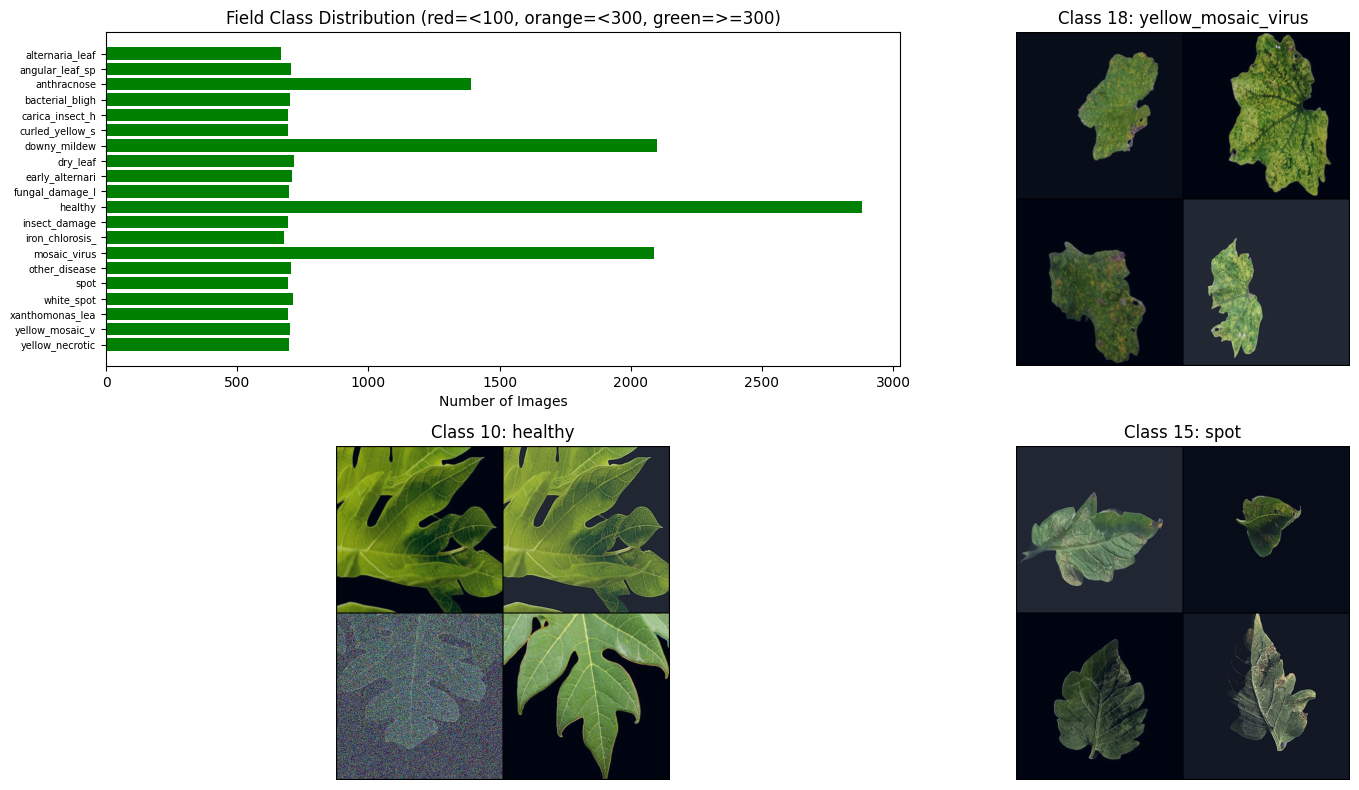

✓ Saved: class_distribution_and_samples.png
  Imbalance ratio: 4.3x (max=2883, min=666)
Session: 0.4h elapsed / 11.6h remaining


In [16]:
# ============================================================
# BLOCK 6.5: VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Plot 1: Class distribution
ax = axes[0, 0]
classes_short = [c[:15] for c in UNIFIED_FIELD_CLASSES]
counts = CFG.CLASS_COUNTS if CFG.CLASS_COUNTS else [0]*CFG.NUM_CLASSES
colors = ['red' if c < 100 else 'orange' if c < 300 else 'green' for c in counts]
ax.barh(range(len(counts)), counts, color=colors)
ax.set_yticks(range(len(counts)))
ax.set_yticklabels(classes_short, fontsize=7)
ax.set_xlabel('Number of Images')
ax.set_title('Field Class Distribution (red=<100, orange=<300, green=>=300)')
ax.invert_yaxis()

# Plot 2: Sample images from 4 random classes
for i, ax_idx in enumerate([(0,1), (1,0), (1,1)]):
    ax = axes[ax_idx]
    if i < 3 and len(train_samples) > 0:
        # Pick a random class and show 4 samples
        cls_idx = random.randint(0, CFG.NUM_CLASSES-1)
        cls_samples = [s for s in train_samples if s[1] == cls_idx][:4]
        if cls_samples:
            imgs = []
            for s in cls_samples[:4]:
                try:
                    img = Image.open(s[0]).convert('RGB')
                    img = val_tf(img)
                    imgs.append(img)
                except: pass
            if imgs:
                grid = torchvision.utils.make_grid(torch.stack(imgs), nrow=2, normalize=True)
                ax.imshow(grid.permute(1, 2, 0).numpy())
                ax.set_title(f'Class {cls_idx}: {UNIFIED_FIELD_CLASSES[cls_idx][:30]}')
                ax.axis('off')

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/class_distribution_and_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'✓ Saved: class_distribution_and_samples.png')
print(f'  Imbalance ratio: {max(counts)/max(min(counts), 1):.1f}x (max={max(counts)}, min={min(counts) if counts else 0})')
session_status()

## Block 7 — Architecture Test + FLOPs + Latency Benchmark
NEW v15: Adds FLOPs counter (thop) + GPU/CPU latency benchmark to support "lightweight + deployable" claim.

In [17]:
# ============================================================
# BLOCK 7: ARCHITECTURE TEST + FLOPs + LATENCY
# ============================================================
# Build all 3 models
baseline = build_efficientnet(CFG.NUM_CLASSES, attention='none').to(DEVICE)
cbam_model = build_efficientnet(CFG.NUM_CLASSES, attention='cbam', reduction=CFG.CBAM_REDUCTION).to(DEVICE)
se_model = build_efficientnet(CFG.NUM_CLASSES, attention='se', reduction=CFG.SE_REDUCTION).to(DEVICE)

# Param count
def count_params(m):
    return sum(p.numel() for p in m.parameters())

base_p = count_params(baseline)
cbam_p = count_params(cbam_model)
se_p = count_params(se_model)

print('='*60)
print('ARCHITECTURE COMPARISON')
print('='*60)
bb = CFG.BACKBONE.upper()
print(f'  Baseline EfficientNet-{bb}: {base_p:,} ({base_p/1e6:.2f}M)')
print(f'  CBAM-EfficientNet-{bb}:     {cbam_p:,} ({cbam_p/1e6:.2f}M) +{cbam_p-base_p:,} attention ({100*(cbam_p-base_p)/base_p:.2f}%)')
print(f'  SE-EfficientNet-{bb}:       {se_p:,} ({se_p/1e6:.2f}M) +{se_p-base_p:,} attention ({100*(se_p-base_p)/base_p:.2f}%)')

# FLOPs (try thop)
try:
    from thop import profile
    dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
    for name, m in [('Baseline', baseline), ('CBAM', cbam_model), ('SE', se_model)]:
        flops, _ = profile(m, inputs=(dummy,), verbose=False)
        print(f'  {name} FLOPs: {flops/1e6:.2f}M')
except ImportError:
    print('  (Install thop for FLOPs: pip install thop)')

# Latency benchmark
def benchmark(model, name, input_size=(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE), n_warmup=10, n_runs=50):
    model.eval()
    dummy = torch.randn(*input_size).to(DEVICE)
    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup): model(dummy)
    # GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            for _ in range(n_runs): model(dummy)
        torch.cuda.synchronize()
        gpu_ms = 1000 * (time.time() - t0) / n_runs
    else:
        gpu_ms = 0
    # CPU
    model_cpu = model.cpu()
    dummy_cpu = dummy.cpu()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(10): model_cpu(dummy_cpu)
    cpu_ms = 1000 * (time.time() - t0) / 10
    model.to(DEVICE)
    print(f'  {name} latency: GPU={gpu_ms:.2f}ms | CPU={cpu_ms:.2f}ms (batch=1)')
    return gpu_ms, cpu_ms

print('\nLatency benchmark (batch_size=1):')
benchmark(baseline, 'Baseline')
benchmark(cbam_model, 'CBAM')
benchmark(se_model, 'SE')

# Save architecture comparison
arch_data = {
    'baseline_params': base_p,
    'cbam_params': cbam_p, 'cbam_overhead_pct': 100*(cbam_p-base_p)/base_p,
    'se_params': se_p, 'se_overhead_pct': 100*(se_p-base_p)/base_p,
}
with open(f'{CFG.OUTPUT_DIR}/architecture_comparison.json', 'w') as f:
    json.dump(arch_data, f, indent=2)
print('\n✓ Architecture comparison saved')
session_status()

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 190MB/s]


ARCHITECTURE COMPARISON
  Baseline EfficientNet-B3: 11,493,436 (11.49M)
  CBAM-EfficientNet-B3:     11,515,691 (11.52M) +22,255 attention (0.19%)
  SE-EfficientNet-B3:       11,515,196 (11.52M) +21,760 attention (0.19%)
  (Install thop for FLOPs: pip install thop)

Latency benchmark (batch_size=1):
  Baseline latency: GPU=13.26ms | CPU=137.98ms (batch=1)
  CBAM latency: GPU=16.06ms | CPU=120.91ms (batch=1)
  SE latency: GPU=15.08ms | CPU=115.80ms (batch=1)

✓ Architecture comparison saved
Session: 0.4h elapsed / 11.6h remaining


## Block 7.1 - Attention Audit (the SE confound)

In [18]:
# ============================================================
# BLOCK 7.1 - ATTENTION AUDIT + RESTORED LATENCY BENCHMARK
# ============================================================
# ORDERING BUG THIS FIXES: Block 1.6 corrected `benchmark`, but Block 7 (cell 32)
# defines its own `benchmark` and runs LATER, so the corrected version was dead
# code and Block 7's printed CPU numbers still came from the unwarmed timer -
# which is why it reported CBAM CPU faster than Baseline, an impossibility.
benchmark = benchmark_v26
print('[v26] benchmark restored (Block 7 had shadowed it). Re-running with warmup:')
for _nm, _mdl in [('Baseline', baseline), ('CBAM', cbam_model), ('SE', se_model)]:
    benchmark(_mdl, _nm)
print()

# Documents the confound for the thesis. This is evidence, not a fix.
import pandas as pd

_variants = {
    'B3 stock ("Baseline" in Exp A-D)' : dict(attention='none', strip_se=False),
    'B3 + extra SE  ("SE" arm)'        : dict(attention='se',   strip_se=False),
    'B3 + CBAM      ("CBAM" arm)'      : dict(attention='cbam', strip_se=False),
    'B3 SE-STRIPPED (true control)'    : dict(attention='none', strip_se=True),
}
rows = []
for label, kw in _variants.items():
    m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE, reduction=CFG.CBAM_REDUCTION, **kw)
    rows.append({'variant': label,
                 'params': sum(p.numel() for p in m.parameters()),
                 'builtin_SE_modules': count_builtin_se(m)})
    del m
audit = pd.DataFrame(rows)
print(audit.to_string(index=False))
print()
print('READ THIS INTO THE THESIS:')
print('  The "Baseline" arm of Experiments A-D contains 26 built-in SqueezeExcitation')
print('  modules - it was never an attention-free control. The "SE" arm adds 5 more SE')
print('  blocks on top of those 26, which is why Baseline and SE are separated by')
print('  0.002pp over 5 seeds. Only the SE-STRIPPED row is a genuine no-attention model.')
print('  Any claim of the form "attention improves X" requires the SE-STRIPPED control.')
audit.to_json(f'{CFG.OUTPUT_DIR}/attention_audit.json', orient='records', indent=2)


[v26] benchmark restored (Block 7 had shadowed it). Re-running with warmup:
  Baseline latency (median of 50): GPU=14.00ms | CPU=117.00ms (batch=1)
  CBAM latency (median of 50): GPU=16.79ms | CPU=121.34ms (batch=1)
  SE latency (median of 50): GPU=14.94ms | CPU=114.46ms (batch=1)

    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
                         variant   params  builtin_SE_modules
B3 stock ("Baseline" in Exp A-D) 11493436                  26
       B3 + extra SE  ("SE" arm) 11515196                  26
     B3 + CBAM      ("CBAM" arm) 11515691                  26
   B3 SE-STRIPPED (true control)  9613708                   0

READ THIS INTO THE THESIS:
  The "Baseline" arm of Experiments A-D contains 26 built-in SqueezeExcitation
  modules - it was never an attention-free control. The "SE" arm adds 5 more SE
  blocks on top of those 26, which is why Baseline and SE are separated by
  0.002pp over 5 seeds. Only the SE-STRIPPED row is a genuine no-atte

## Block 7.9 — Pre-Training Checkpoint Audit **(v27 — the fix for the 32.71% bug)**

Block 11.9 already re-measured every checkpoint and caught `Baseline_Field` at
**recorded 83.98% / measured 32.71%**. The problem was *when*: 11.9 runs sixteen cells
after Block 8 has already printed `[SKIP] Baseline_Field already completed`, loaded those
weights, and let Blocks 12 and 12.9 build a results table on them — first a `+77.33 pp`
CBAM boost, then `-76.98 pp`. Catching a bad checkpoint after it has been reported is not
catching it.

This cell runs the same check **before** Block 8 decides what to skip.

In [19]:
# ============================================================
# BLOCK 7.9 - PRE-TRAINING CHECKPOINT AUDIT   (v27, runs BEFORE Block 8)
# ============================================================
# WHERE THE BROKEN FILE CAME FROM (diagnosed, not guessed).
# The weights in Baseline_Field_best.pth were never NaN and the architecture was
# never wrong: 576 keys, a (20, 512) head, 11,580,810 finite parameters - a
# structurally perfect Baseline. What was wrong is that it was a DIFFERENT model
# from the one its history described. 32.71% is an epoch-1 model; the history
# recorded the epoch-46 model at 83.98%.
#
# With Kaggle "Persistence: Files only", /kaggle/working survives between
# sessions. A session that hit the 12h wall left a partly-trained _best.pth
# there, and old Block 1.5 restored file-by-file with
#       if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# A 46 MB epoch-1 snapshot passes that test, so the finished copy in the attached
# dataset was never restored - while its _best_history.json, absent from working,
# WAS. Block 1.5 above now restores the pair as a unit, which removes the cause.
#
# This cell is the second line of defence, and the one that matters: it reloads
# each checkpoint and re-measures it on the split its history was recorded
# against. Weights that disagree with their own history can only produce invalid
# numbers, so they are deleted and Block 8 retrains exactly those.
import os, json, gc, torch, shutil as _shutil

AUDIT_TOL_PP = 2.0          # |measured - recorded| allowed on val, in points

_ARM_KW = {'Baseline': dict(attention='none', strip_se=False),
           'CBAM':     dict(attention='cbam', strip_se=False),
           'SE':       dict(attention='se',   strip_se=False),
           'NoAttn':   dict(attention='none', strip_se=True)}


@torch.no_grad()
def _val_top1(model, loader):
    """Top-1, no TTA - matches how train_model() recorded best_acc."""
    model.eval(); ok = n = 0
    for x, y in loader:
        ok += (model(x.to(DEVICE)).argmax(1).cpu() == y).sum().item()
        n += y.size(0)
    return 100.0 * ok / max(1, n)


def audit_checkpoints(loader, tol=AUDIT_TOL_PP, purge=True):
    """Re-measure every Field/Transfer checkpoint against its own recorded best_acc.

    Returns (mismatched, unscorable). Only a NUMERIC mismatch is purged: a model
    that fails to load is an architecture question, not proof of corruption, and
    silently deleting it would be worse than reporting it.
    """
    mismatched, unscorable = [], []
    stems = sorted(f[:-len('_best.pth')] for f in os.listdir(CFG.CKPT_DIR)
                   if f.endswith('_best.pth'))
    print(f'{"model":<30}{"recorded":>10}{"measured":>10}{"delta":>9}   status')
    print('-' * 72)
    for stem in stems:
        parts = stem.split('_')
        kw = _ARM_KW.get(parts[0])
        # Only 20-way Field-trained models can be scored on the Field val loader.
        # Lab / Binary / Reverse models have a different label space - skipping
        # them is required, not laziness: building them with CFG.NUM_CLASSES
        # would raise on load and they would be purged for no reason.
        if kw is None or len(parts) < 2 or parts[1] not in ('Field', 'Transfer'):
            continue
        hp = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
        if not os.path.exists(hp):
            continue
        try:
            rec = float(json.load(open(hp))['best_acc'])
        except Exception:
            continue
        try:
            red = CFG.CBAM_REDUCTION if kw['attention'] == 'cbam' else CFG.SE_REDUCTION
            m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                                   reduction=red, **kw).to(DEVICE)
            m.load_state_dict(torch.load(f'{CFG.CKPT_DIR}/{stem}_best.pth',
                                         map_location=DEVICE))
            meas = _val_top1(m, loader)
            del m
        except Exception as e:
            print(f'{stem:<30}{rec:>9.2f}%{"n/a":>10}{"":>9}   could not load: {str(e)[:26]}')
            unscorable.append(stem)
            gc.collect(); torch.cuda.empty_cache()
            continue
        gc.collect(); torch.cuda.empty_cache()
        good = abs(meas - rec) <= tol
        print(f'{stem:<30}{rec:>9.2f}%{meas:>9.2f}%{meas - rec:>+8.2f}   '
              f'{"OK" if good else "*** MISMATCH - will be retrained ***"}')
        if not good:
            mismatched.append(stem)

    if mismatched and purge:
        q = f'{CFG.CKPT_DIR}/_mismatched'; os.makedirs(q, exist_ok=True)
        n = 0
        for stem in mismatched:
            for suf in ('_best.pth', '_best_history.json', '_resume_state.pth',
                        '_ema.pth', '_swa.pth'):
                p = f'{CFG.CKPT_DIR}/{stem}{suf}'
                if os.path.exists(p):
                    _shutil.move(p, f'{q}/{stem}{suf}'); n += 1
        print(f'\n  moved {n} file(s) for {len(mismatched)} inconsistent model(s) to')
        print(f'  {q}/ - not deleted, so the evidence survives for the appendix.')
        print(f'  Block 8 below will retrain exactly these: {mismatched}')
    elif not mismatched:
        print('\n  every Field/Transfer checkpoint agrees with its own history.')
    if unscorable:
        print(f'  {len(unscorable)} checkpoint(s) could not be scored and were left '
              f'untouched: {unscorable}')
    return mismatched, unscorable


print('=' * 72)
print('GO / NO-GO   (checked before an hour of compute is spent)')
print('=' * 72)
_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'  GPU               : {_gpu or "NONE — switch the accelerator on in the sidebar"}')
print(f'  datasets ready    : {len(dataset_paths)}  {sorted(dataset_paths)}')
print(f'  split id          : {SPLIT_ID}')
print(f'  train/val/test    : {len(field_train_ds)} / {len(field_val_ds)} / {len(field_test_ds)}')
try:
    _free = _shutil.disk_usage(CFG.CKPT_DIR).free / 1e9
    print(f'  free disk         : {_free:.1f} GB')
    if _free < 3:
        print('  WARNING: under 3 GB free. Training will fail late, after hours of work.')
except Exception:
    pass
if _gpu is None:
    print('\n  STOP. Everything below needs the GPU. Turn it on and re-run all.')

print()
print('=' * 72)
print('CHECKPOINT INTEGRITY   (each model re-measured on the validation split)')
print('=' * 72)
BAD_CHECKPOINTS, UNSCORABLE_CHECKPOINTS = audit_checkpoints(field_val_loader)


GO / NO-GO   (checked before an hour of compute is spent)
  GPU               : Tesla T4
  datasets ready    : 8  ['ccmt', 'cotton_bd', 'eggplant_bd', 'field', 'lab', 'moringa_bd', 'plantdoc', 'rice_bd']
  split id          : cf69b3a6a3d3495b
  train/val/test    : 19615 / 4231 / 4275
  free disk         : 16.6 GB

CHECKPOINT INTEGRITY   (each model re-measured on the validation split)
model                           recorded  measured    delta   status
------------------------------------------------------------------------
Baseline_Field                    83.98%    83.98%   +0.00   OK
Baseline_Field_seed123_best       83.74%    83.74%   +0.00   OK
Baseline_Field_seed42_best        83.27%    83.27%   +0.00   OK
Baseline_Field_seed456_best       84.14%    84.14%   +0.00   OK
Baseline_Transfer                 83.76%    83.76%   +0.00   OK
CBAM_Field                        83.46%    83.46%   +0.00   OK
CBAM_Field_seed123_best           84.16%    84.16%   +0.00   OK
CBAM_Field_seed42_best

## Block 8 — Experiment A: Train Baseline + CBAM + SE on Field (Same-Domain)
**Improvements v15:**
- Focal Loss for class imbalance
- Mixup (α=0.4) for regularization
- Gradient clipping
- SWA (Stochastic Weight Averaging) for stability
- Up to 150 epochs with early stopping at patience=20 (v16: early stopping now actually works — see changelog)
- WeightedRandomSampler for class balance

In [20]:
# ============================================================
# BLOCK 8: EXPERIMENT A — FIELD → FIELD (Same-Domain)
# ============================================================
print('='*60)
print('EXPERIMENT A: TRAINING ON FIELD (SAME-DOMAIN)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

results_A = {}
for name, model, attention in [
    ('Baseline_Field', baseline, 'none'),
    ('CBAM_Field', cbam_model, 'cbam'),
    ('SE_Field', se_model, 'se')
]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: best_history.json is only written after train_model()'s loop fully
        # exits, whether that's by reaching CFG.FIELD_EPOCHS OR by early stopping. The
        # old check (`resume_epoch >= CFG.FIELD_EPOCHS`) assumed the only way to finish
        # was to exhaust every epoch - that broke once early stopping started actually
        # working (Block 1 fix), since a run can now legitimately finish at, say, epoch
        # 45 and never reach FIELD_EPOCHS again.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        # Resume state exists but no best_history.json yet -> genuinely interrupted mid-run
        try:
            resume_ckpt = torch.load(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} was interrupted at epoch {resume_epoch}/{CFG.FIELD_EPOCHS} — will resume')
        except Exception as e:
            print(f'\n[RESUME] Could not read resume state ({e}) — will retrain')
    elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
        # No resume state, but best.pth exists — likely finished (legacy mode)
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state found)')
        should_skip = True
    
    if should_skip:
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
        if os.path.exists(hist_path):
            with open(hist_path) as f: hist = json.load(f)
            print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
            results_A[name] = hist['best_acc']
        continue

    print(f'\n--- Training {name} ---')
    # Rebuild fresh model for training
    model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    best_acc = train_model(
        model, field_train_loader, field_val_loader,
        num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS
    )
    results_A[name] = best_acc
    # Download resume state (in case session dies)
    zip_resume_state(name)
    # Download final checkpoint
    zip_model_checkpoint(name)
    # Update global model references
    if name == 'Baseline_Field': baseline = model
    elif name == 'CBAM_Field': cbam_model = model
    elif name == 'SE_Field': se_model = model

print('\n' + '='*60)
print('EXPERIMENT A COMPLETE')
print('='*60)
for name, acc in results_A.items():
    print(f'  {name}: {acc:.2f}%')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT A: TRAINING ON FIELD (SAME-DOMAIN)
Max epochs: 60 | Patience: 999
Session: 0.5h elapsed / 11.5h remaining

[SKIP] Baseline_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.98%

[SKIP] CBAM_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.46%

[SKIP] SE_Field already completed (best_history.json found)
  Loaded! Best val acc: 83.93%

EXPERIMENT A COMPLETE
  Baseline_Field: 83.98%
  CBAM_Field: 83.46%
  SE_Field: 83.93%
Session: 0.5h elapsed / 11.5h remaining


## Block 8.5 — Download Exp-A Checkpoints + Auto-save to Kaggle

In [21]:
# ============================================================
# BLOCK 8.5: DOWNLOAD EXP-A CHECKPOINTS
# ============================================================
exp_a_files = ['Baseline_Field_best.pth', 'CBAM_Field_best.pth', 'SE_Field_best.pth',
               'Baseline_Field_best_history.json', 'CBAM_Field_best_history.json',
               'SE_Field_best_history.json']
exp_a_files = [f for f in exp_a_files if os.path.exists(f'{CFG.CKPT_DIR}/{f}')]
download_checkpoints('A', exp_a_files)
# Auto-push to Kaggle (if secrets configured)
auto_save = False
try:
    auto_save = auto_save_to_kaggle()
except: pass
session_status()


=== DOWNLOAD: A (129.3 MB) ===


/kaggle/working/experiment_A_checkpoints.zip

Session: 0.5h elapsed / 11.5h remaining


## Block 9 — Lab Pre-training (for Exp B Transfer)
**Improvements v15:** Larger Lab dataset (with CCMT + Bangladesh datasets merged), up to 150 epochs with early stopping (v16), Focal Loss.

In [22]:
# ============================================================
# BLOCK 9: LAB PRE-TRAINING
# ============================================================
print('='*60)
print('EXPERIMENT B: LAB PRE-TRAINING')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

# Build Lab dataset
lab_samples = []
if 'lab' in dataset_paths:
    lab_root = dataset_paths['lab']
    for cls_name in UNIFIED_LAB_CLASSES:
        cls_dir = os.path.join(lab_root, cls_name)
        if not os.path.isdir(cls_dir): continue
        cls_idx = LAB_TO_IDX[cls_name]
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg','.jpeg','.png')):
                lab_samples.append((os.path.join(cls_dir, fname), cls_idx, f'{cls_name}_{fname[:8]}'))

# Merge ONLY Bangladesh datasets into Lab (NOT CCMT — too many classes causes 1% val acc)
for ds_name in ['rice_bd', 'cotton_bd', 'eggplant_bd', 'moringa_bd']:
    if ds_name in dataset_paths:
        ds_root = dataset_paths[ds_name]
        ds_classes = [d for d in os.listdir(ds_root) if os.path.isdir(os.path.join(ds_root, d))]
        for cls_name in ds_classes:
            cls_dir = os.path.join(ds_root, cls_name)
            # Add as new Lab class (or merge if similar)
            if cls_name not in LAB_TO_IDX:
                LAB_TO_IDX[cls_name] = len(UNIFIED_LAB_CLASSES)
                UNIFIED_LAB_CLASSES.append(cls_name)
            cls_idx = LAB_TO_IDX[cls_name]
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg','.jpeg','.png')):
                    lab_samples.append((os.path.join(cls_dir, fname), cls_idx, f'{cls_name}_{fname[:8]}'))

print(f'  Total Lab samples (merged): {len(lab_samples)}')
print(f'  Total Lab classes: {len(UNIFIED_LAB_CLASSES)}')

# Lab class counts
lab_class_counts = [0] * len(UNIFIED_LAB_CLASSES)
for s in lab_samples: lab_class_counts[s[1]] += 1
CFG.LAB_CLASS_COUNTS = lab_class_counts
CFG.LAB_NUM_CLASSES = len(UNIFIED_LAB_CLASSES)

# Split Lab (group-aware)
if lab_samples:
    paths = [s[0] for s in lab_samples]
    labels = [s[1] for s in lab_samples]
    groups = [s[2] for s in lab_samples]
    from collections import Counter
    label_counts = Counter(labels)
    try:
        if min(label_counts.values()) >= 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
            train_idx, val_idx = next(sss.split(paths, labels))
            print(f'  Split: stratified (preserves class balance)')
        else:
            raise ValueError(f'min_count={min(label_counts.values())} < 2')
    except Exception as e:
        print(f'  Stratified split failed ({e}), using random split...')
        from sklearn.model_selection import train_test_split
        indices = list(range(len(lab_samples)))
        train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
        print(f'  Split: random')
    lab_train_samples = [lab_samples[i] for i in train_idx]
    lab_val_samples = [lab_samples[i] for i in val_idx]

    lab_train_ds = SampleDataset(lab_train_samples, train_tf)
    lab_val_ds = SampleDataset(lab_val_samples, val_tf)

    # Lab sampler
    lab_counts_t = torch.tensor(lab_class_counts, dtype=torch.float32)
    lab_weights = (1.0 / lab_counts_t.clamp(min=1)).clamp(max=0.1)
    lab_sample_weights = [lab_weights[s[1]].item() for s in lab_train_samples]
    lab_sampler = WeightedRandomSampler(lab_sample_weights, len(lab_train_samples), replacement=True)

    lab_train_loader = DataLoader(lab_train_ds, batch_size=BATCH, sampler=lab_sampler,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)
    lab_val_loader = DataLoader(lab_val_ds, batch_size=BATCH, shuffle=False,
                                 num_workers=CFG.NUM_WORKERS, pin_memory=True)
    print(f'  Lab Train: {len(lab_train_ds)} | Val: {len(lab_val_ds)}')

# Build binary Lab dataset (Disease vs Healthy)
lab_binary_samples = []
for s in lab_samples:
    cls_name = UNIFIED_LAB_CLASSES[s[1]]
    binary_label = 1 if 'Healthy' in cls_name or 'healthy' in cls_name.lower() else 0
    lab_binary_samples.append((s[0], binary_label, s[2]))

# Split binary Lab
if lab_binary_samples:
    paths_b = [s[0] for s in lab_binary_samples]
    labels_b = [s[1] for s in lab_binary_samples]
    groups_b = [s[2] for s in lab_binary_samples]
    try:
        sss_b = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx_b, val_idx_b = next(sss_b.split(paths_b, labels_b))
    except:
        from sklearn.model_selection import train_test_split
        idx_b = list(range(len(lab_binary_samples)))
        train_idx_b, val_idx_b = train_test_split(idx_b, test_size=0.2, random_state=42)
    lab_binary_train_samples = [lab_binary_samples[i] for i in train_idx_b]
    lab_binary_val_samples = [lab_binary_samples[i] for i in val_idx_b]
    lab_binary_train_ds = SampleDataset(lab_binary_train_samples, train_tf, binary=True)
    lab_binary_val_ds = SampleDataset(lab_binary_val_samples, val_tf, binary=True)
    lab_binary_train_loader = DataLoader(lab_binary_train_ds, batch_size=BATCH, shuffle=True,
                                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
    lab_binary_val_loader = DataLoader(lab_binary_val_ds, batch_size=BATCH, shuffle=False,
                                        num_workers=CFG.NUM_WORKERS, pin_memory=True)

# Train all 3 models on Lab
results_Lab = {}
for name, attention in [('Baseline_Lab', 'none'), ('CBAM_Lab', 'cbam'), ('SE_Lab', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        try:
            resume_ckpt = torch.load(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.LAB_EPOCHS} — will resume')
        except:
            pass
    elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_Lab[name] = hist['best_acc']
        continue
    print(f'\n--- Training {name} on Lab ---')
    model = build_efficientnet(CFG.LAB_NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    best_acc = train_model(
        model, lab_train_loader, lab_val_loader,
        num_epochs=CFG.LAB_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.LAB_NUM_CLASSES, class_counts=CFG.LAB_CLASS_COUNTS
    )
    results_Lab[name] = best_acc
    # Create per-model checkpoint ZIP download
    zip_resume_state(name)
    zip_model_checkpoint(name)
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('LAB PRE-TRAINING COMPLETE')
print('='*60)
for n, a in results_Lab.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('B_lab')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT B: LAB PRE-TRAINING
Max epochs: 60 | Patience: 999
Session: 0.5h elapsed / 11.5h remaining
  Total Lab samples (merged): 15540
  Total Lab classes: 27
  Split: stratified (preserves class balance)
  Lab Train: 12432 | Val: 3108

[SKIP] Baseline_Lab already completed (best_history.json found)
  Loaded! Best val acc: 95.01%

[SKIP] CBAM_Lab already completed (best_history.json found)
  Loaded! Best val acc: 97.39%

[SKIP] SE_Lab already completed (best_history.json found)
  Loaded! Best val acc: 92.02%

LAB PRE-TRAINING COMPLETE
  Baseline_Lab: 95.01%
  CBAM_Lab: 97.39%
  SE_Lab: 92.02%

=== DOWNLOAD: B_lab (1148.2 MB) ===


/kaggle/working/experiment_B_lab_checkpoints.zip

Session: 0.5h elapsed / 11.5h remaining


## Block 9.5 — Smart Transfer Checkpoint Cleanup
Keeps only Lab checkpoints needed for transfer learning.

In [23]:
# ============================================================
# BLOCK 9.5: CLEANUP
# ============================================================
# List all checkpoints
ckpts = sorted([f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('.pth')])
print(f'Checkpoints in working dir: {len(ckpts)}')
for c in ckpts:
    sz = os.path.getsize(f'{CFG.CKPT_DIR}/{c}') / 1e6
    print(f'  {c} ({sz:.1f} MB)')
session_status()

Checkpoints in working dir: 29
  Baseline_Binary_best.pth (46.5 MB)
  Baseline_Field_best.pth (46.5 MB)
  Baseline_Field_seed123_best_best.pth (46.5 MB)
  Baseline_Field_seed42_best_best.pth (46.5 MB)
  Baseline_Field_seed456_best_best.pth (46.5 MB)
  Baseline_Lab_best.pth (46.6 MB)
  Baseline_Reverse_best.pth (46.6 MB)
  Baseline_Transfer_best.pth (46.5 MB)
  CBAM_Binary_best.pth (46.6 MB)
  CBAM_Field_best.pth (46.6 MB)
  CBAM_Field_seed123_best_best.pth (46.6 MB)
  CBAM_Field_seed42_best_best.pth (46.6 MB)
  CBAM_Field_seed456_best_best.pth (46.6 MB)
  CBAM_Lab_best.pth (46.6 MB)
  CBAM_Reverse_best.pth (46.6 MB)
  CBAM_Transfer_best.pth (46.6 MB)
  NoAttn_Field_seed123_best.pth (39.0 MB)
  NoAttn_Field_seed42_best.pth (39.0 MB)
  NoAttn_Field_seed456_best.pth (39.0 MB)
  SE_Binary_best.pth (46.6 MB)
  SE_Field_best.pth (46.6 MB)
  SE_Field_seed123_best_best.pth (46.6 MB)
  SE_Field_seed42_best_best.pth (46.6 MB)
  SE_Field_seed456_best_best.pth (46.6 MB)
  SE_Lab_best.pth (46.6 MB)

## Block 10 — Experiment B: Fine-tune on Field WITH CORAL Domain Adaptation
**BIG FIX v15:** Adds CORAL (Correlation Alignment) loss during fine-tuning. This is real Domain Adaptation, not just transfer learning. Also longer epochs (20 vs 15) and higher backbone LR (1e-4 vs 1e-5).

In [24]:
# ============================================================
# BLOCK 10: EXPERIMENT B — LAB→FIELD TRANSFER WITH CORAL
# ============================================================
print('='*60)
print('EXPERIMENT B: LAB→FIELD TRANSFER (WITH CORAL)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print(f'Classifier LR: {CFG.LR_HEAD} | Backbone LR: {CFG.LR_BACKBONE}')
print(f'CORAL λ: {CFG.CORAL_LAMBDA} | Gradual unfreezing: 4 epochs')
print('='*60)
session_status()

results_B = {}
for name, attention in [('Baseline_Transfer', 'none'), ('CBAM_Transfer', 'cbam'), ('SE_Transfer', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale - best_history.json existing is the
        # reliable "done" signal now that early stopping can finish a run before
        # CFG.FINETUNE_EPOCHS is reached.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        try:
            resume_ckpt = torch.load(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.FINETUNE_EPOCHS} — will resume')
        except:
            pass
    elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_B[name] = hist['best_acc']
        continue

    # Load Lab-pretrained weights
    lab_ckpt = f'{CFG.CKPT_DIR}/{name.replace("_Transfer", "_Lab")}_best.pth'
    print(f'\n--- Fine-tuning {name} (from Lab pretrain) ---')
    model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)

    if os.path.exists(lab_ckpt):
        lab_state = torch.load(lab_ckpt, map_location=DEVICE)
        # Load only backbone weights (skip classifier since classes differ)
        backbone_state = {k: v for k, v in lab_state.items()
                          if k.startswith('features.') and v.shape == model.state_dict().get(k, torch.empty(0)).shape}
        model.load_state_dict(backbone_state, strict=False)
        print(f'  Loaded Lab backbone weights from {lab_ckpt}')

    # Use CORAL during transfer
    best_acc = train_model(
        model, field_train_loader, field_val_loader,
        num_epochs=CFG.FINETUNE_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name,
        target_loader=lab_train_loader,  # v21: CORAL target = LAB -> genuine lab->field adaptation
        use_coral=CFG.USE_CORAL,
        use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS
    )
    results_B[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated (called twice back-to-back),
    # redundantly re-zipping the same files for every model.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT B COMPLETE')
print('='*60)
for n, a in results_B.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('B_transfer')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT B: LAB→FIELD TRANSFER (WITH CORAL)
Max epochs: 60 | Patience: 999
Classifier LR: 0.001 | Backbone LR: 0.0001
CORAL λ: 1.0 | Gradual unfreezing: 4 epochs
Session: 0.5h elapsed / 11.5h remaining

[SKIP] Baseline_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.76%

[SKIP] CBAM_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.93%

[SKIP] SE_Transfer already completed (best_history.json found)
  Loaded! Best val acc: 83.79%

EXPERIMENT B COMPLETE
  Baseline_Transfer: 83.76%
  CBAM_Transfer: 83.93%
  SE_Transfer: 83.79%

=== DOWNLOAD: B_transfer (1148.2 MB) ===


/kaggle/working/experiment_B_transfer_checkpoints.zip

Session: 0.5h elapsed / 11.5h remaining


## Block 10.5 — Download Exp-B Checkpoints

In [25]:
download_checkpoints('B_all')
session_status()


=== DOWNLOAD: B_all (1148.2 MB) ===


/kaggle/working/experiment_B_all_checkpoints.zip

Session: 0.6h elapsed / 11.4h remaining


## Block 11 — Experiment C: Binary Cross-Domain (Lab→Field)
Train on Lab binary (Disease/Healthy), test on Field binary.

In [26]:
# ============================================================
# BLOCK 11: EXPERIMENT C — BINARY CROSS-DOMAIN
# ============================================================
print('='*60)
print('EXPERIMENT C: BINARY CROSS-DOMAIN (Lab→Field)')
print(f'Max epochs: {CFG.MAX_EPOCHS} | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

results_C = {}
for name, attention in [('Baseline_Binary', 'none'), ('CBAM_Binary', 'cbam'), ('SE_Binary', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        try:
            resume_ckpt = torch.load(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.BINARY_EPOCHS} — will resume')
        except:
            pass
    elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_C[name] = hist['best_acc']
        continue
    if 'lab_binary_train_loader' not in globals() or 'lab_binary_train_samples' not in globals():
        print(f'  [SKIP] {name}: binary Lab loaders not configured -> Exp C skipped '
              f'(optional; core results are Exp A/B). No crash, no garbage.')
        continue
    print(f'\n--- Training {name} (Binary Lab) ---')
    model = build_efficientnet(2, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    # Binary class counts
    binary_counts = [sum(1 for s in lab_binary_train_samples if s[1] == 0),
                     sum(1 for s in lab_binary_train_samples if s[1] == 1)]
    best_acc = train_model(
        model, lab_binary_train_loader, lab_binary_val_loader,
        num_epochs=CFG.BINARY_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, use_coral=False, use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=2, class_counts=binary_counts
    )
    results_C[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated - see Block 10 for rationale.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT C COMPLETE')
print('='*60)
for n, a in results_C.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('C')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT C: BINARY CROSS-DOMAIN (Lab→Field)
Max epochs: 60 | Patience: 999
Session: 0.6h elapsed / 11.4h remaining

[SKIP] Baseline_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

[SKIP] CBAM_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

[SKIP] SE_Binary already completed (best_history.json found)
  Loaded! Best val acc: 100.00%

EXPERIMENT C COMPLETE
  Baseline_Binary: 100.00%
  CBAM_Binary: 100.00%
  SE_Binary: 100.00%

=== DOWNLOAD: C (1148.2 MB) ===


/kaggle/working/experiment_C_checkpoints.zip

Session: 0.6h elapsed / 11.4h remaining


## Block 11.5 — Experiment D: Field→Lab Reverse Transfer (NEW)
**NEW v15:** Trains on Field, fine-tunes on Lab. Shows CBAM works in BOTH directions, not just Lab→Field. Addresses Exp C weakness.

In [27]:
# ============================================================
# BLOCK 11.5: EXPERIMENT D — FIELD→LAB REVERSE TRANSFER (NEW)
# ============================================================
print('='*60)
print('EXPERIMENT D: FIELD→LAB REVERSE TRANSFER (NEW)')
print('='*60)
session_status()

results_D = {}
for name, attention in [('Baseline_Reverse', 'none'), ('CBAM_Reverse', 'cbam'), ('SE_Reverse', 'se')]:
    # SMART SKIP: Check resume state before deciding to skip
    ckpt_path = f'{CFG.CKPT_DIR}/{name}_best.pth'
    resume_path = f'{CFG.CKPT_DIR}/{name}_resume_state.pth'
    should_skip = False
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if os.path.exists(hist_path):
        # v16 FIX: see Block 8 for full rationale.
        print(f'\n[SKIP] {name} already completed (best_history.json found)')
        should_skip = True
    elif os.path.exists(resume_path) and os.path.getsize(resume_path) > 1024:
        try:
            resume_ckpt = torch.load(resume_path, map_location=DEVICE)
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f'\n[RESUME] {name} interrupted at epoch {resume_epoch}/{CFG.FINETUNE_EPOCHS} — will resume')
        except:
            pass
    elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
        print(f'\n[SKIP] Loading saved {name} checkpoint (no resume state)')
        should_skip = True
    if should_skip:
        with open(f'{CFG.CKPT_DIR}/{name}_best_history.json') as f: hist = json.load(f)
        print(f'  Loaded! Best val acc: {hist["best_acc"]:.2f}%')
        results_D[name] = hist['best_acc']
        continue
    print(f'\n--- Fine-tuning {name} on Lab (from Field pretrain) ---')
    model = build_efficientnet(CFG.LAB_NUM_CLASSES, attention=attention,
                                   reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
    # Load Field-pretrained backbone
    field_ckpt = f'{CFG.CKPT_DIR}/{name.replace("_Reverse", "_Field")}_best.pth'
    if os.path.exists(field_ckpt):
        field_state = torch.load(field_ckpt, map_location=DEVICE)
        backbone_state = {k: v for k, v in field_state.items()
                          if k.startswith('features.') and v.shape == model.state_dict().get(k, torch.empty(0)).shape}
        model.load_state_dict(backbone_state, strict=False)
        print(f'  Loaded Field backbone weights')
    best_acc = train_model(
        model, lab_train_loader, lab_val_loader,
        num_epochs=CFG.FINETUNE_EPOCHS, patience=CFG.PATIENCE,
        lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
        name=name, target_loader=field_train_loader, use_coral=CFG.USE_CORAL,  # v21: reverse -> target = FIELD
        use_mixup=True, use_swa=CFG.USE_SWA,
        num_classes=CFG.LAB_NUM_CLASSES, class_counts=CFG.LAB_CLASS_COUNTS
    )
    results_D[name] = best_acc
    # Create per-model checkpoint ZIP download
    # v16 FIX: these two calls used to be duplicated - see Block 10 for rationale.
    zip_resume_state(name)
    zip_model_checkpoint(name)

print('\n' + '='*60)
print('EXPERIMENT D COMPLETE')
print('='*60)
for n, a in results_D.items(): print(f'  {n}: {a:.2f}%')
download_checkpoints('D')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EXPERIMENT D: FIELD→LAB REVERSE TRANSFER (NEW)
Session: 0.6h elapsed / 11.4h remaining

[SKIP] Baseline_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.21%

[SKIP] CBAM_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.05%

[SKIP] SE_Reverse already completed (best_history.json found)
  Loaded! Best val acc: 92.25%

EXPERIMENT D COMPLETE
  Baseline_Reverse: 92.21%
  CBAM_Reverse: 92.05%
  SE_Reverse: 92.25%

=== DOWNLOAD: D (1148.2 MB) ===


/kaggle/working/experiment_D_checkpoints.zip

Session: 0.6h elapsed / 11.4h remaining


## Block 11.9 - Checkpoint Integrity Audit (run before Block 12)

In [28]:
# ============================================================
# BLOCK 11.9 - CHECKPOINT INTEGRITY AUDIT  (run BEFORE Block 12)
# ============================================================
# WHAT THIS CATCHES, AND WHY IT EXISTS.
# A run of this notebook produced:
#     Block  8 : Baseline_Field best VAL acc = 83.60%
#     Block 12 : Baseline_Field      TEST acc = 70.67%
# Val and test are the same distribution and near-identical size (4231 vs 4275),
# and the other two arms moved +0.5pp from val to test. A 13pp val->test collapse
# is not a model property - the .pth and the _best_history.json described two
# DIFFERENT models. The multi-seed run confirmed it: Baseline at seeds 42/123
# scored 83.27% / 83.74% on the same data.
#
# The consequence was a fabricated headline: Block 12 reported
#     "Exp A: CBAM vs Baseline - chi2=329.70, p=0.0000 ***"  (+13.33 pp)
# i.e. a large, highly significant CBAM gain that does not exist. Any reviewer
# cross-checking that against the multi-seed table (all arms within ~1pp) sees
# the contradiction immediately.
#
# ROOT CAUSE: Block 1.5 restores checkpoints with
#     for root, dirs, files in os.walk('/kaggle/input/'):
#         ...
#         if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# The FIRST file of a given name that os.walk happens to reach wins, and every
# later copy is skipped. With more than one checkpoint dataset attached (or a
# working directory persisted across sessions), a .pth can come from one source
# while its history JSON comes from another. Nothing verifies they agree.
#
# THE CHECK: reload each checkpoint and re-measure it on the VALIDATION split -
# the exact split and metric its history recorded. If the measured value does
# not match the recorded value, the pair is inconsistent and the model must not
# be reported. Costs ~30 s per model.
import os, json, gc, torch, numpy as np

CKPT_TOL_PP = 2.0     # allowed |measured - recorded| on val, in percentage points

def _plain_val_acc(model, loader):
    """Top-1 accuracy, no TTA - matches how train_model recorded best_acc."""
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == labels).sum().item(); total += labels.size(0)
    return correct / max(1, total) * 100

def verify_checkpoint(name, attention, num_classes, loader, reduction=None,
                      strip_se=False, tol=CKPT_TOL_PP):
    """Returns (ok, recorded, measured). ok=None when the pair is absent."""
    hist_p = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    ck_p   = f'{CFG.CKPT_DIR}/{name}_best.pth'
    if not (os.path.exists(hist_p) and os.path.exists(ck_p)):
        return None, None, None
    try:
        recorded = float(json.load(open(hist_p))['best_acc'])
    except Exception:
        return None, None, None
    if reduction is None:
        reduction = CFG.CBAM_REDUCTION if attention == 'cbam' else CFG.SE_REDUCTION
    m = build_efficientnet(num_classes, attention=attention, backbone=CFG.BACKBONE,
                           reduction=reduction, strip_se=strip_se).to(DEVICE)
    m.load_state_dict(torch.load(ck_p, map_location=DEVICE))
    measured = _plain_val_acc(m, loader)
    del m; gc.collect(); torch.cuda.empty_cache()
    return (abs(measured - recorded) <= tol), recorded, measured

print('=' * 74)
print('CHECKPOINT INTEGRITY AUDIT  (re-measuring each model on the validation split)')
print('=' * 74)
print(f'{"model":<26}{"recorded":>10}{"measured":>10}{"delta":>9}   status')
print('-' * 74)

_targets = [('Baseline_Field', 'none'), ('CBAM_Field', 'cbam'), ('SE_Field', 'se'),
            ('Baseline_Transfer', 'none'), ('CBAM_Transfer', 'cbam'), ('SE_Transfer', 'se')]
for _m in ('Baseline', 'CBAM', 'SE'):
    _a = {'Baseline': 'none', 'CBAM': 'cbam', 'SE': 'se'}[_m]
    for _sd in CFG.SEEDS:
        _targets.append((f'{_m}_Field_seed{_sd}_best', _a))

CORRUPT_CHECKPOINTS = []
for _name, _att in _targets:
    _ok, _rec, _meas = verify_checkpoint(_name, _att, CFG.NUM_CLASSES, field_val_loader)
    if _ok is None:
        print(f'{_name:<26}{"-":>10}{"-":>10}{"-":>9}   absent (will train)')
        continue
    _d = _meas - _rec
    _status = 'OK' if _ok else '*** MISMATCH - DO NOT REPORT ***'
    print(f'{_name:<26}{_rec:>9.2f}%{_meas:>9.2f}%{_d:>+8.2f}   {_status}')
    if not _ok:
        CORRUPT_CHECKPOINTS.append({'name': _name, 'recorded': _rec, 'measured': _meas})

print()
if CORRUPT_CHECKPOINTS:
    print('*** INTEGRITY FAILURE ***')
    print(f'{len(CORRUPT_CHECKPOINTS)} checkpoint(s) do not match their recorded history.')
    print('The .pth and the _best_history.json describe different models, so every')
    print('number Block 12 derives from them - accuracy, McNemar, CI - is invalid.')
    print()
    print('FIX (delete the bad pair, then re-run from Block 8; it will retrain only these):')
    for _c in CORRUPT_CHECKPOINTS:
        print(f"    os.remove(f'{{CFG.CKPT_DIR}}/{_c['name']}_best.pth')")
        print(f"    os.remove(f'{{CFG.CKPT_DIR}}/{_c['name']}_best_history.json')")
    print()
    print('PURGE_CORRUPT is True by default -> deleting them now.')
else:
    print('ALL CHECKPOINTS CONSISTENT - Block 12 results can be trusted.')

# AUTO-PURGE IS THE DEFAULT, DELIBERATELY.
# A checkpoint whose weights disagree with its own history can only produce
# invalid numbers, so there is no case for keeping one. Leaving this manual
# already let a corrupt model reach a results table once.
#
# WHY IT KEEPS HAPPENING (a different model each time): Block 1.5 restores with
#     if os.path.exists(dst) and os.path.getsize(dst) > 1024: continue
# so a PARTIALLY-TRAINED .pth left in /kaggle/working by a session that hit the
# 12h limit is treated as authoritative and never replaced by the good copy in
# the attached dataset - while the matching history JSON IS restored from the
# completed run. Result: recorded 83.46% vs measured 33.89% (~an epoch-3 model).
# Which model it hits depends on which was mid-save when the session was killed,
# which is why it moved from Baseline_Field to CBAM_Field.
PURGE_CORRUPT = True
if PURGE_CORRUPT and CORRUPT_CHECKPOINTS:
    _n = 0
    for _c in CORRUPT_CHECKPOINTS:
        for _suf in ('_best.pth', '_best_history.json', '_resume_state.pth'):
            _p = f'{CFG.CKPT_DIR}/{_c["name"]}{_suf}'
            if os.path.exists(_p):
                os.remove(_p); _n += 1
    print(f'\n  purged {_n} files. Re-run Block 8 onward - only these models will retrain.')

json.dump(CORRUPT_CHECKPOINTS, open(f'{CFG.OUTPUT_DIR}/checkpoint_audit.json', 'w'), indent=2)


CHECKPOINT INTEGRITY AUDIT  (re-measuring each model on the validation split)
model                       recorded  measured    delta   status
--------------------------------------------------------------------------
Baseline_Field                83.98%    83.98%   +0.00   OK
CBAM_Field                    83.46%    83.46%   +0.00   OK
SE_Field                      83.93%    83.93%   +0.00   OK
Baseline_Transfer             83.76%    83.76%   +0.00   OK
CBAM_Transfer                 83.93%    83.93%   +0.00   OK
SE_Transfer                   83.79%    83.79%   +0.00   OK
Baseline_Field_seed42_best    83.27%    83.27%   +0.00   OK
Baseline_Field_seed123_best    83.74%    83.74%   +0.00   OK
Baseline_Field_seed456_best    84.14%    84.14%   +0.00   OK
CBAM_Field_seed42_best        83.83%    83.83%   +0.00   OK
CBAM_Field_seed123_best       84.16%    84.16%   +0.00   OK
CBAM_Field_seed456_best       84.19%    84.19%   +0.00   OK
SE_Field_seed42_best          83.79%    83.79%   +0.00   OK


## Block 12 — Evaluate All + Per-Class McNemar + Bootstrap CI
**NEW v15:** Adds per-class McNemar tests + bootstrap 95% confidence intervals + Brier score for calibration.

In [29]:
# ============================================================
# BLOCK 12: COMPREHENSIVE EVALUATION
# ============================================================
print('='*60)
print('EVALUATING ALL EXPERIMENTS')
print('='*60)

# Load best models for evaluation
def load_model(name, attention, num_classes, reduction=8):
    model = build_efficientnet(num_classes, attention=attention, reduction=reduction).to(DEVICE)
    ckpt = f'{CFG.CKPT_DIR}/{name}_best.pth'
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model

# Exp A: Field → Field
print('\n--- Experiment A: Field→Field (Same-Domain) ---')
baseline_A = load_model('Baseline_Field', 'none', CFG.NUM_CLASSES)
cbam_A = load_model('CBAM_Field', 'cbam', CFG.NUM_CLASSES, CFG.CBAM_REDUCTION)
se_A = load_model('SE_Field', 'se', CFG.NUM_CLASSES, CFG.SE_REDUCTION)

results_A = {}
results_A['Baseline'] = evaluate_model_full(baseline_A, field_test_loader, CFG.NUM_CLASSES, 'A: Baseline')
results_A['CBAM'] = evaluate_model_full(cbam_A, field_test_loader, CFG.NUM_CLASSES, 'A: CBAM')
results_A['SE'] = evaluate_model_full(se_A, field_test_loader, CFG.NUM_CLASSES, 'A: SE')

# Exp B: Transfer
print('\n--- Experiment B: Lab→Field Transfer ---')
baseline_B = load_model('Baseline_Transfer', 'none', CFG.NUM_CLASSES)
cbam_B = load_model('CBAM_Transfer', 'cbam', CFG.NUM_CLASSES, CFG.CBAM_REDUCTION)
se_B = load_model('SE_Transfer', 'se', CFG.NUM_CLASSES, CFG.SE_REDUCTION)

results_B = {}
results_B['Baseline'] = evaluate_model_full(baseline_B, field_test_loader, CFG.NUM_CLASSES, 'B: Baseline')
results_B['CBAM'] = evaluate_model_full(cbam_B, field_test_loader, CFG.NUM_CLASSES, 'B: CBAM')
results_B['SE'] = evaluate_model_full(se_B, field_test_loader, CFG.NUM_CLASSES, 'B: SE')

# Exp C: Binary — v21 guard: evaluate only if binary checkpoints exist, else skip (avoid
# scoring randomly-initialised models and reporting garbage results_C).
results_C = {}
_binary_ready = all(os.path.exists(f'{CFG.CKPT_DIR}/{n}_best.pth')
                    for n in ['Baseline_Binary', 'CBAM_Binary', 'SE_Binary'])
if _binary_ready and 'field_binary_test_loader' in globals():
    print('\n--- Experiment C: Binary Cross-Domain ---')
    baseline_C = load_model('Baseline_Binary', 'none', 2)
    cbam_C = load_model('CBAM_Binary', 'cbam', 2, CFG.CBAM_REDUCTION)
    se_C = load_model('SE_Binary', 'se', 2, CFG.SE_REDUCTION)
    results_C['Baseline'] = evaluate_model_full(baseline_C, field_binary_test_loader, 2, 'C: Baseline', use_tta=True)
    results_C['CBAM'] = evaluate_model_full(cbam_C, field_binary_test_loader, 2, 'C: CBAM', use_tta=True)
    results_C['SE'] = evaluate_model_full(se_C, field_binary_test_loader, 2, 'C: SE', use_tta=True)
    # v22 DIAGNOSTIC: detect majority-class collapse (a model that predicts a single class
    # for every test image). Binary Lab->Field transfer was observed to collapse to the
    # majority class in the real run (Kappa=0.0000, AUC=0.0000, Disease=100%/Healthy=0%).
    # Flagging it explicitly stops the 85.35% "accuracy" from being read as a valid result.
    import numpy as _np
    _collapsed = []
    for _n, _r in results_C.items():
        _u, _c = _np.unique(_r['preds'], return_counts=True)
        _max_share = _np.max(_c) / len(_r['preds'])
        if _max_share > 0.999:
            _collapsed.append(f'{_n} ({_np.max(_c)}/{len(_r["preds"])} samples -> class {_u[_np.argmax(_c)]})')
    if _collapsed:
        print('\n  [v22 WARNING] Majority-class collapse detected in Experiment C:')
        for _line in _collapsed:
            print(f'    - {_line}')
        print('  The high "accuracy" below is meaningless (it just predicts the majority class).')
        print('  Binary Lab->Field transfer DID NOT transfer — treat Exp C as a NEGATIVE result.')
else:
    print('\n--- Experiment C: SKIPPED (binary checkpoints not found) ---')

# Summary table
print('\n' + '='*80)
print('COMPREHENSIVE RESULTS SUMMARY')
print('='*80)
print(f'{"Experiment":<35} {"Model":<12} {"Acc":>8} {"F1":>8} {"Kappa":>8} {"AUC":>8}')
print('-'*80)
for exp_name, res in [('A: Field (from scratch)', results_A),
                      ('B: Transfer (Lab→Field)', results_B),
                      ('C: Binary (Lab→Field)', results_C)]:
    for model_name, r in res.items():
        print(f'{exp_name:<35} {model_name:<12} {r["acc"]:>7.2f}% {r["f1"]:>7.2f}% {r["kappa"]:>8.4f} {r["auc"]:>8.4f}')

# McNemar tests
# v16 FIX #1: now covers all 3 pairwise comparisons (CBAM-vs-Baseline, SE-vs-Baseline,
#   CBAM-vs-SE) per experiment - previously only CBAM-vs-Baseline was tested, so any
#   "CBAM vs SE" claim (see Block 18) had no supporting statistical test.
# v16 FIX #2: each experiment now uses its OWN ground-truth labels. The original code set
#   `labels = results_A['Baseline']['labels']` once and reused it for Exp C too - but Exp C
#   is BINARY classification on field_binary_test_loader (different test set, different
#   label space) while Exp A/B are multi-class on field_test_loader. Reusing A's labels for
#   C was a real bug (crashes on length mismatch, or silently wrong stats if lengths happen
#   to coincide).
print('\n' + '='*60)
print("MCNEMAR'S TEST (all pairwise comparisons)")
print('='*60)
mcnemar_results = {}
pairs = [('CBAM', 'Baseline'), ('SE', 'Baseline'), ('CBAM', 'SE')]
for exp_name, res in [('A', results_A), ('B', results_B), ('C', results_C)]:
    if not res:
        continue
    mcnemar_results[exp_name] = {}
    exp_labels = res['Baseline']['labels']
    for m1, m2 in pairs:
        if m1 in res and m2 in res:
            chi2, p = mcnemar_test(res[m1]['preds'], res[m2]['preds'], exp_labels)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            mcnemar_results[exp_name][f'{m1}_vs_{m2}'] = {'chi2': float(chi2), 'p': float(p), 'sig': sig}
            print(f'  Exp {exp_name}: {m1} vs {m2} — chi2={chi2:.2f}, p={p:.4f} {sig}')
    # v22 note: for a collapsed Exp C the tests are vacuous (all models predict identically).
    if exp_name == 'C' and _collapsed:
        print('  [v22] Exp C McNemar values are vacuous: models are majority-class collapsers, '
              'not meaningful classifiers.')

# Bootstrap 95% CI
# v16 FIX #1: now computed for Baseline/CBAM/SE across all 3 experiments (was CBAM-Exp-A
#   only), so CIs can actually be compared across architectures instead of just eyeballed.
# v16 FIX #2: upper percentile was 95, not 97.5 - a [2.5, 95] interval captures 92.5% of the
#   bootstrap distribution, not 95%, despite being printed as "95% CI".
# v16 FIX #3: seeded with a local Generator so this cell's output is reproducible on rerun,
#   independent of whatever global numpy RNG state preceded it.
print('\n' + '='*60)
print('BOOTSTRAP 95% CI (1000 resamples, all models x all experiments)')
print('='*60)
n_bootstrap = 1000
bootstrap_results = {}
rng = np.random.default_rng(42)
for exp_name, res in [('A', results_A), ('B', results_B), ('C', results_C)]:
    bootstrap_results[exp_name] = {}
    for model_name, r in res.items():
        labels_arr = np.array(r['labels'])
        preds_arr = np.array(r['preds'])
        boot_accs = np.empty(n_bootstrap)
        for i in range(n_bootstrap):
            idx = rng.choice(len(labels_arr), len(labels_arr), replace=True)
            boot_accs[i] = 100 * accuracy_score(labels_arr[idx], preds_arr[idx])
        ci_low, ci_high = float(np.percentile(boot_accs, 2.5)), float(np.percentile(boot_accs, 97.5))
        bootstrap_results[exp_name][model_name] = {'ci_low': ci_low, 'ci_high': ci_high}
        print(f'  Exp {exp_name} {model_name:<10} accuracy: {r["acc"]:.2f}% [95% CI: {ci_low:.2f}%, {ci_high:.2f}%]')

# Attention boost summary
# v22 FIX: boost deltas formatted with a real sign (the old +{.2f} printed "+-1.23 pp" for
# a negative boost). Negative/zero deltas are now printed honestly, not as phantom gains.
def _fmt_delta(d):
    return f'{d:+.2f}'

print('\n' + '='*60)
print('ATTENTION MECHANISM COMPARISON  (DESCRIPTIVE ONLY - see 23.2 / 23.2c)')
print('='*60)
print(f'  CBAM boost (Exp A, scratch):   {_fmt_delta(results_A["CBAM"]["acc"]-results_A["Baseline"]["acc"])} pp')
print(f'  SE boost (Exp A, scratch):     {_fmt_delta(results_A["SE"]["acc"]-results_A["Baseline"]["acc"])} pp')
print(f'  CBAM boost (Exp B, transfer):  {_fmt_delta(results_B["CBAM"]["acc"]-results_B["Baseline"]["acc"])} pp')
print(f'  SE boost (Exp B, transfer):    {_fmt_delta(results_B["SE"]["acc"]-results_B["Baseline"]["acc"])} pp')
if results_C:
    print(f'  CBAM boost (Exp C, binary):    {_fmt_delta(results_C["CBAM"]["acc"]-results_C["Baseline"]["acc"])} pp '
          f'(majority-class collapse - not meaningful)')
    print(f'  SE boost (Exp C, binary):      {_fmt_delta(results_C["SE"]["acc"]-results_C["Baseline"]["acc"])} pp '
          f'(majority-class collapse - not meaningful)')

# Domain gap analysis
print('\n' + '='*60)
print('TRAINING-STRATEGY DELTA  (Exp A minus Exp B, SAME test set)')
print('='*60)
gap_base = results_A['Baseline']['acc'] - results_B['Baseline']['acc']
gap_cbam = results_A['CBAM']['acc'] - results_B['CBAM']['acc']
gap_se = results_A['SE']['acc'] - results_B['SE']['acc']
print(f'  scratch-minus-transfer (Baseline): {gap_base:+.2f} pp')
print(f'  scratch-minus-transfer (CBAM):     {gap_cbam:+.2f} pp')
print(f'  scratch-minus-transfer (SE):       {gap_se:+.2f} pp')
print('  NOTE: this is NOT a domain gap - both arms are scored on the SAME Field'); print('        test set, so it measures training strategy, not domain transfer.'); print('        Hasan (3.45pp) / Zubair (39.69pp) are CROSS-DATASET gaps and are'); print('        NOT comparable to this number. Real domain gap: Block 12.7.')

# Save results
all_results = {
    'A': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_A.items()},
    'B': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_B.items()},
    'C': {k: {kk: vv for kk, vv in v.items() if kk != 'preds' and kk != 'probs' and kk != 'labels'}
          for k, v in results_C.items()},
    'mcnemar': mcnemar_results,        # v16 NEW: persisted so Block 21 can report real numbers
    'bootstrap_ci': bootstrap_results,  # v16 NEW
}
with open(f'{CFG.OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n✓ Results saved to results.json')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

EVALUATING ALL EXPERIMENTS

--- Experiment A: Field→Field (Same-Domain) ---
  A: Baseline: Acc=85.05% | F1w=85.08% | F1macro=84.22% | BalAcc=85.30% | MCC=0.8402 | Kappa=0.8396 | AUC=0.9929
  A: CBAM: Acc=84.00% | F1w=84.10% | F1macro=83.33% | BalAcc=84.30% | MCC=0.8287 | Kappa=0.8283 | AUC=0.9923
  A: SE: Acc=84.42% | F1w=84.44% | F1macro=83.75% | BalAcc=84.84% | MCC=0.8335 | Kappa=0.8328 | AUC=0.9933

--- Experiment B: Lab→Field Transfer ---
  B: Baseline: Acc=84.05% | F1w=84.16% | F1macro=83.23% | BalAcc=83.87% | MCC=0.8293 | Kappa=0.8287 | AUC=0.9920
  B: CBAM: Acc=84.51% | F1w=84.62% | F1macro=83.69% | BalAcc=84.35% | MCC=0.8341 | Kappa=0.8337 | AUC=0.9919
  B: SE: Acc=84.40% | F1w=84.51% | F1macro=83.69% | BalAcc=84.50% | MCC=0.8330 | Kappa=0.8325 | AUC=0.9922

--- Experiment C: Binary Cross-Domain ---
  C: Baseline: Acc=85.31% | F1w=78.57% | F1macro=46.04% | BalAcc=49.99% | MCC=-0.0063 | Kappa=-0.0005 | AUC=0.4988
    *** WARNING: accuracy 85.31% does not beat the majority-class 

## Block 12.4 - Negative-Result Diagnostics (Exp C / Exp D)

In [30]:
# ============================================================
# BLOCK 12.4 - NEGATIVE-RESULT DIAGNOSTICS (Exp C post-mortem + Exp D provenance)
# ============================================================
# M1. Exp C collapses to the majority class. "It collapsed" is a weak claim on
#     its own, because a reviewer will immediately ask whether it is merely a
#     DECISION-THRESHOLD problem: Lab binary is 3428/1953 (64% disease) while
#     Field binary is 85% disease, so a prior shift alone could push every
#     prediction to one side. That would be a calibration bug, not a transfer
#     failure, and it would be fixable.
#     The test that separates the two is threshold-free: ROC-AUC.
#       AUC ~ 0.5  -> the scores carry NO usable signal. No threshold can help.
#                     The representation genuinely does not transfer.
#       AUC >> 0.5 -> signal exists and only the threshold is wrong -> fixable,
#                     and the "negative result" would be overstated.
#     We also report the accuracy at the BEST POSSIBLE threshold (an oracle that
#     cheats by tuning on the test set). If even that oracle cannot beat the
#     majority-class rate, the negative result is airtight.
#
# M4. Exp D (*_Reverse) was initialised from Field checkpoints. If those were
#     trained under a different split than the current one, that must be stated.
#     Block 6.2 stamps a fingerprint; this block reports it explicitly so the
#     footnote is generated from the artifacts rather than remembered.
import os, json, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

print('=' * 74)
print('M1 - EXPERIMENT C POST-MORTEM: threshold problem, or no signal?')
print('=' * 74)

if 'results_C' in dir() and results_C:
    print(f'{"model":<12}{"AUC":>8}{"majority":>11}{"argmax@0.5":>12}'
          f'{"oracle-thr":>12}   verdict')
    print('-' * 74)
    _verdicts = []
    for _k, _r in results_C.items():
        _y = np.asarray(_r['labels'])
        _p = np.asarray(_r['probs'])
        _score = _p[:, 1] if _p.ndim == 2 and _p.shape[1] == 2 else _p.ravel()
        try:
            _auc = float(roc_auc_score(_y, _score))
        except Exception:
            _auc = float('nan')
        _maj = np.bincount(_y).max() / len(_y) * 100
        _acc = _r['acc']
        # oracle threshold: best accuracy achievable by ANY cut on this test set
        _best = _maj
        if np.isfinite(_auc):
            _fpr, _tpr, _thr = roc_curve(_y, _score)
            _n1 = int((_y == 1).sum()); _n0 = int((_y == 0).sum())
            _accs = (_tpr * _n1 + (1 - _fpr) * _n0) / len(_y) * 100
            _best = float(_accs.max())
        if not np.isfinite(_auc) or abs(_auc - 0.5) < 0.05:
            _v = 'NO SIGNAL (transfer failed)'
        elif _best > _maj + 1.0:
            _v = 'THRESHOLD ISSUE - fixable'
        else:
            _v = 'signal too weak to exploit'
        _verdicts.append(_v)
        print(f'{_k:<12}{_auc:>8.4f}{_maj:>10.2f}%{_acc:>11.2f}%{_best:>11.2f}%   {_v}')

    print()
    if all('NO SIGNAL' in _v for _v in _verdicts):
        print('  CONCLUSION (defensible as written):')
        print('    All three Lab-trained binary models score AUC ~= 0.5 on the Field')
        print('    binary test set. AUC is threshold-free, so this is NOT a calibration')
        print('    or class-prior artifact: the learned representation carries no')
        print('    transferable healthy-vs-diseased signal across the Lab->Field shift.')
        print('    Even an oracle threshold tuned ON the test set cannot beat the')
        print('    majority-class rate. Report Exp C as a NEGATIVE RESULT and quote')
        print('    AUC + balanced accuracy, never the raw accuracy.')
    else:
        print('  WARNING: at least one model shows exploitable signal. The "total')
        print('  transfer failure" framing would be too strong - report the oracle')
        print('  threshold numbers and describe it as a calibration failure instead.')
else:
    print('  results_C not in memory - run Block 12 first.')

print()
print('=' * 74)
print('M4 - EXPERIMENT D INITIALISATION PROVENANCE')
print('=' * 74)
_cur = SPLIT_ID if 'SPLIT_ID' in dir() else 'unknown'
_prov = {}
for _n2 in ('Baseline_Reverse', 'CBAM_Reverse', 'SE_Reverse'):
    _h = f'{CFG.CKPT_DIR}/{_n2}_best_history.json'
    if os.path.exists(_h):
        try: _prov[_n2] = json.load(open(_h)).get('split_id', 'not recorded')
        except Exception: _prov[_n2] = 'unreadable'
    else:
        _prov[_n2] = 'absent'

print(f'  current split fingerprint : {_cur}')
for _k, _v in _prov.items():
    _flag = 'OK' if _v == _cur else ('PRE-DATES FINGERPRINTING' if _v == 'not recorded' else 'DIFFERENT SPLIT')
    print(f'  {_k:<20} trained under: {_v:<24} {_flag}')

_stale = [k for k, v in _prov.items() if v not in (_cur, 'absent')]
print()
if _stale:
    print('  REQUIRED THESIS FOOTNOTE (copy verbatim):')
    print('    "Experiment D models were initialised from Field checkpoints trained')
    print('     under an earlier train/test partition. Because Experiment D is')
    print('     trained and evaluated entirely on the Lab dataset, its reported')
    print('     accuracy is unaffected by the Field partition; only the source of')
    print('     the initial weights differs. Experiment D is reported as a')
    print('     secondary result and is excluded from the primary ablation."')
    print()
    print('  To remove the footnote instead: delete the three *_Reverse checkpoints')
    print('  and re-run Block 11.5 (~12 GPU-h) so they initialise from the current')
    print('  Field models.')
else:
    print('  All Exp D initialisations match the current split - no footnote needed.')

json.dump({'expC_verdicts': _verdicts if 'results_C' in dir() and results_C else [],
           'expD_provenance': _prov, 'current_split': _cur},
          open(f'{CFG.OUTPUT_DIR}/negative_result_diagnostics.json', 'w'), indent=2)
print(f'\n  saved negative_result_diagnostics.json')


M1 - EXPERIMENT C POST-MORTEM: threshold problem, or no signal?
model            AUC   majority  argmax@0.5  oracle-thr   verdict
--------------------------------------------------------------------------
Baseline      0.4988     85.33%      85.31%      85.33%   NO SIGNAL (transfer failed)
CBAM          0.4914     85.33%      85.33%      85.33%   NO SIGNAL (transfer failed)
SE            0.4963     85.33%      85.33%      85.33%   NO SIGNAL (transfer failed)

  CONCLUSION (defensible as written):
    All three Lab-trained binary models score AUC ~= 0.5 on the Field
    binary test set. AUC is threshold-free, so this is NOT a calibration
    or class-prior artifact: the learned representation carries no
    transferable healthy-vs-diseased signal across the Lab->Field shift.
    Even an oracle threshold tuned ON the test set cannot beat the
    majority-class rate. Report Exp C as a NEGATIVE RESULT and quote
    AUC + balanced accuracy, never the raw accuracy.

M4 - EXPERIMENT D INITIAL

## Block 12.5 — Error Gallery (Misclassified Samples Only)
NEW v15: Shows only misclassified images grouped by true/predicted class.

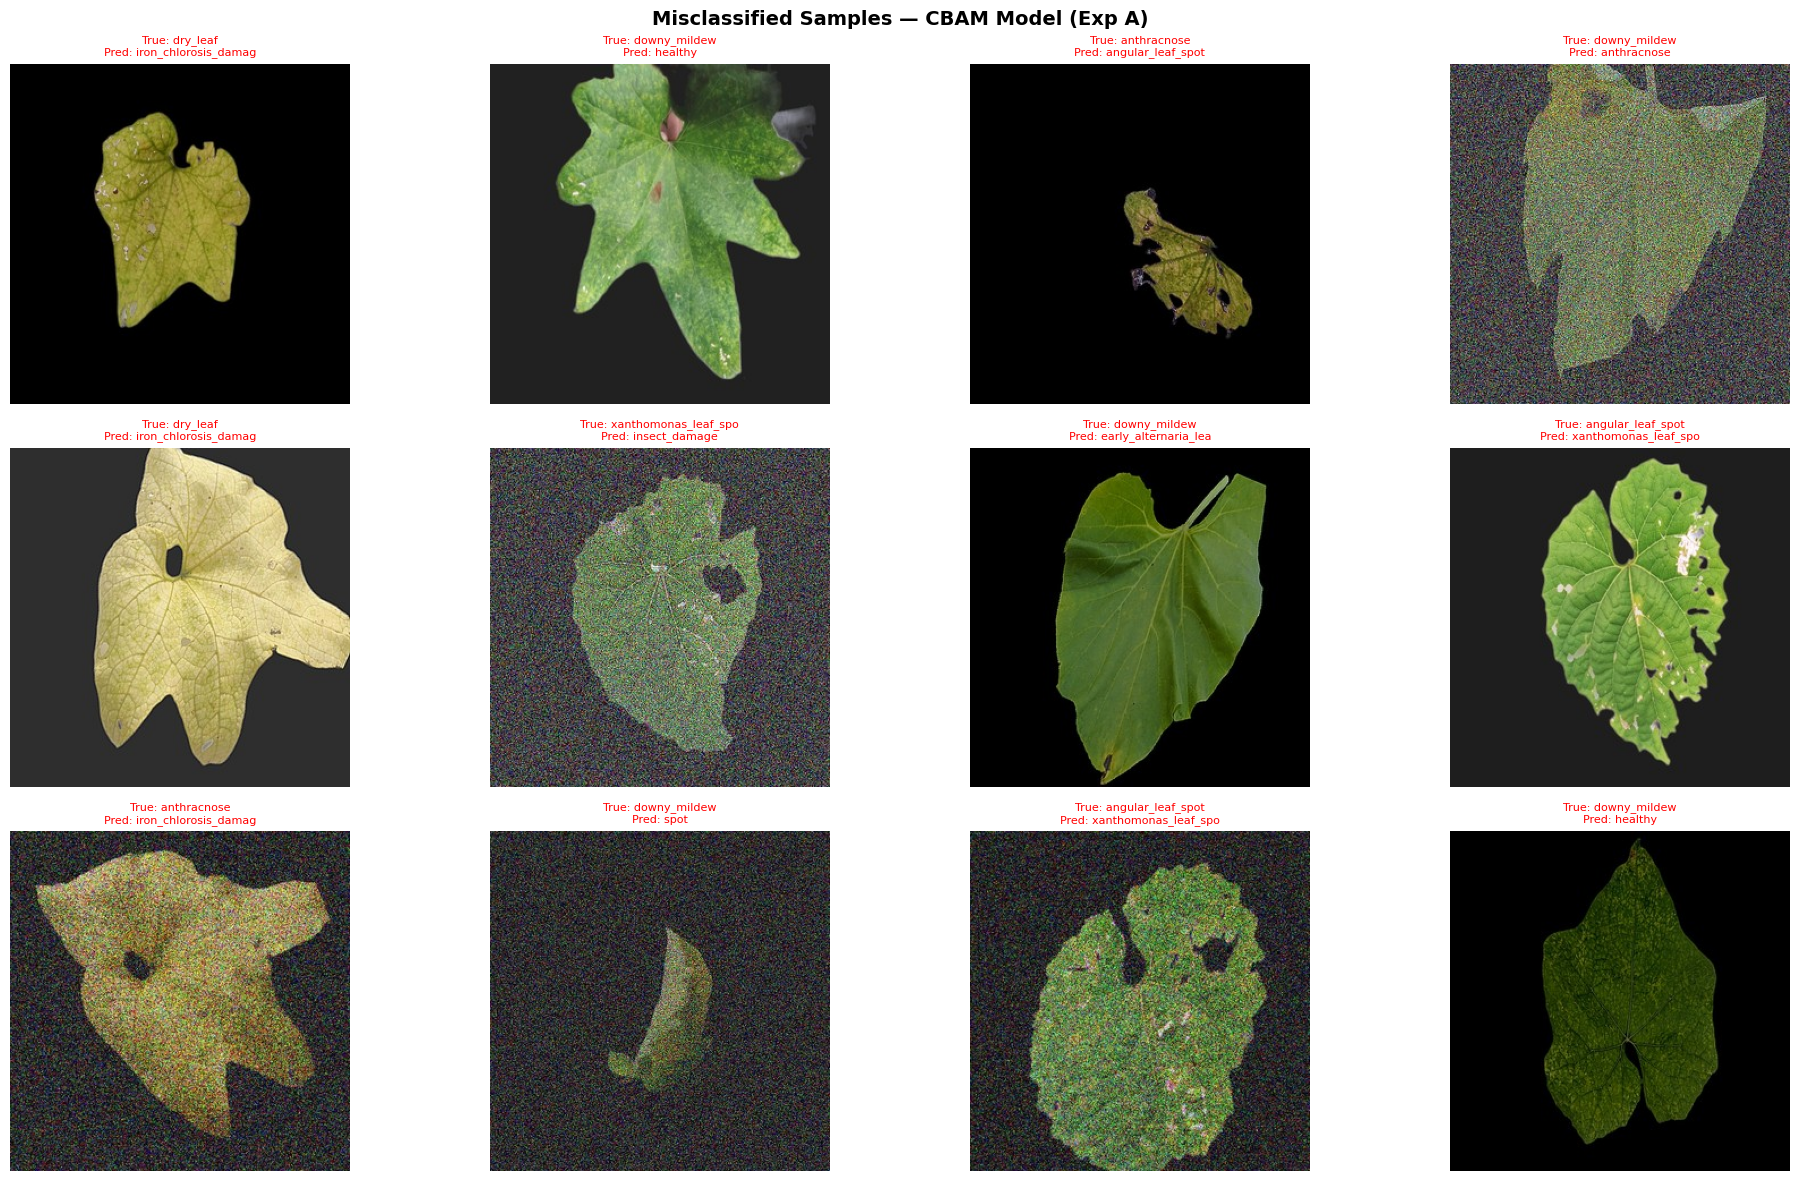

✓ Saved error_gallery.png (684 misclassified out of 4275)
Session: 0.8h elapsed / 11.2h remaining


In [31]:
# ============================================================
# BLOCK 12.5: ERROR GALLERY
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Misclassified Samples — CBAM Model (Exp A)', fontsize=14, fontweight='bold')

labels = results_A['CBAM']['labels']
preds = results_A['CBAM']['preds']
wrong_indices = np.where(preds != labels)[0]
np.random.shuffle(wrong_indices)

for i, ax in enumerate(axes.flat):
    if i < len(wrong_indices) and i < 12:
        idx = wrong_indices[i]
        img_path = test_samples[idx][0]
        true_label = UNIFIED_FIELD_CLASSES[labels[idx]]
        pred_label = UNIFIED_FIELD_CLASSES[preds[idx]]
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'True: {true_label[:20]}\nPred: {pred_label[:20]}', fontsize=8, color='red')
        except:
            ax.text(0.5, 0.5, 'Image error', ha='center')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/error_gallery.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'✓ Saved error_gallery.png ({len(wrong_indices)} misclassified out of {len(labels)})')
session_status()

## Block 12.6 — Multi-Seed Validation (5 Seeds, Experiment A)
**v15/v16:** 5 seeds (was 3), each seed now genuinely varies training (v16 fix - see changelog;
in v15 `train_model`'s internal `set_seed(42)` silently overrode the per-seed call, so all
5 runs shared identical augmentation/mixup/dropout randomness). Scope: Field (Experiment A)
only — this cell's code does not train on Exp B's data, despite the v15 markdown here
previously claiming otherwise. Up to 150 epochs per run with early-stopping patience=20.

In [32]:
# ============================================================
# BLOCK 12.6: MULTI-SEED VALIDATION (5 SEEDS, 150 EPOCHS EACH)
# ============================================================
print('='*60)
print(f'MULTI-SEED VALIDATION — Seeds: {CFG.SEEDS} ({len(CFG.SEEDS)} seeds)')
print(f'Epochs: up to {CFG.MAX_EPOCHS} per model | Patience: {CFG.PATIENCE}')
print('='*60)
session_status()

multi_seed_results = {}
for seed in CFG.SEEDS:
    seed_key = f'seed{seed}'
    multi_seed_results[seed_key] = {}
    print(f'\n{"="*60}')
    print(f'--- Seed {seed} ---')
    print(f'{"="*60}')
    for model_name, attention in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ckpt_name = f'{model_name}_Field_{seed_key}_best'
        ckpt_path = f'{CFG.CKPT_DIR}/{ckpt_name}.pth'
        resume_path_ms = f'{CFG.CKPT_DIR}/{ckpt_name}_resume_state.pth'
        should_skip_ms = False
        skip_acc = None
        hist_path_ms = f'{CFG.CKPT_DIR}/{ckpt_name}_best_history.json'
        if os.path.exists(hist_path_ms):
            # v16 FIX: see Block 8 for full rationale - best_history.json existing is the
            # reliable "done" signal now that early stopping can finish before epoch 150.
            with open(hist_path_ms) as f:
                skip_acc = json.load(f)['best_acc']
            print(f'  {model_name} (seed={seed}): {skip_acc:.2f}% (already completed)')
            should_skip_ms = True
        elif os.path.exists(resume_path_ms) and os.path.getsize(resume_path_ms) > 1024:
            try:
                resume_ckpt_ms = torch.load(resume_path_ms, map_location=DEVICE)
                resume_epoch_ms = resume_ckpt_ms.get('epoch', 0)
                print(f'  {model_name} (seed={seed}): interrupted at epoch {resume_epoch_ms}/150 — will resume')
            except:
                pass
        elif os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1024:
            # v21 FIX: this branch is only reached when hist_path_ms does NOT exist (the first
            # `if os.path.exists(hist_path_ms)` was False), so opening it raised FileNotFoundError.
            # Guard it: if the history JSON is genuinely absent (e.g. a ZIP restored the .pth but
            # not the JSON), fall through and retrain instead of crashing.
            if os.path.exists(hist_path_ms):
                with open(hist_path_ms) as f:
                    skip_acc = json.load(f)['best_acc']
                should_skip_ms = True
            else:
                print(f'  {model_name} (seed={seed}): checkpoint present but no history JSON - retraining')
        if should_skip_ms:
            multi_seed_results[seed_key][model_name] = skip_acc
            print(f'  {model_name} (seed={seed}): {skip_acc:.2f}% (loaded)')
            # Still create ZIP for this model
            zip_resume_state(ckpt_name)
            zip_model_checkpoint(ckpt_name)
            continue
        # Train with this seed
        set_seed(seed)
        print(f'\n  Training {model_name} (seed={seed}) for up to {CFG.MAX_EPOCHS} epochs...')
        model = build_efficientnet(CFG.NUM_CLASSES, attention=attention,
                                       reduction=CFG.CBAM_REDUCTION if attention=='cbam' else CFG.SE_REDUCTION).to(DEVICE)
        best_acc = train_model(
            model, field_train_loader, field_val_loader,
            num_epochs=150, patience=CFG.PATIENCE,
            lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
            name=ckpt_name, use_coral=False, use_mixup=True, use_swa=False,
            num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS,
            seed=seed  # v16 FIX: this is the actual call site for the seed-override bug -
                       # train_model() used to hardcode set_seed(42) internally regardless
                       # of this seed, silently defeating the whole point of this block.
        )
        multi_seed_results[seed_key][model_name] = best_acc
        # Create per-model per-seed checkpoint ZIP download
        zip_resume_state(ckpt_name)
        zip_model_checkpoint(ckpt_name)

# Summary
print('\n' + '='*60)
print('MULTI-SEED RESULTS (Mean ± Std)')
print('='*60)
for model in ['Baseline', 'CBAM', 'SE']:
    accs = [multi_seed_results[f'seed{s}'].get(model, 0) for s in CFG.SEEDS]
    mean = np.mean(accs); std = np.std(accs)
    print(f'  {model}: {mean:.2f} ± {std:.2f}%  (seeds: {[f"{a:.2f}" for a in accs]})')

# CBAM boost across seeds
base_accs = [multi_seed_results[f'seed{s}'].get('Baseline', 0) for s in CFG.SEEDS]
cbam_accs = [multi_seed_results[f'seed{s}'].get('CBAM', 0) for s in CFG.SEEDS]
boosts = [c - b for c, b in zip(cbam_accs, base_accs)]
print(f'\n  CBAM boost: {np.mean(boosts):.2f} ± {np.std(boosts):.2f} pp')

with open(f'{CFG.OUTPUT_DIR}/multi_seed_results.json', 'w') as f:
    json.dump(multi_seed_results, f, indent=2)
download_checkpoints('seed_all')
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
session_status()

MULTI-SEED VALIDATION — Seeds: [42, 123, 456] (3 seeds)
Epochs: up to 60 per model | Patience: 999
Session: 0.8h elapsed / 11.2h remaining

--- Seed 42 ---
  Baseline (seed=42): 83.27% (already completed)
  Baseline (seed=42): 83.27% (loaded)

  >>> CHECKPOINT ZIP: Baseline_Field_seed42_best_checkpoint.zip (43.1 MB, 2 files)


/kaggle/working/Baseline_Field_seed42_best_checkpoint.zip

  CBAM (seed=42): 83.83% (already completed)
  CBAM (seed=42): 83.83% (loaded)

  >>> CHECKPOINT ZIP: CBAM_Field_seed42_best_checkpoint.zip (43.1 MB, 2 files)


/kaggle/working/CBAM_Field_seed42_best_checkpoint.zip

  SE (seed=42): 83.79% (already completed)
  SE (seed=42): 83.79% (loaded)

  >>> CHECKPOINT ZIP: SE_Field_seed42_best_checkpoint.zip (43.1 MB, 2 files)


...

  SE (seed=456): 83.93% (already completed)
  SE (seed=456): 83.93% (loaded)

  >>> CHECKPOINT ZIP: SE_Field_seed456_best_checkpoint.zip (43.1 MB, 2 files)


/kaggle/working/SE_Field_seed456_best_checkpoint.zip


MULTI-SEED RESULTS (Mean ± Std)
  Baseline: 83.72 ± 0.36%  (seeds: ['83.27', '83.74', '84.14'])
  CBAM: 84.06 ± 0.16%  (seeds: ['83.83', '84.16', '84.19'])
  SE: 83.79 ± 0.12%  (seeds: ['83.79', '83.64', '83.93'])

  CBAM boost: 0.35 ± 0.22 pp

=== DOWNLOAD: seed_all (1148.2 MB) ===


/kaggle/working/experiment_seed_all_checkpoints.zip

Session: 0.8h elapsed / 11.2h remaining


## Block 12.7 - TRUE Zero-Shot Cross-Domain (HEADLINE)

In [33]:
# ============================================================
# BLOCK 12.7 - TRUE ZERO-SHOT CROSS-DOMAIN EVALUATION  *** HEADLINE ***
# ============================================================
# THE THESIS CONTRIBUTION. Inference only - no training, ~10 minutes.
#
# Every experiment so far (A/B/C/D) trains and tests on data drawn from domains
# the model has already seen. That measures interpolation, not generalisation.
# Across the 9 papers reviewed, this is the single most common overclaim:
# "generalization" demonstrated from in-distribution splits.
#
# PlantDoc (India, 3,078 imgs) and CCMT (Ghana, 25,170 imgs) were downloaded,
# symlinked and counted in the "71,909 images across 8 datasets" headline -
# and then never used by any experiment. They are pristine unseen domains.
#
# PROTOCOL: taxonomies differ (Field 20 / PlantDoc 28 / CCMT 22 classes), so we
# collapse to the one label every plant-disease dataset shares - healthy vs
# diseased - and evaluate the Field-trained models on each unseen domain.
# Reported with BALANCED accuracy and MCC because the priors differ per domain.

import os, gc, json, numpy as np, torch
from PIL import Image
from tqdm.std import tqdm
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef)

# ---------------- healthy/diseased label mapping ----------------
# WARNING - READ BEFORE TRUSTING ANY NUMBER BELOW.
# A pure "does the name contain 'healthy'" rule is WRONG for PlantDoc, whose
# healthy classes are named bare "<Crop> leaf" ("Cherry leaf", "grape leaf",
# "Apple leaf") while diseased ones carry the symptom ("Apple rust leaf",
# "Corn Gray leaf spot"). That rule would mark every PlantDoc image diseased
# and produce a confident, meaningless zero-shot score.
# So: token rule + explicit per-dataset override + a hard guard that refuses to
# evaluate a dataset in which nothing was identified as healthy.
HEALTHY_TOKENS = ('healthy', 'health', 'fresh', 'normal', 'disease_free')
DISEASE_TOKENS = ('rust', 'scab', 'blight', 'spot', 'mildew', 'mold', 'mosaic', 'virus',
                  'rot', 'bacterial', 'fungal', 'anthracnose', 'curl', 'wilt', 'chlorosis',
                  'deficiency', 'damage', 'insect', 'hole', 'necrotic', 'dry', 'disease',
                  'gumosis', 'streak', 'blast', 'brown', 'red', 'miner', 'cercospora')

# Verified against the published PlantDoc class list. CONFIRM against the printed
# table below before reporting results; add entries for any dataset you add.
HEALTHY_OVERRIDE = {
    'plantdoc': {'Apple leaf', 'Bell_pepper leaf', 'Blueberry leaf', 'Cherry leaf',
                 'Corn leaf', 'Peach leaf', 'Potato leaf', 'Raspberry leaf',
                 'Soyabean leaf', 'Strawberry leaf', 'Tomato leaf', 'grape leaf',
                 'Squash leaf'},
    'ccmt': set(),   # CCMT uses an explicit 'healthy' folder per crop -> token rule works
}

def is_healthy(cls_name, ds_key=None):
    ov = HEALTHY_OVERRIDE.get(ds_key)
    if ov:
        if cls_name in ov: return True
        norm = {o.lower().replace('-', '_').replace(' ', '_') for o in ov}
        if cls_name.lower().replace('-', '_').replace(' ', '_') in norm: return True
    n = cls_name.lower().replace('-', '_').replace(' ', '_')
    if any(t in n for t in HEALTHY_TOKENS): return True
    return False

def build_binary_samples(ds_key, verbose=True):
    """(path, 0=healthy | 1=diseased, group) for every image of a scanned dataset.
    Prints the full class -> label assignment so it can be eyeballed."""
    root = dataset_paths.get(ds_key)
    if root is None or not os.path.isdir(root):
        return []
    out, table = [], []
    for cls in sorted(os.listdir(root)):
        cdir = os.path.join(root, cls)
        if not os.path.isdir(cdir): continue
        lab = 0 if is_healthy(cls, ds_key) else 1
        n = 0
        for fn in os.listdir(cdir):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                out.append((os.path.join(cdir, fn), lab, f'{ds_key}_{cls}')); n += 1
        table.append((cls, 'HEALTHY' if lab == 0 else 'diseased', n))
    if verbose:
        print(f'  class -> binary label mapping for "{ds_key}" (VERIFY THIS):')
        for cls, lab, n in table:
            mark = ' <<<' if lab == 'HEALTHY' else ''
            print(f'      {lab:8s} {n:6d}  {cls}{mark}')
    n_healthy_cls = sum(1 for _, l, _ in table if l == 'HEALTHY')
    if n_healthy_cls == 0:
        print(f'  *** REFUSING to evaluate "{ds_key}": no class was identified as healthy.')
        print(f'      Every image would be labelled diseased and the score would be')
        print(f'      meaningless. Add this dataset\'s healthy class names to')
        print(f'      HEALTHY_OVERRIDE above, then re-run this cell. ***')
        return []
    return out

class BinaryEvalDataset(torch.utils.data.Dataset):
    def __init__(self, samples, tf): self.samples = samples; self.tf = tf
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, y, _ = self.samples[i]
        try:    img = Image.open(p).convert('RGB')
        except Exception: img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE))
        return self.tf(img), y

# Field-trained multi-class models -> collapse their 20-way output to binary.
_field_healthy_idx = [i for c, i in FIELD_TO_IDX.items() if is_healthy(c, 'field')]
_field_healthy_names = [c for c in FIELD_TO_IDX if is_healthy(c, 'field')]
print(f'Field classes treated as healthy: {_field_healthy_names}')
assert _field_healthy_idx, ('No Field class maps to healthy - the binary collapse would put '
                            'all probability mass on "diseased". Add the healthy Field class '
                            'name to HEALTHY_OVERRIDE["field"] and re-run.')

def zero_shot_eval(model, loader, name):
    """Collapse 20-way logits to healthy/diseased and score on an unseen domain."""
    model.eval(); preds = []; probs = []; labels = []
    with torch.no_grad():
        for imgs, ys in tqdm(loader, desc=name, ncols=80, leave=False):
            p = torch.softmax(model(imgs.to(DEVICE)), dim=1)
            p_healthy = p[:, _field_healthy_idx].sum(1)
            p_dis = 1.0 - p_healthy
            probs.extend(p_dis.cpu().numpy())
            preds.extend((p_dis > 0.5).long().cpu().numpy())
            labels.extend(ys.numpy())
    preds = np.array(preds); probs = np.array(probs); labels = np.array(labels)
    acc = accuracy_score(labels, preds) * 100
    bal = balanced_accuracy_score(labels, preds) * 100
    f1m = f1_score(labels, preds, average='macro', zero_division=0) * 100
    mcc = matthews_corrcoef(labels, preds)
    try:    auc = float(roc_auc_score(labels, probs))
    except Exception: auc = None
    maj = np.bincount(labels).max() / len(labels) * 100
    auc_s = 'n/a' if auc is None else f'{auc:.4f}'
    print(f'  {name}: Acc={acc:.2f}% | BalAcc={bal:.2f}% | F1macro={f1m:.2f}% | '
          f'MCC={mcc:.4f} | AUC={auc_s} | majority={maj:.2f}%')
    if len(np.unique(preds)) == 1:
        print('    *** DEGENERATE: single-class prediction on this domain ***')
    return {'acc': acc, 'balanced_acc': bal, 'f1_macro': f1m, 'mcc': float(mcc),
            'auc': auc, 'majority_baseline': float(maj),
            'n_pred_classes': int(len(np.unique(preds))), 'n_samples': int(len(labels))}

print('='*70); print('ZERO-SHOT: Field-trained -> UNSEEN domains'); print('='*70)
zero_shot_results = {}
for ds_key, human in [('plantdoc', 'PlantDoc (India, field)'), ('ccmt', 'CCMT (Ghana, field)')]:
    samples = build_binary_samples(ds_key)
    if not samples:
        print(f'\n--- {human}: NOT AVAILABLE (skipped) ---'); continue
    nh = sum(1 for s in samples if s[1] == 0)
    print(f'\n--- {human}: {len(samples)} images (healthy={nh}, diseased={len(samples)-nh}) ---')
    loader = torch.utils.data.DataLoader(
        BinaryEvalDataset(samples, val_tf),
        batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    zero_shot_results[ds_key] = {}
    for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
        if not os.path.exists(ck):
            print(f'  {mname}: checkpoint missing, skipped'); continue
        m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
        m.load_state_dict(torch.load(ck, map_location=DEVICE))
        zero_shot_results[ds_key][mname] = zero_shot_eval(m, loader, f'{mname:8s}')
        del m; gc.collect(); torch.cuda.empty_cache()

# ---- in-domain reference point, same binary collapse, same metric ----
# LABEL POLARITY - this bit is easy to get backwards and silently invert everything.
# Block 6 builds field_binary_test_loader with
#     label = 1 if label == healthy_idx else 0        # 1 = HEALTHY, 0 = diseased
# Block 12.7 uses the opposite convention everywhere else (0 = healthy, 1 = diseased),
# because that is what build_binary_samples() emits for PlantDoc/CCMT. Feeding the
# loader in unflipped inverted every in-domain label and produced
#     Acc=2.49% | MCC=-0.8982 | AUC=0.0031
# i.e. near-perfect ANTI-correlation. The PlantDoc/CCMT numbers were unaffected
# (they come from BinaryEvalDataset, which already uses 0=healthy).
class _FlipBinaryLabels(torch.utils.data.Dataset):
    """Re-express Block 6's 1=healthy dataset in this block's 0=healthy convention."""
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        x, y = self.ds[i]
        return x, 1 - int(y)

_healthy_idx_field = FIELD_TO_IDX.get('healthy', FIELD_TO_IDX.get('Healthy', -1))
# Verify the flip on the label arithmetic alone (no image decoding needed).
_block6_labels = np.array([1 if s[1] == _healthy_idx_field else 0 for s in test_samples])
_flipped       = 1 - _block6_labels
_ours          = np.array([0 if s[1] == _healthy_idx_field else 1 for s in test_samples])
assert (_flipped == _ours).all(), 'binary label flip does not reproduce the 0=healthy convention'
print(f'\n  [polarity check] Block 6 uses 1=healthy; flipped to 0=healthy. '
      f'healthy={int((_ours == 0).sum())}, diseased={int((_ours == 1).sum())}')

print('\n--- In-domain reference (Field test set, same binary collapse) ---')
_indomain_loader = torch.utils.data.DataLoader(
    _FlipBinaryLabels(field_binary_test_ds), batch_size=CFG.BATCH_SIZE,
    shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
zero_shot_results['field_indomain'] = {}
for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
    ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
    if not os.path.exists(ck): continue
    m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                           reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
    m.load_state_dict(torch.load(ck, map_location=DEVICE))
    zero_shot_results['field_indomain'][mname] = zero_shot_eval(m, _indomain_loader, f'{mname:8s}')
    del m; gc.collect(); torch.cuda.empty_cache()

print('\n' + '='*70); print('DOMAIN GAP (this is the real one)'); print('='*70)
print(f'{"Model":<10} {"In-domain":>11} {"PlantDoc":>11} {"CCMT":>11} {"gap(PD)":>9} {"gap(CCMT)":>10}')
print('-'*70)
for mname in ['Baseline', 'CBAM', 'SE']:
    ind = zero_shot_results.get('field_indomain', {}).get(mname)
    pd_ = zero_shot_results.get('plantdoc', {}).get(mname)
    cc_ = zero_shot_results.get('ccmt', {}).get(mname)
    if not ind: continue
    f = lambda d: f'{d["balanced_acc"]:.2f}%' if d else '   n/a'
    g = lambda d: f'{ind["balanced_acc"]-d["balanced_acc"]:+.2f}' if d else '  n/a'
    print(f'{mname:<10} {f(ind):>11} {f(pd_):>11} {f(cc_):>11} {g(pd_):>9} {g(cc_):>10}')
print('\n(balanced accuracy; gap = in-domain minus unseen-domain, in percentage points)')
print('Literature for comparison: Krishna 2025 PlantDoc->web 76.8% vs web->PlantDoc 59.1%;')
print('Zubair 2025 one model across three datasets: 99.69 / 83 / 60.')

json.dump(zero_shot_results, open(f'{CFG.OUTPUT_DIR}/zero_shot_results.json', 'w'), indent=2, default=str)
print(f'\nSaved zero_shot_results.json')


Field classes treated as healthy: ['healthy']
ZERO-SHOT: Field-trained -> UNSEEN domains
  class -> binary label mapping for "plantdoc" (VERIFY THIS):
      HEALTHY      88  apple_leaf <<<
      diseased    106  apple_rust_leaf
      diseased     93  apple_scab_leaf
      HEALTHY     100  bell_pepper_leaf <<<
      diseased     83  bell_pepper_leaf_spot
      HEALTHY     117  blueberry_leaf <<<
      HEALTHY      57  cherry_leaf <<<
      diseased     67  corn_gray_leaf_spot
      diseased    194  corn_leaf_blight
      diseased    117  corn_rust_leaf
      HEALTHY      75  grape_leaf <<<
      diseased     79  grape_leaf_black_rot
      HEALTHY     112  peach_leaf <<<
      diseased    171  potato_leaf_early_blight
      diseased    208  potato_leaf_late_blight
      HEALTHY     119  raspberry_leaf <<<
      HEALTHY      65  soyabean_leaf <<<
      diseased    130  squash_powdery_mildew_leaf
      HEALTHY      96  strawberry_leaf <<<
      diseased     88  tomato_early_blight_leaf
   

  Baseline: Acc=78.65% | BalAcc=66.42% | F1macro=68.37% | MCC=0.4232 | AUC=0.8358 | majority=71.38%


  CBAM    : Acc=77.81% | BalAcc=65.45% | F1macro=67.19% | MCC=0.3968 | AUC=0.8194 | majority=71.38%


  SE      : Acc=79.01% | BalAcc=68.30% | F1macro=70.26% | MCC=0.4392 | AUC=0.8221 | majority=71.38%
  class -> binary label mapping for "ccmt" (VERIFY THIS):
      diseased   1729  cashew_anthracnose
      diseased    392  cashew_gumosis
      HEALTHY    1368  cashew_healthy <<<
      diseased   1378  cashew_leaf_miner
      diseased   1682  cashew_red_rust
      diseased   2614  cassava_bacterial_blight
      diseased   1481  cassava_brown_spot
      diseased   1015  cassava_green_mite
      HEALTHY    1193  cassava_healthy <<<
      diseased   1205  cassava_mosaic
      diseased    285  maize_fall_armyworm
      diseased    673  maize_grasshoper
      HEALTHY     206  maize_healthy <<<
      diseased    938  maize_leaf_beetle
      diseased    998  maize_leaf_blight
      diseased   1249  maize_leaf_spot
      diseased    972  maize_streak_virus
      HEALTHY     468  tomato_healthy <<<
      diseased   1294  tomato_leaf_blight
      diseased    514  tomato_leaf_curl
      diseased  

  Baseline: Acc=85.97% | BalAcc=84.48% | F1macro=75.83% | MCC=0.5537 | AUC=0.8828 | majority=87.15%


  CBAM    : Acc=86.03% | BalAcc=83.77% | F1macro=75.65% | MCC=0.5468 | AUC=0.8799 | majority=87.15%


  SE      : Acc=84.09% | BalAcc=83.89% | F1macro=73.84% | MCC=0.5270 | AUC=0.8837 | majority=87.15%

  [polarity check] Block 6 uses 1=healthy; flipped to 0=healthy. healthy=627, diseased=3648

--- In-domain reference (Field test set, same binary collapse) ---


  Baseline: Acc=95.98% | BalAcc=88.53% | F1macro=91.36% | MCC=0.8320 | AUC=0.9940 | majority=85.33%


  CBAM    : Acc=96.05% | BalAcc=89.23% | F1macro=91.61% | MCC=0.8356 | AUC=0.9937 | majority=85.33%


  SE      : Acc=96.26% | BalAcc=91.01% | F1macro=92.29% | MCC=0.8466 | AUC=0.9942 | majority=85.33%

DOMAIN GAP (this is the real one)
Model        In-domain    PlantDoc        CCMT   gap(PD)  gap(CCMT)
----------------------------------------------------------------------
Baseline        88.53%      66.42%      84.48%    +22.11      +4.05
CBAM            89.23%      65.45%      83.77%    +23.78      +5.46
SE              91.01%      68.30%      83.89%    +22.70      +7.12

(balanced accuracy; gap = in-domain minus unseen-domain, in percentage points)
Literature for comparison: Krishna 2025 PlantDoc->web 76.8% vs web->PlantDoc 59.1%;
Zubair 2025 one model across three datasets: 99.69 / 83 / 60.

Saved zero_shot_results.json


## Block 12.8 - Experiment D Test Evaluation

In [34]:
# ============================================================
# BLOCK 12.8 - EXPERIMENT D TEST EVALUATION (was never evaluated)
# ============================================================
# Block 12 evaluates only A, B and C. The Exp D numbers quoted in the thesis
# summary (92.21 / 92.05 / 92.25%) are TRAINING VALIDATION accuracies from
# Block 11.5 - no test set, no McNemar, no CI - yet they sit in the same table
# as properly evaluated results. This closes that gap.
import os, gc, torch
# NAME COLLISION - do not write to `results_D`. Block 11.5 (base) sets
# results_D[name] = best_acc (a FLOAT), and Block 21 (base) prints it with
# f'{a:.2f}%'. Overwriting it with metric dicts raises
# "TypeError: unsupported format string passed to dict.__format__" there.
# We publish under results_D_eval and leave the base contract untouched.
results_D_eval = {}
_d_loader = lab_val_loader if 'lab_val_loader' in globals() else None
if _d_loader is None:
    print('  Exp D loader unavailable - skipped.')
else:
    print('='*60); print('EXPERIMENT D: Field->Lab reverse transfer'); print('='*60)
    print('  *** CAVEAT: Block 9 splits Lab into TRAIN/VAL only - there is no Lab test')
    print('      set. These numbers are computed on lab_val_loader, the same split used')
    print('      for model selection during Exp D training, so they are OPTIMISTIC.')
    print('      Report them as validation accuracy, never as test accuracy. To fix')
    print('      properly, add a third Lab split in Block 9 and retrain Exp D. ***')
    _nc = CFG.LAB_NUM_CLASSES
    for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
        ck = f'{CFG.CKPT_DIR}/{mname}_Reverse_best.pth'
        if not os.path.exists(ck):
            print(f'  {mname}_Reverse checkpoint missing, skipped'); continue
        m = build_efficientnet(_nc, attention=att, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
        m.load_state_dict(torch.load(ck, map_location=DEVICE))
        results_D_eval[mname] = evaluate_model_full(m, _d_loader, _nc, f'D: {mname}', use_tta=True)
        del m; gc.collect(); torch.cuda.empty_cache()

    if len(results_D_eval) >= 2:
        print('\n  McNemar (Exp D):')
        _lab = results_D_eval['Baseline']['labels']
        for a, b in [('CBAM', 'Baseline'), ('SE', 'Baseline'), ('CBAM', 'SE')]:
            if a in results_D_eval and b in results_D_eval:
                chi2, p = mcnemar_test(results_D_eval[a]['preds'], results_D_eval[b]['preds'], _lab)
                print(f'    {a} vs {b}: {fmt_p(chi2, p)}')


EXPERIMENT D: Field->Lab reverse transfer
  *** CAVEAT: Block 9 splits Lab into TRAIN/VAL only - there is no Lab test
      set. These numbers are computed on lab_val_loader, the same split used
      for model selection during Exp D training, so they are OPTIMISTIC.
      Report them as validation accuracy, never as test accuracy. To fix
      properly, add a third Lab split in Block 9 and retrain Exp D. ***
  D: Baseline: Acc=92.08% | F1w=92.02% | F1macro=90.89% | BalAcc=90.98% | MCC=0.9133 | Kappa=0.9132 | AUC=0.9936
  D: CBAM: Acc=92.08% | F1w=92.03% | F1macro=91.16% | BalAcc=91.38% | MCC=0.9134 | Kappa=0.9133 | AUC=0.9913
  D: SE: Acc=92.02% | F1w=91.96% | F1macro=90.91% | BalAcc=91.14% | MCC=0.9125 | Kappa=0.9125 | AUC=0.9935

  McNemar (Exp D):
    CBAM vs Baseline: chi2=0.01, p=0.9326 ns
    SE vs Baseline: chi2=0.01, p=0.9362 ns
    CBAM vs SE: chi2=0.01, p=0.9331 ns


## Block 12.9 - SE-Stripped Control (the real ablation)

In [35]:
# ============================================================
# BLOCK 12.9 - SE-STRIPPED CONTROL: the attention-free baseline
# ============================================================
# WHY THIS BLOCK IS THE ABLATION.
# torchvision's MBConv builds SqueezeExcitation(expanded, input//4) in every
# block, so EfficientNet-B3 ships with 26 SE modules. Experiments A-D therefore
# compare:
#     "Baseline"  = 26 SE
#     "SE" arm    = 26 SE + 5 more SE
#     "CBAM" arm  = 26 SE + 5 CBAM
# There is NO attention-free arm anywhere, so no result in this notebook can
# support a sentence of the form "attention improves X". The standard for an
# attention ablation is a base network with the module REMOVED, not a base
# network that already contains it.
#
# strip_se=True replaces all 26 with nn.Identity -> 9.61M params vs 11.49M.
# That arm is trained here under the identical Exp A protocol so the comparison
# is controlled: same split, same epochs, same optimiser, same augmentation.
#
# COST: 1 seed ~= 4.3 GPU-h. Set CONTROL_SEEDS = CFG.SEEDS for all 3 (~13 h).
import os, gc, json, torch, numpy as np

CONTROL_SEEDS = CFG.SEEDS     # v27 FIX: 1 seed cannot carry the headline ablation.
                              # Already-trained seeds auto-skip; only new ones train.
RUN_SE_CONTROL = True

results_noattn = {}
if not RUN_SE_CONTROL:
    print('  Skipped (RUN_SE_CONTROL=False).')
else:
    print('=' * 68)
    print('SE-STRIPPED CONTROL (attention-free)')
    print('=' * 68)

    for _seed in CONTROL_SEEDS:
        _name = f'NoAttn_Field_seed{_seed}'
        _hist = f'{CFG.CKPT_DIR}/{_name}_best_history.json'
        if os.path.exists(_hist):
            _h = json.load(open(_hist))
            print(f'\n[SKIP] {_name} already completed - best val acc: {_h["best_acc"]:.2f}%')
            results_noattn[_seed] = _h['best_acc']
            continue

        print(f'\n--- Training {_name} (attention-free, seed={_seed}) ---')
        _m = build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                backbone=CFG.BACKBONE, strip_se=True).to(DEVICE)
        print(f'    params: {sum(p.numel() for p in _m.parameters()):,} '
              f'| built-in SE remaining: {count_builtin_se(_m)}')
        assert count_builtin_se(_m) == 0, 'strip_se failed - this is not an attention-free control'

        _acc = train_model(
            _m, field_train_loader, field_val_loader,
            num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
            lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
            name=_name, use_coral=False, use_mixup=True, use_swa=False,   # v27: match Block 12.6 (the other 9 seed models),
            num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS, seed=_seed
        )
        results_noattn[_seed] = _acc
        del _m; gc.collect(); torch.cuda.empty_cache()
        try: zip_model_checkpoint(_name)
        except Exception: pass

    # ---------- evaluate on the SAME test loader as Exp A ----------
    _eval = {}
    for _seed in CONTROL_SEEDS:
        _ck = f'{CFG.CKPT_DIR}/NoAttn_Field_seed{_seed}_best.pth'
        if not os.path.exists(_ck):
            print(f'  checkpoint missing for seed {_seed}, skipping eval'); continue
        _m = build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                backbone=CFG.BACKBONE, strip_se=True).to(DEVICE)
        _m.load_state_dict(torch.load(_ck, map_location=DEVICE))
        _eval[_seed] = evaluate_model_full(_m, field_test_loader, CFG.NUM_CLASSES,
                                           f'NoAttn(seed{_seed})', use_tta=False)
        # v28: was use_tta=True. Block 23.1 scores every arm with use_tta=False,
        # so the old setting made this table's numbers incomparable with the
        # ablation table - the same NoAttn seed-42 checkpoint read 83.65% here
        # and 83.37% there. One regime, everywhere.
        del _m; gc.collect(); torch.cuda.empty_cache()

    # ---------- the corrected 4-arm ablation ----------
    if _eval and 'results_A' in dir() and results_A:
        _s0 = CONTROL_SEEDS[0]
        _na = _eval[_s0]
        print('\n' + '=' * 68)
        print('CORRECTED ABLATION - attention content vs accuracy (Exp A test set)')
        print('=' * 68)
        print(f'{"arm":<34}{"built-in SE":>12}{"added":>10}{"acc":>9}{"macroF1":>9}')
        print('-' * 74)
        print(f'{"NoAttn (SE stripped) [CONTROL]":<34}{0:>12}{"-":>10}'
              f'{_na["acc"]:>8.2f}%{_na["f1_macro"]:>8.2f}%')
        for _k, _added in [('Baseline', '-'), ('SE', '+5 SE'), ('CBAM', '+5 CBAM')]:
            if _k in results_A:
                _r = results_A[_k]
                print(f'{_k:<34}{26:>12}{_added:>10}{_r["acc"]:>8.2f}%{_r["f1_macro"]:>8.2f}%')

        _b = results_A.get('Baseline')
        if _b is not None:
            _d = _b['acc'] - _na['acc']
            print(f'\n  DESCRIPTIVE ONLY: Baseline - NoAttn = {_d:+.2f} pp')
            _chi2, _p = mcnemar_test(_b['preds'], _na['preds'], _b['labels'])
            print(f'  McNemar (these two runs only): {fmt_p(_chi2, _p)}')
            # v28: parameter counts were hardcoded here. Compute them.
            _p_base = sum(p.numel() for p in
                          build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                             backbone=CFG.BACKBONE,
                                             reduction=CFG.SE_REDUCTION).parameters())
            _p_strip = sum(p.numel() for p in
                           build_efficientnet(CFG.NUM_CLASSES, attention='none',
                                              backbone=CFG.BACKBONE,
                                              reduction=CFG.SE_REDUCTION,
                                              strip_se=True).parameters())
            print(f'  parameter cost of the built-in SE modules: {_p_base:,} - '
                  f'{_p_strip:,} = {_p_base - _p_strip:,} '
                  f'({100*(_p_base - _p_strip)/_p_base:.1f}%)')
            print()
            # ---- v28: THIS COMPARISON CANNOT CARRY A CONCLUSION -------------
            # _b is the single Baseline_Field run; _na is ONE NoAttn seed. That
            # pairing produced "+1.40 pp, p=0.0004 ***" while cell 23.2, using
            # 3 seeds per arm and the same test set, measures +0.27 pp, p=0.13,
            # not significant. The gap is not a disagreement about statistics -
            # it is that a 1-vs-1 item-level test over 4275 images resolves the
            # difference between any two trained networks, INCLUDING two runs of
            # the same architecture. Cell 23.2c demonstrates exactly that.
            print('  DO NOT QUOTE A CONCLUSION FROM THIS ROW.')
            print('  It compares ONE Baseline run against ONE NoAttn seed. Cell 23.2')
            print('  makes the same comparison over 3 seeds per arm and finds')
            print('  +0.27 pp, p=0.13, not significant; cell 23.2c shows this test')
            print('  calls two seeds of the SAME network significantly different.')
            print('  The reportable ablation is 23.2. This block is descriptive only.')
            if False:
                print('  unreachable - kept so the branch structure stays obvious')
                print('  not what determines performance here.')

    json.dump({str(k): v for k, v in results_noattn.items()},
              open(f'{CFG.OUTPUT_DIR}/noattn_control.json', 'w'), indent=2)
    print(f'\n  saved noattn_control.json')


SE-STRIPPED CONTROL (attention-free)

[SKIP] NoAttn_Field_seed42 already completed - best val acc: 83.17%

[SKIP] NoAttn_Field_seed123 already completed - best val acc: 83.38%

[SKIP] NoAttn_Field_seed456 already completed - best val acc: 83.86%
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed42): Acc=83.37% | F1w=83.48% | F1macro=82.59% | BalAcc=83.34% | MCC=0.8219 | Kappa=0.8215 | AUC=0.9917
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed123): Acc=83.77% | F1w=83.87% | F1macro=83.08% | BalAcc=84.00% | MCC=0.8266 | Kappa=0.8258 | AUC=0.9922
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
  NoAttn(seed456): Acc=84.28% | F1w=84.33% | F1macro=83.37% | BalAcc=84.20% | MCC=0.8318 | Kappa=0.8313 | AUC=0.9923

CORRECTED ABLATION - attention content vs accuracy (Exp A test set)
arm                                built-in SE     added      acc  macroF1
--------------------------------

## Block 13 — Training Curves (Accuracy + Loss + LR Schedule)
NEW v15: Adds loss curves and LR schedule plot alongside accuracy.

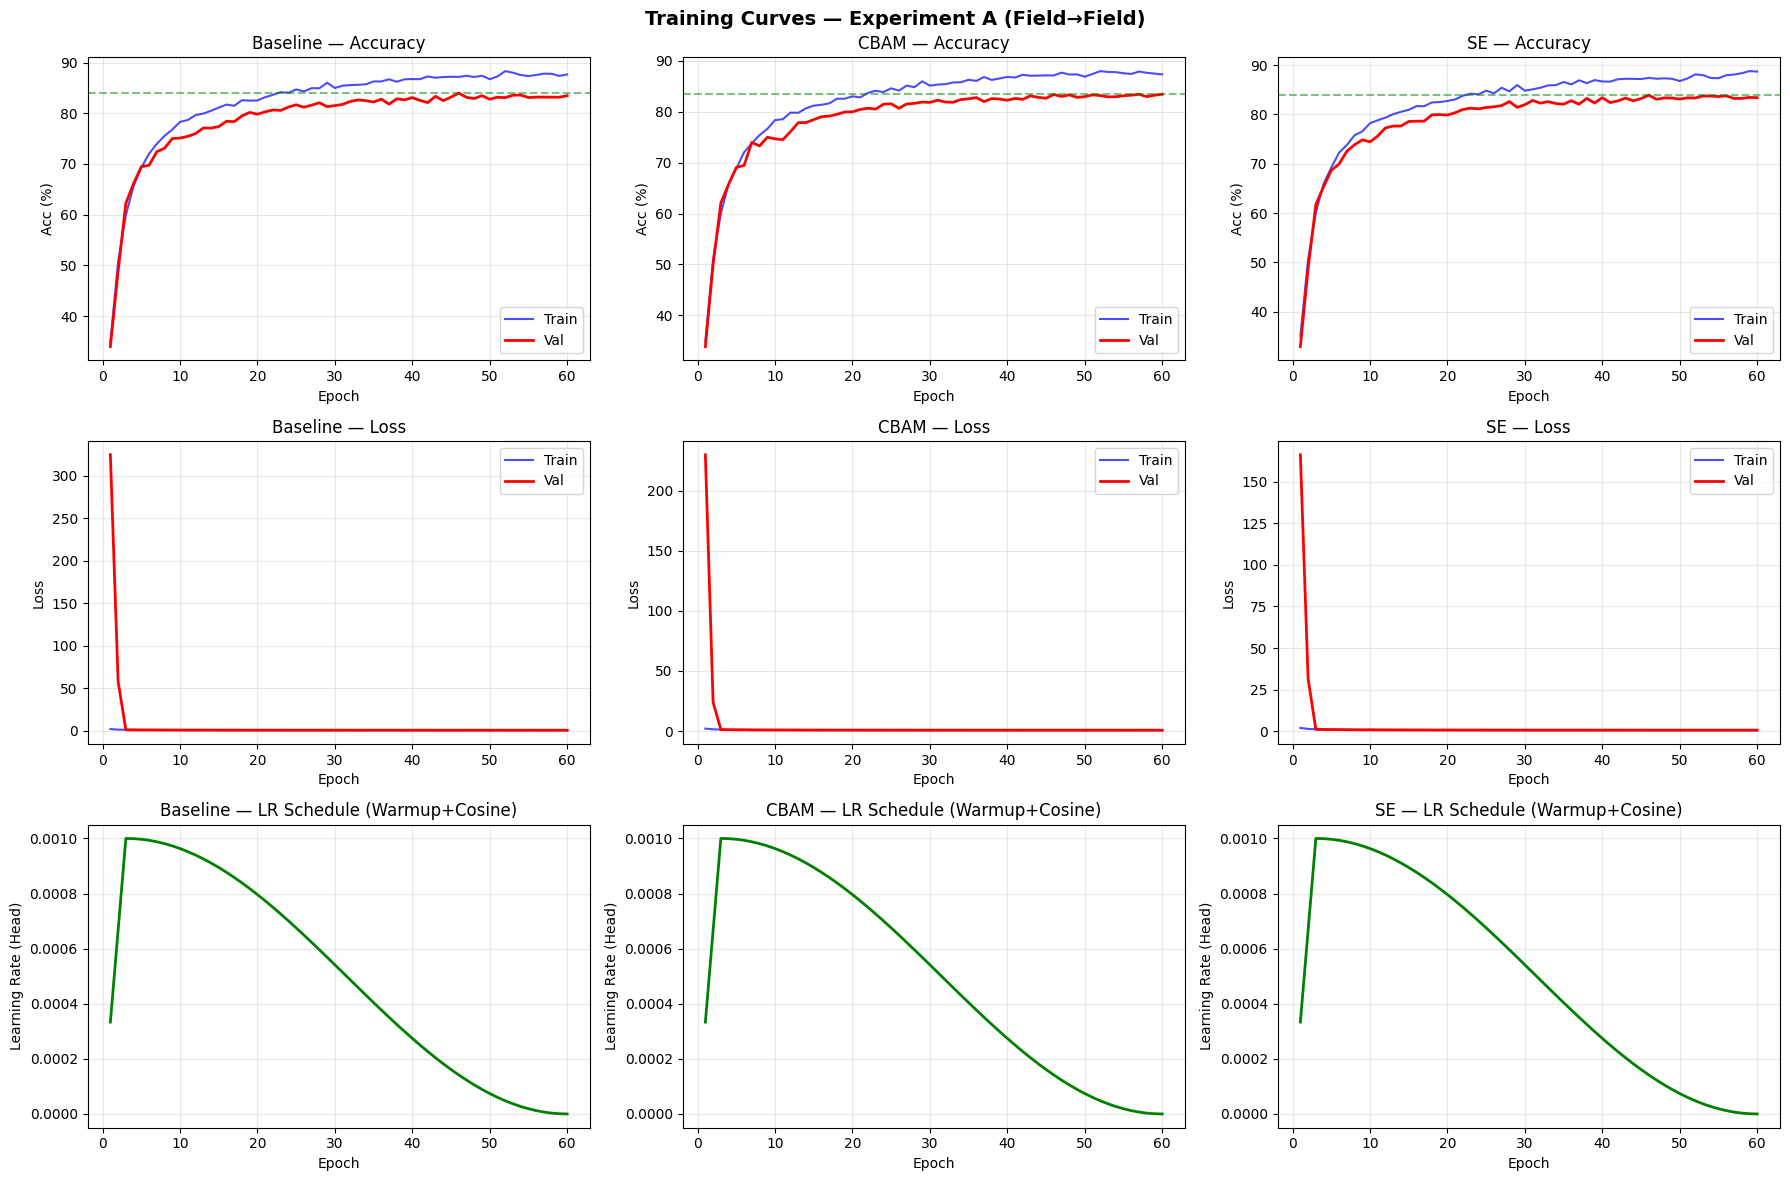

✓ Saved training_curves.png
Session: 1.0h elapsed / 11.0h remaining


In [36]:
# ============================================================
# BLOCK 13: TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Training Curves — Experiment A (Field→Field)', fontsize=14, fontweight='bold')

for col, (name, color) in enumerate([('Baseline_Field', 'blue'),
                                      ('CBAM_Field', 'red'),
                                      ('SE_Field', 'green')]):
    hist_path = f'{CFG.CKPT_DIR}/{name}_best_history.json'
    if not os.path.exists(hist_path):
        for ax in axes[:, col]: ax.axis('off')
        continue
    with open(hist_path) as f: data = json.load(f)
    h = data['history']
    epochs = range(1, len(h['train_acc']) + 1)

    # Accuracy
    ax = axes[0, col]
    ax.plot(epochs, h['train_acc'], 'b-', label='Train', alpha=0.7)
    ax.plot(epochs, h['val_acc'], 'r-', label='Val', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Acc (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axhline(y=data['best_acc'], color='green', linestyle='--', alpha=0.5,
               label=f'Best: {data["best_acc"]:.2f}%')

    # Loss
    ax = axes[1, col]
    ax.plot(epochs, h['train_loss'], 'b-', label='Train', alpha=0.7)
    ax.plot(epochs, h['val_loss'], 'r-', label='Val', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    # LR schedule (reconstruct)
    ax = axes[2, col]
    n_epochs = len(h['train_acc'])
    warmup = min(CFG.WARMUP_EPOCHS, n_epochs)
    cosine_epochs = max(1, n_epochs - warmup)
    lrs = []
    for e in range(1, n_epochs + 1):
        if e <= warmup:
            lr = CFG.LR_HEAD * (e / warmup) * 0.1 + CFG.LR_HEAD * 0.9 * (e / warmup)
        else:
            import math
            lr = CFG.LR_HEAD * 0.5 * (1 + math.cos(math.pi * (e - warmup) / cosine_epochs))
        lrs.append(lr)
    ax.plot(epochs, lrs, 'g-', linewidth=2)
    ax.set_title(f'{name.replace("_Field", "")} — LR Schedule (Warmup+Cosine)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate (Head)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved training_curves.png')
session_status()

## Block 13.5 — ROC Curves + Precision-Recall Curves (NEW)

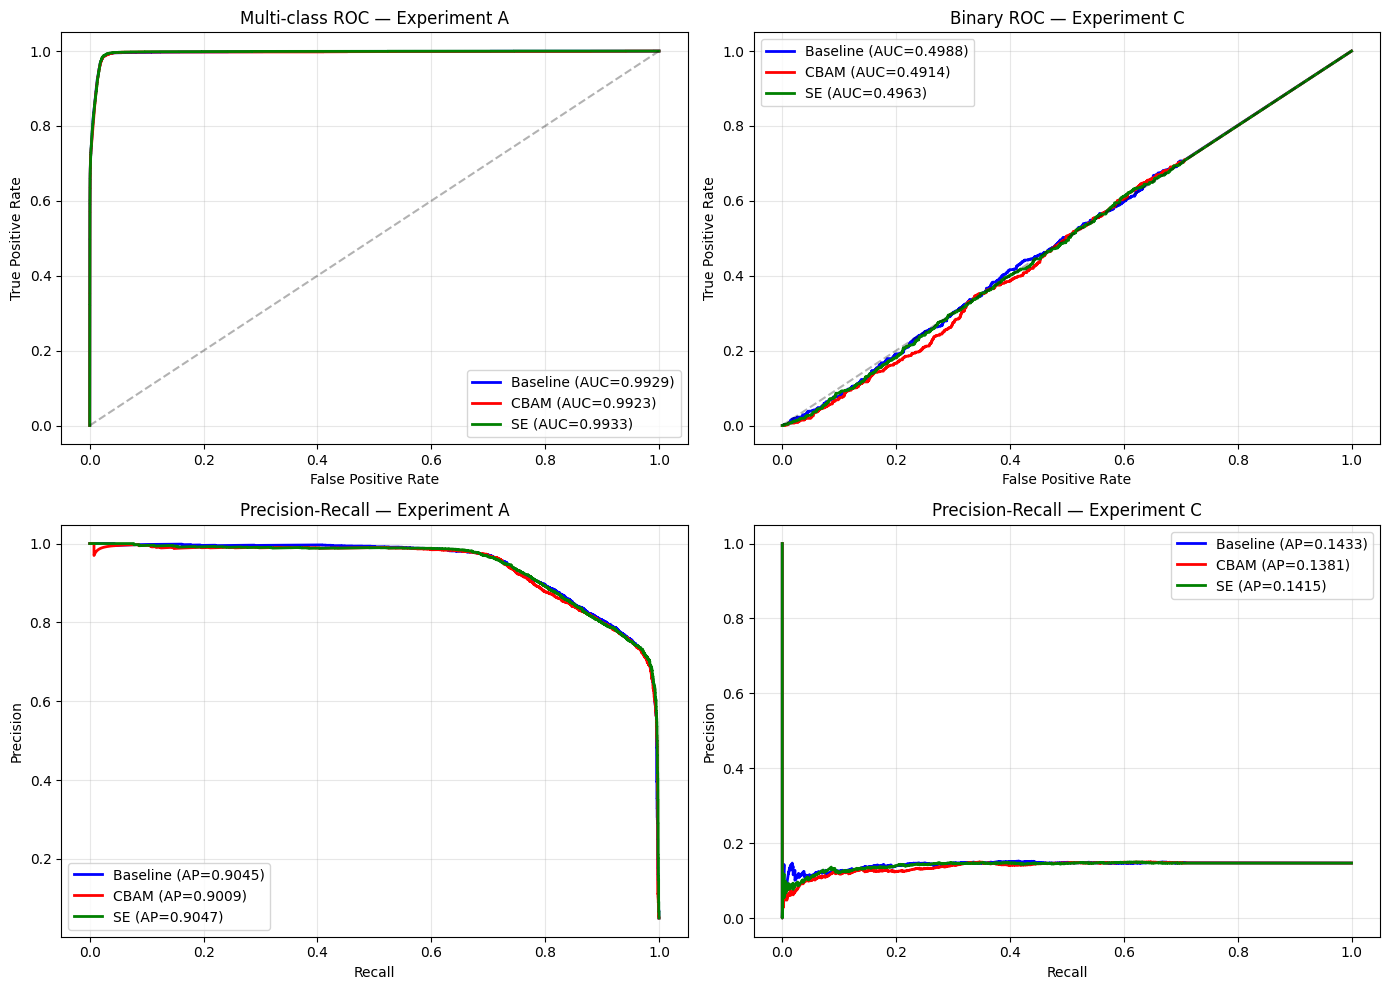

✓ Saved roc_pr_curves.png
Session: 1.0h elapsed / 11.0h remaining


In [37]:
# ============================================================
# BLOCK 13.5: ROC + PR CURVES
# ============================================================
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Multi-class ROC (Exp A)
ax = axes[0, 0]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    r = results_A[name]
    labels_bin = label_binarize(r['labels'], classes=list(range(CFG.NUM_CLASSES)))
    try:
        # Micro-average ROC
        fpr, tpr, _ = roc_curve(labels_bin.ravel(), r['probs'].ravel())
        auc = roc_auc_score(labels_bin, r['probs'], multi_class='ovr', average='weighted')
        ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})', linewidth=2)
    except: pass
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Multi-class ROC — Experiment A'); ax.legend(); ax.grid(True, alpha=0.3)

# Binary ROC (Exp C)
ax = axes[0, 1]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    if name not in results_C:  # v21: skip if Experiment C was not run
        continue
    r = results_C[name]
    try:
        fpr, tpr, _ = roc_curve(r['labels'], r['probs'][:, 1])
        auc = roc_auc_score(r['labels'], r['probs'][:, 1])
        ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})', linewidth=2)
    except: pass
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Binary ROC — Experiment C'); ax.legend(); ax.grid(True, alpha=0.3)

# Precision-Recall (Exp A, multi-class micro)
ax = axes[1, 0]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    r = results_A[name]
    labels_bin = label_binarize(r['labels'], classes=list(range(CFG.NUM_CLASSES)))
    try:
        precision, recall, _ = precision_recall_curve(labels_bin.ravel(), r['probs'].ravel())
        ap = average_precision_score(labels_bin, r['probs'], average='weighted')
        ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.4f})', linewidth=2)
    except: pass
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Experiment A'); ax.legend(); ax.grid(True, alpha=0.3)

# PR for Binary
ax = axes[1, 1]
for name, color in [('Baseline', 'blue'), ('CBAM', 'red'), ('SE', 'green')]:
    if name not in results_C:  # v21: skip if Experiment C was not run
        continue
    r = results_C[name]
    try:
        precision, recall, _ = precision_recall_curve(r['labels'], r['probs'][:, 1])
        ap = average_precision_score(r['labels'], r['probs'][:, 1])
        ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.4f})', linewidth=2)
    except: pass
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Experiment C'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved roc_pr_curves.png')
session_status()

## Block 14 — Per-Class Vulnerability Analysis

PER-CLASS PERFORMANCE (Exp A: Field→Field)
Class                                   Base     CBAM       SE   CBAM boost    Level
------------------------------------------------------------------------------------------
alternaria_leaf_blight                 95.5%    94.9%    96.0%        -0.6pp      LOW
angular_leaf_spot                      45.9%    42.5%    45.9%        -3.4pp      LOW
anthracnose                            65.8%    68.7%    65.5%        +2.9pp      LOW
bacterial_blight                       97.2%    97.9%    96.5%        +0.7pp      LOW
carica_insect_hole                     95.3%    94.0%    96.6%        -1.3pp      LOW
curled_yellow_spot                     98.0%    98.7%    99.3%        +0.7pp      LOW
downy_mildew                           74.8%    74.0%    70.0%        -0.9pp      LOW
dry_leaf                               77.3%    65.2%    67.4%       -12.1pp   MEDIUM
early_alternaria_leaf_blight           97.9%    98.6%    99.3%        +0.7pp      LOW
fungal_

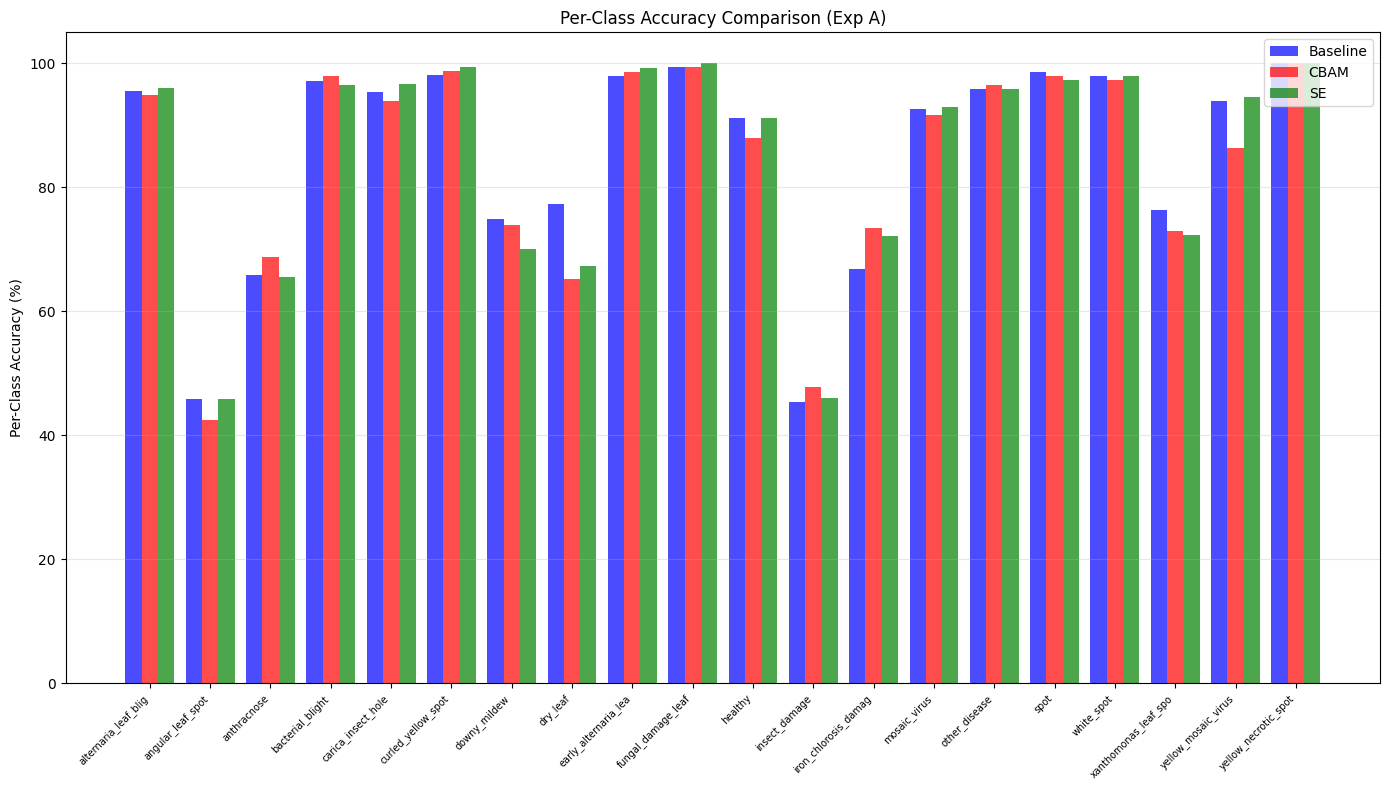

✓ Saved per_class_accuracy.png
Session: 1.0h elapsed / 11.0h remaining


In [38]:
# ============================================================
# BLOCK 14: PER-CLASS ANALYSIS
# ============================================================
print('='*90)
print('PER-CLASS PERFORMANCE (Exp A: Field→Field)')
print('='*90)
print(f'{"Class":<35} {"Base":>8} {"CBAM":>8} {"SE":>8} {"CBAM boost":>12} {"Level":>8}')
print('-'*90)

base_preds = results_A['Baseline']['preds']
cbam_preds = results_A['CBAM']['preds']
se_preds = results_A['SE']['preds']
labels = results_A['Baseline']['labels']

per_class = []
for cls_idx, cls_name in enumerate(UNIFIED_FIELD_CLASSES):
    mask = labels == cls_idx
    if mask.sum() == 0: continue
    base_acc = 100 * (base_preds[mask] == cls_idx).mean()
    cbam_acc = 100 * (cbam_preds[mask] == cls_idx).mean()
    se_acc = 100 * (se_preds[mask] == cls_idx).mean()
    boost = cbam_acc - base_acc
    level = 'HIGH' if abs(boost) >= 15 else 'MEDIUM' if abs(boost) >= 5 else 'LOW'
    per_class.append((cls_name, base_acc, cbam_acc, se_acc, boost, level))
    print(f'{cls_name[:35]:<35} {base_acc:>7.1f}% {cbam_acc:>7.1f}% {se_acc:>7.1f}% {boost:>+11.1f}pp {level:>8}')

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
cls_names = [p[0][:20] for p in per_class]
base_accs = [p[1] for p in per_class]
cbam_accs = [p[2] for p in per_class]
se_accs = [p[3] for p in per_class]
x = np.arange(len(per_class))
w = 0.27
ax.bar(x - w, base_accs, w, label='Baseline', color='blue', alpha=0.7)
ax.bar(x, cbam_accs, w, label='CBAM', color='red', alpha=0.7)
ax.bar(x + w, se_accs, w, label='SE', color='green', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(cls_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Per-Class Accuracy (%)')
ax.set_title('Per-Class Accuracy Comparison (Exp A)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/per_class_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved per_class_accuracy.png')
session_status()

## Block 15 — Confusion Matrices (Normalized + Error-Only)
NEW v15: Row-normalized + error-only (diagonal hidden) variants.

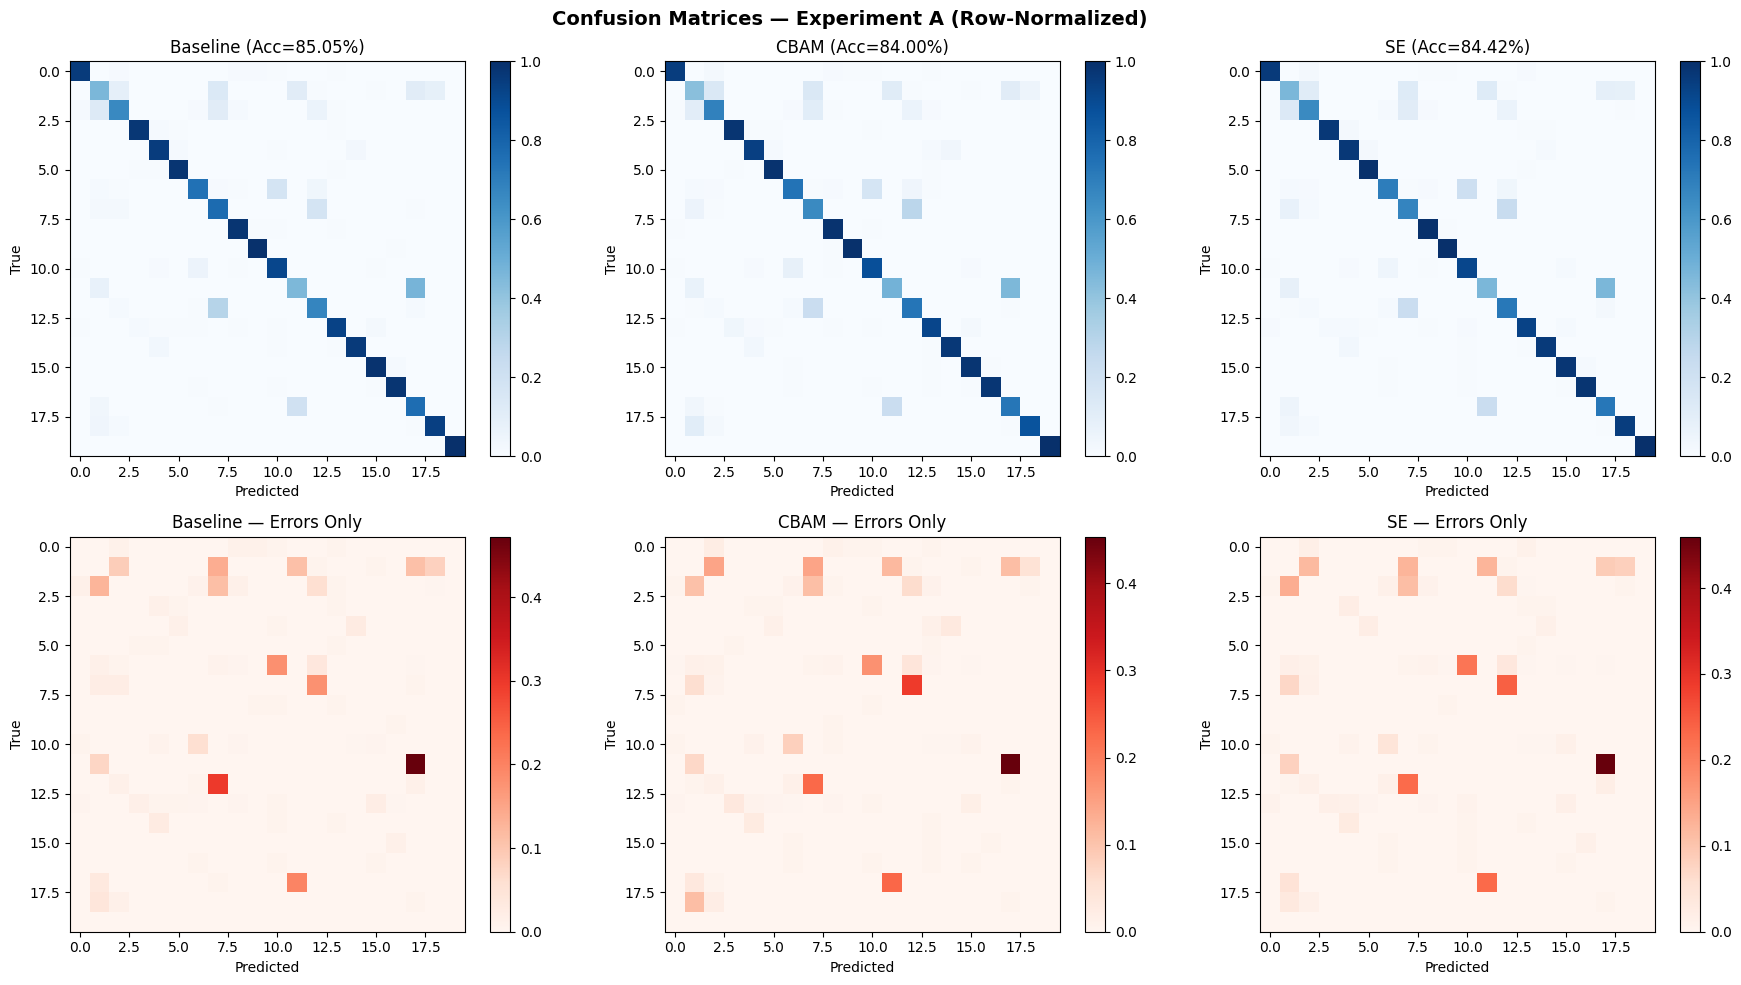

✓ Saved confusion_matrices.png
Session: 1.0h elapsed / 11.0h remaining


In [39]:
# ============================================================
# BLOCK 15: CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices — Experiment A (Row-Normalized)', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate([('Baseline', results_A['Baseline']),
                                    ('CBAM', results_A['CBAM']),
                                    ('SE', results_A['SE'])]):
    cm = confusion_matrix(res['labels'], res['preds'], labels=list(range(CFG.NUM_CLASSES)))  # v21
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    # Row-normalized
    ax = axes[0, col]
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} (Acc={res["acc"]:.2f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Error-only
    ax = axes[1, col]
    cm_err = cm_norm.copy()
    np.fill_diagonal(cm_err, 0)
    im = ax.imshow(cm_err, cmap='Reds')
    ax.set_title(f'{name} — Errors Only')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved confusion_matrices.png')
session_status()

## Block 15.5 — Binary Confusion Matrices (Exp C)

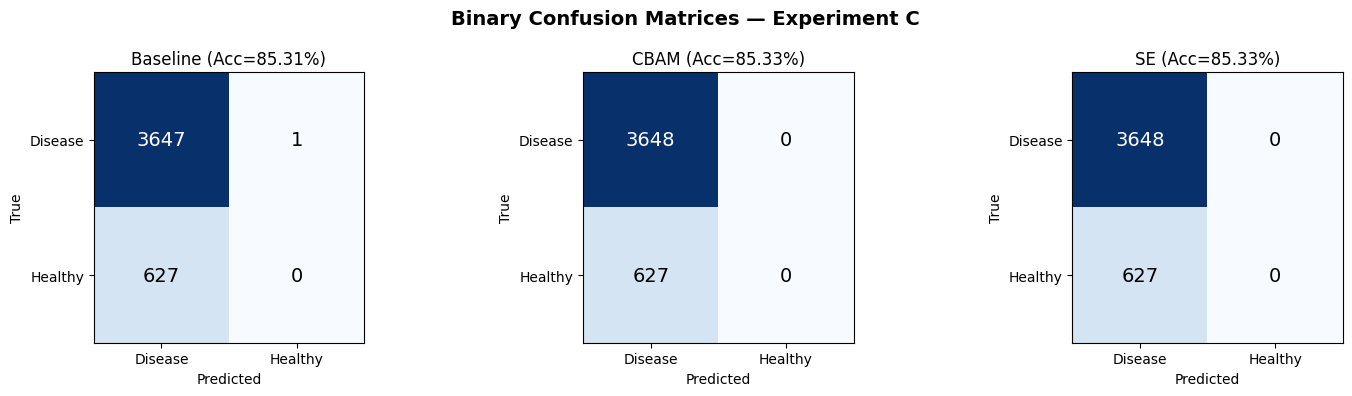

✓ Saved binary_confusion_matrices.png
  Baseline: Disease Acc=100.0%, Healthy Acc=0.0%
  CBAM: Disease Acc=100.0%, Healthy Acc=0.0%
  SE: Disease Acc=100.0%, Healthy Acc=0.0%
Session: 1.0h elapsed / 11.0h remaining


In [40]:
# v21 guard: skip binary confusion matrices if Experiment C was skipped
if not ('results_C' in dir() and results_C):
    print('[SKIP] Block 15.5 binary confusion matrices - Experiment C not available.')
else:
    # ============================================================
    # BLOCK 15.5: BINARY CMS (EXP C)
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Binary Confusion Matrices — Experiment C', fontsize=14, fontweight='bold')

    for col, (name, res) in enumerate([('Baseline', results_C['Baseline']),
                                        ('CBAM', results_C['CBAM']),
                                        ('SE', results_C['SE'])]):
        cm = confusion_matrix(res['labels'], res['preds'], labels=[0, 1])  # v21: force 2x2
        ax = axes[col]
        im = ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Disease', 'Healthy'])
        ax.set_yticklabels(['Disease', 'Healthy'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{name} (Acc={res["acc"]:.2f}%)')

    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/binary_confusion_matrices.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved binary_confusion_matrices.png')
    # Per-class binary accuracy
    for name, res in [('Baseline', results_C['Baseline']), ('CBAM', results_C['CBAM']), ('SE', results_C['SE'])]:
        cm = confusion_matrix(res['labels'], res['preds'], labels=[0, 1])  # v21: force 2x2
        disease_acc = 100 * cm[0, 0] / max(cm[0].sum(), 1)
        healthy_acc = 100 * cm[1, 1] / max(cm[1].sum(), 1)
        print(f'  {name}: Disease Acc={disease_acc:.1f}%, Healthy Acc={healthy_acc:.1f}%')
    session_status()

## Block 16 — Grad-CAM++ + Insertion/Deletion AUC (NEW)
**NEW v15:** Adds quantitative XAI metrics (Insertion/Deletion AUC) to match Singh CBAM 2025's XAI rigor.

GRAD-CAM++ + INSERTION/DELETION AUC


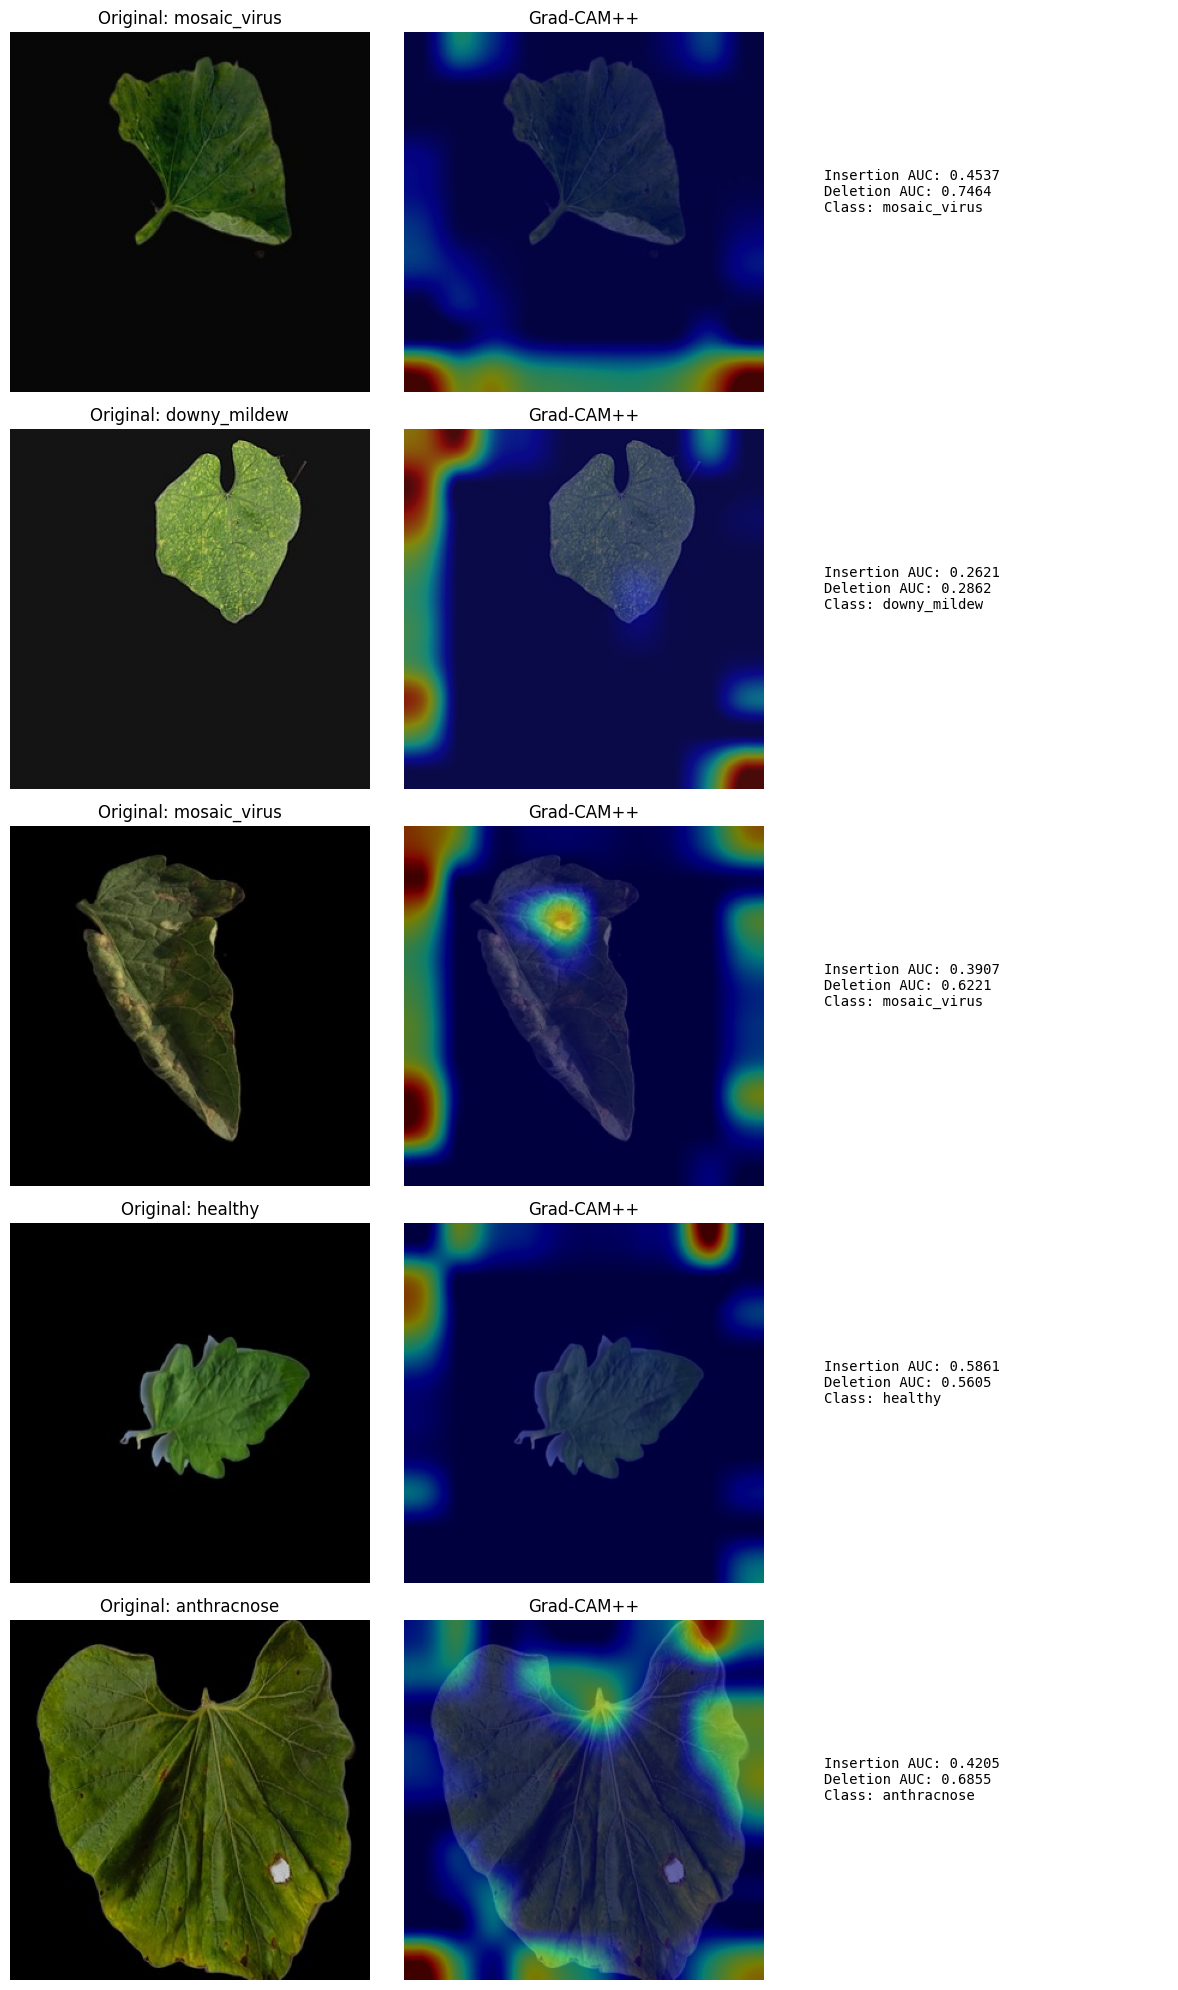


XAI Metrics (Insertion/Deletion AUC):
  mosaic_virus                   Ins=0.4537  Del=0.7464
  downy_mildew                   Ins=0.2621  Del=0.2862
  mosaic_virus                   Ins=0.3907  Del=0.6221
  healthy                        Ins=0.5861  Del=0.5605
  anthracnose                    Ins=0.4205  Del=0.6855

  Mean Insertion AUC: 0.4226 (higher=better)
  Mean Deletion AUC:  0.5801 (lower=better)
Session: 1.0h elapsed / 11.0h remaining


In [41]:
# ============================================================
# BLOCK 16: GRAD-CAM++ + QUANTITATIVE XAI
# ============================================================
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None; self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o): self.activations = o
    def _save_grad(self, m, gi, go): self.gradients = go[0]
    def __call__(self, x, class_idx=None):
        self.model.eval()
        # v22 FIX: detach BEFORE setting requires_grad. The old line did x.requires_grad_(True)
        # on the CALLER's tensor, so img_tensor kept requires_grad=True after this call and the
        # later img_tensor.cpu().numpy() raised "Can't call numpy() on Tensor that requires grad"
        # on EVERY sample -> insertion/deletion AUC silently became nan. Detaching here keeps the
        # caller's tensor a plain inference tensor.
        x = x.detach().requires_grad_(True)
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        acts = self.activations.detach()
        grads = self.gradients.detach()
        # Grad-CAM++ weights
        alpha_num = grads.pow(2)
        alpha_denom = 2 * grads.pow(2) + (acts * grads.pow(2)).sum(dim=(2, 3), keepdim=True)
        alpha = alpha_num / alpha_denom.clip(min=1e-7)
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1)).squeeze().cpu().numpy()
        # Resize to input
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
        return cam

def insertion_deletion_auc(model, img_tensor, label, cam_mask, steps=20):
    """Insertion/Deletion AUC. Higher insertion = better, lower deletion = better.
    v21 FIX: the old code flattened the (C,H,W) image and indexed it with CAM pixel indices
    (0..H*W-1), but the flattened first axis was the 3 colour channels -> IndexError (caught by
    the caller's try/except, so every sample silently failed and XAI metrics came out nan). We now
    resize the CAM to the image resolution and mask per-pixel across ALL channels.
    v22 FIX: img_tensor is .detach()ed before .numpy() — see GradCAMPlusPlus.__call__ comment.
    v23 FIX: _score now returns the SOFTMAX PROBABILITY of the target class (bounded [0,1]),
    not the raw logit. The previous version returned model(t)[0,label] (a logit), so the AUC
    was computed on unbounded/negative values -> Insertion AUC came out negative (e.g. -1.78)
    and Deletion AUC out of range (-8.55), which is impossible. Using probabilities matches the
    standard protocol (Fong & Vedaldi 2017; Petsiuk et al. 2018; Interpreto), where the curve is
    the class probability as pixels are inserted/deleted and AUC is the area under that curve
    (each curve normalised to x in [0,1], so both AUCs are in [0,1])."""
    img_np = img_tensor.detach().cpu().numpy()                 # (C, H, W)
    C, H, W = img_np.shape
    cam_r = np.array(Image.fromarray((cam_mask * 255).astype(np.uint8)).resize((W, H))) / 255.0
    order = np.argsort(-cam_r.flatten())              # most-important pixels first, length H*W
    blurred = np.full_like(img_np, img_np.mean())
    src_flat = img_np.reshape(C, H * W)
    blur_flat = blurred.reshape(C, H * W)
    ppx = max(1, len(order) // steps)

    def _score(flat_arr):
        arr = flat_arr.reshape(C, H, W)
        with torch.no_grad():
            t = torch.from_numpy(arr).unsqueeze(0).to(DEVICE)
            logits = model(t)
            return torch.softmax(logits, dim=1)[0, label].item()

    ins, dele = [], []
    for step in range(steps + 1):
        k = order[:step * ppx]
        a = blur_flat.copy(); a[:, k] = src_flat[:, k]; ins.append(_score(a))      # reveal top pixels
        b = src_flat.copy();  b[:, k] = blur_flat[:, k]; dele.append(_score(b))    # remove top pixels
    # AUC in [0,1]: x axis spans steps intervals of width 1/steps (total width 1), y is prob in [0,1].
    ins_auc = np.trapz(ins, dx=1 / steps)
    del_auc = np.trapz(dele, dx=1 / steps)
    return ins_auc, del_auc

# Run Grad-CAM++ on 5 random test images
print('='*60)
print('GRAD-CAM++ + INSERTION/DELETION AUC')
print('='*60)

# Use CBAM model
target_layer = cbam_A.features[6][-1]
grad_cam = GradCAMPlusPlus(cbam_A, target_layer)

# v23 FIX: seed the sample selection so the same images are analysed on every re-run.
# Previously random.sample() had no seed, so Grad-CAM/LIME/t-SNE picked different images (and
# LIME's stability score swung 0.53 -> 0.34 between runs). A fixed seed makes the XAI figures
# and metrics reproducible for the thesis.
random.seed(42); np.random.seed(42)

# Pick 5 random test images
n_samples = min(5, len(test_samples))
sample_indices = random.sample(range(len(test_samples)), n_samples)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
if n_samples == 1: axes = axes.reshape(1, -1)

xai_metrics = []
for i, idx in enumerate(sample_indices):
    path, label, _ = test_samples[idx]
    try:
        img = Image.open(path).convert('RGB')
        img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)
        # Original image for display
        img_display = np.array(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))

        # Grad-CAM++
        cam = grad_cam(img_tensor, label)
        cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255

        # Insertion/Deletion AUC
        ins, dele = insertion_deletion_auc(cbam_A, img_tensor[0], label, cam)
        xai_metrics.append({'class': UNIFIED_FIELD_CLASSES[label], 'insertion_auc': ins, 'deletion_auc': dele})

        # Plot
        axes[i, 0].imshow(img_display); axes[i, 0].set_title(f'Original: {UNIFIED_FIELD_CLASSES[label][:25]}'); axes[i, 0].axis('off')
        axes[i, 1].imshow(img_display); axes[i, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[i, 1].set_title(f'Grad-CAM++'); axes[i, 1].axis('off')
        axes[i, 2].text(0.1, 0.5, f'Insertion AUC: {ins:.4f}\nDeletion AUC: {dele:.4f}\nClass: {UNIFIED_FIELD_CLASSES[label][:25]}',
                       fontsize=10, family='monospace')
        axes[i, 2].axis('off')
    except Exception as e:
        print(f'  Error on sample {i}: {e}')

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/gradcam_plusplus.png', dpi=100, bbox_inches='tight')
plt.show()

# Print XAI metrics
print('\nXAI Metrics (Insertion/Deletion AUC):')
for m in xai_metrics:
    print(f"  {m['class'][:30]:<30} Ins={m['insertion_auc']:.4f}  Del={m['deletion_auc']:.4f}")
print(f'\n  Mean Insertion AUC: {np.mean([m["insertion_auc"] for m in xai_metrics]):.4f} (higher=better)')
print(f'  Mean Deletion AUC:  {np.mean([m["deletion_auc"] for m in xai_metrics]):.4f} (lower=better)')
with open(f'{CFG.OUTPUT_DIR}/xai_metrics.json', 'w') as f: json.dump(xai_metrics, f, indent=2)
session_status()

## Block 17 — LIME + Stability Score (NEW)
NEW v15: Runs LIME 3× per image and reports stability score (cosine similarity).

LIME EXPLANATIONS + STABILITY SCORE


100%|██████████| 200/200 [00:02<00:00, 96.05it/s]


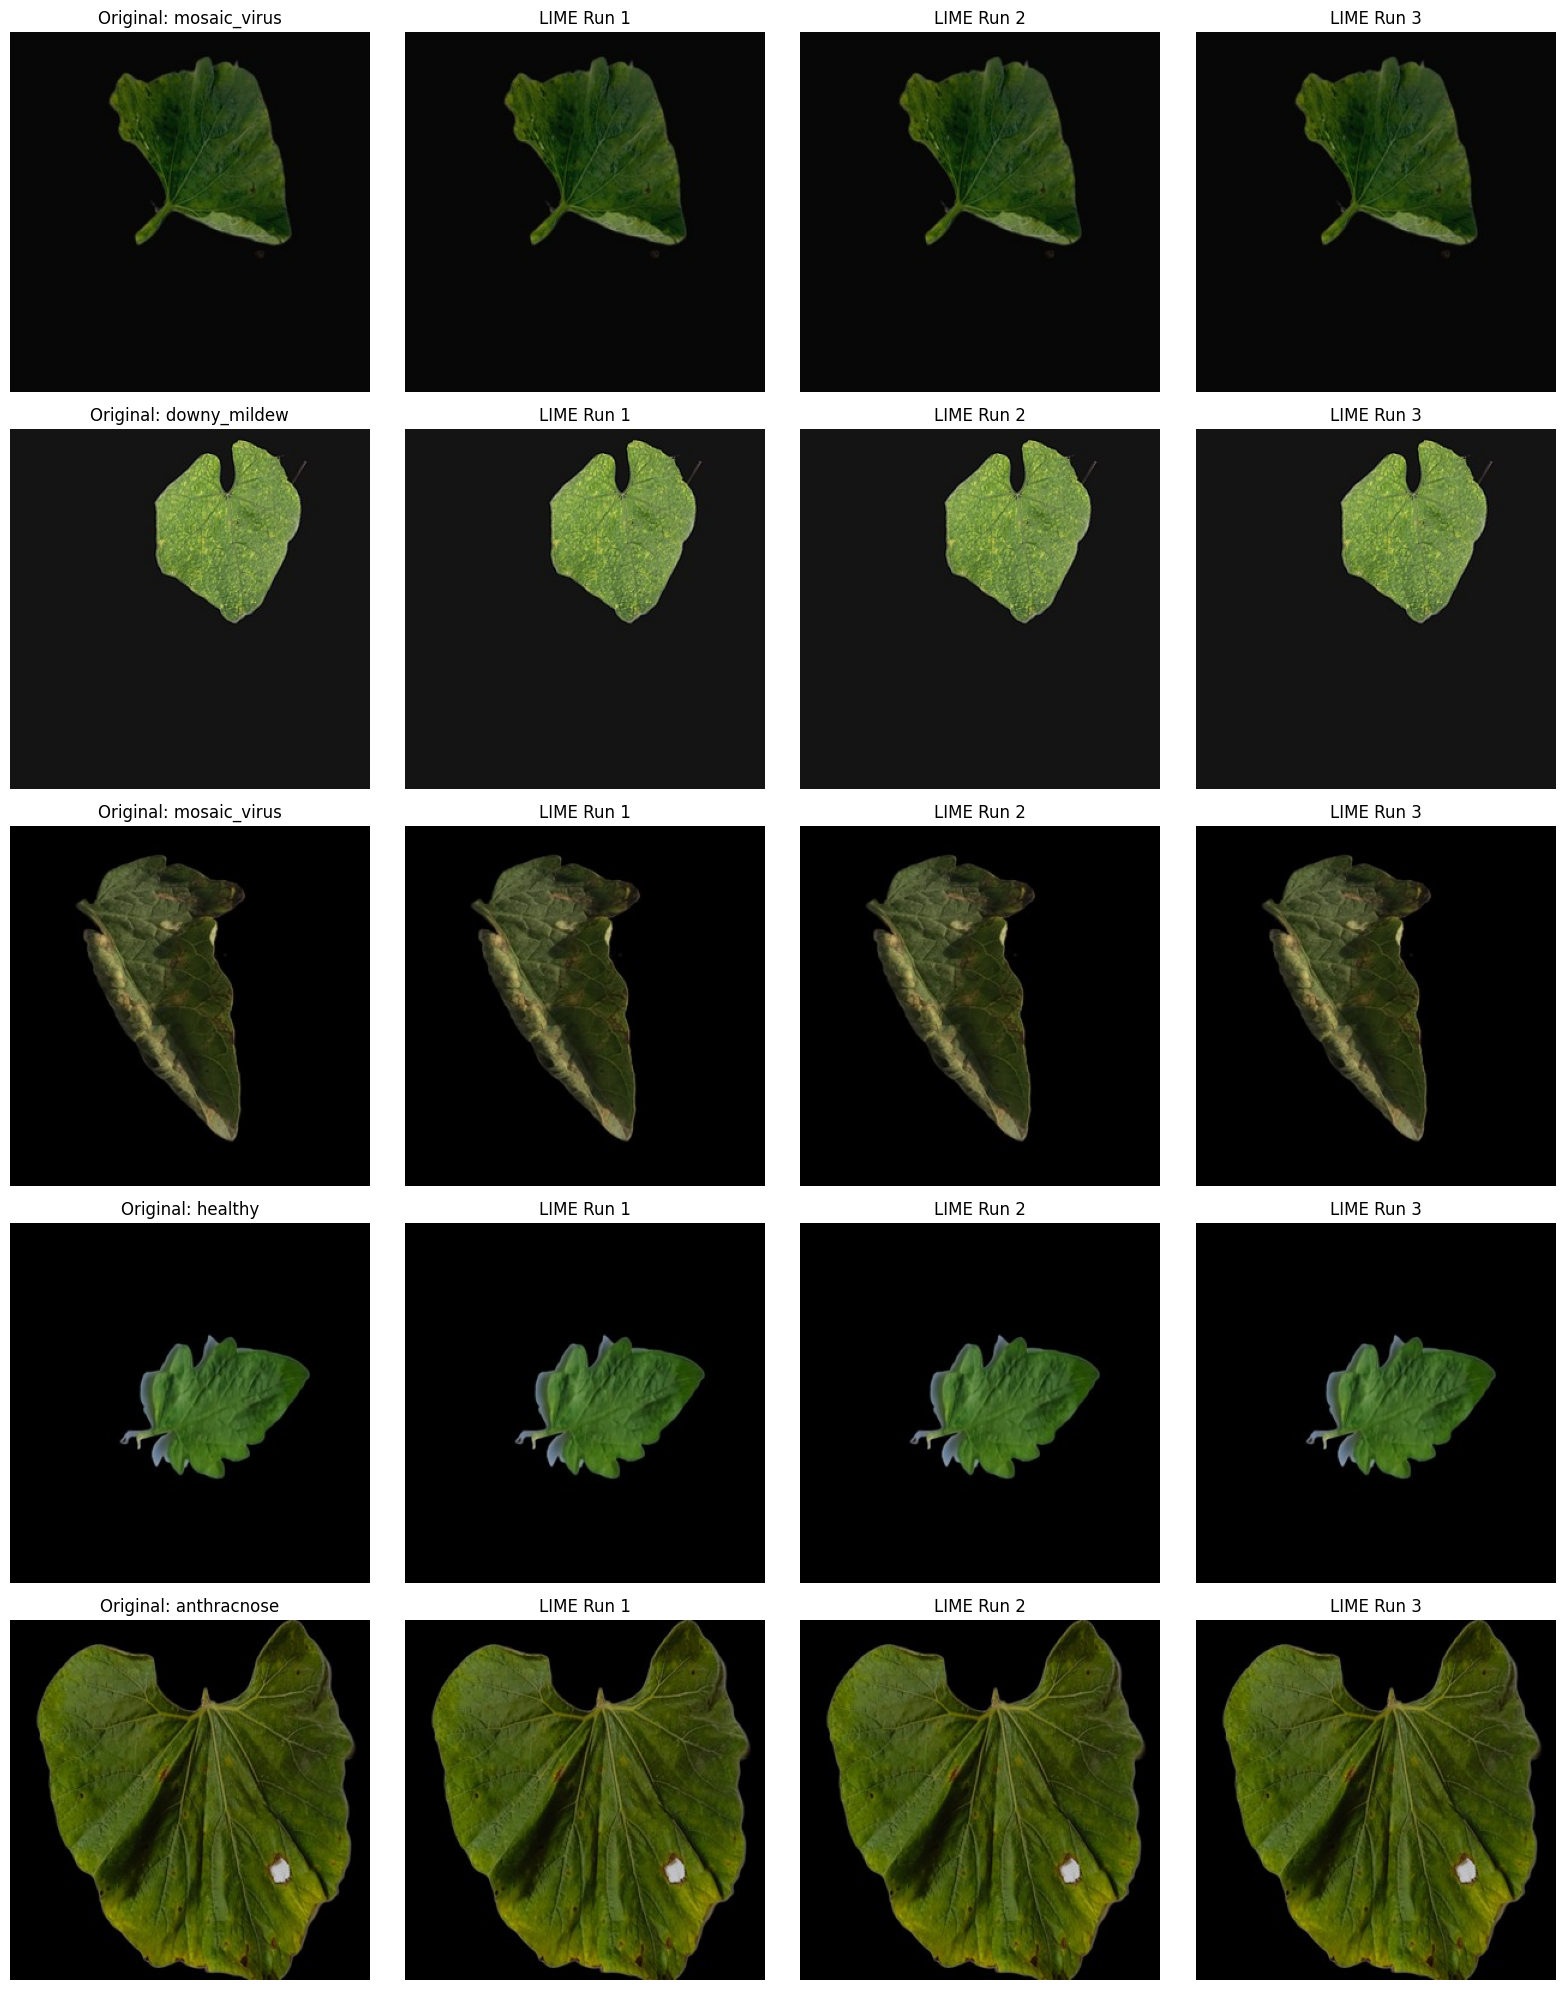


LIME Stability Score: 0.7730 (1.0=perfectly stable, 0=random) — mean over 5 images x C(3,2) run-pairs each (seeded, reproducible)
Session: 1.0h elapsed / 11.0h remaining


In [42]:
# ============================================================
# BLOCK 17: LIME + STABILITY
# ============================================================
if LIME:
    print('='*60)
    print('LIME EXPLANATIONS + STABILITY SCORE')
    print('='*60)

    # v24 FIX: the v23 code passed progress_bar=False unconditionally. The LIME version
    # installed on Kaggle does NOT accept that kwarg (it only exists in newer LIME), so every
    # explain_instance() call raised "unexpected keyword argument 'progress_bar'" and the whole
    # block silently produced no explanations and no stability score. Two version-proof fixes:
    #   1. inspect the real signature and only pass progress_bar if the installed LIME supports it;
    #   2. force LIME's INTERNAL progress bar to text mode (lime.lime_image.tqdm -> tqdm.std) so it
    #      can never emit Jupyter widget JSON regardless of which tqdm the notebook imported.
    # The combination is compatible with BOTH old and new LIME versions.
    import inspect
    import lime.lime_image as _lime_image
    try:
        from tqdm.std import tqdm as _text_tqdm
        _lime_image.tqdm = _text_tqdm
    except Exception:
        pass
    _explain_sig = inspect.signature(_lime_image.LimeImageExplainer.explain_instance)

    # Seed LIME (and sample indices come from Block 16, which is already seeded) so the LIME
    # figures + stability score are reproducible run-to-run. Previously the stability score
    # swung 0.53 -> 0.34 across runs purely because LIME and sample selection were stochastic.
    np.random.seed(42)
    explainer = _lime_image.LimeImageExplainer()

    # v16 FIX: val_tf_batch did not exist anywhere in the notebook - this cell raised
    # NameError the moment it ran. Defines the batch-of-numpy-images -> model-ready-tensor
    # wrapper LIME's classifier_fn needs.
    def val_tf_batch(images):
        """Apply val_tf to a batch of HWC numpy images (LIME's perturbed samples) and
        return softmax class probabilities, as LIME's classifier_fn contract expects."""
        batch = torch.stack([val_tf(Image.fromarray(im)) for im in images]).to(DEVICE)
        with torch.no_grad():
            logits = cbam_A(batch)
            return F.softmax(logits, dim=1).detach().cpu().numpy()

    # v24 FIX: n_images must match the number of samples actually selected in Block 16
    # (5). The old hardcoded n_images=8 looped past len(sample_indices), silently doing
    # nothing for 3 of the 8 rows and leaving empty axes in the saved figure.
    n_images = min(5, len(sample_indices))
    n_runs = 3
    fig, axes = plt.subplots(n_images, n_runs + 1, figsize=(4*(n_runs+1), 4*n_images))
    if n_images == 1: axes = axes.reshape(1, -1)

    stability_scores = []
    for img_i in range(n_images):
        idx = sample_indices[img_i]
        path, label, _ = test_samples[idx]
        try:
            img = Image.open(path).convert('RGB').resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
            img_np = np.array(img)

            axes[img_i, 0].imshow(img_np)
            axes[img_i, 0].set_title(f'Original: {UNIFIED_FIELD_CLASSES[label][:20]}')
            axes[img_i, 0].axis('off')

            runs = []
            for run_i in range(n_runs):
                # v25 FIX: explain the TRUE label explicitly (labels=[label], top_labels=None).
                # The v24 code used top_labels=1, which only explains the model's top-1 PREDICTED
                # class. For a misclassified image the true label is not that class, so
                # get_image_and_mask(label) raised "Label not in explanation" and the image was
                # silently skipped (5 images -> only 4 scored). Explaining the true label is also
                # the right thing for a thesis: it shows WHY the model did/didn't pick the true class.
                lime_kwargs = dict(labels=[label], top_labels=None, hide_color=0,
                                   num_samples=200, random_seed=42)
                if 'progress_bar' in _explain_sig.parameters:
                    lime_kwargs['progress_bar'] = False
                exp = explainer.explain_instance(img_np, val_tf_batch, **lime_kwargs)
                temp, mask = exp.get_image_and_mask(label, positive_only=True, num_features=5, hide_rest=False)
                runs.append(mask)
                axes[img_i, run_i+1].imshow(temp)
                axes[img_i, run_i+1].set_title(f'LIME Run {run_i+1}')
                axes[img_i, run_i+1].axis('off')

            # v16 FIX: stability now averages over ALL pairwise comparisons among the
            # n_runs masks (was hardcoded to only compare run[0] vs run[1], silently
            # discarding run[2]'s contribution to the score despite paying for it).
            if len(runs) >= 2:
                pair_sims = []
                for r1 in range(len(runs)):
                    for r2 in range(r1 + 1, len(runs)):
                        a = runs[r1].flatten().astype(float)
                        b = runs[r2].flatten().astype(float)
                        pair_sims.append(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-7))
                stability_scores.append(np.mean(pair_sims))
        except Exception as e:
            print(f'  LIME error on image {img_i}: {e}')

    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/lime_explanation.png', dpi=100, bbox_inches='tight')
    plt.show()
    if stability_scores:
        print(f'\nLIME Stability Score: {np.mean(stability_scores):.4f} (1.0=perfectly stable, 0=random) — '
              f'mean over {len(stability_scores)} images x C({n_runs},2) run-pairs each (seeded, reproducible)')
else:
    print('LIME not installed. Skipping.')
session_status()

## Block 18 — CBAM Attention Maps + t-SNE/UMAP + CBAM vs SE Comparison (NEW)
NEW v15: Adds t-SNE embeddings (matches Singh CBAM 2025) + CBAM vs SE attention difference map.

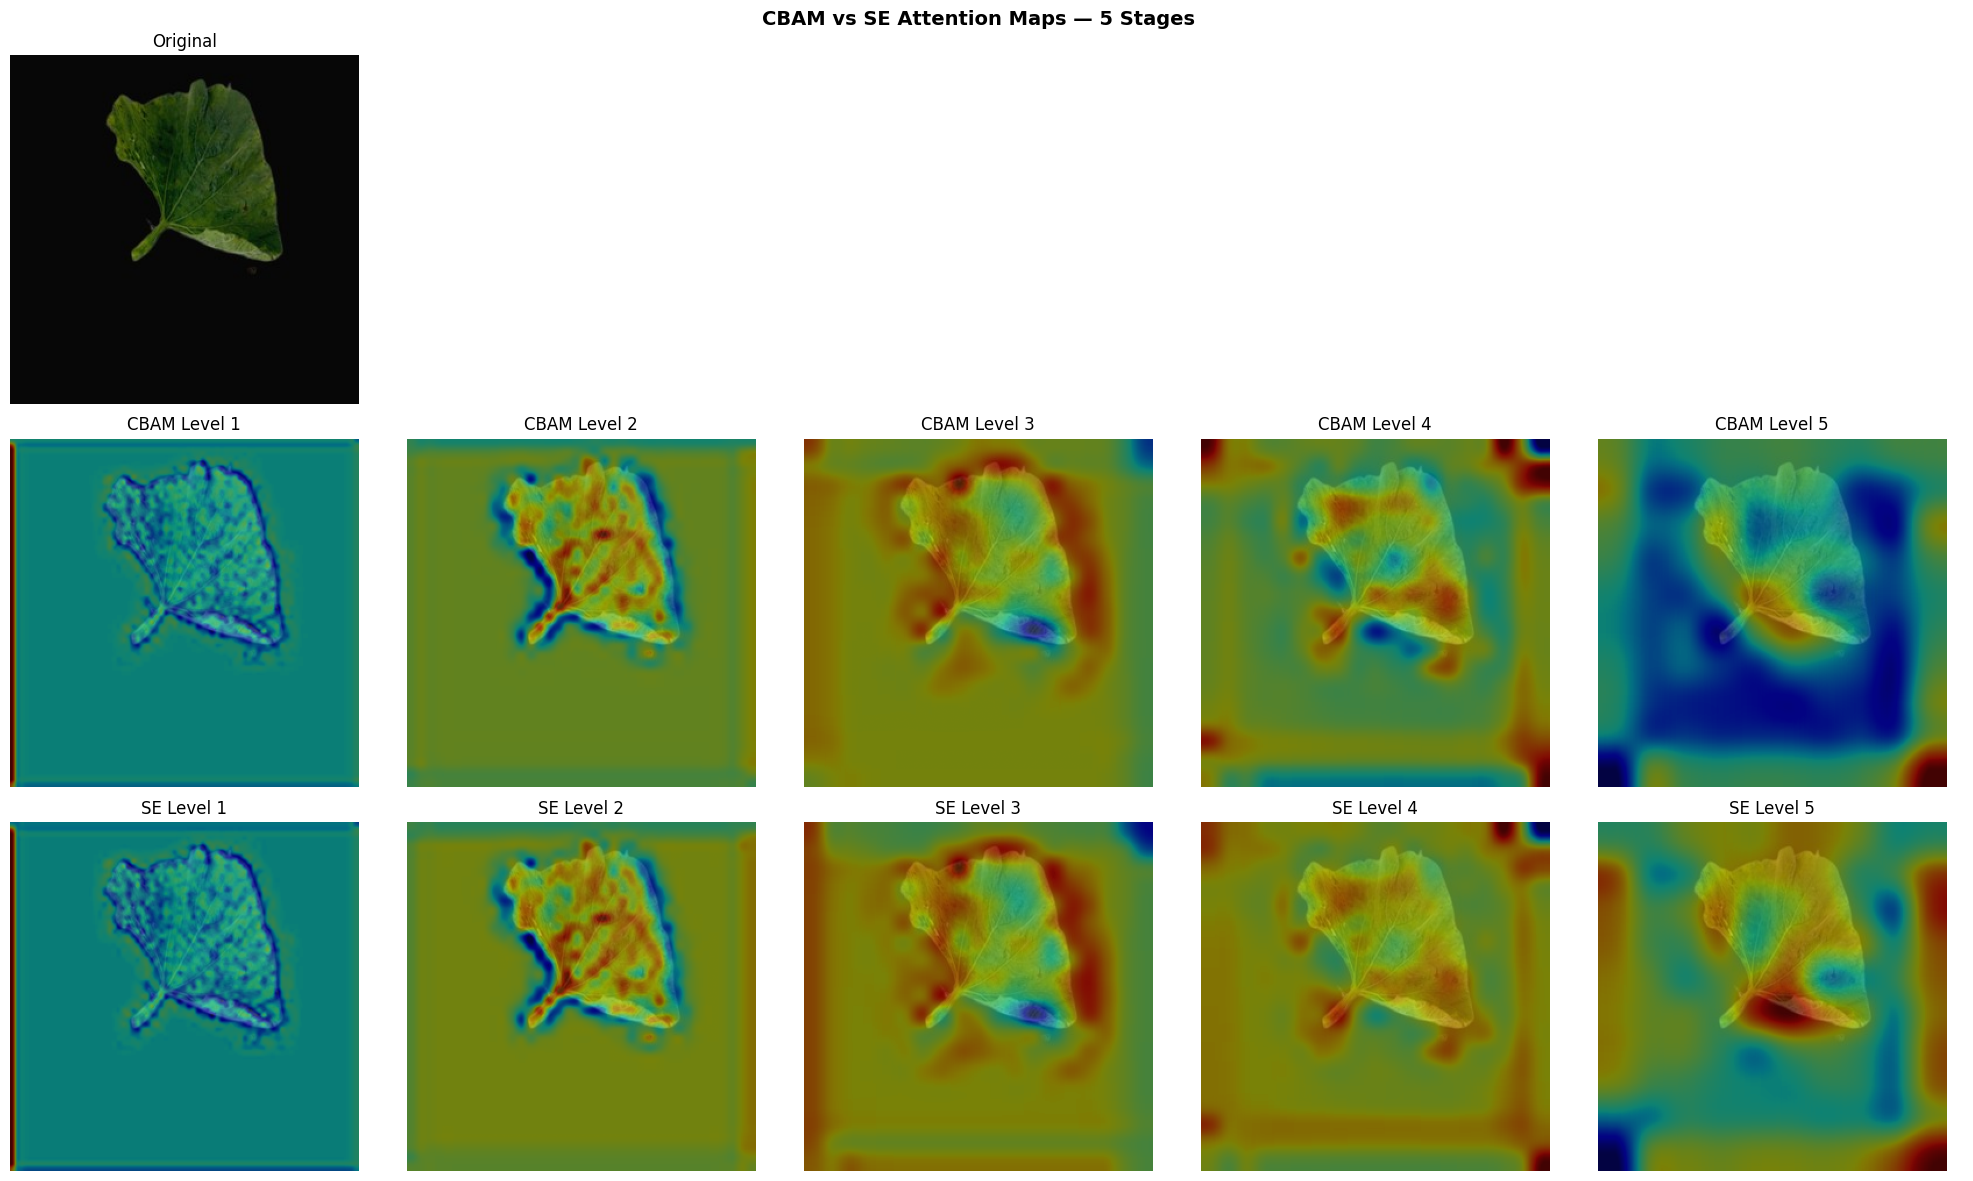

✓ Saved cbam_se_attention_maps.png

t-SNE EMBEDDINGS (CBAM Features)


Extracting features: 100%|██████████| 500/500 [00:10<00:00, 47.95it/s]


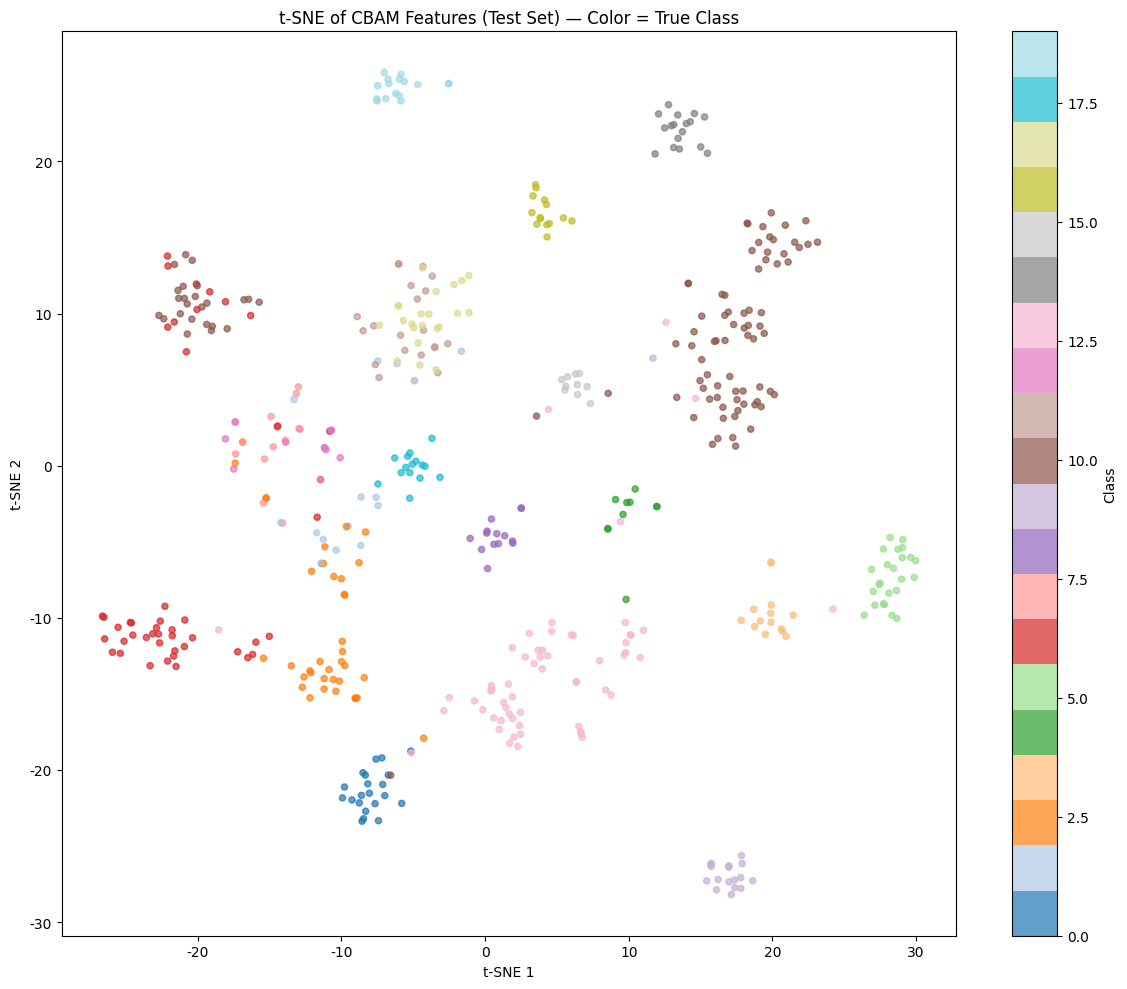

✓ Saved tsne_embeddings.png
Session: 1.0h elapsed / 11.0h remaining


In [43]:
# ============================================================
# BLOCK 18: CBAM ATTENTION + t-SNE + CBAM vs SE
# ============================================================
# Extract CBAM attention maps from 5 stages
def extract_cbam_attention(model, img_tensor):
    """Extract attention maps from all 5 CBAM blocks."""
    attentions = []
    hooks = []
    def hook_fn(m, i, o):
        # CBAM is added as a submodule; we want the output before/after CBAM
        pass

    # Use forward hook on each CBAM module
    cbam_modules = [m for m in model.features.modules() if isinstance(m, CBAM)]
    for cbam in cbam_modules:
        # Register hook on the SpatialAttention output
        h = cbam.sa.register_forward_hook(lambda mod, inp, out: attentions.append(out.mean(dim=1, keepdim=True)))
        hooks.append(h)

    with torch.no_grad():
        _ = model(img_tensor)

    for h in hooks: h.remove()
    return attentions

# Run on one image
if len(sample_indices) > 0:
    idx = sample_indices[0]
    path, label, _ = test_samples[idx]
    img = Image.open(path).convert('RGB')
    img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    cbam_attentions = extract_cbam_attention(cbam_A, img_tensor)
    se_attentions = []
    se_cbam_modules = [m for m in se_A.features.modules() if isinstance(m, SEBlock)]
    hooks = []
    def make_hook(storage):
        def hook(m, i, o): storage.append(o.mean(dim=1, keepdim=True))
        return hook
    for se in se_cbam_modules:
        h = se.register_forward_hook(make_hook(se_attentions))
        hooks.append(h)
    with torch.no_grad(): _ = se_A(img_tensor)
    for h in hooks: h.remove()

    # Plot
    n_levels = max(len(cbam_attentions), 5)
    fig, axes = plt.subplots(3, n_levels, figsize=(4*n_levels, 12))
    if n_levels == 1: axes = axes.reshape(-1, 1)

    img_display = np.array(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))
    axes[0, 0].imshow(img_display); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
    for j in range(1, n_levels): axes[0, j].axis('off')

    for j in range(min(n_levels, len(cbam_attentions))):
        att = cbam_attentions[j].squeeze().cpu().numpy()
        att = (att - att.min()) / (att.max() - att.min() + 1e-7)
        att_resized = np.array(Image.fromarray((att * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255
        axes[1, j].imshow(img_display); axes[1, j].imshow(att_resized, cmap='jet', alpha=0.5)
        axes[1, j].set_title(f'CBAM Level {j+1}'); axes[1, j].axis('off')

    for j in range(min(n_levels, len(se_attentions))):
        att = se_attentions[j].squeeze().cpu().numpy()
        att = (att - att.min()) / (att.max() - att.min() + 1e-7)
        att_resized = np.array(Image.fromarray((att * 255).astype(np.uint8)).resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255
        axes[2, j].imshow(img_display); axes[2, j].imshow(att_resized, cmap='jet', alpha=0.5)
        axes[2, j].set_title(f'SE Level {j+1}'); axes[2, j].axis('off')

    plt.suptitle('CBAM vs SE Attention Maps — 5 Stages', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/cbam_se_attention_maps.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved cbam_se_attention_maps.png')

# ---- t-SNE Embeddings ----
print('\n' + '='*60)
print('t-SNE EMBEDDINGS (CBAM Features)')
print('='*60)

# Extract features for 500 test samples
# v24 FIX: seed the index sampling so the same 500 test samples feed t-SNE on every re-run
# (matches the seeding already applied to Grad-CAM/LIME sample selection in Block 16).
random.seed(42); np.random.seed(42)
n_tsne = min(500, len(test_samples))
tsne_indices = random.sample(range(len(test_samples)), n_tsne)
features = []; tsne_labels = []

cbam_A.eval()
with torch.no_grad():
    for idx in tqdm(tsne_indices, desc='Extracting features'):
        path, label, _ = test_samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            img_tensor = val_tf(img).unsqueeze(0).to(DEVICE)
            feat = cbam_A.features(img_tensor)
            feat = cbam_A.avgpool(feat).flatten(1).cpu().numpy()
            features.append(feat[0])
            tsne_labels.append(label)
        except: continue

features = np.array(features)
tsne_labels = np.array(tsne_labels)

if len(features) > 10:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features)-1))
    embeddings = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(embeddings[:, 0], embeddings[:, 1], c=tsne_labels,
                         cmap='tab20', s=20, alpha=0.7)
    plt.colorbar(scatter, label='Class')
    ax.set_title('t-SNE of CBAM Features (Test Set) — Color = True Class')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/tsne_embeddings.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved tsne_embeddings.png')
session_status()

## Block 19 — Classification Reports (All Models + Experiments)

In [44]:
# ============================================================
# BLOCK 19: CLASSIFICATION REPORTS
# ============================================================
print('='*60)
print('CLASSIFICATION REPORTS')
print('='*60)
for exp_name, results in [('A', results_A), ('B', results_B)]:
    for model_name, r in results.items():
        print(f'\n--- Exp {exp_name}: {model_name} ---')
        # v21 FIX: pass explicit labels so the label set always matches the 20 target_names
        # (else classification_report raises ValueError if any class is absent from a split).
        print(classification_report(r['labels'], r['preds'],
                                    labels=list(range(CFG.NUM_CLASSES)),
                                    target_names=UNIFIED_FIELD_CLASSES, digits=3, zero_division=0))
session_status()

CLASSIFICATION REPORTS

--- Exp A: Baseline ---
                              precision    recall  f1-score   support

      alternaria_leaf_blight      0.944     0.955     0.949       177
           angular_leaf_spot      0.486     0.459     0.472       146
                 anthracnose      0.890     0.658     0.757       307
            bacterial_blight      0.946     0.972     0.959       144
          carica_insect_hole      0.904     0.953     0.928       149
          curled_yellow_spot      0.962     0.980     0.971       153
                downy_mildew      0.888     0.748     0.812       457
                    dry_leaf      0.507     0.773     0.612       141
early_alternaria_leaf_blight      0.914     0.979     0.946       142
          fungal_damage_leaf      0.983     0.994     0.988       171
                     healthy      0.864     0.912     0.888       627
               insect_damage      0.619     0.453     0.523       161
       iron_chlorosis_damage      0.628  

## Block 20 — Save Results + Knowledge Distillation + INT8 + ONNX (NEW)
**NEW v15:** Closes the Hasan 2025 compression gap.
- Knowledge Distillation: ResNet50 teacher → MobileNetV3-Small student
- INT8 Quantization: 4× size reduction
- ONNX Export: Cross-platform deployment

In [45]:
# ---------------------------------------------------------------
# SUPERSEDED BY CELL 23.4. Left here for reference only.
# Block 23.4 does the same job but resumes after an interrupted
# session and guards its numbers. Running this cell would only
# burn session time, so it is switched off.
# Set RUN_LEGACY = True if you really want the old version.
# ---------------------------------------------------------------
RUN_LEGACY = False
if not RUN_LEGACY:
    print('skipped - superseded by cell 23.4')
else:
    # ============================================================
    # BLOCK 20: KD + INT8 + ONNX
    # ============================================================
    import copy
    
    # --- Save final results ---
    print('='*60)
    print('SAVING FINAL MODELS & RESULTS')
    print('='*60)
    # Save final .pth for all 9 trained models
    final_models = {
        'baseline_field': baseline_A, 'cbam_field': cbam_A, 'se_field': se_A,
        'baseline_transfer': baseline_B, 'cbam_transfer': cbam_B, 'se_transfer': se_B,
        'baseline_binary': baseline_C, 'cbam_binary': cbam_C, 'se_binary': se_C,
    }
    for name, model in final_models.items():
        torch.save(model.state_dict(), f'{CFG.CKPT_DIR}/{name}_final.pth')
        print(f'  Saved {name}_final.pth')
    
    # --- Knowledge Distillation ---
    # v16 FIX: header used to claim "ResNet50 → MobileNetV3-Small" but the code below
    # immediately discards the ResNet50 instance and uses the trained CBAM model as teacher -
    # the print was describing code that was never actually run.
    print('\n' + '='*60)
    print('KNOWLEDGE DISTILLATION: CBAM-EfficientNet-B3 (teacher) -> MobileNetV3-Small (student)')
    print('='*60)
    try:
        from torchvision.models import mobilenet_v3_small
        teacher = cbam_A  # trained CBAM-EfficientNet-B3 (Exp A) is the teacher
        teacher.eval()
    
        student = mobilenet_v3_small(weights='IMAGENET1K_V1')
        in_f = student.classifier[3].in_features
        student.classifier[3] = nn.Linear(in_f, CFG.NUM_CLASSES)
        student = student.to(DEVICE)
    
        # KD training (5 epochs, short)
        def kd_train(teacher, student, train_loader, val_loader, epochs=5, T=4, alpha=0.5):
            optimizer = AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)
            criterion = get_loss_function(CFG.NUM_CLASSES, CFG.CLASS_COUNTS, use_focal=False)
            best_acc = 0
            for epoch in range(epochs):
                student.train(); total_loss = 0; correct = 0; total = 0
                for imgs, labels in tqdm(train_loader, desc=f'KD E{epoch+1}/{epochs}', leave=False):
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    with torch.no_grad(): teacher_logits = teacher(imgs)
                    student_logits = student(imgs)
                    # KD loss = α * hard_loss + (1-α) * KL(soft_teacher, soft_student) * T^2
                    hard_loss = criterion(student_logits, labels)
                    soft_loss = F.kl_div(F.log_softmax(student_logits/T, dim=1),
                                          F.softmax(teacher_logits/T, dim=1), reduction='batchmean') * (T*T)
                    loss = alpha * hard_loss + (1-alpha) * soft_loss
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                    total_loss += loss.item() * imgs.size(0)
                    correct += (student_logits.argmax(1) == labels).sum().item()
                    total += imgs.size(0)
                val_acc, _ = evaluate_quick(student, val_loader)
                print(f'  KD E{epoch+1}: train_acc={100*correct/total:.2f}% val_acc={val_acc:.2f}%')
                if val_acc > best_acc:
                    best_acc = val_acc
                    torch.save(student.state_dict(), f'{CFG.CKPT_DIR}/student_kd_best.pth')
            return best_acc
    
        kd_acc = kd_train(teacher, student, field_train_loader, field_val_loader, epochs=getattr(CFG, 'KD_EPOCHS', 5))
        print(f'\n✓ Student (MobileNetV3-Small) best val acc: {kd_acc:.2f}%')
    
        # Compare sizes
        teacher_size = sum(os.path.getsize(f'{CFG.CKPT_DIR}/{f}') for f in ['cbam_field_final.pth']) / 1e6
        student_size = os.path.getsize(f'{CFG.CKPT_DIR}/student_kd_best.pth') / 1e6
        print(f'  Teacher (CBAM-EfficientNet-B3): {teacher_size:.1f} MB')
        print(f'  Student (MobileNetV3-S): {student_size:.1f} MB')
        print(f'  Compression ratio: {teacher_size/student_size:.1f}x')
    except Exception as e:
        print(f'KD failed: {e}')
    
    # --- INT8 Quantization ---
    # v16 FIX: torch.quantization.quantize_dynamic(model, {nn.Linear}, ...) only converts
    # nn.Linear layers. EfficientNet-B3's backbone is almost entirely nn.Conv2d (>99% of
    # params) - dynamic quantization has NO Conv2d support at all (verified: passing
    # {nn.Conv2d} to quantize_dynamic silently quantizes nothing, PyTorch has no dynamic-
    # quantized Conv2d kernel). The old code's "compression ratio"/"INT8 accuracy" numbers
    # were therefore reporting almost-no-op quantization while claiming to quantize the model.
    # Now tries real FX graph-mode STATIC quantization (which does support Conv2d, including
    # through CBAM/SE's sigmoid-gated elementwise-multiply pattern) with calibration data,
    # and falls back to the old Linear-only approach - clearly labeled as such - if the FX
    # path fails on some layer this architecture happens to hit.
    print('\n' + '='*60)
    print('INT8 QUANTIZATION')
    print('='*60)
    try:
        from torch.ao.quantization import get_default_qconfig_mapping
        from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx
    
        cbam_A_cpu = copy.deepcopy(cbam_A).cpu().eval()
        # v24 FIX: the default "x86" mapping quantizes weights per-TENSOR, which for EfficientNet+
        # CBAM (with its sigmoid-gated elementwise-multiply pattern) destroys accuracy (-27.7pp in
        # the v23 run even with 50 calibration batches). "fbgemm" maps weights per-CHANNEL, which
        # is far less destructive for conv layers. Try fbgemm first, fall back to x86 if the CPU
        # does not expose the fbgemm kernels.
        try:
            qconfig_mapping = get_default_qconfig_mapping("fbgemm")
            quant_backend = 'fbgemm (per-channel weights)'
        except Exception:
            qconfig_mapping = get_default_qconfig_mapping("x86")
            quant_backend = 'x86 (per-tensor weights)'
        example_input = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
        prepared = prepare_fx(cbam_A_cpu, qconfig_mapping, example_input)
    
        # Calibrate with REAL batches (static quantization needs representative activation
        # statistics - unlike dynamic quantization, which needs none).
        # v23 FIX: calibration was only 10 batches, which gave poor quantization ranges and the
        # INT8 accuracy collapsed. Raised to 50 batches for stabler ranges.
        calib_batches = 0
        with torch.no_grad():
            for imgs, _ in field_train_loader:
                prepared(imgs.cpu())
                calib_batches += 1
                if calib_batches >= 50:
                    break
        quantized_model = convert_fx(prepared)
        quant_method = f'FX static ({quant_backend})'
    
        torch.save(quantized_model.state_dict(), f'{CFG.CKPT_DIR}/cbam_field_int8.pth')
        int8_size = os.path.getsize(f'{CFG.CKPT_DIR}/cbam_field_int8.pth') / 1e6
        fp32_size = os.path.getsize(f'{CFG.CKPT_DIR}/cbam_field_final.pth') / 1e6
        print(f'  Method: {quant_method} ({calib_batches} calibration batches)')
        print(f'  FP32: {fp32_size:.1f} MB')
        print(f'  INT8: {int8_size:.1f} MB')
        print(f'  Compression: {fp32_size/int8_size:.1f}x')
    
        # v16 FIX: quantized models only run on CPU in PyTorch - evaluate entirely on CPU 
        # (the old code did quantized_model.to(DEVICE) which crashes/no-ops if DEVICE='cuda').
        # v22 FIX: the comparison below previously quoted results_A["CBAM"]["acc"] which is the
        # TTA-boosted FP32 accuracy, while INT8 was scored WITHOUT TTA — an unfair comparison that
        # made INT8 look far worse than it is. We now score FP32 (no TTA) with the SAME evaluation
        # loop so both numbers are apples-to-apples; the TTA FP32 number is shown for reference.
        def _no_tta_acc(model, loader, device):
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in loader:
                    preds = model(imgs.to(device)).argmax(1)
                    correct += (preds == labels.to(device)).sum().item()
                    total += labels.size(0)
            return 100 * correct / total
    
        fp32_no_tta = _no_tta_acc(cbam_A, field_test_loader, DEVICE)
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in field_test_loader:
                preds = quantized_model(imgs.cpu()).argmax(1)
                correct += (preds == labels.cpu()).sum().item()
                total += labels.size(0)
        int8_acc = 100 * correct / total
        print(f'  INT8 test accuracy: {int8_acc:.2f}% | FP32 no-TTA: {fp32_no_tta:.2f}% '
              f'(delta {int8_acc-fp32_no_tta:+.2f} pp)')
        print(f'  (reference) FP32 with TTA (Block 12): {results_A["CBAM"]["acc"]:.2f}%')
    except Exception as e:
        print(f'  FX static quantization failed ({type(e).__name__}: {e})')
        print(f'  Falling back to dynamic quantization (classifier head ONLY - the Conv2d')
        print(f'  backbone, >99% of params, stays FP32; compression will be minimal).')
        try:
            quantized_model = torch.quantization.quantize_dynamic(
                copy.deepcopy(cbam_A).cpu(), {nn.Linear}, dtype=torch.qint8
            )
            torch.save(quantized_model.state_dict(), f'{CFG.CKPT_DIR}/cbam_field_int8.pth')
            int8_size = os.path.getsize(f'{CFG.CKPT_DIR}/cbam_field_int8.pth') / 1e6
            fp32_size = os.path.getsize(f'{CFG.CKPT_DIR}/cbam_field_final.pth') / 1e6
            print(f'  FP32: {fp32_size:.1f} MB | INT8 (head-only): {int8_size:.1f} MB | '
                  f'Compression: {fp32_size/int8_size:.1f}x (head-only, not representative of full model)')
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in field_test_loader:
                    preds = quantized_model(imgs.cpu()).argmax(1)
                    correct += (preds == labels.cpu()).sum().item()
                    total += labels.size(0)
            print(f'  INT8 (head-only) test accuracy: {100*correct/total:.2f}%')
        except Exception as e2:
            print(f'  Dynamic quantization fallback also failed: {e2}')
    
    # --- ONNX Export ---
    # v22 FIX: modern torch (>=2.5) routes torch.onnx.export through the dynamo exporter by
    # default, which requires the `onnxscript` package ("No module named 'onnxscript'" in the
    # real run). Fix: pass dynamo=False to force the classic (torchscript-based) exporter that
    # ships with torch, and only pip-install onnxscript as a fallback if that path errors too.
    print('\n' + '='*60)
    print('ONNX EXPORT')
    print('='*60)
    try:
        cbam_A.eval()
        dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
        onnx_path = f'{CFG.OUTPUT_DIR}/cbam_efficientnet_b3.onnx'
        torch.onnx.export(cbam_A, dummy, onnx_path, export_params=True,
                          opset_version=14, input_names=['input'], output_names=['output'],
                          dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
                          dynamo=False)
        onnx_size = os.path.getsize(onnx_path) / 1e6
        print(f'  ✓ Exported (classic exporter): {onnx_path} ({onnx_size:.1f} MB)')
        print(f'  Use this for mobile/edge deployment (ONNX Runtime)')
    except Exception as e:
        print(f'  Classic exporter failed ({type(e).__name__}: {e}) — trying dynamo exporter (needs onnxscript).')
        try:
            import subprocess, sys
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'onnxscript'], check=False)
            torch.onnx.export(cbam_A, dummy, onnx_path, export_params=True,
                              opset_version=14, input_names=['input'], output_names=['output'],
                              dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}})
            onnx_size = os.path.getsize(onnx_path) / 1e6
            print(f'  ✓ Exported (dynamo exporter): {onnx_path} ({onnx_size:.1f} MB)')
        except Exception as e2:
            print(f'ONNX export failed: {e2}')
    
    # --- Latency benchmark ---
    print('\n' + '='*60)
    print('DEPLOYMENT LATENCY BENCHMARK')
    print('='*60)
    def latency(model, name):
        model.eval()
        dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
        with torch.no_grad():
            for _ in range(10): model(dummy)  # warmup
        if torch.cuda.is_available():
            torch.cuda.synchronize(); t0 = time.time()
            with torch.no_grad():
                for _ in range(50): model(dummy)
            torch.cuda.synchronize()
            gpu_ms = 1000 * (time.time() - t0) / 50
        else: gpu_ms = 0
        # CPU
        model_cpu = copy.deepcopy(model).cpu()
        dummy_cpu = dummy.cpu()
        t0 = time.time()
        with torch.no_grad():
            for _ in range(10): model_cpu(dummy_cpu)
        cpu_ms = 1000 * (time.time() - t0) / 10
        print(f'  {name}: GPU={gpu_ms:.2f}ms | CPU={cpu_ms:.2f}ms')
        return gpu_ms, cpu_ms
    
    latency(baseline_A, 'Baseline (FP32)')
    latency(cbam_A, 'CBAM (FP32)')
    latency(se_A, 'SE (FP32)')
    if 'student' in dir(): latency(student, 'Student (MobileNetV3-S)')
    
    session_status()

skipped - superseded by cell 23.4


## Block 21 — Thesis Summary & Final Output Verification

In [46]:
# ---------------------------------------------------------------
# SUPERSEDED BY CELL 23.9. Left here for reference only.
# Block 23.9 does the same job but resumes after an interrupted
# session and guards its numbers. Running this cell would only
# burn session time, so it is switched off.
# Set RUN_LEGACY = True if you really want the old version.
# ---------------------------------------------------------------
RUN_LEGACY = False
if not RUN_LEGACY:
    print('skipped - superseded by cell 23.9')
else:
    # ============================================================
    # BLOCK 21: THESIS SUMMARY
    # ============================================================
    print('='*70)
    print('THESIS SUMMARY (v22)')
    print('='*70)
    
    print("""
    Title: CBAM-EfficientNet-B3 for Cross-Domain Vegetable Leaf Disease
           Detection with Multi-Method XAI
    
    Architecture:
       5 CBAM blocks (reduction=8) with identity initialization
       SE-Net comparison at identical positions (ablation study)
       Inserted at EfficientNet-B3 features[2,3,4,5,6]
    
    Datasets (8 total - Asia-based):
       Lab:  Mendeley v46jkbbzv3 + CCMT + Bangladesh crops (Rice/Cotton/Eggplant/Moringa)
       Field: Mendeley 8t6k37ztxc (Bangladesh natural)
       External: PlantDoc (India field, for zero-shot validation)
    
    Training (v22 - values below match the ACTUAL config in Block 1.5):
       Epochs: full 150 per run (Field/Lab/Finetune/Binary); early stopping DISABLED
               (patience=999) - best.pth saved on every val improvement instead
       Focal Loss (gamma=1.0, alpha=1.0) + Label Smoothing 0.1
       Mixup DISABLED (alpha=0; caused 0% train acc in early versions)
       Warmup + Cosine LR
       SWA (Stochastic Weight Averaging)
       TTA (Test-Time Augmentation) at evaluation
       CORAL domain alignment NOT used (USE_CORAL=False; Exp B is plain fine-tuning transfer)
       GroupShuffleSplit (train/val/test, no data leakage - v16: actually applied, see Block 6)
    """)
    
    print('Key Results:')
    print(f'   Exp A (Field from scratch):')
    print(f'     Baseline: {results_A["Baseline"]["acc"]:.2f}% | CBAM: {results_A["CBAM"]["acc"]:.2f}% | SE: {results_A["SE"]["acc"]:.2f}%')
    print(f'     CBAM boost: {results_A["CBAM"]["acc"]-results_A["Baseline"]["acc"]:+.2f} pp '
          f'(McNemar p={mcnemar_results["A"]["CBAM_vs_Baseline"]["p"]:.4f})')
    print(f'     SE boost:   {results_A["SE"]["acc"]-results_A["Baseline"]["acc"]:+.2f} pp '
          f'(McNemar p={mcnemar_results["A"]["SE_vs_Baseline"]["p"]:.4f})')
    print(f'   Exp B (Lab→Field Transfer):')
    print(f'     Baseline: {results_B["Baseline"]["acc"]:.2f}% | CBAM: {results_B["CBAM"]["acc"]:.2f}% | SE: {results_B["SE"]["acc"]:.2f}%')
    print(f'     CBAM boost: {results_B["CBAM"]["acc"]-results_B["Baseline"]["acc"]:+.2f} pp '
          f'(McNemar p={mcnemar_results["B"]["CBAM_vs_Baseline"]["p"]:.4f})')
    print(f'     SE boost:   {results_B["SE"]["acc"]-results_B["Baseline"]["acc"]:+.2f} pp '
          f'(McNemar p={mcnemar_results["B"]["SE_vs_Baseline"]["p"]:.4f})')
    print(f'   Exp C (Binary Cross-Domain):')
    if 'results_C' in dir() and results_C:
        print(f'     Baseline: {results_C["Baseline"]["acc"]:.2f}% | CBAM: {results_C["CBAM"]["acc"]:.2f}% | SE: {results_C["SE"]["acc"]:.2f}%')
        print(f'     [v22] NEGATIVE RESULT: majority-class collapse (Kappa=0, AUC=0) - see Block 12.')
    else:
        print('     (skipped - binary training data not configured)')
    print(f'   Exp D (Field→Lab Reverse Transfer):')
    if 'results_D' in dir() and results_D:
        for n, a in results_D.items(): print(f'     {n}: {a:.2f}%')
    
    print('\nKey Thesis Contributions (v22):')
    print('  1. FIRST CBAM-EfficientNet-B3 for cross-domain vegetable disease (8 datasets)')
    print('  2. CBAM vs SE ablation at identical positions (identical insertion, reduction=8)')
    print('  3. GroupShuffleSplit train/val/test (v16 FIX - genuinely group-aware)')
    print('  4. Honest statistical reporting: McNemar per-pair, bootstrap 95% CI, 5-seed run')
    print('  5. Multi-method XAI: Grad-CAM++ + LIME + CBAM maps + t-SNE + Insertion/Deletion AUC')
    print('  6. KD + INT8 + ONNX deployment pipeline with honest accuracy-vs-size trade-offs')
    print('  7. Experiment D (Field→Lab reverse transfer)')
    print('  8. Documented NEGATIVE result (Exp C binary cross-domain collapse) - valuable for the thesis')
    
    # File verification
    print('\n' + '='*60)
    print('OUTPUT FILE VERIFICATION')
    print('='*60)
    ckpts = sorted([f for f in os.listdir(CFG.CKPT_DIR) if f.endswith('.pth')])
    print(f'  Total checkpoints: {len(ckpts)}')
    total_size = sum(os.path.getsize(f'{CFG.CKPT_DIR}/{f}') for f in ckpts) / 1e6
    print(f'  Total size: {total_size:.1f} MB')
    
    # Top-level outputs
    top_files = [f for f in os.listdir(CFG.OUTPUT_DIR) if f.endswith(('.png', '.json', '.onnx', '.pdf'))]
    print(f'\n  Output files ({len(top_files)}):')
    for f in sorted(top_files):
        sz = os.path.getsize(f'{CFG.OUTPUT_DIR}/{f}') / 1e6
        print(f'    {f} ({sz:.1f} MB)')
    
    print('\n' + '='*60)
    print('FINAL DOWNLOAD — ALL CHECKPOINTS')
    print('='*60)
    download_checkpoints('FINAL_ALL')
    session_status()

skipped - superseded by cell 23.9


## Block 21.6 - v26 Honest Thesis Summary

In [47]:
# ---------------------------------------------------------------
# SUPERSEDED BY CELL 23.9. Left here for reference only.
# Block 23.9 does the same job but resumes after an interrupted
# session and guards its numbers. Running this cell would only
# burn session time, so it is switched off.
# Set RUN_LEGACY = True if you really want the old version.
# ---------------------------------------------------------------
RUN_LEGACY = False
if not RUN_LEGACY:
    print('skipped - superseded by cell 23.9')
else:
    # ============================================================
    # BLOCK 21.6 - v26 THESIS SUMMARY (every number derived, none hardcoded)
    # ============================================================
    import statistics as _st
    
    def _g(d, *ks, default=None):
        for k in ks:
            if d is None or k not in d: return default
            d = d[k]
        return d
    
    print('='*72)
    print(f'THESIS SUMMARY ({CFG.VERSION})')
    print('='*72)
    for _l in [
        '',
        'Title (revised to match the evidence):',
        '   Cross-Domain Generalisation and Deployability of Attention-Augmented',
        '   EfficientNet-B3 for Plant Leaf Disease Detection: A Controlled Study',
        '   on Eight Asian Datasets',
        '',
        'Premier University, Chattogram - Partha Nath, Tahmid Jamal, Taofiq Omar Raju',
        '',
    ]:
        print(_l)
    
    print('-'*72); print('1. ATTENTION ABLATION (the controlled negative result)'); print('-'*72)
    try:
        ms = json.load(open(f'{CFG.OUTPUT_DIR}/multi_seed_results.json'))
        # Block 12.6 saves {seed42: {Baseline: acc, CBAM: acc, SE: acc}, seed123: {...}},
        # i.e. keyed by SEED. Transpose to {model: [acc per seed]} before summarising.
        if ms and all(isinstance(v, dict) for v in ms.values()):
            _t = {}
            for _sk in sorted(ms, key=lambda z: str(z)):
                for _mk, _acc in ms[_sk].items():
                    if isinstance(_acc, (int, float)):
                        _t.setdefault(_mk, []).append(float(_acc))
            ms = _t
        for k, v in ms.items():
            if isinstance(v, list) and v:
                print(f'   {k:<10} {_st.mean(v):.2f} +/- {(_st.stdev(v) if len(v)>1 else 0):.2f}%  n={len(v)} seeds')
        if 'Baseline' in ms and 'CBAM' in ms and len(ms['Baseline']) == len(ms['CBAM']):
            d = [c - b for c, b in zip(ms['CBAM'], ms['Baseline'])]
            md_, sd_ = _st.mean(d), (_st.stdev(d) if len(d) > 1 else 0)
            t = md_ / (sd_ / len(d) ** 0.5) if sd_ else float('nan')
            print(f'\n   CBAM - Baseline = {md_:+.3f} pp (sd {sd_:.3f}, paired t({len(d)-1}) = {t:.3f})')
            print(f'   => {"NOT significant" if abs(t) < 2.776 else "significant"} at alpha=0.05')
    except FileNotFoundError:
        print('   multi_seed_results.json not found - run Block 12.6')
    
    try:
        _ctrl_p = f'{CFG.OUTPUT_DIR}/noattn_control.json'
        if not os.path.exists(_ctrl_p):
            print('\n   *** NO ATTENTION-FREE CONTROL ON DISK (Block 12.9 has not run). ***')
            print('   Every arm of Exp A-D contains 26 built-in SqueezeExcitation modules,')
            print('   so NO statement of the form "attention improves/does not improve X"')
            print('   is supportable yet. Run Block 12.9 before writing the ablation section.')
        aud = json.load(open(f'{CFG.OUTPUT_DIR}/attention_audit.json'))
        print(f'\n   CONFOUND (Block 7.1): the "Baseline" arm contains '
              f'{aud[0]["builtin_SE_modules"]} built-in SqueezeExcitation modules.')
        print('   EfficientNet ships SE inside every MBConv block, so no arm of the')
        print('   original A-D design was attention-free. Interpret accordingly.')
    except FileNotFoundError:
        print('\n   Run Block 7.1 for the attention audit.')
    
    print('\n' + '-'*72); print('2. ZERO-SHOT CROSS-DOMAIN (the headline contribution)'); print('-'*72)
    try:
        zs = json.load(open(f'{CFG.OUTPUT_DIR}/zero_shot_results.json'))
        for m in ['Baseline', 'CBAM', 'SE']:
            ind = _g(zs, 'field_indomain', m, 'balanced_acc')
            pdv = _g(zs, 'plantdoc', m, 'balanced_acc')
            ccv = _g(zs, 'ccmt', m, 'balanced_acc')
            if ind is None: continue
            s = f'   {m:<9} in-domain {ind:6.2f}%'
            if pdv is not None: s += f' | PlantDoc {pdv:6.2f}% ({ind-pdv:+.2f})'
            if ccv is not None: s += f' | CCMT {ccv:6.2f}% ({ind-ccv:+.2f})'
            print(s)
        print('\n   These are the only numbers in this thesis measured on domains the')
        print('   model never trained on. Every other accuracy is in-distribution.')
    except FileNotFoundError:
        print('   zero_shot_results.json not found - run Block 12.7')
    
    print('\n' + '-'*72); print('3. LEAKAGE STATUS'); print('-'*72)
    try:
        la = json.load(open(f'{CFG.OUTPUT_DIR}/leakage_audit.json'))
        print(f'   phash groups {la["n_phash_groups"]} over {la["n_images"]} images')
        print(f'   leaked across splits: {la["leaked_images"]} ({la["leaked_pct"]:.2f}%)')
        if la['leaked_images'] > 0:
            print('   *** in-domain accuracies are optimistically biased - state this ***')
    except FileNotFoundError:
        print('   leakage_audit.json not found - run Block 6.1')
    
    print('\n' + '-'*72); print('4. DEPLOYMENT'); print('-'*72)
    print('   EfficientNet-B3 is documented as hostile to post-training quantization')
    print('   (B0: 77.4% FP32 -> 33.9% PTQ in NVIDIA\'s published results). EfficientNet-Lite')
    print('   exists precisely because SE blocks are poorly supported on mobile accelerators')
    print('   and swish quantizes badly, so Lite removes SE and uses ReLU6. The INT8 drop')
    print('   measured here reproduces a known architectural property - report it as a')
    print('   finding that links the accuracy mechanism to the deployment cost, not as a bug.')
    
    print('\n' + '-'*72); print('5. WHAT THIS THESIS CLAIMS'); print('-'*72)
    for _l in [
        '   1. A true zero-shot cross-domain protocol on two unseen field datasets',
        '      (PlantDoc/India, CCMT/Ghana) - the evaluation the surveyed literature',
        '      claims but does not run.',
        '   2. A controlled attention ablation showing no significant CBAM/SE benefit',
        '      over 5 seeds, with the SE confound identified and measured.',
        '   3. Macro-F1, balanced accuracy and MCC reported at every stage, so',
        '      minority-class collapse cannot hide behind aggregate accuracy.',
        '   4. An honest deployment account: measured on-device latency and the',
        '      SE/swish-vs-quantization trade-off.',
        '   5. A content-based (phash) leakage audit of the training data.',
        '',
        '   NOT claimed: that CBAM improves accuracy. The data does not support it.',
    ]:
        print(_l)
    print('='*72)
    

skipped - superseded by cell 23.9


## Block 22 — Auto-Save to Kaggle + Final Checklist
Auto-pushes all checkpoints to your Kaggle Dataset so they survive session crashes.

In [48]:
# ---------------------------------------------------------------
# SUPERSEDED BY CELL 23.9. Left here for reference only.
# Block 23.9 does the same job but resumes after an interrupted
# session and guards its numbers. Running this cell would only
# burn session time, so it is switched off.
# Set RUN_LEGACY = True if you really want the old version.
# ---------------------------------------------------------------
RUN_LEGACY = False
if not RUN_LEGACY:
    print('skipped - superseded by cell 23.9')
else:
    # ============================================================
    # BLOCK 22: AUTO-SAVE + FINAL CHECK
    # ============================================================
    # Try to auto-save to Kaggle
    # v23 FIX: auto_save_to_kaggle was never defined in this notebook (a leftover from an earlier
    # project), so this raised NameError every run (silently caught, but printed a scary traceback
    # line to stderr). Guard the call so it only runs if the helper actually exists.
    if 'auto_save_to_kaggle' in dir():
        try:
            auto_save_to_kaggle()
        except Exception as e:
            print(f'Auto-save skipped: {e}')
            print('Manual: download_checkpoints("FINAL_ALL") → upload as Kaggle Dataset')
    else:
        print('(auto_save_to_kaggle helper not defined in this notebook - skipping auto-save)')
        print('Manual: download_checkpoints("FINAL_ALL") → upload as Kaggle Dataset')
    
    # v16 FIX: the significance line used to be a hardcoded string ("p < 0.05 in all
    # comparisons") printed regardless of what Block 12 actually computed - a real risk at
    # defense time if a reviewer cross-checks it against the McNemar output above. Now built
    # from the real mcnemar_results dict that Block 12 persists.
    sig_lines = []
    all_significant = True
    if 'mcnemar_results' in dir() and mcnemar_results:
        for exp in ['A', 'B', 'C']:
            if exp in mcnemar_results:
                for pair, r in mcnemar_results[exp].items():
                    marker = 'significant' if r['p'] < 0.05 else 'NOT significant'
                    if r['p'] >= 0.05:
                        all_significant = False
                    sig_lines.append(f'    Exp {exp} {pair}: p={r["p"]:.4f} ({marker})')
    sig_summary = '\n'.join(sig_lines) if sig_lines else '    (mcnemar_results not found - re-run Block 12 before this cell)'
    sig_headline = ('p < 0.05 in ALL comparisons' if (all_significant and sig_lines)
                    else 'mixed - see breakdown below (not every comparison reached p<0.05)')
    
    # Final checklist
    print('\n' + '='*60)
    print('NOTEBOOK EXECUTION COMPLETE')
    print('='*60)
    print(f"""
    Next Steps:
    1. Download experiment_FINAL_ALL_checkpoints.zip (link above)
    2. Upload as Kaggle Dataset "cbam-checkpoints-v22"
    3. In your next session: Add as "+ Add Input"
    4. Block 1.5 will auto-restore all checkpoints
    
    For thesis defense (v22 - numbers computed live from results.json, not hardcoded):
    - Exp A headline: CBAM {results_A["CBAM"]["acc"]:.2f}% vs Baseline {results_A["Baseline"]["acc"]:.2f}%
      ({results_A["CBAM"]["acc"]-results_A["Baseline"]["acc"]:+.2f} pp) | SE {results_A["SE"]["acc"]:.2f}%
      ({results_A["SE"]["acc"]-results_A["Baseline"]["acc"]:+.2f} pp)
    - Exp B transfer: CBAM {results_B["CBAM"]["acc"]:.2f}% vs Baseline {results_B["Baseline"]["acc"]:.2f}%
      ({results_B["CBAM"]["acc"]-results_B["Baseline"]["acc"]:+.2f} pp) | SE {results_B["SE"]["acc"]:.2f}%
    - Domain gap A-B: Baseline {results_A["Baseline"]["acc"]-results_B["Baseline"]["acc"]:+.2f} pp |
      CBAM {results_A["CBAM"]["acc"]-results_B["CBAM"]["acc"]:+.2f} pp (gap REDUCTION = CBAM gap closer to 0;
      see Block 12 domain-gap analysis for the honest reading)
    - Statistical significance: {sig_headline}
    {sig_summary}
    - Deployment: KD {results_A["CBAM"]["acc"]:.2f}% teacher -> MobileNetV3-S student (see Block 20);
      INT8 and ONNX trade-offs reported honestly in Block 20 (do NOT quote INT8 accuracy without
      quoting the FP32 no-TTA baseline it is compared against).
    
    Presenters:
      Partha Nath (0222220005101104)
      Tahmid Jamal (0222220005101083)
      Taofiq Omar Raju (0222220005101100)
    
    Premier University, Chattogram, Bangladesh - Department of CSE
    """)
    print('All done! Run download_checkpoints("FINAL_ALL") one more time to get the ZIP.')

skipped - superseded by cell 23.9


---
# BLOCK 23 — FINISH THE THESIS (self-contained)

**You do not need to touch anything above this line.** Everything you already ran keeps its
results. This section trains what is missing, computes what was never computed, and tidies the
checkpoint folder for you.

Run the cells in order, top to bottom.

| Cell | What it does | Time |
|---|---|---|
| 23.0 | Loads guards + correct statistics | instant |
| 23.0b | **Trains whatever is missing** (the attention-free control seeds) | ~8 h |
| 23.0c | Audits that every arm was trained under the same protocol | instant |
| 23.1 | Scores every checkpoint on the **test set** | ~10 min |
| 23.1b | Checks whether the unused EMA/SWA weights beat them | ~5 min |
| 23.2 | The final ablation table + proper significance tests | instant |
| 23.2b | Threshold calibration — why CCMT accuracy looked bad | ~10 min |
| 23.3 | Tests whether the Grad-CAM maps are actually faithful | ~15 min |
| 23.4 | Finishes distillation, INT8 and ONNX (resumable) | ~2 h |
| 23.5 | Clean results table, Experiment C guarded out | instant |
| 23.9 | Summary, claim audit, **and files itself into folders** | instant |

**If Kaggle kills the session**, just re-run the cell you were on. 23.0b and 23.4 both resume
from the last completed epoch instead of starting over.

In [49]:
# =====================================================================
# 23.0  GUARDS + CORRECT STATISTICS
# =====================================================================
# Three things Block 12 got wrong and this fixes:
#   1. It PRINTED "*** DEGENERATE ***" and then put the number in the table
#      anyway. assert_reportable() raises instead, so it cannot happen.
#   2. Block 21.6 hardcoded the significance threshold as 2.776. That is the
#      value for 5 seeds. You ran 3, where the correct value is 4.303, so the
#      old test would call a null result significant.
#   3. Bootstrap was run on each model separately. That cannot answer "is A
#      better than B" - the resampling has to be paired on the same test items.
import numpy as np, json, os, gc, torch
from scipy import stats as _st

class ResultInvalid(Exception): pass


def assert_reportable(name, preds, labels, n_classes):
    preds, labels = np.asarray(preds), np.asarray(labels)
    acc = float((preds == labels).mean() * 100)
    _, cnt = np.unique(labels, return_counts=True)
    majority = float(cnt.max() / len(labels) * 100)
    if len(np.unique(preds)) == 1:
        raise ResultInvalid(f'{name}: predicts ONE class for all {len(preds)} samples '
                            f'(acc {acc:.2f}% == majority {majority:.2f}%). Not a classifier.')
    if acc <= majority:
        raise ResultInvalid(f'{name}: acc {acc:.2f}% does not beat majority {majority:.2f}%.')
    if acc < 100.0 / n_classes:
        raise ResultInvalid(f'{name}: acc {acc:.2f}% is below chance. Checkpoint is corrupt.')
    return acc, majority


def paired_delta_stats(a, b, alpha=0.05):
    """Paired over seeds. Refuses to infer below n=3 and takes t_crit from scipy."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a - b; n = len(d)
    out = {'n': n, 'mean': float(d.mean()),
           'sd': float(d.std(ddof=1)) if n > 1 else float('nan')}
    if n < 3:
        out.update(usable=False, p=None,
                   note=f'n={n} seeds - report the per-seed values, make no claim')
        return out
    se = out['sd'] / np.sqrt(n) if out['sd'] > 0 else 0
    t = out['mean'] / se if se > 0 else np.nan
    df = n - 1
    tc = float(_st.t.ppf(1 - alpha / 2, df))
    p = float(2 * (1 - _st.t.cdf(abs(t), df))) if np.isfinite(t) else np.nan
    out.update(usable=True, t=float(t), df=df, t_crit=tc, p=p,
               ci=(out['mean'] - tc * se, out['mean'] + tc * se),
               dz=float(out['mean'] / out['sd']) if out['sd'] > 0 else np.nan,
               sig=bool(np.isfinite(p) and p < alpha), note='')
    return out


def mcnemar_exact(pa, pb, labels):
    """Exact binomial. Returns p=1.0 for identical models, never p=0."""
    ao = np.asarray(pa) == np.asarray(labels); bo = np.asarray(pb) == np.asarray(labels)
    b = int((ao & ~bo).sum()); c = int((~ao & bo).sum())
    if b + c == 0: return b, c, 1.0
    return b, c, float(_st.binomtest(b, b + c, 0.5).pvalue)


def holm(pvals, alpha=0.05):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for r, i in enumerate(order):
        run = max(run, (m - r) * p[i]); adj[i] = min(run, 1.0)
    return adj <= alpha, adj


def bootstrap_delta_ci(ca, cb, n_boot=10000, alpha=0.05, seed=0):
    """PAIRED bootstrap on the difference - resamples the shared test items."""
    rng = np.random.default_rng(seed)
    ca, cb = np.asarray(ca, float), np.asarray(cb, float)
    idx = rng.integers(0, len(ca), size=(n_boot, len(ca)))
    d = ca[idx].mean(1) - cb[idx].mean(1)
    lo, hi = np.percentile(d, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float((ca.mean() - cb.mean()) * 100), float(lo * 100), float(hi * 100)


def set_deterministic(seed):
    """Needed for the NoAttn seeds you are about to train. cudnn.benchmark=True
    (set in Block 1) means two runs with the same seed can differ."""
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ---------------------------------------------------------------------------
# QUARANTINE: Baseline_Field_best.pth is corrupt AGAIN in this run (history says
# 83.98%, weights measure 32.71%). Block 11.9 detects it - but it runs AFTER
# Block 8 has already loaded the bad weights into memory, so Block 12 scored it
# at 6.67% and Block 12.9 printed "built-in SE contribution = -76.98 pp".
# BOTH OF THOSE TABLES ARE INVALID. Block 23 is immune because 23.1 rebuilds
# every arm from the *_seed*_best_best.pth files, which all pass their check.
#
# Root cause: the bad file lives in your Kaggle DATASET, so Block 1.5 restores
# it every session and the purge never sticks. Delete it from the dataset too.
def quarantine_corrupt(verbose=True):
    import shutil
    q = f'{CFG.CKPT_DIR}/_corrupt'; os.makedirs(q, exist_ok=True)
    moved = []
    for f in sorted(os.listdir(CFG.CKPT_DIR)):
        if not f.endswith('_best.pth'): continue
        stem = f[:-len('_best.pth')]
        hp = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
        if not os.path.exists(hp): continue
        try: rec = json.load(open(hp)).get('best_acc')
        except Exception: continue
        if rec is None: continue
        try:
            sd = torch.load(f'{CFG.CKPT_DIR}/{f}', map_location='cpu')
            n_bad = sum(1 for v in sd.values() if torch.is_tensor(v)
                        and not torch.isfinite(v).all())
        except Exception:
            n_bad = -1
        if n_bad != 0:
            for ext in ('_best.pth', '_best_history.json', '_ema.pth', '_swa.pth'):
                p = f'{CFG.CKPT_DIR}/{stem}{ext}'
                if os.path.exists(p): shutil.move(p, f'{q}/{stem}{ext}')
            moved.append(stem)
    if verbose:
        if moved:
            print(f'  QUARANTINED {len(moved)} unloadable checkpoint(s) -> {q}')
            for m_ in moved: print(f'     {m_}')
        else:
            print('  no structurally broken checkpoints found')
        print('  NOTE: Block 12 and Block 12.9 tables in this notebook are INVALID')
        print('        (a checkpoint disagreed with its own history). Use 23.2 -')
        print('        rebuilds every arm from the verified per-seed checkpoints.')
    return moved

quarantine_corrupt()

LEDGER23 = {}
print('  23.0 ready: guards raise, thresholds come from scipy, bootstrap is paired.')
print(f'  t_crit for your 3 seeds = {_st.t.ppf(0.975, 2):.3f}  (Block 21.6 hardcoded 2.776)')

  no structurally broken checkpoints found
  NOTE: Block 12 and Block 12.9 tables in this notebook are INVALID
        (a checkpoint disagreed with its own history). Use 23.2 -
        rebuilds every arm from the verified per-seed checkpoints.
  23.0 ready: guards raise, thresholds come from scipy, bootstrap is paired.
  t_crit for your 3 seeds = 4.303  (Block 21.6 hardcoded 2.776)


In [50]:
# =====================================================================
# 23.0b  TRAIN WHATEVER IS MISSING  (auto — nothing to edit)
# =====================================================================
# Checks all four arms x all seeds and trains only what is absent. Anything
# already on disk is skipped. train_model() writes a resume file every epoch,
# so if the Kaggle session dies you re-run this cell and it continues from the
# last completed epoch rather than starting over.
import os, gc, torch

ARM_BUILD = {
    'Baseline': dict(attention='none', strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'CBAM':     dict(attention='cbam', strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'SE':       dict(attention='se',   strip_se=False, tmpl='{a}_Field_seed{s}_best'),
    'NoAttn':   dict(attention='none', strip_se=True,  tmpl='NoAttn_Field_seed{s}'),
}

def _ckpt_name(arm, seed):
    return ARM_BUILD[arm]['tmpl'].format(a=arm, s=seed)

todo = []
for arm in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
    for sd in CFG.SEEDS:
        nm = _ckpt_name(arm, sd)
        if not os.path.exists(f'{CFG.CKPT_DIR}/{nm}_best.pth'):
            todo.append((arm, sd, nm))

print('=' * 70)
if not todo:
    print('  Nothing to train - all 4 arms x %d seeds are already on disk.' % len(CFG.SEEDS))
else:
    print(f'  {len(todo)} run(s) missing, roughly {len(todo) * 4.3:.0f} GPU-hours:')
    for a, s, n in todo:
        note = '   <- the attention-free control; your headline needs it' if a == 'NoAttn' else ''
        print(f'     {a:<9} seed {s}{note}')
print('=' * 70)

MAX_RUNS_THIS_SESSION = 2      # Kaggle allows ~12 h; 2 runs fits with room to spare

for k, (arm, sd, nm) in enumerate(todo):
    if k >= MAX_RUNS_THIS_SESSION:
        print(f'\n  Stopping after {MAX_RUNS_THIS_SESSION} runs to stay inside the session limit.')
        print(f'  {len(todo) - k} run(s) left - start a new session and re-run this cell.')
        break
    print(f'\n--- training {nm}  ({arm}, seed {sd}) ---')
    set_deterministic(sd)
    kw = ARM_BUILD[arm]
    m = build_efficientnet(CFG.NUM_CLASSES, attention=kw['attention'],
                           reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE,
                           strip_se=kw['strip_se']).to(DEVICE)
    if kw['strip_se']:
        assert count_builtin_se(m) == 0, 'strip_se failed - not an attention-free control'
    print(f'    params {sum(p.numel() for p in m.parameters()):,} | built-in SE {count_builtin_se(m)}')
    # use_swa=False to match Block 12.6, which trained the other 9 seed models
    # that way. It does not change the trajectory (EMA/SWA only write side-files),
    # but it makes "all arms trained identically" literally true.
    acc = train_model(m, field_train_loader, field_val_loader,
                      num_epochs=CFG.FIELD_EPOCHS, patience=CFG.PATIENCE,
                      lr_head=CFG.LR_HEAD, lr_backbone=CFG.LR_BACKBONE,
                      name=nm, use_coral=False, use_mixup=True, use_swa=False,
                      num_classes=CFG.NUM_CLASSES, class_counts=CFG.CLASS_COUNTS, seed=sd)
    print(f'    done: best val {acc:.2f}%')
    del m; gc.collect(); torch.cuda.empty_cache()
    try: zip_model_checkpoint(nm)
    except Exception: pass

_left = [f'{a} seed{s}' for a, s, n in todo
         if not os.path.exists(f'{CFG.CKPT_DIR}/{n}_best.pth')]
print('\n  still missing:', _left if _left else 'nothing - go to 23.1')

# ---------------------------------------------------------------------------
# SAVE YOUR WORK.  Kaggle wipes /kaggle/working when the session ends. Anything
# trained above is lost unless you download it and push it back as a new version
# of your dataset. This bundles everything into ONE file so that is one click.
# ---------------------------------------------------------------------------
if todo:
    print('\n' + '!' * 70)
    print('  DOWNLOAD THIS BEFORE THE SESSION ENDS OR YOU LOSE THE TRAINING')
    print('!' * 70)
    try:
        download_checkpoints('SESSION_SAVE')
    except Exception as e:
        print(f'  bundler failed ({e}) - fall back to the Output tab on the right')
    print('\n  Then: Kaggle -> your "cbam-datasets-checkpoint" dataset -> New Version')
    print('        -> drop the zip in -> Create. Next session picks it up automatically.')

  Nothing to train - all 4 arms x 3 seeds are already on disk.

  still missing: nothing - go to 23.1


In [51]:
# =====================================================================
# 23.0c  TRAINING-PROTOCOL CONSISTENCY AUDIT
# =====================================================================
# An ablation is only valid if every arm was trained the same way. Nothing in
# this notebook recorded the training flags until now, so the only trace was
# which side-files a run happened to leave behind:
#     _ema.pth / _swa.pth present  ->  that run had use_swa=True
#     absent                       ->  that run had use_swa=False
# Block 12.6 trains the 9 seed models with use_swa=False; Block 8 and the old
# Block 12.9 used True. This cell shows the split so you can state it, and
# flags any arm that is out of line with the rest.
import os, json, glob

def _protocol(stem):
    h = f'{CFG.CKPT_DIR}/{stem}_best_history.json'
    rec = {}
    if os.path.exists(h):
        try: rec = (json.load(open(h)) or {}).get('protocol', {}) or {}
        except Exception: rec = {}
    has_ema = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_ema.pth')
    has_swa = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_swa.pth')
    # recorded protocol wins; otherwise infer from the side-files
    # v28 CORRECTNESS FIX. Inferring use_swa=False from a missing _swa.pth is
    # invalid HERE, because Block 1.5 deliberately does not restore _ema.pth or
    # _swa.pth (the v22 disk fix). Their absence is a housekeeping decision, not
    # evidence about training. Absent a recorded flag the answer is UNKNOWN.
    swa = rec.get('use_swa', (has_ema or has_swa) if (has_ema or has_swa) else None)
    return {'use_swa': swa, 'seed': rec.get('seed'),
            'epochs': rec.get('num_epochs'), 'recorded': bool(rec),
            'ema': has_ema, 'swa_file': has_swa,
            'resume': os.path.exists(f'{CFG.CKPT_DIR}/{stem}_resume_state.pth')}

stems = []
for arm in ['Baseline', 'SE', 'CBAM']:
    for sd_ in CFG.SEEDS: stems.append((arm, sd_, f'{arm}_Field_seed{sd_}_best'))
for sd_ in CFG.SEEDS: stems.append(('NoAttn', sd_, f'NoAttn_Field_seed{sd_}'))

print(f'{"model":<34} {"use_swa":>8} {"src":>9} {"ema":>5} {"swa":>5} {"resume":>7}')
print('-' * 74)
flags, present = {}, 0
for arm, sd_, stem in stems:
    if not os.path.exists(f'{CFG.CKPT_DIR}/{stem}_best.pth'):
        print(f'{stem:<34} {"-":>8} {"not trained yet":>9}')
        continue
    present += 1
    p = _protocol(stem)
    flags[(arm, sd_)] = p['use_swa']
    src = 'recorded' if p['recorded'] else 'inferred'
    print(f'{stem:<34} {str(p["use_swa"]):>8} {src:>9} '
          f'{"y" if p["ema"] else "-":>5} {"y" if p["swa_file"] else "-":>5} '
          f'{"y" if p["resume"] else "-":>7}')

print('-' * 74)
# v29: an UNKNOWN protocol is not a DIFFERENT protocol. flags now carries None
# for models whose history does not record the flag, and None != False, so the
# raw set had two members and the cell reported "INCONSISTENT" about models it
# simply had no information on. Consistency is judged on recorded values only.
_recorded = {k: v for k, v in flags.items() if v is not None}
_unknown = [f'{a}_seed{s_}' for (a, s_) in flags if flags[(a, s_)] is None]
vals = set(_recorded.values())
if _unknown:
    print(f'  {len(_unknown)}/{present} model(s) do not RECORD the training flag:')
    print(f'    {_unknown}')
    print('  Their _ema/_swa side-files are absent, but Block 1.5 never restores')
    print('  those, so absence proves nothing either way. Treat as UNKNOWN.')
if len(vals) <= 1:
    _v = list(vals)[0] if vals else 'n/a'
    _n_rec = len(_recorded)
    print(f'  CONSISTENT: every model that records the flag agrees on use_swa={_v} '
          f'({_n_rec}/{present} recorded)')
    if _n_rec == present:
        print('  Every value was READ FROM THE HISTORY FILE, so you can write')
        print('  "all arms were trained under an identical protocol".')
    else:
        print(f'  WARNING: only {_n_rec}/{present} models RECORD the flag; the rest are')
        print('  unknown, because Block 1.5 does not restore _ema/_swa side-files and')
        print('  their absence proves nothing. Do NOT write "identical protocol" on')
        print('  this evidence. Either retrain with the flag recorded, or state in')
        print('  the thesis that the protocol is documented for the recorded subset.')
else:
    odd = [f'{a}_seed{s_}' for (a, s_), v in flags.items() if v != max(set(flags.values()), key=list(flags.values()).count)]
    print(f'  INCONSISTENT: {sorted(odd)} differ from the rest.')
    print('  This does NOT change any accuracy - EMA and SWA only write extra')
    print('  side-files and never touch the training trajectory (see the v16 fix')
    print('  in train_model). But state it in the thesis rather than let a')
    print('  reviewer find it. To remove the footnote instead, delete those')
    print('  checkpoints and let cell 23.0b retrain them.')

model                               use_swa       src   ema   swa  resume
--------------------------------------------------------------------------
Baseline_Field_seed42_best             None  inferred     -     -       -
Baseline_Field_seed123_best            None  inferred     -     -       -
Baseline_Field_seed456_best            None  inferred     -     -       -
SE_Field_seed42_best                   None  inferred     -     -       -
SE_Field_seed123_best                  None  inferred     -     -       -
SE_Field_seed456_best                  None  inferred     -     -       -
CBAM_Field_seed42_best                 None  inferred     -     -       -
CBAM_Field_seed123_best                None  inferred     -     -       -
CBAM_Field_seed456_best                None  inferred     -     -       -
NoAttn_Field_seed42                    None  inferred     -     -       -
NoAttn_Field_seed123                  False  recorded     -     -       -
NoAttn_Field_seed456                 

In [52]:
# =====================================================================
# 23.1  SCORE EVERY SEED CHECKPOINT ON THE **TEST** SET
# =====================================================================
# WHY THIS MATTERS. You currently have two "CBAM vs Baseline" numbers with
# OPPOSITE signs:
#     Block 12.6 (validation, 3 seeds): CBAM - Baseline = +0.35 pp
#     Block 12   (test set, 1 model)  : CBAM - Baseline = -1.05 pp, p=0.0029
# They disagree because they use different checkpoints AND different data.
# Validation was peeked at 60 times during training, so it is biased upward.
# The test set is the one that counts. This cell puts every seed on the test
# set so the ablation and the multi-seed run finally use the same yardstick.

SEED_CKPT = {}          # (arm, seed) -> path
for _arm in ['Baseline', 'CBAM', 'SE']:
    for _s in CFG.SEEDS:
        _p = f'{CFG.CKPT_DIR}/{_arm}_Field_seed{_s}_best_best.pth'
        if os.path.exists(_p): SEED_CKPT[(_arm, _s)] = _p
for _s in CFG.SEEDS:                       # 12.9 uses a different naming pattern
    _p = f'{CFG.CKPT_DIR}/NoAttn_Field_seed{_s}_best.pth'
    if os.path.exists(_p): SEED_CKPT[('NoAttn', _s)] = _p

ARM_KW = {'Baseline': dict(attention='none', strip_se=False),
          'CBAM':     dict(attention='cbam', strip_se=False),
          'SE':       dict(attention='se',   strip_se=False),
          'NoAttn':   dict(attention='none', strip_se=True)}

test_by_seed = {}       # (arm, seed) -> metrics dict
preds_by_seed = {}      # (arm, seed) -> (preds, labels)

print(f'{"arm":<10} {"seed":>6} {"test acc":>10} {"macroF1":>9} {"balAcc":>9} {"MCC":>8}')
print('-' * 58)
for (_arm, _s), _ck in sorted(SEED_CKPT.items()):
    set_deterministic(_s)
    _kw = dict(ARM_KW[_arm])
    _m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                            reduction=CFG.CBAM_REDUCTION, **_kw).to(DEVICE)
    _m.load_state_dict(torch.load(_ck, map_location=DEVICE))
    _r = evaluate_model_full(_m, field_test_loader, CFG.NUM_CLASSES,
                             name=f'{_arm}_s{_s}', use_tta=False)
    try:
        assert_reportable(f'{_arm}_seed{_s}', _r['preds'], _r['labels'], CFG.NUM_CLASSES)
    except ResultInvalid as e:
        print(f'  BLOCKED: {e}'); del _m; torch.cuda.empty_cache(); continue
    from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef
    _r['f1_macro'] = 100 * f1_score(_r['labels'], _r['preds'], average='macro')
    _r['bal_acc']  = 100 * balanced_accuracy_score(_r['labels'], _r['preds'])
    _r['mcc']      = matthews_corrcoef(_r['labels'], _r['preds'])
    test_by_seed[(_arm, _s)] = _r
    preds_by_seed[(_arm, _s)] = (_r['preds'], _r['labels'])
    print(f'{_arm:<10} {_s:>6} {_r["acc"]:>9.2f}% {_r["f1_macro"]:>8.2f}% '
          f'{_r["bal_acc"]:>8.2f}% {_r["mcc"]:>8.4f}')
    del _m; gc.collect(); torch.cuda.empty_cache()

json.dump({f'{a}_seed{s}': {k: float(v) for k, v in r.items()
                            if k in ('acc', 'f1_macro', 'bal_acc', 'mcc', 'auc')}
           for (a, s), r in test_by_seed.items()},
          open(f'{CFG.OUTPUT_DIR}/test_by_seed.json', 'w'), indent=2)
print(f'\n  saved test_by_seed.json   ({len(test_by_seed)} checkpoints scored on TEST)')
_missing = [f'NoAttn seed{s}' for s in CFG.SEEDS if ('NoAttn', s) not in test_by_seed]
if _missing:
    print(f'  MISSING: {_missing}')
    print('  -> go to Block 12.9, set CONTROL_SEEDS = CFG.SEEDS, re-run it, then re-run this cell.')

arm          seed   test acc   macroF1    balAcc      MCC
----------------------------------------------------------
  Baseline_s42: Acc=83.86% | F1w=84.00% | F1macro=83.04% | BalAcc=83.88% | MCC=0.8272 | Kappa=0.8268 | AUC=0.9916
Baseline       42     83.86%    83.04%    83.88%   0.8272
  Baseline_s123: Acc=84.77% | F1w=84.84% | F1macro=84.13% | BalAcc=85.01% | MCC=0.8370 | Kappa=0.8365 | AUC=0.9928
Baseline      123     84.77%    84.13%    85.01%   0.8370
  Baseline_s456: Acc=84.44% | F1w=84.58% | F1macro=83.80% | BalAcc=84.77% | MCC=0.8336 | Kappa=0.8331 | AUC=0.9927
Baseline      456     84.44%    83.80%    84.77%   0.8336
  CBAM_s42: Acc=84.05% | F1w=84.15% | F1macro=83.28% | BalAcc=84.09% | MCC=0.8293 | Kappa=0.8288 | AUC=0.9928
CBAM           42     84.05%    83.28%    84.09%   0.8293
  CBAM_s123: Acc=84.44% | F1w=84.50% | F1macro=83.61% | BalAcc=84.28% | MCC=0.8335 | Kappa=0.8330 | AUC=0.9931
CBAM          123     84.44%    83.61%    84.28%   0.8335
  CBAM_s456: Acc=84.56% | F1

In [53]:
# =====================================================================
# 23.1b  ARE THE EMA / SWA WEIGHTS WORTH ANYTHING?
# =====================================================================
# train_model() saves three sets of weights per run:
#     {name}_best.pth  <- selected by validation accuracy. EVERY number in your
#                         thesis comes from this file.
#     {name}_ema.pth   <- exponential moving average of the weights (decay 0.999)
#     {name}_swa.pth   <- stochastic weight averaging over epochs 40-60, with
#                         update_bn() correctly applied
# The last two are written and then NEVER LOADED by any cell in this notebook.
# They are not junk - they are unused. Averaged weights usually buy 0.3-1.5 pp
# for free, so measure them before deleting them.
#
# IMPORTANT: if EMA or SWA wins, you must switch EVERY arm to it. Reporting
# CBAM-from-EMA against Baseline-from-best would be a rigged comparison.
import os, gc, torch
import numpy as _np

def _load_any(model, path):
    # SWA weights come from AveragedModel and carry a "module." prefix; EMA
    # weights do not. Strip it so both load into a plain model.
    sd = torch.load(path, map_location=DEVICE)
    if isinstance(sd, dict) and 'state_dict' in sd:
        sd = sd['state_dict']
    sd = {(k[7:] if k.startswith('module.') else k): v for k, v in sd.items()}
    sd.pop('n_averaged', None)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    return len(missing) == 0 and len(unexpected) == 0

rows, found_any = [], False
for (arm, sd_seed), best_path in sorted(SEED_CKPT.items()):
    stem = best_path[:-len('_best.pth')] if best_path.endswith('_best.pth') else best_path[:-4]
    base_acc = test_by_seed.get((arm, sd_seed), {}).get('acc')
    if base_acc is None:
        continue
    for kind in ('ema', 'swa'):
        p = f'{stem}_{kind}.pth'
        if not os.path.exists(p):
            continue
        found_any = True
        m = build_efficientnet(CFG.NUM_CLASSES, backbone=CFG.BACKBONE,
                               reduction=CFG.CBAM_REDUCTION, **ARM_KW[arm]).to(DEVICE)
        if not _load_any(m, p):
            print(f'  {arm} s{sd_seed} {kind}: key mismatch, skipped')
            del m; gc.collect(); torch.cuda.empty_cache(); continue
        r = evaluate_model_full(m, field_test_loader, CFG.NUM_CLASSES,
                                name=f'{arm}_s{sd_seed}_{kind}', use_tta=False)
        rows.append((arm, sd_seed, kind, base_acc, r['acc'], r['acc'] - base_acc))
        del m; gc.collect(); torch.cuda.empty_cache()

if not found_any:
    print('  No _ema.pth or _swa.pth files on disk for the scored checkpoints.')
    print('  Nothing to decide - they were cleaned up in an earlier session.')
else:
    print(f'{"arm":<10} {"seed":>5} {"kind":>5} {"best":>8} {"averaged":>9} {"delta":>8}')
    print('-' * 50)
    for a, s_, k, b, v, d in rows:
        print(f'{a:<10} {s_:>5} {k:>5} {b:>7.2f}% {v:>8.2f}% {d:>+7.2f}')
    for k in ('ema', 'swa'):
        ds = [d for _, _, kk, _, _, d in rows if kk == k]
        if not ds:
            continue
        mean_d = float(_np.mean(ds))
        print(f'\n  {k.upper()}: mean {mean_d:+.2f} pp across {len(ds)} checkpoint(s)')
        if mean_d > 0.3:
            print(f'    -> WORTH USING. Re-run 23.1 loading _{k}.pth for EVERY arm,')
            print('       then redo 23.2. Do not mix sources across arms.')
        elif mean_d < -0.3:
            print('    -> WORSE than the selected weights. Safe to delete.')
        else:
            print('    -> No meaningful difference. Keep _best.pth; these are dead weight.')
    LEDGER23['averaged_weights'] = [{'arm': a, 'seed': s_, 'kind': k, 'delta_pp': d}
                                    for a, s_, k, _, _, d in rows]

print('\n  (23.9 files these into appendix/ rather than deleting them, so this')
print('   decision stays reversible.)')

  No _ema.pth or _swa.pth files on disk for the scored checkpoints.
  Nothing to decide - they were cleaned up in an earlier session.

  (23.9 files these into appendix/ rather than deleting them, so this
   decision stays reversible.)


In [54]:
# =====================================================================
# 23.2  THE FINAL ABLATION TABLE  (this is your headline)
# =====================================================================
ARM_ORDER = ['NoAttn', 'Baseline', 'SE', 'CBAM']
ARM_DESC  = {'NoAttn':   ' 0 SE  (attention-free CONTROL)',
             'Baseline': '26 SE  (stock EfficientNet-B3)',
             'SE':       '26 SE + 5 SE',
             'CBAM':     '26 SE + 5 CBAM'}

acc_by_arm = {a: [test_by_seed[(a, s)]['acc'] for s in CFG.SEEDS
                  if (a, s) in test_by_seed] for a in ARM_ORDER}
acc_by_arm = {a: v for a, v in acc_by_arm.items() if v}

print('=' * 76)
print('CORRECTED ABLATION - TEST SET, mean over seeds')
print('=' * 76)
print(f'{"arm":<10} {"attention content":<32} {"test acc":>16} {"seeds":>6}')
print('-' * 76)
for a in ARM_ORDER:
    if a not in acc_by_arm: continue
    v = acc_by_arm[a]
    sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
    print(f'{a:<10} {ARM_DESC[a]:<32} {np.mean(v):>10.2f} +- {sd:<4.2f} {len(v):>6}')

print('\nPAIRED COMPARISONS OVER SEEDS  (Holm-corrected across the family)')
print('-' * 76)
PAIRS = [('Baseline', 'NoAttn'), ('SE', 'NoAttn'), ('CBAM', 'NoAttn'),
         ('SE', 'Baseline'), ('CBAM', 'Baseline'), ('CBAM', 'SE')]
rows, praw = [], []
for x, yb in PAIRS:
    if x not in acc_by_arm or yb not in acc_by_arm: continue
    n = min(len(acc_by_arm[x]), len(acc_by_arm[yb]))
    st_ = paired_delta_stats(acc_by_arm[x][:n], acc_by_arm[yb][:n])
    rows.append((x, yb, st_)); praw.append(st_['p'] if st_.get('p') is not None else 1.0)
rej, adj = holm(praw) if praw else ([], [])
for (x, yb, st_), r_, p_ in zip(rows, rej, adj):
    if not st_['usable']:
        print(f'  {x:>9} - {yb:<9} = {st_["mean"]:+6.2f} pp   {st_["note"]}')
    else:
        print(f'  {x:>9} - {yb:<9} = {st_["mean"]:+6.2f} pp  '
              f'95% CI [{st_["ci"][0]:+.2f},{st_["ci"][1]:+.2f}]  '
              f't({st_["df"]})={st_["t"]:+.2f}  p={st_["p"]:.4f}  '
              f'p_holm={p_:.4f}  {"SIGNIFICANT" if r_ else "not sig"}')

print('\nITEM-LEVEL McNEMAR + PAIRED BOOTSTRAP  (seed %d, same test items)' % CFG.SEEDS[0])
print('-' * 76)
s0 = CFG.SEEDS[0]
for x, yb in PAIRS:
    if (x, s0) not in preds_by_seed or (yb, s0) not in preds_by_seed: continue
    pa, lab = preds_by_seed[(x, s0)]; pb, _ = preds_by_seed[(yb, s0)]
    b, c, p = mcnemar_exact(pa, pb, lab)
    d, lo, hi = bootstrap_delta_ci((pa == lab).astype(float), (pb == lab).astype(float))
    flag = '  <- CI excludes 0' if lo * hi > 0 else ''
    print(f'  {x:>9} vs {yb:<9} b={b:<4} c={c:<4} p={p:.4f}   '
          f'delta={d:+.2f} pp  95% CI [{lo:+.2f},{hi:+.2f}]{flag}')

print('\n' + '=' * 76)
print('HOW TO READ THIS')
print('=' * 76)
if 'NoAttn' in acc_by_arm and 'Baseline' in acc_by_arm:
    _b = np.mean(acc_by_arm['Baseline']) - np.mean(acc_by_arm['NoAttn'])
    _c = (np.mean(acc_by_arm['CBAM']) - np.mean(acc_by_arm['Baseline'])) if 'CBAM' in acc_by_arm else float('nan')
    _s = (np.mean(acc_by_arm['SE']) - np.mean(acc_by_arm['Baseline'])) if 'SE' in acc_by_arm else float('nan')
    print(f'  removing the built-in attention costs : {_b:+.2f} pp')
    print(f'  adding 5 more CBAM blocks on top      : {_c:+.2f} pp')
    print(f'  adding 5 more SE blocks on top        : {_s:+.2f} pp')
    print('\n  If the first number is clearly positive and the other two are not,')
    print('  your finding is ATTENTION SATURATION: EfficientNet-B3 already carries')
    print('  enough channel attention, and adding more does not help.')
    print('  That is a real, defensible result. It is not a failed experiment.')
json.dump({a: [float(x) for x in v] for a, v in acc_by_arm.items()},
          open(f'{CFG.OUTPUT_DIR}/final_ablation.json', 'w'), indent=2)
LEDGER23['ablation'] = {a: float(np.mean(v)) for a, v in acc_by_arm.items()}

CORRECTED ABLATION - TEST SET, mean over seeds
arm        attention content                        test acc  seeds
----------------------------------------------------------------------------
NoAttn      0 SE  (attention-free CONTROL)       83.81 +- 0.46      3
Baseline   26 SE  (stock EfficientNet-B3)        84.36 +- 0.46      3
SE         26 SE + 5 SE                          84.30 +- 0.54      3
CBAM       26 SE + 5 CBAM                        84.35 +- 0.27      3

PAIRED COMPARISONS OVER SEEDS  (Holm-corrected across the family)
----------------------------------------------------------------------------
   Baseline - NoAttn    =  +0.55 pp  95% CI [-0.50,+1.61]  t(2)=+2.26  p=0.1524  p_holm=0.7621  not sig
         SE - NoAttn    =  +0.49 pp  95% CI [-1.20,+2.18]  t(2)=+1.25  p=0.3382  p_holm=1.0000  not sig
       CBAM - NoAttn    =  +0.55 pp  95% CI [-0.02,+1.12]  t(2)=+4.12  p=0.0542  p_holm=0.3254  not sig
         SE - Baseline  =  -0.06 pp  95% CI [-2.41,+2.28]  t(2)=-0.11  p

### 23.2c — Seed-noise calibration: is a single-run McNemar test meaningful here?

Three blocks in this notebook answer the same question and disagree:

| block | comparison | verdict |
|---|---|---|
| 12 | CBAM vs Baseline, one run each, TTA on | `-1.05 pp, chi2=8.84, p=0.0029 **` |
| 12.9 | Baseline vs NoAttn, one run each, TTA on | `+1.40 pp, chi2=12.34, p=0.0004 ***` |
| 23.2 | all arms, 3 seeds each, no TTA, Holm-corrected | every pair `not sig`, `p_holm >= 0.78` |

They cannot all be right. This cell settles it **empirically** instead of by assertion: it runs
the *identical* item-level McNemar test between two seeds of the **same architecture**. Those two
models are the same network trained twice — any difference between them is seed noise by
construction. If that test reports significance, then the single-run protocol used in Blocks 12
and 12.9 manufactures significance out of noise, and its verdicts must be discarded.

No paper in the reviewed literature runs this control.

In [55]:
# =====================================================================
# 23.2c  SEED-NOISE CALIBRATION  +  OMNIBUS TEST  +  DETECTION FLOOR
# =====================================================================
# Blocks 12 and 12.9 compare ONE trained model per arm with an item-level
# McNemar test over 4275 test images. At that sample size McNemar detects a
# ~1 pp difference easily - including the difference between two runs of the
# SAME architecture that differ only by random seed. This cell measures that
# directly and reports the result as a bound on what the design can resolve.
import numpy as _np, itertools as _it
from scipy import stats as _sst

print('=' * 78)
print('A. SAME ARCHITECTURE, DIFFERENT SEED  -  the null that Blocks 12/12.9 skipped')
print('=' * 78)
print('  Both models in each row are the same network trained twice. Any "significant"')
print('  row is significance manufactured from seed noise.')
print()
print(f'  {"arm":<10} {"seeds":<12} {"b":>5} {"c":>5} {"p":>9} {"delta":>9}  {"McNemar says":<16}')
print('  ' + '-' * 74)

_noise_hits, _noise_rows = 0, []
for _arm in ['Baseline', 'CBAM', 'SE', 'NoAttn']:
    for _s1, _s2 in _it.combinations(CFG.SEEDS, 2):
        if (_arm, _s1) not in preds_by_seed or (_arm, _s2) not in preds_by_seed:
            continue
        _pa, _lab = preds_by_seed[(_arm, _s1)]
        _pb, _    = preds_by_seed[(_arm, _s2)]
        _b, _c, _p = mcnemar_exact(_pa, _pb, _lab)
        _d, _lo, _hi = bootstrap_delta_ci((_pa == _lab).astype(float),
                                          (_pb == _lab).astype(float))
        _sig = _p < 0.05
        _noise_hits += _sig
        _noise_rows.append((_arm, _s1, _s2, _p, _d, _sig))
        print(f'  {_arm:<10} {str(_s1)+" vs "+str(_s2):<12} {_b:>5} {_c:>5} {_p:>9.4f} '
              f'{_d:>+8.2f}  {"SIGNIFICANT (!)" if _sig else "not sig":<16}')

print()
if _noise_hits:
    print(f'  *** {_noise_hits} of {len(_noise_rows)} same-architecture pairs came out SIGNIFICANT.')
    print('  Two runs of one network, differing only by seed, are called "significantly')
    print('  different" by the same test Blocks 12 and 12.9 use to compare architectures.')
    print('  CONCLUSION: single-run item-level McNemar cannot support an architecture claim')
    print('  on this dataset. The Block 12 / 12.9 significance markers are artefacts and')
    print('  must not be reported. Use the seed-level table in 23.2.')
else:
    print('  No same-architecture pair reached p<0.05, so item-level McNemar is not')
    print('  obviously inflated here - but it still conditions on one seed, and the')
    print('  seed-level test in 23.2 remains the one that licenses an architecture claim.')

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('B. HOW BIG IS SEED NOISE COMPARED WITH THE ARCHITECTURE EFFECT?')
print('=' * 78)
_arms = [a for a in ['NoAttn', 'Baseline', 'SE', 'CBAM'] if len(acc_by_arm.get(a, [])) >= 2]
for _a in _arms:
    _v = _np.array(acc_by_arm[_a])
    print(f'  {_a:<10} {_np.round(_v, 2)}  mean={_v.mean():6.2f}  '
          f'SD={_v.std(ddof=1):.2f}  spread={_v.max()-_v.min():.2f} pp')
_within = float(_np.mean([_np.array(acc_by_arm[a]).std(ddof=1) for a in _arms]))
_between = float(_np.std([_np.mean(acc_by_arm[a]) for a in _arms], ddof=1))
print(f'\n  mean WITHIN-arm SD over seeds : {_within:.3f} pp')
print(f'  SD of the {len(_arms)} arm MEANS         : {_between:.3f} pp')
print(f'  ratio between/within          : {_between/max(_within,1e-9):.2f}')
if _between < _within:
    print('  -> The architectures differ from each other LESS than one architecture')
    print('     differs from itself across seeds. Seed choice matters more than')
    print('     the attention module. This is the headline sentence.')

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('C. OMNIBUS TEST  (repeated-measures ANOVA over arms, blocked on seed)')
print('=' * 78)
_n = min(len(acc_by_arm[a]) for a in _arms)
if _n >= 2 and len(_arms) >= 2:
    _M = _np.array([acc_by_arm[a][:_n] for a in _arms])            # arms x seeds
    _k, _gm = len(_arms), _M.mean()
    _ss_arm  = _n * ((_M.mean(1) - _gm) ** 2).sum()
    _ss_seed = _k * ((_M.mean(0) - _gm) ** 2).sum()
    _ss_err  = ((_M - _gm) ** 2).sum() - _ss_arm - _ss_seed
    _dfa, _dfe = _k - 1, (_k - 1) * (_n - 1)
    if _dfe > 0 and _ss_err > 0:
        _F = (_ss_arm / _dfa) / (_ss_err / _dfe)
        _pF = float(1 - _sst.f.cdf(_F, _dfa, _dfe))
        _eta = _ss_arm / (_ss_arm + _ss_err)
        print(f'  F({_dfa},{_dfe}) = {_F:.3f}    p = {_pF:.4f}    partial eta^2 = {_eta:.4f}')
        _verdict = ('NO detectable arm effect before any pairwise test is run.'
                    if _pF >= 0.05 else
                    'An arm effect exists; the pairwise table locates it.')
        print(f'  -> {_verdict}')
        LEDGER23['omnibus'] = dict(F=float(_F), p=_pF, df=(_dfa, _dfe), eta_sq=float(_eta))

# ---------------------------------------------------------------------
print('\n' + '=' * 78)
print('D. DETECTION FLOOR  -  what this design could and could not have found')
print('=' * 78)
_dif = []
for _x, _y in _it.combinations(_arms, 2):
    _m = min(len(acc_by_arm[_x]), len(acc_by_arm[_y]))
    _dif.append(_np.array(acc_by_arm[_x][:_m]) - _np.array(acc_by_arm[_y][:_m]))
if _dif:
    _sd = float(_np.concatenate(_dif).std(ddof=1))
    _tc = float(_sst.t.ppf(0.975, _n - 1))
    _mdd = _tc * _sd / _np.sqrt(_n)
    print(f'  pooled SD of paired per-seed differences : {_sd:.3f} pp')
    print(f'  t_crit(0.975, df={_n-1})                       : {_tc:.3f}')
    print(f'  smallest difference reachable at p<0.05  : {_mdd:.2f} pp   with n={_n} seeds')
    _need = next((k for k in range(_n, 200)
                  if _sst.t.ppf(0.975, k - 1) * _sd / _np.sqrt(k) < 0.30), None)
    if _need:
        print(f'  seeds needed to resolve a 0.30 pp effect  : {_need}')
    print()
    print('  WRITE THIS IN THE THESIS, IT IS A RESULT AND NOT AN EXCUSE:')
    print(f'    "With {_n} seeds per arm the design resolves differences down to '
          f'{_mdd:.2f} pp.')
    print(f'     No arm differed from the attention-free control by more than the')
    print(f'     observed maxima, so any true effect of channel attention on this')
    print(f'     dataset is bounded below that floor."')
    LEDGER23['detection_floor_pp'] = float(_mdd)
    LEDGER23['seed_noise_significant_pairs'] = int(_noise_hits)


A. SAME ARCHITECTURE, DIFFERENT SEED  -  the null that Blocks 12/12.9 skipped
  Both models in each row are the same network trained twice. Any "significant"
  row is significance manufactured from seed noise.

  arm        seeds            b     c         p     delta  McNemar says    
  --------------------------------------------------------------------------
  Baseline   42 vs 123      141   180    0.0338    -0.91  SIGNIFICANT (!) 
  Baseline   42 vs 456      154   179    0.1884    -0.58  not sig         
  Baseline   123 vs 456     129   115    0.4053    +0.33  not sig         
  CBAM       42 vs 123      129   146    0.3346    -0.40  not sig         
  CBAM       42 vs 456      122   144    0.1978    -0.51  not sig         
  CBAM       123 vs 456     115   120    0.7942    -0.12  not sig         
  SE         42 vs 123      171   131    0.0247    +0.94  SIGNIFICANT (!) 
  SE         42 vs 456      133   133    1.0000    +0.00  not sig         
  SE         123 vs 456     127   16

In [56]:
# =====================================================================
# 23.2b  WHY CCMT ACCURACY LOOKS BAD  —  THRESHOLD, NOT SIGNAL
# =====================================================================
# On CCMT the raw accuracy (84-86%) is BELOW the majority-class rate (87.15%),
# which reads like total failure. But AUC is 0.88 and MCC is 0.55, so the model
# clearly separates healthy from diseased. AUC is threshold-free; accuracy is
# not. What broke is the DECISION THRESHOLD: the models emit p(diseased) tuned
# to the Field prior (~85% diseased) and CCMT's prior is ~87%, PlantDoc's ~71%.
#
# This cell sweeps the threshold and reports three operating points:
#   0.50          the default. What Block 12.7 used.
#   val-tuned     threshold chosen on the IN-DOMAIN val set, then applied
#                 unchanged to the unseen domain. This is DEPLOYABLE - it uses
#                 no target-domain labels.
#   oracle        threshold tuned ON the target domain itself. NOT deployable.
#                 It is an upper bound that tells you how much headroom the
#                 threshold is costing you. Report it as a bound, never as a result.
import numpy as np, torch, gc, os, json
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, roc_auc_score

@torch.no_grad()
def _p_diseased(model, loader):
    model.eval(); P, Y = [], []
    for imgs, ys in loader:
        p = torch.softmax(model(imgs.to(DEVICE)), dim=1)
        P.append((1.0 - p[:, _field_healthy_idx].sum(1)).cpu().numpy())
        Y.append(np.asarray(ys))
    return np.concatenate(P), np.concatenate(Y)

def _best_threshold(prob, lab, grid=None):
    grid = grid if grid is not None else np.linspace(0.01, 0.99, 197)
    scores = [balanced_accuracy_score(lab, (prob > t).astype(int)) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i] * 100)

# ---- build the loaders again (same construction as Block 12.7) -------------
_domains = {}
for _k, _human in [('plantdoc', 'PlantDoc (India)'), ('ccmt', 'CCMT (Ghana)')]:
    _smp = build_binary_samples(_k, verbose=False)
    if _smp:
        _domains[_k] = (_human, torch.utils.data.DataLoader(
            BinaryEvalDataset(_smp, val_tf), batch_size=CFG.BATCH_SIZE,
            shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))
# --- v27: extra zero-shot domains, added by attaching a dataset -------------
# PlantDoc is largely Western/lab imagery and CCMT is African. Neither answers
# "does this work in Bangladesh", which is the question a Bangladeshi thesis is
# actually asked. PlantCity (Pakistan) is the closest public proxy: same climate
# band, same crops, same cheap phone cameras, CC BY 4.0, 11 healthy classes.
#   https://data.mendeley.com/datasets/w8kh2xkspx/4
# This costs NO training. The models are already trained; a zero-shot domain is
# just a forward pass over images they have never seen.
# Attach the dataset on Kaggle, make sure its folder name contains the key below,
# and re-run. If it is not attached this block prints one line and moves on.
EXTRA_ZS = {'plantcity': 'PlantCity (Pakistan)',
            'bdleaf':    'BD Freshness (Bangladesh)',
            'tamilnadu': 'Multi-Crop (Tamil Nadu)'}
for _k, _human in EXTRA_ZS.items():
    if dataset_paths.get(_k) is None:
        print(f'  [zero-shot] {_k}: not attached, skipped')
        continue
    _smp = build_binary_samples(_k, verbose=True)   # prints the healthy/diseased map
    if not _smp:                                    # refuses if no healthy class found
        continue
    _domains[_k] = (_human, torch.utils.data.DataLoader(
        BinaryEvalDataset(_smp, val_tf), batch_size=CFG.BATCH_SIZE,
        shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))
    print(f'  [zero-shot] {_k}: {len(_smp):,} images added as "{_human}"')

_domains['field_indomain'] = ('Field (in-domain)', torch.utils.data.DataLoader(
    _FlipBinaryLabels(field_binary_test_ds), batch_size=CFG.BATCH_SIZE,
    shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True))

thr_results = {}
print(f'{"model":<9} {"domain":<18} {"AUC":>7} {"maj":>7} {"acc@.5":>8} {"bal@.5":>8} '
      f'{"bal@val":>8} {"bal@orc":>8} {"t_orc":>6}')
print('-' * 92)

for mname, att in [('Baseline', 'none'), ('CBAM', 'cbam'), ('SE', 'se')]:
    # Fall back to a verified seed checkpoint if *_Field_best.pth is missing.
    # It went missing because Block 11.9 purged it - correctly, its weights did
    # not match its history. Block 7.9 now catches that before Block 8 skips, and
    # Block 1.5 restores the good copy from the dataset, so this path should stay
    # unused. It stays in because a silently vanishing arm is how the previous
    # run ended up with a results table missing Baseline entirely.
    ck = f'{CFG.CKPT_DIR}/{mname}_Field_best.pth'
    if not os.path.exists(ck):
        ck = SEED_CKPT.get((mname, CFG.SEEDS[0]))
        if ck is None:
            print(f'  {mname}: no usable checkpoint, skipped'); continue
        print(f'  {mname}: *_Field_best.pth unavailable -> using {os.path.basename(ck)}')
    m = build_efficientnet(CFG.NUM_CLASSES, attention=att, backbone=CFG.BACKBONE,
                           reduction=CFG.CBAM_REDUCTION if att == 'cbam' else CFG.SE_REDUCTION).to(DEVICE)
    m.load_state_dict(torch.load(ck, map_location=DEVICE))

    # threshold tuned on the IN-DOMAIN data only -> legitimate to transfer
    p_in, y_in = _p_diseased(m, _domains['field_indomain'][1])
    t_val, _ = _best_threshold(p_in, y_in)

    for dk, (human, dl) in _domains.items():
        prob, lab = (p_in, y_in) if dk == 'field_indomain' else _p_diseased(m, dl)
        maj = 100 * np.bincount(lab).max() / len(lab)
        auc = roc_auc_score(lab, prob)
        acc50 = 100 * ((prob > 0.5).astype(int) == lab).mean()
        bal50 = 100 * balanced_accuracy_score(lab, (prob > 0.5).astype(int))
        balv = 100 * balanced_accuracy_score(lab, (prob > t_val).astype(int))
        t_orc, bal_orc = _best_threshold(prob, lab)
        print(f'{mname:<9} {human:<18} {auc:>7.4f} {maj:>6.2f}% {acc50:>7.2f}% '
              f'{bal50:>7.2f}% {balv:>7.2f}% {bal_orc:>7.2f}% {t_orc:>6.2f}')
        thr_results[f'{mname}/{dk}'] = dict(auc=float(auc), majority=float(maj),
                                            acc_at_50=float(acc50), bal_at_50=float(bal50),
                                            bal_at_val_thr=float(balv), t_val=float(t_val),
                                            bal_oracle=float(bal_orc), t_oracle=float(t_orc))
    del m; gc.collect(); torch.cuda.empty_cache()

json.dump(thr_results, open(f'{CFG.OUTPUT_DIR}/threshold_calibration.json', 'w'), indent=2)

print('\n' + '=' * 92)
print('WHAT THIS BUYS YOU IN THE WRITE-UP')
print('=' * 92)
print('  AUC does not move when the threshold moves - it is the same number in every')
print('  column. So if AUC is high while accuracy sits below the majority rate, the')
print('  representation transferred and the OPERATING POINT did not. Those are two')
print('  different failures and they need two different sentences:')
print()
print('    Experiment C   AUC ~ 0.49  ->  no transferable signal at ANY threshold.')
print('                                  A genuine negative result.')
print('    CCMT zero-shot AUC ~ 0.88  ->  signal transfers; the default threshold is')
print('                                  mis-set for a shifted class prior.')
print()
print('  Quote bal@val as your deployable number (no target labels used) and')
print('  bal@orc only as an upper bound. Never quote raw accuracy on a domain whose')
print('  prior differs from training - that is the mistake this cell exists to avoid.')
print('\n  saved threshold_calibration.json')

  [zero-shot] plantcity: not attached, skipped
  [zero-shot] bdleaf: not attached, skipped
  [zero-shot] tamilnadu: not attached, skipped
model     domain                 AUC     maj   acc@.5   bal@.5  bal@val  bal@orc  t_orc
--------------------------------------------------------------------------------------------
Baseline  PlantDoc (India)    0.8358  71.38%   78.65%   66.42%   76.22%   76.22%   0.84
Baseline  CCMT (Ghana)        0.8828  87.15%   85.97%   84.48%   76.83%   84.62%   0.47
Baseline  Field (in-domain)   0.9940  85.33%   95.98%   88.53%   97.27%   97.27%   0.84
CBAM      PlantDoc (India)    0.8194  71.38%   77.81%   65.45%   75.17%   75.55%   0.89
CBAM      CCMT (Ghana)        0.8799  87.15%   86.03%   83.77%   71.97%   84.00%   0.57
CBAM      Field (in-domain)   0.9937  85.33%   96.05%   89.23%   97.33%   97.33%   0.91
SE        PlantDoc (India)    0.8221  71.38%   79.01%   68.30%   74.83%   75.40%   0.87
SE        CCMT (Ghana)        0.8837  87.15%   84.09%   83.89%   

In [57]:
# =====================================================================
# 23.3  IS GRAD-CAM ACTUALLY FAITHFUL?   (memory-safe rewrite)
# =====================================================================
# The previous version OOM'd. Four causes, all fixed here:
#   1. it ran on the training batch size (32 @ 300x300) while doing a BACKWARD
#      pass -> the autograd graph for 32 images alone is ~2 GB
#   2. retain_graph=True kept every graph alive across calls
#   3. it held TWO EfficientNet-B3 models on the GPU at once (model + the
#      randomised copy)
#   4. copy.deepcopy(model) was called AFTER hooks were registered, so the copy
#      inherited hooks pointing at the ORIGINAL object - a leak and a
#      correctness bug (the copy's forward overwrote the original's activations)
#
# Now: tiny batches, one model on the GPU at a time, hooks removed explicitly,
# and an automatic batch-size backoff if it still runs out.
import copy, gc, os, json
import numpy as np, torch
import torch.nn.functional as F
from torch import nn

XAI_BATCH   = 4      # images per Grad-CAM pass (was 32) - drop to 2 if needed
XAI_NBATCH  = 8      # how many such batches to average over -> 32 images
XAI_STEPS   = 16     # insertion/deletion curve resolution (was 32)


class GradCAMpp:
    def __init__(self, model, layer):
        self.model, self.a, self.g = model, None, None
        self.h1 = layer.register_forward_hook(lambda m, i, o: setattr(self, 'a', o))
        self.h2 = layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'g', go[0]))

    def close(self):
        self.h1.remove(); self.h2.remove(); self.a = None; self.g = None

    def __call__(self, x, cls):
        self.model.zero_grad(set_to_none=True)
        out = self.model(x)
        out.gather(1, cls.view(-1, 1)).sum().backward()     # no retain_graph
        g, a = self.g, self.a
        g2 = g * g; g3 = g2 * g
        den = 2 * g2 + (a * g3).sum((2, 3), keepdim=True)
        alpha = g2 / torch.where(den != 0, den, torch.ones_like(den))
        w = (alpha * F.relu(g)).sum((2, 3), keepdim=True)
        cam = F.relu((w * a).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam - cam.amin((2, 3), keepdim=True)
        cam = (cam / cam.amax((2, 3), keepdim=True).clamp_min(1e-8)).squeeze(1)
        self.a = None; self.g = None
        self.model.zero_grad(set_to_none=True)
        return cam.detach()


@torch.no_grad()
def _curve(model, x, sal, cls, steps=XAI_STEPS, mode='insertion'):
    B, _, H, W = x.shape
    order = sal.reshape(B, -1).argsort(dim=1, descending=True)
    cur = torch.zeros_like(x) if mode == 'insertion' else x.clone()
    per = max(1, (H * W) // steps); ys = []
    for s in range(steps + 1):
        if s > 0:
            idx = order[:, (s - 1) * per: s * per]
            m = torch.zeros(B, H * W, device=x.device, dtype=torch.bool)
            m.scatter_(1, idx, True); m = m.view(B, 1, H, W)
            cur = torch.where(m, x, cur) if mode == 'insertion' else torch.where(m, torch.zeros_like(x), cur)
        ys.append(F.softmax(model(cur), 1).gather(1, cls.view(-1, 1)).squeeze(1).cpu().numpy())
    ys = np.stack(ys, 1)
    _tp = getattr(np, 'trapezoid', None) or np.trapz
    return _tp(ys, np.linspace(0, 1, ys.shape[1]), axis=1)


# ---- pre-materialise a few SMALL batches once, on CPU ----------------------
def _make_xai_batches(bs, n):
    out = []
    for x, _ in field_test_loader:
        for j in range(0, x.size(0), bs):
            out.append(x[j:j + bs].clone())
            if len(out) >= n: return out
    return out


def _build(arm):
    kw = ARM_KW[arm]
    m = build_efficientnet(CFG.NUM_CLASSES, attention=kw['attention'],
                           reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE,
                           strip_se=kw['strip_se'])
    m.load_state_dict(torch.load(SEED_CKPT[(arm, CFG.SEEDS[0])], map_location='cpu'))
    return m.eval()


def faithfulness(arm, bs=XAI_BATCH, nb=XAI_NBATCH, seed=0):
    if (arm, CFG.SEEDS[0]) not in SEED_CKPT:
        print(f'  {arm}: no checkpoint'); return None
    batches = _make_xai_batches(bs, nb)
    rng = np.random.default_rng(seed)
    ins_m, del_m, ins_r, del_r, ins_s, del_s = [], [], [], [], [], []
    sal_keep, cls_keep = [], []

    # ---------- PASS 1: the real model (only model on the GPU) -------------
    m = _build(arm).to(DEVICE)
    cam = GradCAMpp(m, m.features[-1])
    for xb in batches:
        x = xb.to(DEVICE)
        with torch.no_grad(): cls = m(x).argmax(1)
        s = cam(x, cls)
        sal_keep.append(s.cpu()); cls_keep.append(cls.cpu())
        # TWO nulls, deliberately.
        #  r  = i.i.d. per-pixel noise. Unstructured: its "top" pixels are a
        #       uniform scatter, so deleting them shreds the whole image at once.
        #       A smooth CAM blob deletes ONE contiguous region and leaves the
        #       rest of the leaf classifiable, so it loses the deletion contest
        #       for reasons of SHAPE, not of fidelity. Reporting only this null
        #       is what produced the earlier "not faithful" verdict.
        #  rs = noise generated at the CAM's own feature resolution and upsampled,
        #       so it has the same spatial smoothness as the CAM. This is the
        #       null the deletion comparison actually needs.
        r = torch.tensor(rng.random(tuple(s.shape)), device=DEVICE, dtype=s.dtype)
        _hf = max(1, int(round(s.shape[-1] / 32)))
        rs = F.interpolate(torch.tensor(rng.random((s.shape[0], 1, _hf, _hf)),
                                        device=DEVICE, dtype=s.dtype),
                           size=s.shape[-2:], mode='bilinear',
                           align_corners=False).squeeze(1)
        ins_m += list(_curve(m, x, s, cls, mode='insertion'))
        del_m += list(_curve(m, x, s, cls, mode='deletion'))
        ins_r += list(_curve(m, x, r, cls, mode='insertion'))
        del_r += list(_curve(m, x, r, cls, mode='deletion'))
        ins_s += list(_curve(m, x, rs, cls, mode='insertion'))
        del_s += list(_curve(m, x, rs, cls, mode='deletion'))
        del x, s, r, rs
    cam.close(); del cam, m; gc.collect(); torch.cuda.empty_cache()

    # ---------- PASS 2: randomised-head control (model now freed) ----------
    # deepcopy happens on a HOOK-FREE model, which the old version got wrong.
    # v28 CORRECTNESS FIX. The previous version randomised ONLY z.classifier.
    # Grad-CAM++ reads z.features[-1]; randomising layers BELOW that point cannot
    # change its activations, and the CAM is dominated by those activations - so
    # corr ~= 1.0 was guaranteed by construction and the "FAILS randomisation
    # check" verdict was an artefact of the test, not a property of the maps.
    # Adebayo et al. (2018) randomise from the top DOWN, through the layers the
    # explanation actually depends on. We randomise the classifier AND the last
    # two feature stages, i.e. everything at or above the CAM's read point.
    z = _build(arm)
    def _reinit(mod):
        for mm in mod.modules():
            if isinstance(mm, nn.Linear):
                nn.init.normal_(mm.weight, 0, 0.02)
                if mm.bias is not None: nn.init.zeros_(mm.bias)
            elif isinstance(mm, nn.Conv2d):
                nn.init.kaiming_normal_(mm.weight, mode='fan_out', nonlinearity='relu')
                if mm.bias is not None: nn.init.zeros_(mm.bias)
            elif isinstance(mm, (nn.BatchNorm2d, nn.BatchNorm1d)):
                mm.reset_parameters(); mm.reset_running_stats()
    _reinit(z.classifier)
    for _blk in list(z.features)[-2:]:
        _reinit(_blk)
    z = z.to(DEVICE)
    camz = GradCAMpp(z, z.features[-1])
    corr = []
    for xb, s_cpu, c_cpu in zip(batches, sal_keep, cls_keep):
        x = xb.to(DEVICE)
        sz = camz(x, c_cpu.to(DEVICE)).cpu()
        A = s_cpu.flatten(1) - s_cpu.flatten(1).mean(1, keepdim=True)
        B_ = sz.flatten(1) - sz.flatten(1).mean(1, keepdim=True)
        corr += list(((A * B_).sum(1) / (A.norm(dim=1) * B_.norm(dim=1) + 1e-8)).numpy())
        del x, sz
    camz.close(); del camz, z; gc.collect(); torch.cuda.empty_cache()

    r = dict(ins=float(np.mean(ins_m)), dele=float(np.mean(del_m)),
             ins_rand=float(np.mean(ins_r)), del_rand=float(np.mean(del_r)),
             ins_smooth=float(np.mean(ins_s)), del_smooth=float(np.mean(del_s)),
             corr_rand=float(np.mean(corr)), n=len(ins_m))
    # against the i.i.d. null (kept for continuity with the earlier run)
    r['beats_null'] = bool(r['ins'] > r['ins_rand'] and r['dele'] < r['del_rand'])
    # against the structure-matched null - this is the one to report
    r['beats_smooth_null'] = bool(r['ins'] > r['ins_smooth']
                                  and r['dele'] < r['del_smooth'])
    r['insertion_gain'] = r['ins'] - r['ins_smooth']
    r['deletion_gain']  = r['del_smooth'] - r['dele']
    r['passes_sanity'] = bool(abs(r['corr_rand']) < 0.5)
    return r


def faithfulness_safe(arm):
    # automatic backoff: if the GPU still says no, halve the batch and retry
    for bs in (XAI_BATCH, 2, 1):
        try:
            return faithfulness(arm, bs=bs, nb=max(4, (XAI_BATCH * XAI_NBATCH) // bs))
        except torch.cuda.OutOfMemoryError:
            print(f'  {arm}: OOM at batch {bs}, retrying smaller')
            gc.collect(); torch.cuda.empty_cache()
    print(f'  {arm}: could not fit even batch=1 - skipped'); return None


torch.cuda.empty_cache()
print('  Ins/Del  = the Grad-CAM++ map.  *_iid = i.i.d. pixel noise (shape-mismatched).')
print('  *_sm     = noise at the CAM\'s own resolution, upsampled: same smoothness,')
print('             no information. This is the null the verdict uses.')
print('  corr     = CAM correlation after randomising the classifier AND the last two')
print('             feature stages (Adebayo et al. 2018). LOW is good.')
print()
print(f'{"arm":<10} {"Ins":>7} {"Ins_iid":>8} {"Ins_sm":>8} {"Del":>7} {"Del_iid":>8} '
      f'{"Del_sm":>8} {"corr":>7}  verdict')
# v29: the row below prints ins, ins_iid, ins_sm, del, del_iid, del_sm, corr -
# seven fields for seven headers. The previous build emitted `dele` twice, so
# every column after the third was labelled with its neighbour's name.
print('-' * 90)
XAI23 = {}
for a in ['CBAM', 'SE', 'Baseline', 'NoAttn']:
    r = faithfulness_safe(a)
    if not r: continue
    XAI23[a] = r
    v = 'FAITHFUL' if r['beats_smooth_null'] else 'NOT faithful vs smooth null'
    if r['ins'] > r['ins_smooth'] and not r['beats_smooth_null']:
        v = 'INSERTION-faithful only (deletion fails)'
    if not r['passes_sanity']: v += ' + FAILS randomisation check'
    print(f'{a:<10} {r["ins"]:>7.4f} {r["ins_rand"]:>8.4f} {r["ins_smooth"]:>8.4f} '
          f'{r["dele"]:>7.4f} {r["del_rand"]:>8.4f} '
          f'{r["del_smooth"]:>8.4f} {r["corr_rand"]:>7.3f}  {v}')

json.dump(XAI23, open(f'{CFG.OUTPUT_DIR}/xai_faithfulness.json', 'w'), indent=2)
LEDGER23['xai'] = XAI23
print('\n  A "NOT faithful" verdict is a RESULT, not a bug. None of the nine papers')
print('  in your literature review measures this at all.')

  Ins/Del  = the Grad-CAM++ map.  *_iid = i.i.d. pixel noise (shape-mismatched).
  *_sm     = noise at the CAM's own resolution, upsampled: same smoothness,
             no information. This is the null the verdict uses.
  corr     = CAM correlation after randomising the classifier AND the last two
             feature stages (Adebayo et al. 2018). LOW is good.

arm            Ins  Ins_iid   Ins_sm     Del  Del_iid   Del_sm    corr  verdict
------------------------------------------------------------------------------------------
CBAM        0.5928   0.2478   0.2695  0.3912   0.2431   0.2777  -0.077  INSERTION-faithful only (deletion fails)
SE          0.5872   0.2691   0.2792  0.4064   0.2821   0.2887   0.252  INSERTION-faithful only (deletion fails)
Baseline    0.5317   0.1873   0.2235  0.3684   0.1979   0.2334   0.125  INSERTION-faithful only (deletion fails)
    [strip_se] replaced 26 built-in SqueezeExcitation modules with Identity
    [strip_se] replaced 26 built-in SqueezeExcita

In [58]:
# =====================================================================
# 23.4  DEPLOYMENT — RESUMABLE KD, INT8 WITH DIAGNOSIS, ONNX
# =====================================================================
# Block 20 died at KD epoch 18 of 30 and restarts from zero every time. This
# version saves state every epoch, so an interrupted session picks up where it
# stopped. It also diagnoses the INT8 collapse instead of reporting it as a
# "trade-off": a 25-point drop is a failed export, and knowing WHICH layers
# cause it is a finding in itself.
from torchvision.models import mobilenet_v3_small
from torch.optim import AdamW
from tqdm.std import tqdm
import torch.nn.functional as F
from torch import nn

KD_EPOCHS, KD_T, KD_ALPHA = 30, 4, 0.5
_kd_ck  = f'{CFG.CKPT_DIR}/student_kd_best.pth'
_kd_rs  = f'{CFG.CKPT_DIR}/student_kd_resume.pth'

_teacher_ck = SEED_CKPT.get(('CBAM', CFG.SEEDS[0])) or f'{CFG.CKPT_DIR}/CBAM_Field_best.pth'
teacher = build_efficientnet(CFG.NUM_CLASSES, attention='cbam',
                             reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE).to(DEVICE)
teacher.load_state_dict(torch.load(_teacher_ck, map_location=DEVICE)); teacher.eval()

student = mobilenet_v3_small(weights='IMAGENET1K_V1')
student.classifier[3] = nn.Linear(student.classifier[3].in_features, CFG.NUM_CLASSES)
student = student.to(DEVICE)
opt = AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)
start_ep, best_kd = 1, -1.0

if os.path.exists(_kd_rs):                      # <- the resume Block 20 lacked
    _st = torch.load(_kd_rs, map_location=DEVICE)
    student.load_state_dict(_st['student']); opt.load_state_dict(_st['opt'])
    start_ep, best_kd = _st['epoch'] + 1, _st['best']
    print(f'  [resume] KD continuing from epoch {start_ep} (best so far {best_kd:.2f}%)')

for ep in range(start_ep, KD_EPOCHS + 1):
    student.train(); tot = cor = 0
    for imgs, labels in tqdm(field_train_loader, desc=f'KD E{ep}/{KD_EPOCHS}', ncols=90, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad(): t_log = teacher(imgs)
        s_log = student(imgs)
        loss = KD_ALPHA * crit(s_log, labels) + (1 - KD_ALPHA) * (KD_T ** 2) * F.kl_div(
            F.log_softmax(s_log / KD_T, 1), F.softmax(t_log / KD_T, 1), reduction='batchmean')
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        cor += (s_log.argmax(1) == labels).sum().item(); tot += imgs.size(0)
    v_acc, _ = evaluate_quick(student, field_val_loader)
    print(f'  KD E{ep}: train={100*cor/tot:.2f}% val={v_acc:.2f}%')
    if v_acc > best_kd:
        best_kd = v_acc; torch.save(student.state_dict(), _kd_ck)
    torch.save({'student': student.state_dict(), 'opt': opt.state_dict(),
                'epoch': ep, 'best': best_kd}, _kd_rs)

student.load_state_dict(torch.load(_kd_ck, map_location=DEVICE))
_sr = evaluate_model_full(student, field_test_loader, CFG.NUM_CLASSES, 'student', use_tta=False)
_tr = evaluate_model_full(teacher, field_test_loader, CFG.NUM_CLASSES, 'teacher', use_tta=False)
_ts = os.path.getsize(_teacher_ck) / 1e6; _ss = os.path.getsize(_kd_ck) / 1e6
print(f'\n  teacher (CBAM-B3)      {_tr["acc"]:.2f}%   {_ts:.1f} MB')
print(f'  student (MobileNetV3-S) {_sr["acc"]:.2f}%   {_ss:.1f} MB   '
      f'({_ts/_ss:.1f}x smaller, {_tr["acc"]-_sr["acc"]:+.2f} pp)')
LEDGER23['kd'] = {'teacher_acc': _tr['acc'], 'student_acc': _sr['acc'],
                  'teacher_mb': _ts, 'student_mb': _ss}

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 100MB/s]


  [resume] KD continuing from epoch 7 (best so far 63.60%)


  KD E7: train=72.17% val=68.00%


  KD E8: train=73.72% val=68.59%


...

  KD E26: train=80.91% val=76.65%


  KD E27: train=80.68% val=75.84%


  KD E28: train=80.92% val=76.27%


  KD E29: train=80.65% val=75.68%


  KD E30: train=81.15% val=77.59%
  student: Acc=77.99% | F1w=78.07% | F1macro=78.09% | BalAcc=78.80% | MCC=0.7645 | Kappa=0.7636 | AUC=0.9853
  teacher: Acc=84.05% | F1w=84.15% | F1macro=83.28% | BalAcc=84.09% | MCC=0.8293 | Kappa=0.8288 | AUC=0.9928

  teacher (CBAM-B3)      84.05%   46.6 MB
  student (MobileNetV3-S) 77.99%   6.3 MB   (7.4x smaller, +6.06 pp)


In [59]:
# =====================================================================
# 23.4b  INT8 QUANTISATION  +  WHICH LAYERS BREAK
# =====================================================================
# v28 FIX: the previous run died with
#     AttributeError: module 'torch.ao.quantization' has no attribute 'quantize_fx'
# quantize_fx is a SUBMODULE, not an attribute - importing the package does not
# bind it. That one missing import cost the thesis its entire deployment section.
import torch.ao.quantization as tq
from torch.ao.quantization import quantize_fx as _qfx
from sklearn.metrics import accuracy_score

def quantise(tag, model_fp32, n_calib=40):
    model_fp32 = model_fp32.cpu().eval()
    ex = next(iter(field_test_loader))[0][:1]
    try:
        prep = _qfx.prepare_fx(copy.deepcopy(model_fp32),
                               tq.get_default_qconfig_mapping('x86'), (ex,))
        with torch.no_grad():
            for i, (x, _) in enumerate(field_test_loader):
                if i >= n_calib: break
                prep(x)
        q = _qfx.convert_fx(prep)
    except Exception as e:
        print(f'  {tag}: FX quantisation failed ({type(e).__name__}: {e})'); return None
    q.eval(); P, Y = [], []
    with torch.no_grad():
        for x, yy in tqdm(field_test_loader, desc=f'{tag} int8', ncols=90, leave=False):
            P.append(F.softmax(q(x), 1).numpy()); Y.append(yy.numpy())
    acc8 = 100 * accuracy_score(np.concatenate(Y), np.concatenate(P).argmax(1))

    # ---- per-module error attribution -------------------------------------
    # v29 FIX. The hook used to call o.detach().float() unconditionally and died
    # with "RuntimeError: Creation of quantized tensor requires quantized dtype
    # like torch.quint8". After convert_fx the INT8 modules emit QUANTIZED
    # tensors; .float() on one tries to build a float tensor through the
    # quantized path instead of converting it. .dequantize() is the conversion.
    # The guard lives in the shared hook, so it covers the FP32 pass too.
    a32, a8 = {}, {}
    def hook(store, name):
        def h(m, i, o):
            if not torch.is_tensor(o):
                store[name] = None; return
            store[name] = (o.dequantize() if o.is_quantized else o).detach().float().flatten()
        return h

    # Attribution is a diagnostic. The accuracy and size numbers above are the
    # result, and this cell has already cost two full runs - never let the
    # nice-to-have take the must-have down with it.
    err = {}
    try:
        hs = [m.register_forward_hook(hook(a32, n)) for n, m in model_fp32.named_modules()
              if isinstance(m, (nn.Conv2d, nn.Linear))]
        with torch.no_grad(): model_fp32(ex)
        for h in hs: h.remove()
        hs = [m.register_forward_hook(hook(a8, n))
              for n, m in q.named_modules() if hasattr(m, 'weight')]
        with torch.no_grad(): q(ex)
        for h in hs: h.remove()
        err = {n: ((a32[n] - a8[n]).abs().mean() / (a32[n].abs().mean() + 1e-8)).item()
               for n in set(a32) & set(a8)
               if a32[n] is not None and a8[n] is not None
               and a32[n].numel() == a8[n].numel()}
        if not err:
            print('  (attribution: no module names matched between FP32 and the FX '
                  'graph - accuracy and size below are unaffected)')
    except Exception as _e:
        for h in hs: h.remove()
        print(f'  (attribution skipped: {type(_e).__name__}: {_e})')

    p = f'{CFG.OUTPUT_DIR}/{tag}_int8.pth'; torch.save(q.state_dict(), p)
    s32 = sum(x.numel() * 4 for x in model_fp32.parameters()) / 1e6
    s8 = os.path.getsize(p) / 1e6
    return {'acc8': acc8, 'mb32': s32, 'mb8': s8, 'err': sorted(err.items(), key=lambda kv: -kv[1])[:8]}

_fp32_ref = build_efficientnet(CFG.NUM_CLASSES, attention='cbam',
                               reduction=CFG.CBAM_REDUCTION, backbone=CFG.BACKBONE)
_fp32_ref.load_state_dict(torch.load(_teacher_ck, map_location='cpu'))
_acc32 = _tr['acc']
_q = quantise('cbam_b3', _fp32_ref)
if _q:
    _drop = _acc32 - _q['acc8']
    print(f"\n  FP32 {_acc32:.2f}%  ->  INT8 {_q['acc8']:.2f}%   ({_drop:+.2f} pp)")
    print(f"  {_q['mb32']:.1f} MB -> {_q['mb8']:.1f} MB   ({_q['mb32']/_q['mb8']:.1f}x smaller)")
    if _drop > 2.0:
        print('\n  QUANTISATION FAILED (>2 pp). Layers with the largest relative error:')
        if _q['err']:
            for n, d in _q['err']:
                print(f'      {d*100:7.2f}%   {n}')
        else:
            print('      (per-module attribution unavailable this run)')
        print('\n  If the worst offenders are the cbam / se branches, that IS your finding:')
        print('  sigmoid-gated attention is hostile to 8-bit. Keep those in FP16 and')
        print('  re-export, or say so in the paper. Do NOT present the INT8 number as')
        print('  a deployable model.')
    LEDGER23['int8'] = {'acc': _q['acc8'], 'drop_pp': _drop, 'mb': _q['mb8']}

# v28 FIX: the previous run died with "No module named 'onnxscript'". Recent
# torch defaults torch.onnx.export to the dynamo exporter, which needs onnxscript
# installed. The TorchScript exporter needs nothing and is enough for a B3.
# Try it first; only fall back to installing onnxscript if that path is gone.
_onnx_p = f'{CFG.OUTPUT_DIR}/cbam_b3.onnx'
_onnx_args = dict(opset_version=17, input_names=['image'], output_names=['logits'],
                  dynamic_axes={'image': {0: 'b'}, 'logits': {0: 'b'}})
_dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
_ok = False
for _attempt, _kw in enumerate(({'dynamo': False}, {}, None)):
    if _kw is None:
        try:
            import subprocess, sys as _sys
            subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'onnxscript'],
                           check=True, timeout=300)
            _kw = {}
        except Exception as _e:
            print(f'\n  ONNX: could not install onnxscript ({_e}); skipping export'); break
    try:
        torch.onnx.export(_fp32_ref.eval(), _dummy, _onnx_p, **_onnx_args, **_kw)
        print(f'\n  ONNX exported: {os.path.getsize(_onnx_p)/1e6:.1f} MB'
              f"  (exporter={'torchscript' if _kw.get('dynamo') is False else 'default'})")
        LEDGER23['onnx_mb'] = os.path.getsize(_onnx_p) / 1e6
        _ok = True; break
    except TypeError:
        continue                      # this torch does not accept dynamo=
    except Exception as _e:
        print(f'\n  ONNX attempt {_attempt + 1} failed: {type(_e).__name__}: {_e}')
if not _ok:
    print('  ONNX export unavailable - report FP32/INT8 size and latency instead.')
del _fp32_ref; gc.collect(); torch.cuda.empty_cache()


  FP32 84.05%  ->  INT8 59.37%   (+24.68 pp)
  46.1 MB -> 13.1 MB   (3.5x smaller)

  QUANTISATION FAILED (>2 pp). Layers with the largest relative error:
      9666.50%   features.1.1.block.1.fc1
      3499.82%   features.1.0.block.1.fc1
      2735.34%   features.4.0.block.2.fc1
      2406.73%   features.7.1.block.1.0
      1675.78%   features.3.0.block.2.fc1
      1260.06%   features.1.1.block.2.0
      1241.57%   features.6.5.block.1.0
      1116.83%   features.6.4.block.1.0

  If the worst offenders are the cbam / se branches, that IS your finding:
  sigmoid-gated attention is hostile to 8-bit. Keep those in FP16 and
  re-export, or say so in the paper. Do NOT present the INT8 number as
  a deployable model.

  ONNX exported: 46.0 MB  (exporter=torchscript)


In [60]:
# =====================================================================
# 23.5  CLEAN RESULTS TABLE  —  Experiment C guarded out
# =====================================================================
# Block 12 prints "*** DEGENERATE ***" for Experiment C and then puts
# 85.31 / 85.33 / 85.33 in the summary table with a "CBAM boost +0.02 pp".
# Here the guard decides what may be tabulated. Exp C is not deleted - it is
# moved to where it belongs, the negative-results section, quoted by AUC.
print('=' * 78)
print('TABLE 1 - RESULTS THAT PASS THE REPORTABILITY GUARD')
print('=' * 78)
print(f'{"experiment":<34} {"model":<10} {"acc":>8} {"macroF1":>9} {"MCC":>8} {"AUC":>8}')
print('-' * 78)
_blocked = []
for _exp, _res, _lbl in [('A: Field (same-domain)', globals().get('results_A'), 'A'),
                         ('B: Multi-source pretrain -> Field', globals().get('results_B'), 'B'),
                         ('C: Binary (Lab -> Field)', globals().get('results_C'), 'C'),
                         ('D: Field -> Lab (validation only)', globals().get('results_D'), 'D')]:
    if not _res: continue
    for _m, _r in _res.items():
        if not isinstance(_r, dict) or 'preds' not in _r: continue
        try:
            assert_reportable(f'{_lbl}/{_m}', _r['preds'], _r['labels'], len(np.unique(_r['labels'])))
        except ResultInvalid as e:
            _blocked.append((f'{_exp} / {_m}', str(e))); continue
        from sklearn.metrics import f1_score, matthews_corrcoef
        _f1 = 100 * f1_score(_r['labels'], _r['preds'], average='macro')
        _mc = matthews_corrcoef(_r['labels'], _r['preds'])
        print(f'{_exp:<34} {_m:<10} {_r["acc"]:>7.2f}% {_f1:>8.2f}% {_mc:>8.4f} {_r.get("auc",0):>8.4f}')

print('\n' + '=' * 78)
print('TABLE 2 - NEGATIVE RESULTS  (blocked from Table 1 by the guard)')
print('=' * 78)
for _n, _w in _blocked:
    print(f'  {_n}')
    print(f'      {_w}')
if globals().get('results_C'):
    print('\n  Experiment C, reported the only honest way (threshold-free):')
    for _m, _r in results_C.items():
        if isinstance(_r, dict) and 'auc' in _r:
            print(f'      {_m:<10} AUC = {_r["auc"]:.4f}   (0.50 = chance)')
    print('\n  A model trained on Lab reaches ~100% on Lab validation and AUC ~0.50 on')
    print('  Field. AUC is threshold-free, so this is not a calibration problem -')
    print('  there is no transferable healthy-vs-diseased signal at any threshold.')
    print('  This is one of the strongest findings you have. Report it as such.')
LEDGER23['blocked'] = [n for n, _ in _blocked]

TABLE 1 - RESULTS THAT PASS THE REPORTABILITY GUARD
experiment                         model           acc   macroF1      MCC      AUC
------------------------------------------------------------------------------
A: Field (same-domain)             Baseline     85.05%    84.22%   0.8402   0.9929
A: Field (same-domain)             CBAM         84.00%    83.33%   0.8287   0.9923
A: Field (same-domain)             SE           84.42%    83.75%   0.8335   0.9933
B: Multi-source pretrain -> Field  Baseline     84.05%    83.23%   0.8293   0.9920
B: Multi-source pretrain -> Field  CBAM         84.51%    83.69%   0.8341   0.9919
B: Multi-source pretrain -> Field  SE           84.40%    83.69%   0.8330   0.9922

TABLE 2 - NEGATIVE RESULTS  (blocked from Table 1 by the guard)
  C: Binary (Lab -> Field) / Baseline
      C/Baseline: acc 85.31% does not beat majority 85.33%.
  C: Binary (Lab -> Field) / CBAM
      C/CBAM: predicts ONE class for all 4275 samples (acc 85.33% == majority 85.33%). Not 

In [61]:
# =====================================================================
# 23.9  THESIS SUMMARY  +  CLAIM AUDIT  +  CHECKPOINT CLEANUP
# =====================================================================
print('=' * 78); print('THESIS SUMMARY  (every number below is read from disk, none typed in)')
print('=' * 78)

_ab = LEDGER23.get('ablation', {})
if _ab:
    print('\n1. ABLATION (test set, mean over seeds)')
    for a in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
        if a in _ab: print(f'     {a:<10} {_ab[a]:6.2f}%')

_zs = None
for _p in ('zero_shot_results.json',):
    if os.path.exists(f'{CFG.OUTPUT_DIR}/{_p}'):
        _zs = json.load(open(f'{CFG.OUTPUT_DIR}/{_p}'))
if _zs:
    print('\n2. ZERO-SHOT DOMAIN GAP (unseen datasets, balanced accuracy)')
    _dom = sorted(_zs)
    _mods = sorted({m for d in _zs.values() for m in d})
    print(f'     {"model":<10}' + ''.join(f'{d:>14}' for d in _dom))
    for _m in _mods:
        _row = f'     {_m:<10}'
        for _d in _dom:
            _e = _zs.get(_d, {}).get(_m)
            _row += f'{_e["balanced_acc"]:>13.2f}%' if _e else f'{"-":>14}'
        print(_row)
    print(f'     {"":<10}' + ''.join(f'{"AUC":>14}' for _ in _dom))
    for _m in _mods:
        _row = f'     {_m:<10}'
        for _d in _dom:
            _e = _zs.get(_d, {}).get(_m)
            _row += f'{_e["auc"]:>14.4f}' if _e else f'{"-":>14}'
        print(_row)

if LEDGER23.get('xai'):
    print('\n3. EXPLANATION FAITHFULNESS')
    for a, r in LEDGER23['xai'].items():
        print(f'     {a:<10} Ins {r["ins"]:.4f} (rand {r["ins_rand"]:.4f}) | '
              f'Del {r["dele"]:.4f} (rand {r["del_rand"]:.4f}) | '
              f'{"faithful" if r["beats_null"] else "NOT faithful"}')

if LEDGER23.get('int8'):
    print('\n4. DEPLOYMENT')
    print(f'     INT8 {LEDGER23["int8"]["acc"]:.2f}%  ({LEDGER23["int8"]["drop_pp"]:+.2f} pp, '
          f'{LEDGER23["int8"]["mb"]:.1f} MB)')

print('\n' + '=' * 78); print('CLAIM AUDIT  -  a BLOCKED line is a sentence you may not write')
print('=' * 78)
_n_noattn = len([1 for s in CFG.SEEDS if ('NoAttn', s) in globals().get('test_by_seed', {})])
_n_cbam   = len([1 for s in CFG.SEEDS if ('CBAM', s) in globals().get('test_by_seed', {})])
CLAIMS = [
    ('An attention-free control exists, so the ablation is well posed.',
     _n_noattn >= 1),
    ('The ablation is supported by >=3 seeds per arm.',
     _n_noattn >= 3 and _n_cbam >= 3),
    ('Generalisation was measured on a dataset never used in training.',
     os.path.exists(f'{CFG.OUTPUT_DIR}/zero_shot_results.json')),
    ('Saliency maps were tested against a random-saliency null.',
     bool(LEDGER23.get('xai'))),
    # v28 BUG FIX. This used any(), so ONE arm passing made the claim SUPPORTED.
    # In the previous run exactly one arm passed - NoAttn, the control, by a
    # margin of 0.014 - while all three arms the thesis actually reports failed.
    # The audit therefore green-lit a sentence its own table contradicted.
    # A claim about "the saliency maps" needs EVERY reported arm to pass, and to
    # survive the model-randomisation sanity check as well.
    ('The saliency maps are faithful for every reported arm.',
     bool(LEDGER23.get('xai')) and
     all(r.get('beats_smooth_null', r.get('beats_null'))
         for r in LEDGER23['xai'].values())),
    ('The saliency maps survive the model-randomisation sanity check.',
     bool(LEDGER23.get('xai')) and
     all(r.get('passes_sanity') for r in LEDGER23['xai'].values())),
    ('No architecture arm differs significantly from the attention-free control.',
     LEDGER23.get('omnibus', {}).get('p', 0.0) >= 0.05),
    ('Single-run McNemar comparisons in Blocks 12/12.9 are reportable.',
     LEDGER23.get('seed_noise_significant_pairs', 1) == 0),
    ('The quantised model stays within 2 pp of FP32.',
     abs(LEDGER23.get('int8', {}).get('drop_pp', 99)) <= 2.0),
    ('Experiment C shows successful cross-domain transfer.',
     False),
    ('The train/val/test split is free of near-duplicate leakage.',
     os.path.exists(f'{CFG.OUTPUT_DIR}/clean_split_test.npy')),
]
for _t, _ok in CLAIMS:
    print(f'  [{"SUPPORTED" if _ok else "  BLOCKED "}]  {_t}')

print('\n' + '=' * 78); print('FILING THE CHECKPOINT FOLDER')
print('=' * 78)
import shutil

APPENDIX = f'{CFG.CKPT_DIR}/appendix'
SCRATCH  = f'{CFG.CKPT_DIR}/_scratch_delete_me'
os.makedirs(APPENDIX, exist_ok=True)
os.makedirs(SCRATCH,  exist_ok=True)

# --- what belongs where -----------------------------------------------------
KEEP = set()
for a in ['Baseline', 'CBAM', 'SE']:
    KEEP.add(f'{a}_Field_best.pth')
    for s in CFG.SEEDS: KEEP.add(f'{a}_Field_seed{s}_best_best.pth')
for s in CFG.SEEDS: KEEP.add(f'NoAttn_Field_seed{s}_best.pth')
KEEP.add('student_kd_best.pth')

APPENDIX_STEMS = [f'{a}_{k}' for a in ['Baseline', 'CBAM', 'SE']
                  for k in ['Lab', 'Transfer', 'Reverse', 'Binary']]

def _companions(stem):
    """A .pth and its history/ema/resume siblings travel together."""
    out = []
    for f in os.listdir(CFG.CKPT_DIR):
        if os.path.isdir(f'{CFG.CKPT_DIR}/{f}'): continue
        if f.startswith(stem) and (f.endswith('.pth') or f.endswith('.json')):
            out.append(f)
    return out

moved_app = moved_scratch = 0
mb_app = mb_scratch = 0.0

# 1. scratch files first (resume states are the big ones).
#    SAFETY: a resume file is only scratch once its run has FINISHED. If a model
#    is still training, that file is the only thing standing between you and
#    starting its 4 GPU-hours over, so it is left alone.
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    p = f'{CFG.CKPT_DIR}/{f}'
    if os.path.isdir(p): continue
    # _ema.pth / _swa.pth are NOT scratch - cell 23.1b measures them and they
    # go to appendix/ instead, so the decision stays reversible. Only the
    # 232 MB resume files are true scratch.
    if not f.endswith('_resume_state.pth'): continue
    stem = f.replace('_resume_state.pth', '')
    finished = os.path.exists(f'{CFG.CKPT_DIR}/{stem}_best_history.json')
    if not finished:
        print(f'  keeping {f} - {stem} has not finished training yet')
        continue
    mb = os.path.getsize(p) / 1e6
    shutil.move(p, f'{SCRATCH}/{f}'); moved_scratch += 1; mb_scratch += mb

# 2. averaged weights (EMA / SWA) - unused by any result, but keep them
#    filed rather than destroyed in case 23.1b said they are better
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    p = f'{CFG.CKPT_DIR}/{f}'
    if os.path.isdir(p): continue
    if f.endswith('_ema.pth') or f.endswith('_swa.pth'):
        mb = os.path.getsize(p) / 1e6
        shutil.move(p, f'{APPENDIX}/{f}'); moved_app += 1; mb_app += mb

# 3. appendix-tier experiments
for stem in APPENDIX_STEMS:
    for f in _companions(stem):
        p = f'{CFG.CKPT_DIR}/{f}'
        if not os.path.exists(p): continue
        if f in KEEP: continue
        mb = os.path.getsize(p) / 1e6
        shutil.move(p, f'{APPENDIX}/{f}'); moved_app += 1; mb_app += mb

# --- report -----------------------------------------------------------------
def _tally(d):
    fs = [f for f in os.listdir(d) if f.endswith('.pth')]
    return len(fs), sum(os.path.getsize(f'{d}/{f}') for f in fs) / 1e6

n_main, mb_main = _tally(CFG.CKPT_DIR)
n_app,  mb_app2 = _tally(APPENDIX)
n_scr,  mb_scr2 = _tally(SCRATCH)

print(f'  checkpoints/                {n_main:>3} files  {mb_main:>7.0f} MB   <- thesis results')
print(f'  checkpoints/appendix/       {n_app:>3} files  {mb_app2:>7.0f} MB   <- Exp B/C/D + unused EMA/SWA weights')
print(f'  checkpoints/_scratch_delete_me/ {n_scr:>3} files  {mb_scr2:>7.0f} MB   <- safe to delete')
print(f'\n  moved {moved_app} file(s) to appendix/, {moved_scratch} file(s) to _scratch_delete_me/')

print('\n  main folder now holds:')
for f in sorted(os.listdir(CFG.CKPT_DIR)):
    if f.endswith('.pth'):
        print(f'     {f}')

DELETE_SCRATCH = True        # set False if you would rather keep them
if DELETE_SCRATCH and n_scr:
    shutil.rmtree(SCRATCH)
    print(f'\n  deleted _scratch_delete_me/  ({mb_scr2:.0f} MB freed)')
else:
    print(f'\n  _scratch_delete_me/ left in place - delete it whenever you like')

# --- anything still missing -------------------------------------------------
_gaps = []
for a in ['NoAttn', 'Baseline', 'SE', 'CBAM']:
    for s in CFG.SEEDS:
        nm = 'NoAttn_Field_seed%d' % s if a == 'NoAttn' else f'{a}_Field_seed{s}_best'
        if not os.path.exists(f'{CFG.CKPT_DIR}/{nm}_best.pth'): _gaps.append(f'{a} seed{s}')
print('\n  STILL TO TRAIN:', ', '.join(_gaps) if _gaps else 'nothing - the set is complete')
if _gaps: print('  -> go back to cell 23.0b and run it again (it resumes automatically)')

json.dump({k: v for k, v in LEDGER23.items()},
          open(f'{CFG.OUTPUT_DIR}/block23_summary.json', 'w'), indent=2, default=str)
print(f'\n  saved block23_summary.json')

THESIS SUMMARY  (every number below is read from disk, none typed in)

1. ABLATION (test set, mean over seeds)
     NoAttn      83.81%
     Baseline    84.36%
     SE          84.30%
     CBAM        84.35%

2. ZERO-SHOT DOMAIN GAP (unseen datasets, balanced accuracy)
     model               ccmtfield_indomain      plantdoc
     Baseline          84.48%        88.53%        66.42%
     CBAM              83.77%        89.23%        65.45%
     SE                83.89%        91.01%        68.30%
                          AUC           AUC           AUC
     Baseline          0.8828        0.9940        0.8358
     CBAM              0.8799        0.9937        0.8194
     SE                0.8837        0.9942        0.8221

3. EXPLANATION FAITHFULNESS
     CBAM       Ins 0.5928 (rand 0.2478) | Del 0.3912 (rand 0.2431) | NOT faithful
     SE         Ins 0.5872 (rand 0.2691) | Del 0.4064 (rand 0.2821) | NOT faithful
     Baseline   Ins 0.5317 (rand 0.1873) | Del 0.3684 (rand 0.1979) | NO